# 0. Imports & define

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from geopy.geocoders import Nominatim
from kgcpy import lookupCZ
import matplotlib.patches as mpatches

# define the path to the data folder
ResultsFolder = r'C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results'

# define the path to the site summary file
site_summary_path = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Data\25_05_01_Newsites_summary.xlsx"

# define the path to the file to add climate zone data, this is where the data before adding the climate zone was looked up
site_summary_path_to_add = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_05_01_Results_do_not_delete\25_05_07_old_and_new_summary.xlsx"

# defien the directory for old results
old_results_dir = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\25_07_02_Old_Sites\25_07_01_old_summary.xlsx"

# mannual label shading direcotry
manual_label_shading_dir = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_05_19_Results\25_06_27_new_and_old_with_climate_zone_image.xlsx"

# define the plot template
axis_label_size = 20
axis_num_size = 20
text_size = 20
title_size = 22

# define the figure size for single plot
figure_size = (6, 6)
subplot_size_1_2 = (6, 6)
long_hoz_figsize = (12, 6)
two_by_two_figsize = (12, 12)

# 1. Read the results

## 1.1. Read the results from folders

In [2]:
# Initialize an empty DataFrame
results_df = pd.DataFrame(
    columns=[
        'Site ID', 'Season', 'File',
        'Mean Frequency (Hz)', 'Mean Period (h)', 'Mismatch Loss (%)'
    ]
)

for folder in os.listdir(ResultsFolder):
    folder_path = os.path.join(ResultsFolder, folder)
    if not os.path.isdir(folder_path):
        continue

    site_id, season = folder.split('_')[:2]

    for file in os.listdir(folder_path):
        if not (file.endswith('.csv') or file.endswith('.xlsx')) or 'combined' not in file or 'no_diode' in file:
            continue

        # --- load data ---
        print('loading data from:', file)
        path = os.path.join(folder_path, file)
        df = pd.read_csv(path) if file.endswith('.csv') else pd.read_excel(path)

        # --- compute centroid frequency & period in hours ---
        timestamps = pd.to_datetime(df['Timestamp'])
        dt = (timestamps.iloc[1] - timestamps.iloc[0]).total_seconds()
        y  = df['Sum of I*V (W)'].values
        N  = len(y)

        y_centered = y - np.mean(y)
        y_fft      = np.fft.fft(y_centered)
        freqs      = np.fft.fftfreq(N, d=dt)

        # Only non-negative frequencies
        mask    = freqs >= 0
        freqs_p = freqs[mask]
        amp_p   = np.abs(y_fft[mask])
        power   = amp_p**2

        # centroid freq & period
        f_centroid   = np.sum(freqs_p * power) / np.sum(power)
        T_centroid_s = 1.0 / f_centroid if f_centroid > 0 else np.inf
        T_centroid_h = T_centroid_s / 3600.0 * 2

        # --- plot FFT amplitude spectrum ---
        # plt.figure(figsize=(10,5))
        # plt.plot(freqs_p, amp_p, lw=1)
        # plt.xlim(0, freqs_p.max())
        # plt.yscale('log')
        # plt.xlabel('Frequency (Hz)')
        # plt.ylabel('Amplitude')
        # plt.title(f'FFT of Sum of I*V — Site {site_id}, {season}')
        # plt.grid(True, which='both', ls='--', alpha=0.4)
        # plt.show()

        # print the results
        print(f"Site ID: {site_id}, Season: {season}, File: {file}")
        print(f"Mean Period (h): {T_centroid_h:.3f}")

        # calculate the Mismatch Loss (%) by taking the percentage diff between the sum of I*V and Pmax
        E_series = np.sum(df['Pmppt (W)'].values)
        E_mpp = np.sum(df['Sum of I*V (W)'].values)
        E_mismatch = E_mpp - E_series
        E_mismatch_loss = E_mismatch / E_mpp * 100.
        print(f"Mismatch Loss (%): {E_mismatch_loss:.3f}")

        # --- append a new row to the DataFrame ---
        results_df.loc[len(results_df)] = [
            site_id, season, file,
            f_centroid, T_centroid_h, E_mismatch_loss
        ]

# --- identify the row with the largest mean period (h) ---
if not results_df.empty:
    idx = results_df['Mean Period (h)'].idxmax()
    max_row = results_df.loc[idx]
    print(">>> Largest mean period:")
    print(max_row.to_frame().T)


if not results_df.empty:
    idx_mismatch = results_df['Mismatch Loss (%)'].idxmax()
    max_mismatch_row = results_df.loc[idx_mismatch]
    print(">>> Largest mismatch loss:")
    print(max_mismatch_row.to_frame().T)

# export the results to an Excel file in the Results folder
results_df.to_excel(os.path.join(ResultsFolder, 'combined_results.xlsx'), index=False)

loading data from: combined_data_summer_3455043.xlsx
Site ID: 3455043, Season: December, File: combined_data_summer_3455043.xlsx
Mean Period (h): 9.105
Mismatch Loss (%): 13.015
loading data from: combined_data_winter_3455043.xlsx
Site ID: 3455043, Season: June, File: combined_data_winter_3455043.xlsx
Mean Period (h): 14.541
Mismatch Loss (%): 21.204
loading data from: combined_data_autumn_3455043.xlsx
Site ID: 3455043, Season: March, File: combined_data_autumn_3455043.xlsx
Mean Period (h): 6.793
Mismatch Loss (%): 14.935
loading data from: combined_data_spring_3455043.xlsx
Site ID: 3455043, Season: September, File: combined_data_spring_3455043.xlsx
Mean Period (h): 11.808
Mismatch Loss (%): 16.680
loading data from: combined_data_spring_3455043.xlsx
Site ID: 3455043, Season: September, File: combined_data_spring_3455043.xlsx
Mean Period (h): 11.808
Mismatch Loss (%): 16.680
loading data from: combined_data_summer_4002138.xlsx
Site ID: 4002138, Season: December, File: combined_data_sum

## 1.2. Add the summary information to the combined df

In [3]:
# 1.2. Add the summary information to the combined df

# Read the site summary Excel file
site_summary_df = pd.read_excel(site_summary_path, sheet_name='Sheet1')

# Ensure 'Site ID' columns are the same type (string is safest)
results_df['Site ID'] = results_df['Site ID'].astype(str)
site_summary_df['Site ID'] = site_summary_df['Site ID'].astype(str)

# Merge the results DataFrame with the site summary DataFrame on 'Site ID'
combined_df = pd.merge(results_df, site_summary_df, on='Site ID', how='left')

# remove the line with mismatch loss >= 100%
print(combined_df)
combined_df = combined_df[combined_df['Mismatch Loss (%)'] < 100]

# Export the merged DataFrame to an Excel file in the Results folder
combined_df.to_excel(os.path.join(ResultsFolder, 'combined_results_with_summary.xlsx'), index=False)

    Site ID     Season                               File  \
0   3455043   December  combined_data_summer_3455043.xlsx   
1   3455043       June  combined_data_winter_3455043.xlsx   
2   3455043      March  combined_data_autumn_3455043.xlsx   
3   3455043  September  combined_data_spring_3455043.xlsx   
4   3455043  September  combined_data_spring_3455043.xlsx   
..      ...        ...                                ...   
76  4184502  September  combined_data_autumn_4184502.xlsx   
77  4186157   December  combined_data_winter_4186157.xlsx   
78  4186157       June  combined_data_summer_4186157.xlsx   
79  4186157      March  combined_data_spring_4186157.xlsx   
80  4186157  September  combined_data_autumn_4186157.xlsx   

    Mean Frequency (Hz)  Mean Period (h)  Mismatch Loss (%)  No  \
0              0.000061         9.104753          13.015134   1   
1              0.000038        14.541115          21.204352   1   
2              0.000082         6.792599          14.934858   1   

## 1.3. Add the results into summary

In [4]:
# read the combined_df, and also read the new sites summary data
combined_df = pd.read_excel(os.path.join(ResultsFolder, 'combined_results_with_summary.xlsx'))
site_summary_df = pd.read_excel(site_summary_path, sheet_name='Sheet1')

# loop through each row of the site summary df
for i, row in site_summary_df.iterrows():
    # get the site ID and season
    site_id = row['Site ID']
    
    # print(f"Processing site {site_id}")

    # look up the site ID in the combined
    site_rows = combined_df[combined_df['Site ID'] == site_id]

    # loop through the rows of the site_rows df
    for j, site_row in site_rows.iterrows():
        # read the mismatch loss
        mismatch_loss = site_row['Mismatch Loss (%)']
        # read the season
        season = site_row['Season']
        print(season)
        # overwrite the the row in the site_summary df with the new column
        site_summary_df.loc[i, season + ' Mismatch Loss (%)'] = mismatch_loss


# add an extra colunn of the site summary df with the mean of the four seasons
# site_summary_df['Mean Mismatch Loss (%)'] = site_summary_df[['summer Mismatch Loss (%)', 'autumn Mismatch Loss (%)', 'winter Mismatch Loss (%)', 'spring Mismatch Loss (%)']].mean(axis=1)
mismatch_cols = [col for col in site_summary_df.columns if "Mismatch Loss (%)" in col]
site_summary_df['Mean Mismatch Loss (%)'] = site_summary_df[mismatch_cols].mean(axis=1)

# export the results
site_summary_df.to_excel(os.path.join(ResultsFolder, 'site_summary_with_mismatch_loss.xlsx'), index=False)



December
June
March
September
September
December
June
March
December
June
March
September
December
June
March
September
December
June
March
September
December
June
March
September
December
June
March
September
December
June
March
September
December
June
March
September
December
June
March
September
December
June
March
September
December
June
March
September
December
June
March
September
December
June
March
September
December
June
March
December
June
March
September
December
June
March
September
December
June
March
September
December
June
March
September
December
June
March
September


## 1.4. Add climate zone

In [5]:
# create the merged df for both old and new results
old_results_df = pd.read_excel(old_results_dir, sheet_name='Sheet1')

# read the file named 'site_summary_with_mismatch_loss.xlsx' from the Results folder
site_summary_with_mismatch_loss_df = pd.read_excel(os.path.join(ResultsFolder, 'site_summary_with_mismatch_loss.xlsx'))

# merge the old results df with the new results df
merged_results_df = pd.concat([site_summary_with_mismatch_loss_df, old_results_df])

In [6]:
# read the site summary file to add climate zone data
# site_summary_df = pd.read_excel(site_summary_path_to_add, sheet_name='Sheet1')
site_summary_df = merged_results_df.copy()

print(f"Columns in site_summary_df: {site_summary_df.columns.tolist()}")

# Add climate zone column if not present
if 'Climate Zone' not in site_summary_df.columns:
    site_summary_df['Climate Zone'] = None

# Mapping from Köppen–Geiger code to full name
kg_full_names = {
    "Af": "Tropical rainforest",
    "Am": "Tropical monsoon",
    "Aw": "Tropical savanna",
    "As": "Tropical dry savanna",
    "BWk": "Cold desert",
    "BWh": "Hot desert",
    "BSk": "Cold semi-arid",
    "BSh": "Hot semi-arid",
    "Csa": "Hot-summer Mediterranean",
    "Csb": "Warm-summer Mediterranean",
    "Csc": "Cold-summer Mediterranean",
    "Cwa": "Monsoon-influenced humid subtropical",
    "Cwb": "Subtropical highland oceanic",
    "Cwc": "Cold subtropical highland",
    "Cfa": "Humid subtropical",
    "Cfb": "Oceanic",
    "Cfc": "Subpolar oceanic",
    "Dsa": "Hot-summer humid continental",
    "Dsb": "Warm-summer humid continental",
    "Dsc": "Subarctic",
    "Dsd": "Extremely cold subarctic",
    "Dwa": "Monsoon-influenced hot-summer humid continental",
    "Dwb": "Monsoon-influenced warm-summer humid continental",
    "Dwc": "Monsoon-influenced subarctic",
    "Dwd": "Monsoon-influenced extremely cold subarctic",
    "Dfa": "Hot-summer humid continental",
    "Dfb": "Warm-summer humid continental",
    "Dfc": "Subarctic",
    "Dfd": "Extremely cold subarctic",
    "ET": "Tundra",
    "EF": "Ice cap"
}

geolocator = Nominatim(user_agent="climate-zone-app")

for i, row in site_summary_df.iterrows():
    address = row['Address']
    try:
        loc = geolocator.geocode(address, timeout=10)
        if loc is not None:
            kg_code = lookupCZ(loc.latitude, loc.longitude)
            kg_full = kg_full_names.get(kg_code, kg_code)
            site_summary_df.at[i, 'Climate Zone'] = kg_full
        else:
            site_summary_df.at[i, 'Climate Zone'] = 'Not found'
    except Exception as e:
        print(f"Error for address '{address}': {e}")
        site_summary_df.at[i, 'Climate Zone'] = 'Error'

# Save with climate zone
site_summary_df.to_excel(os.path.join(ResultsFolder, 'new_and_old_with_climate_zone.xlsx'), index=False)

print(f"Columns in site_summary_df: {site_summary_df.columns.tolist()}")

Columns in site_summary_df: ['No', 'Site ID', 'Country', 'State', 'kWp', 'Number of modules', 'Module size', 'Opt', 'Module Make', 'Module', 'Address', 'Orientation', 'Shade', 'PV Syst Module Data', 'Module Datasheet', 'Telemtry Data', 'December Mismatch Loss (%)', 'June Mismatch Loss (%)', 'March Mismatch Loss (%)', 'September Mismatch Loss (%)', 'Mean Mismatch Loss (%)']
Columns in site_summary_df: ['No', 'Site ID', 'Country', 'State', 'kWp', 'Number of modules', 'Module size', 'Opt', 'Module Make', 'Module', 'Address', 'Orientation', 'Shade', 'PV Syst Module Data', 'Module Datasheet', 'Telemtry Data', 'December Mismatch Loss (%)', 'June Mismatch Loss (%)', 'March Mismatch Loss (%)', 'September Mismatch Loss (%)', 'Mean Mismatch Loss (%)', 'Climate Zone']


# 2. Visualise the mismatch losses

## 2.1. Using the data where season are same row

### 2.1.1. Pre processing

In [7]:
# read the site sumary_df from the excel file
site_summary_df = pd.read_excel(os.path.join(ResultsFolder, 'new_and_old_with_climate_zone.xlsx'))

# create an empty list to store the site_id and season
site_ids = []
seasons = []
# read from the Results folder
for folder in os.listdir(ResultsFolder):
    # check if the folder is a folder rather than a file
    if not os.path.isdir(os.path.join(ResultsFolder, folder)):
        continue
    else:
        site_id = folder.split('_')[0]  # assuming site_id is the first part of the folder name
        season = folder.split('_')[1]  # assuming season is the second part of the folder name
        site_ids.append(site_id)
        seasons.append(season)

# remove duplicates
site_ids = list(set(site_ids))
seasons = list(set(seasons))
# make the seasons to lower case
# seasons = [s.lower() for s in seasons]

# print the site_ids and seasons
# print(f"Site IDs: {site_ids}")
# print(f"Seasons: {seasons}")

# read the file with climate zone data
site_summary_df = site_summary_df.copy()
print(f"Columns in site_summary_df: {site_summary_df.columns.tolist()}")

# # define hte values vars
# value_vars = ['summer Mismatch Loss (%)', 'autumn Mismatch Loss (%)', 
#               'winter Mismatch Loss (%)', 'spring Mismatch Loss (%)']

value_vars = [f"{s} Mismatch Loss (%)" for s in seasons]

# define the id vars
id_vars = [col for col in site_summary_df.columns 
           if col not in value_vars and col != 'Mean Mismatch Loss']

# print(f"ID Vars: {id_vars}")
# print(f"Value Vars: {value_vars}")

print(site_summary_df.columns.tolist())

# restructure the data to have one row per site and season
site_summary_df = site_summary_df.melt(id_vars=id_vars, 
                                         value_vars=value_vars,
                                         var_name='Season', value_name='Mismatch Loss')
# site_summary_df = site_summary_df.melt(id_vars=id_vars, 
#                                          value_vars=value_vars,
#                                          var_name='Season')


# export the results to an Excel file in the Results folder
site_summary_df.to_excel(os.path.join(ResultsFolder, 'new_and_old_with_climate_zone_melted.xlsx'), index=False)

# make the seasons to lower case
seasons = [s.lower() for s in seasons]

Columns in site_summary_df: ['No', 'Site ID', 'Country', 'State', 'kWp', 'Number of modules', 'Module size', 'Opt', 'Module Make', 'Module', 'Address', 'Orientation', 'Shade', 'PV Syst Module Data', 'Module Datasheet', 'Telemtry Data', 'December Mismatch Loss (%)', 'June Mismatch Loss (%)', 'March Mismatch Loss (%)', 'September Mismatch Loss (%)', 'Mean Mismatch Loss (%)', 'Climate Zone']
['No', 'Site ID', 'Country', 'State', 'kWp', 'Number of modules', 'Module size', 'Opt', 'Module Make', 'Module', 'Address', 'Orientation', 'Shade', 'PV Syst Module Data', 'Module Datasheet', 'Telemtry Data', 'December Mismatch Loss (%)', 'June Mismatch Loss (%)', 'March Mismatch Loss (%)', 'September Mismatch Loss (%)', 'Mean Mismatch Loss (%)', 'Climate Zone']


### 2.1.2. Group by climate zone

#### 2.1.2.1. Seperate by shaded and not shaded

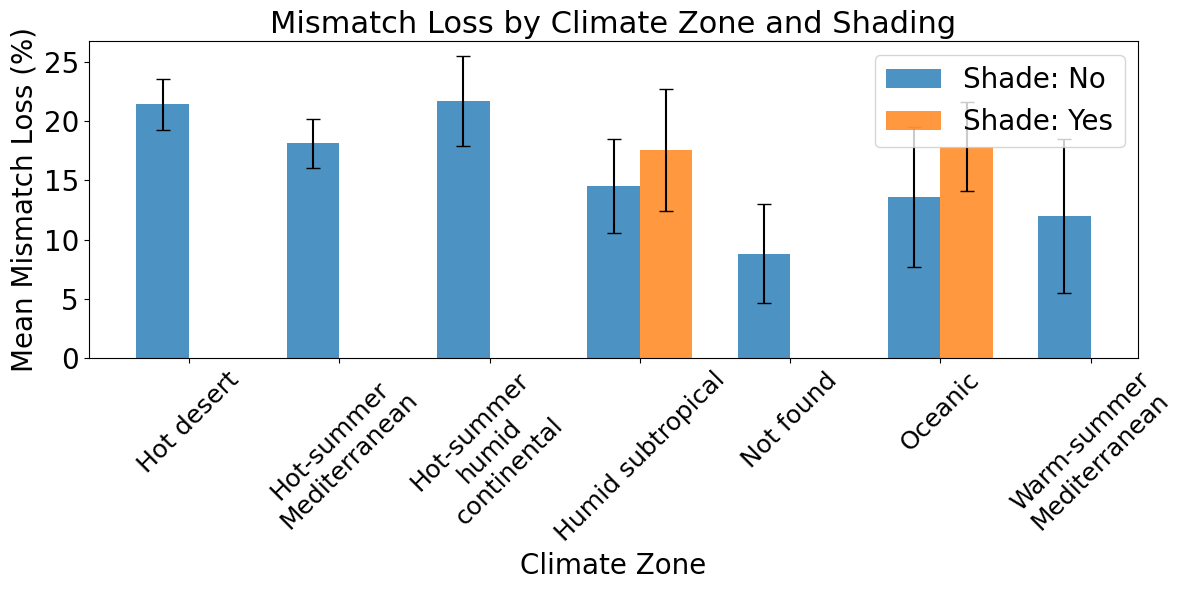

In [8]:
# --- 2.1.2.1. Climate Zone vs. Mismatch Loss, separated by Shade ---

# compute mean & std of mismatch loss by Climate Zone and Shade
stats = site_summary_df.groupby(['Climate Zone', 'Shade'])['Mismatch Loss'].agg(['mean', 'std'])
pivot_mean = stats['mean'].unstack('Shade')
pivot_std  = stats['std'].unstack('Shade')

# plot grouped bar chart
plt.figure(figsize=long_hoz_figsize)
bar_width = 0.35
x = np.arange(len(pivot_mean.index))

for i, shade in enumerate(pivot_mean.columns):
    plt.bar(
        x + i * bar_width,
        pivot_mean[shade],
        yerr=pivot_std[shade],
        width=bar_width,
        label=f'Shade: {shade}',
        capsize=5,
        alpha=0.8
    )

plt.xlabel('Climate Zone', fontsize=axis_label_size)
plt.ylabel('Mean Mismatch Loss (%)', fontsize=axis_label_size)
plt.title('Mismatch Loss by Climate Zone and Shading', fontsize=title_size)

# wrap long climate zone labels
wrapped = [
    cz if len(str(cz)) < 18 else '\n'.join(str(cz).split(' '))
    for cz in pivot_mean.index
]
plt.xticks(
    ticks=x + bar_width / 2,
    labels=wrapped,
    rotation=45,
    ha='center',
    fontsize=axis_num_size - 2
)
plt.yticks(fontsize=axis_num_size)
plt.legend(fontsize=axis_num_size, loc='upper right')
plt.tight_layout()
plt.show()

#### 2.1.2.2. Seperate by orientation

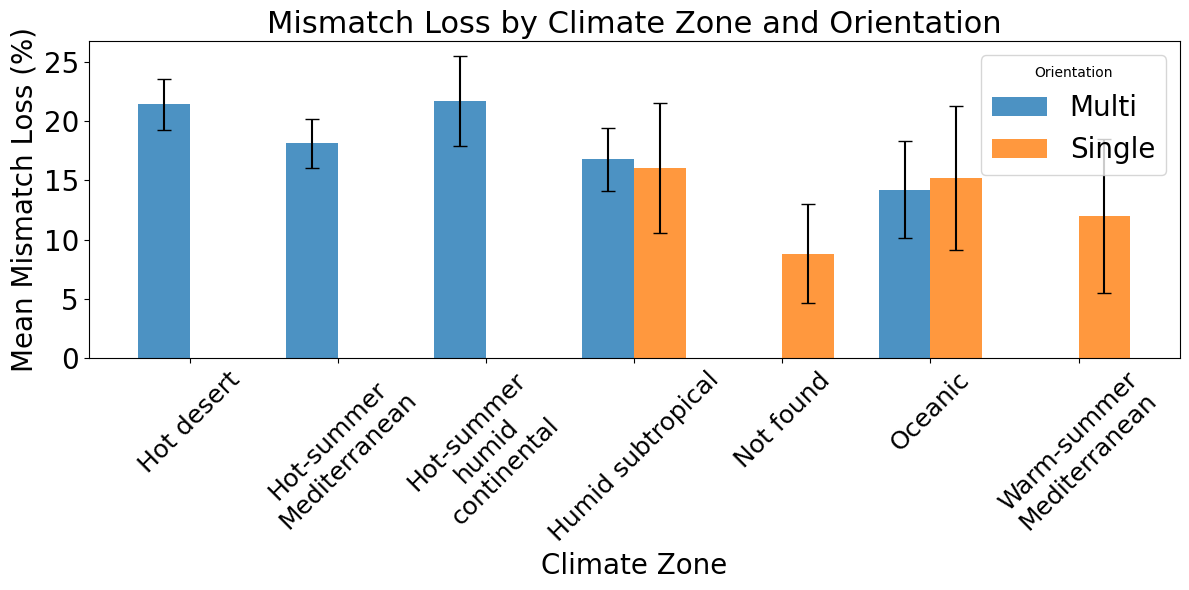

In [9]:
# --- 2.1.2.2. Climate Zone vs. Mismatch Loss, separated by Orientation ---

# compute mean & std by Climate Zone and Orientation
stats_orient = site_summary_df.groupby(
    ['Climate Zone','Orientation']
)['Mismatch Loss'].agg(['mean','std'])
pivot_orient_mean = stats_orient['mean'].unstack('Orientation')
pivot_orient_std  = stats_orient['std'].unstack('Orientation')

# plot grouped bar chart
plt.figure(figsize=long_hoz_figsize)
bar_width = 0.35
n_orients = len(pivot_orient_mean.columns)
x = np.arange(len(pivot_orient_mean.index))

for i, orient in enumerate(pivot_orient_mean.columns):
    plt.bar(
        x + i*bar_width,
        pivot_orient_mean[orient],
        yerr=pivot_orient_std[orient],
        width=bar_width,
        label=orient,
        capsize=5,
        alpha=0.8
    )

plt.xlabel('Climate Zone', fontsize=axis_label_size)
plt.ylabel('Mean Mismatch Loss (%)', fontsize=axis_label_size)
plt.title('Mismatch Loss by Climate Zone and Orientation', fontsize=title_size)

# wrap long climate zone labels
wrapped = [
    cz if len(str(cz)) < 18 else '\n'.join(str(cz).split(' '))
    for cz in pivot_orient_mean.index
]
plt.xticks(
    ticks=x + (n_orients-1)/2*bar_width,
    labels=wrapped,
    rotation=45,
    ha='center',
    fontsize=axis_num_size-2
)
plt.yticks(fontsize=axis_num_size)
plt.legend(title='Orientation', fontsize=axis_num_size, loc='upper right')
plt.tight_layout()
plt.show()

#### 2.1.2.3. Together

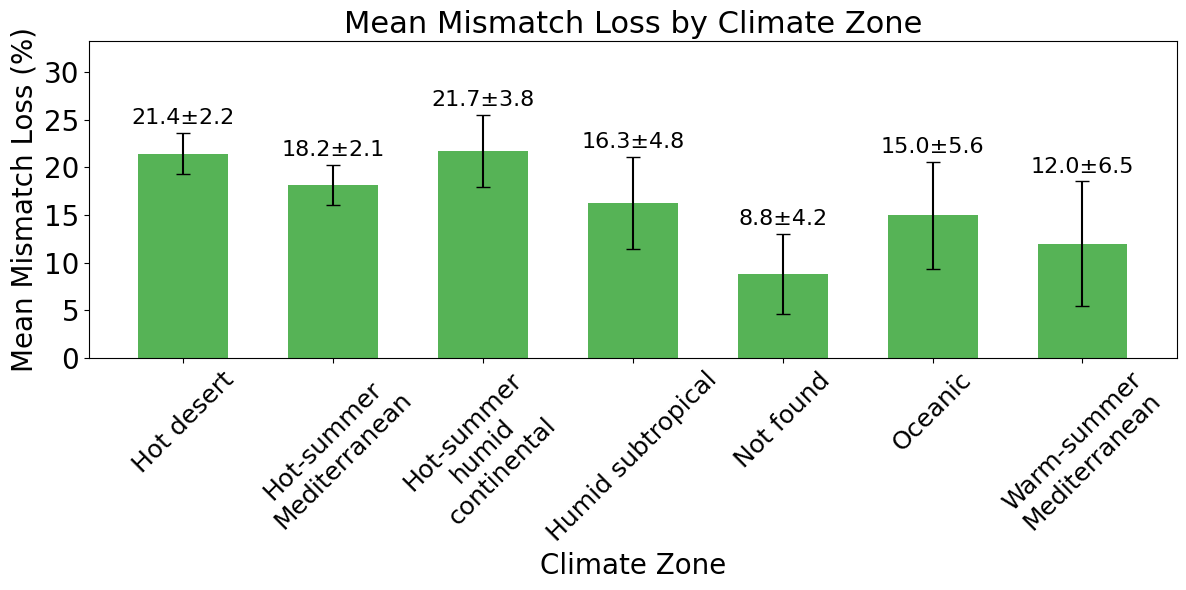

In [10]:
# --- 2.1.2.3. Mean Mismatch Loss by Climate Zone (Combined) ---

# compute mean & std by Climate Zone
stats_zone = site_summary_df.groupby('Climate Zone')['Mismatch Loss'].agg(['mean','std']).reset_index()

# prepare x‐positions
x = np.arange(len(stats_zone))
bar_width = 0.6

plt.figure(figsize=long_hoz_figsize)
bars = plt.bar(
    x,
    stats_zone['mean'],
    yerr=stats_zone['std'],
    width=bar_width,
    alpha=0.8,
    capsize=5,
    color='C2'
)

plt.xlabel('Climate Zone', fontsize=axis_label_size)
plt.ylabel('Mean Mismatch Loss (%)', fontsize=axis_label_size)
plt.title('Mean Mismatch Loss by Climate Zone', fontsize=title_size)

# wrap long labels
wrapped = [
    cz if len(str(cz)) < 18 else '\n'.join(str(cz).split(' '))
    for cz in stats_zone['Climate Zone']
]
plt.xticks(
    ticks=x,
    labels=wrapped,
    rotation=45,
    ha='center',
    fontsize=axis_num_size - 2
)
plt.yticks(fontsize=axis_num_size)
plt.ylim(0, stats_zone['mean'].max() + stats_zone['std'].max() + 5)
plt.tight_layout()

# annotate bars
for bar, m, s in zip(bars, stats_zone['mean'], stats_zone['std']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        m + s + 0.5,
        f"{m:.1f}±{s:.1f}",
        ha='center', va='bottom',
        fontsize=axis_num_size - 4
    )

plt.show()

### 2.1.3. Season

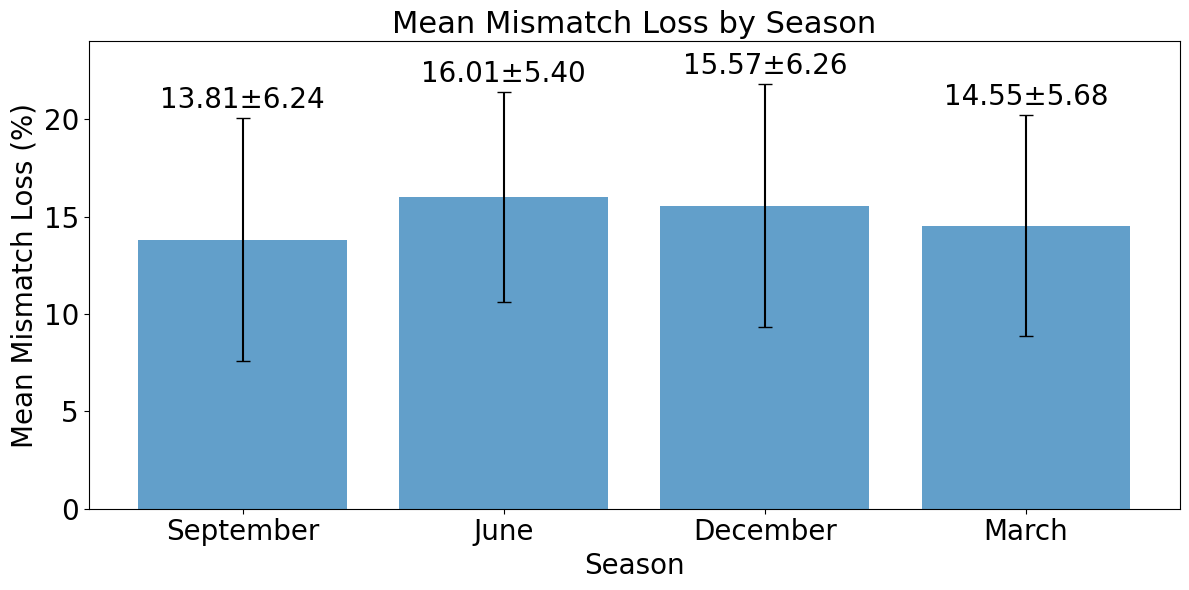

In [11]:
df = pd.read_excel(os.path.join(ResultsFolder, 'new_and_old_with_climate_zone.xlsx'))

# 2. Specify the seasonal columns exactly as they appear
# season_cols = [
#     'summer Mismatch Loss (%)',
#     'autumn Mismatch Loss (%)',
#     'winter Mismatch Loss (%)',
#     'spring Mismatch Loss (%)'
# ]
# 4. Create readable season labels
# seasons = [col.split()[0].capitalize() for col in seasons]

# change the first letter for each string in the list seasons into capital
seasons = [s.capitalize() for s in seasons]

season_cols = [f"{s} Mismatch Loss (%)" for s in seasons]

# 3. Compute mean & std for each season column
means = df[season_cols].mean()
stds  = df[season_cols].std()

# 5. Plot bar chart with error bars
plt.figure(figsize=long_hoz_figsize)
bars = plt.bar(
    seasons,
    means,
    yerr=stds,
    capsize=5,
    alpha=0.7
)

plt.xlabel('Season', fontsize=axis_label_size)
plt.ylabel('Mean Mismatch Loss (%)', fontsize=axis_label_size)
plt.title('Mean Mismatch Loss by Season', fontsize=title_size)

plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.ylim(0, (means + stds).max() * 1.1)

# 6. Annotate each bar with mean ± std
for bar, m, s in zip(bars, means, stds):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        m + s + 0.2,
        f"{m:.2f}±{s:.2f}",
        ha='center',
        va='bottom',
        fontsize=text_size
    )

plt.tight_layout()
plt.show()


## 2.2. Using the data where season are different row

### 2.2.1. Overall hist

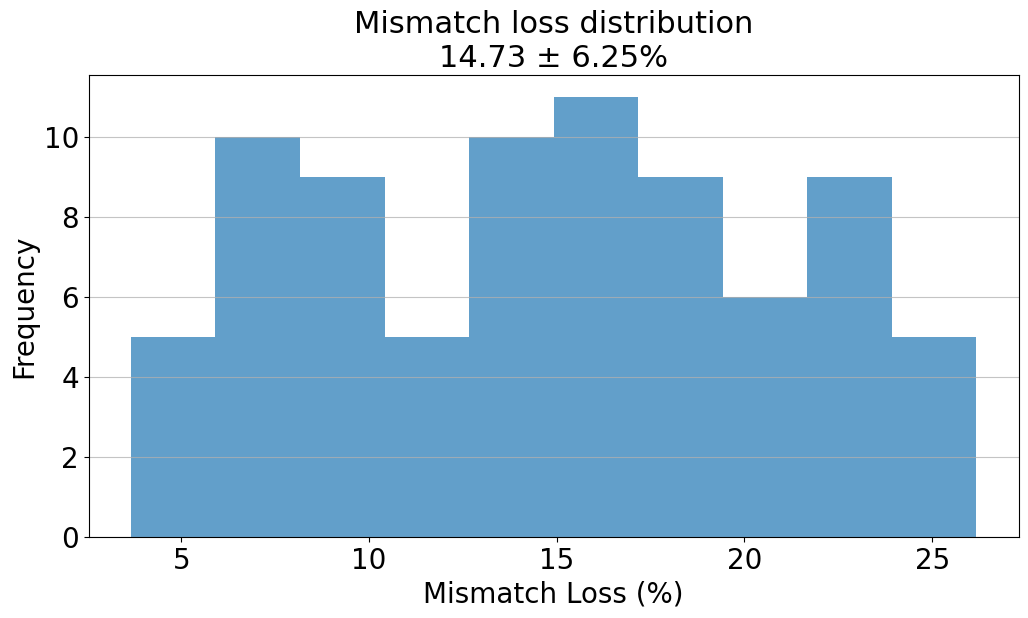

In [12]:
# plot a histogram of the mismatch loss
# plt.figure(figsize=figure_size)
plt.figure(figsize=long_hoz_figsize)
plt.hist(combined_df['Mismatch Loss (%)'], bins=10, alpha=0.7)

# Calculate mean, median, and std
mean_val = combined_df['Mismatch Loss (%)'].mean()
median_val = combined_df['Mismatch Loss (%)'].median()
std_val = combined_df['Mismatch Loss (%)'].std()

# Plot vertical lines for mean and median
# plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f"Mean = {mean_val:.2f}%")
# plt.axvline(median_val, color='black', linestyle='-.', linewidth=2, label=f"Median = {median_val:.2f}%")

plt.xlabel('Mismatch Loss (%)', fontsize=axis_label_size)
plt.ylabel('Frequency', fontsize=axis_label_size)
plt.title(
    r'Mismatch loss distribution' + '\n'
    # + r'$\mathrm{Mean} \pm \sigma = $'
    + f'{mean_val:.2f} ± {std_val:.2f}%',
    fontsize=title_size
)
plt.grid(axis='y', alpha=0.75)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
# plt.legend(fontsize=axis_num_size)
plt.show()

### 2.2.2. Plot against mean frequency

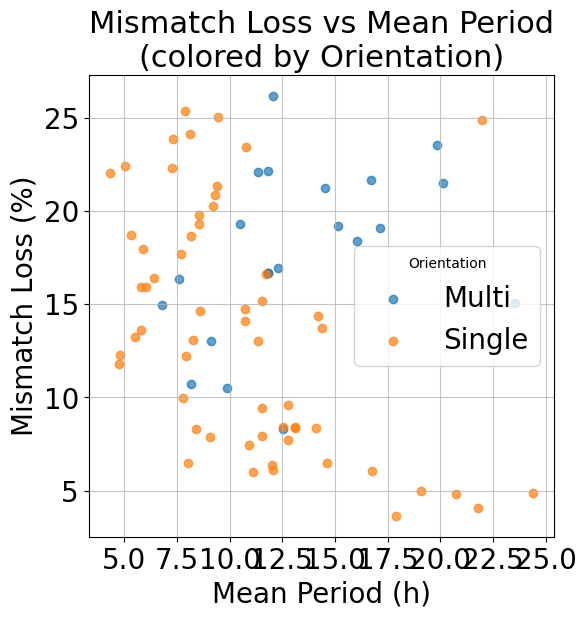

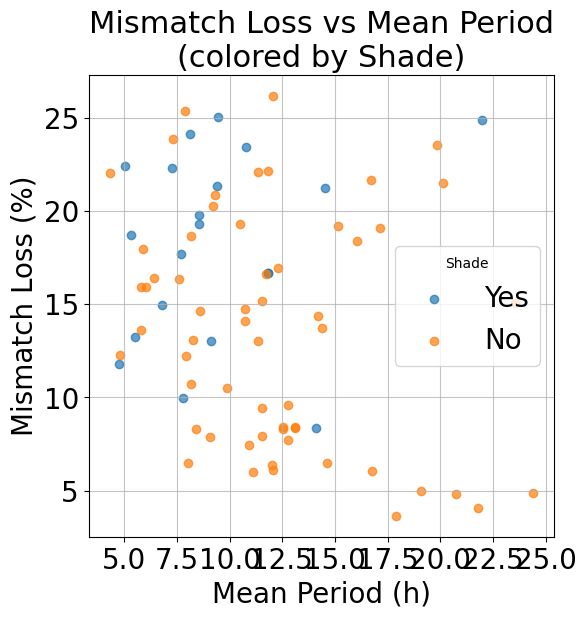

Multi: Slope = 0.3932
Single: Slope = -0.6940


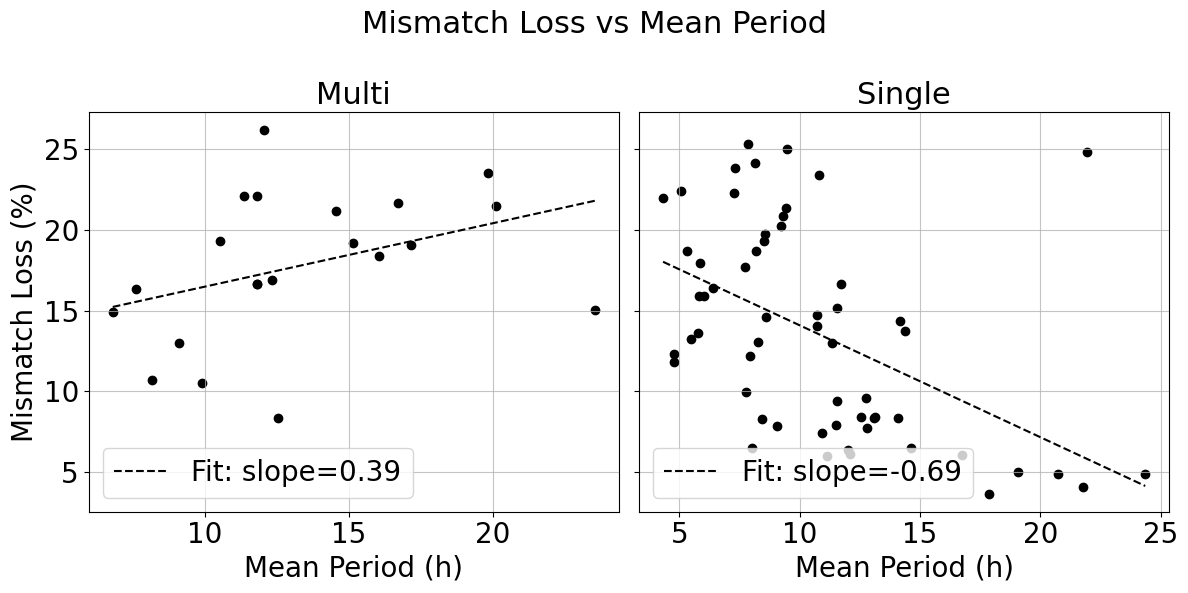

Shaded: Slope = 0.2829
Unshaded: Slope = -0.3288


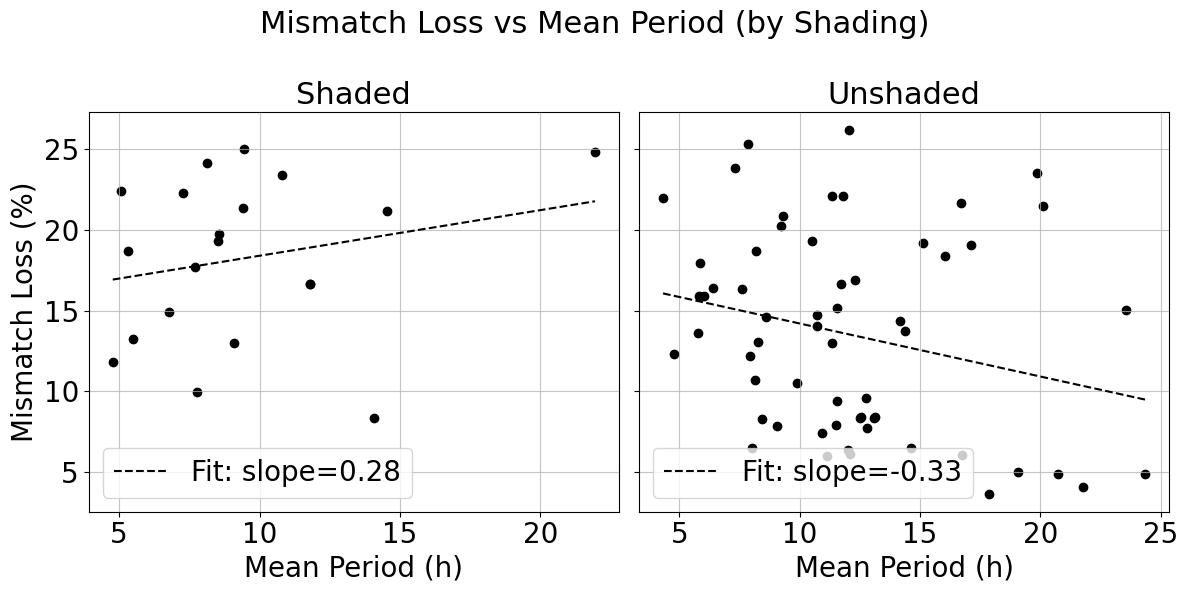

In [13]:
# plot the mismatch loss vs mean period, colored by orientation
plt.figure(figsize=figure_size)
orientations = combined_df['Orientation'].unique()
colors = plt.cm.tab10.colors  # up to 10 unique colors

for idx, orientation in enumerate(orientations):
    subset = combined_df[combined_df['Orientation'] == orientation]
    plt.scatter(
        subset['Mean Period (h)'],
        subset['Mismatch Loss (%)'],
        color=colors[idx % len(colors)],
        alpha=0.7,
        label=str(orientation)
    )

plt.xlabel('Mean Period (h)', fontsize=axis_label_size)
plt.ylabel('Mismatch Loss (%)', fontsize=axis_label_size)
plt.title('Mismatch Loss vs Mean Period\n(colored by Orientation)', fontsize=title_size)
plt.grid(alpha=0.75)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.legend(title='Orientation', fontsize=axis_num_size)
plt.show()



# plot the mismatch loss vs mean period, colored by Shade
plt.figure(figsize=figure_size)
shades = combined_df['Shade'].unique()
colors = plt.cm.tab10.colors  # up to 10 unique colors

for idx, shade in enumerate(shades):
    subset = combined_df[combined_df['Shade'] == shade]
    plt.scatter(
        subset['Mean Period (h)'],
        subset['Mismatch Loss (%)'],
        color=colors[idx % len(colors)],
        alpha=0.7,
        label=str(shade)
    )

plt.xlabel('Mean Period (h)', fontsize=axis_label_size)
plt.ylabel('Mismatch Loss (%)', fontsize=axis_label_size)
plt.title('Mismatch Loss vs Mean Period\n(colored by Shade)', fontsize=title_size)
plt.grid(alpha=0.75)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.legend(title='Shade', fontsize=axis_num_size)
plt.show()


# 2-column, 1-row subplot: left for 'Multi', right for 'Single', with straight line fit and slope

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Filter for 'Single' and 'Multi' (assuming a column 'Type' exists; adjust if needed)
multi_df = combined_df[combined_df['Orientation'].str.lower() == 'multi']
single_df = combined_df[combined_df['Orientation'].str.lower() == 'single']
# Left: Multi
orientations = multi_df['Orientation'].unique()
colors = plt.cm.tab10.colors
ax = axes[0]
for idx, orientation in enumerate(orientations):
    subset = multi_df[multi_df['Orientation'] == orientation]
    ax.scatter(
        subset['Mean Period (h)'],
        subset['Mismatch Loss (%)'],
        color='black',
    )
# Fit line
if not multi_df.empty:
    x = multi_df['Mean Period (h)'].values
    y = multi_df['Mismatch Loss (%)'].values
    if len(x) > 1:
        coeffs = np.polyfit(x, y, 1)
        slope = coeffs[0]
        xfit = np.linspace(np.nanmin(x), np.nanmax(x), 100)
        yfit = np.polyval(coeffs, xfit)
        ax.plot(xfit, yfit, 'k--', label=f'Fit: slope={slope:.2f}')
        print(f"Multi: Slope = {slope:.4f}")
    else:
        slope = np.nan
ax.set_xlabel('Mean Period (h)', fontsize=axis_label_size)
ax.set_ylabel('Mismatch Loss (%)', fontsize=axis_label_size)
ax.set_title('Multi', fontsize=title_size)
ax.tick_params(axis='y', labelsize=axis_num_size)
ax.tick_params(axis='x', labelsize=axis_num_size)
ax.grid(alpha=0.75)
ax.legend(fontsize=axis_num_size, loc='lower left')

# Right: Single
orientations = single_df['Orientation'].unique()
ax = axes[1]
for idx, orientation in enumerate(orientations):
    subset = single_df[single_df['Orientation'] == orientation]
    ax.scatter(
        subset['Mean Period (h)'],
        subset['Mismatch Loss (%)'],
        color='black',
    )
# Fit line
if not single_df.empty:
    x = single_df['Mean Period (h)'].values
    y = single_df['Mismatch Loss (%)'].values
    if len(x) > 1:
        coeffs = np.polyfit(x, y, 1)
        slope = coeffs[0]
        xfit = np.linspace(np.nanmin(x), np.nanmax(x), 100)
        yfit = np.polyval(coeffs, xfit)
        ax.plot(xfit, yfit, 'k--', label=f'Fit: slope={slope:.2f}')
        print(f"Single: Slope = {slope:.4f}")
    else:
        slope = np.nan
ax.set_xlabel('Mean Period (h)', fontsize=axis_label_size)
ax.tick_params(axis='y', labelsize=axis_num_size)
ax.tick_params(axis='x', labelsize=axis_num_size)
ax.set_title('Single', fontsize=title_size)
ax.grid(alpha=0.75)
ax.legend(fontsize=axis_num_size, loc='lower left')

plt.suptitle('Mismatch Loss vs Mean Period', fontsize=title_size)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()




# 2-column, 1-row subplot: left for 'Shaded', right for 'Unshaded', with straight line fit and slope

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Filter for 'Shaded' (yes) and 'Unshaded' (no)
shaded_df = combined_df[combined_df['Shade'].str.lower() == 'yes']
unshaded_df = combined_df[combined_df['Shade'].str.lower() == 'no']

# Left: Shaded
shades = shaded_df['Shade'].unique()
colors = plt.cm.tab10.colors
ax = axes[0]
for idx, shade in enumerate(shades):
    subset = shaded_df[shaded_df['Shade'] == shade]
    ax.scatter(
        subset['Mean Period (h)'],
        subset['Mismatch Loss (%)'],
        color='black',
    )
# Fit line
if not shaded_df.empty:
    x = shaded_df['Mean Period (h)'].values
    y = shaded_df['Mismatch Loss (%)'].values
    if len(x) > 1:
        coeffs = np.polyfit(x, y, 1)
        slope = coeffs[0]
        xfit = np.linspace(np.nanmin(x), np.nanmax(x), 100)
        yfit = np.polyval(coeffs, xfit)
        ax.plot(xfit, yfit, 'k--', label=f'Fit: slope={slope:.2f}')
        print(f"Shaded: Slope = {slope:.4f}")
    else:
        slope = np.nan
ax.set_xlabel('Mean Period (h)', fontsize=axis_label_size)
ax.set_ylabel('Mismatch Loss (%)', fontsize=axis_label_size)
ax.set_title('Shaded', fontsize=title_size)
ax.tick_params(axis='y', labelsize=axis_num_size)
ax.tick_params(axis='x', labelsize=axis_num_size)
ax.grid(alpha=0.75)
ax.legend(fontsize=axis_num_size, loc='lower left')

# Right: Unshaded
shades = unshaded_df['Shade'].unique()
ax = axes[1]
for idx, shade in enumerate(shades):
    subset = unshaded_df[unshaded_df['Shade'] == shade]
    ax.scatter(
        subset['Mean Period (h)'],
        subset['Mismatch Loss (%)'],
        color='black',
    )
# Fit line
if not unshaded_df.empty:
    x = unshaded_df['Mean Period (h)'].values
    y = unshaded_df['Mismatch Loss (%)'].values
    if len(x) > 1:
        coeffs = np.polyfit(x, y, 1)
        slope = coeffs[0]
        xfit = np.linspace(np.nanmin(x), np.nanmax(x), 100)
        yfit = np.polyval(coeffs, xfit)
        ax.plot(xfit, yfit, 'k--', label=f'Fit: slope={slope:.2f}')
        print(f"Unshaded: Slope = {slope:.4f}")
    else:
        slope = np.nan
ax.set_xlabel('Mean Period (h)', fontsize=axis_label_size)
ax.tick_params(axis='y', labelsize=axis_num_size)
ax.tick_params(axis='x', labelsize=axis_num_size)
ax.set_title('Unshaded', fontsize=title_size)
ax.grid(alpha=0.75)
ax.legend(fontsize=axis_num_size, loc='lower left')

plt.suptitle('Mismatch Loss vs Mean Period (by Shading)', fontsize=title_size)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 2.2.3. Group by country hist

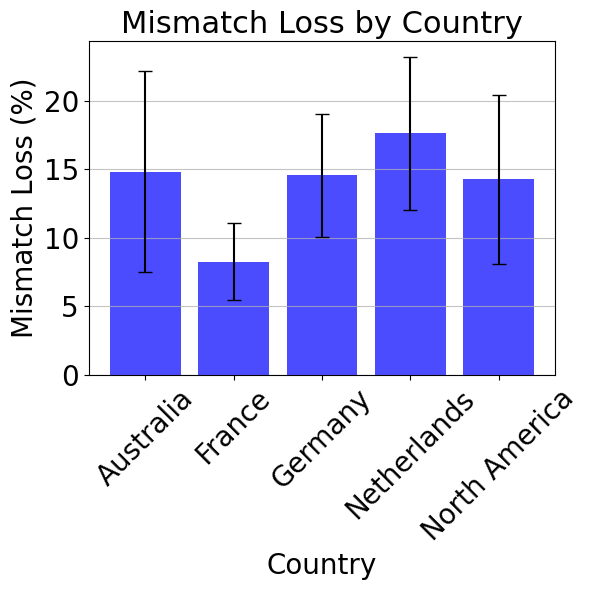

In [14]:

# Group by country and calculate mean and std for mismatch loss
country_stats = combined_df.groupby('Country')['Mismatch Loss (%)'].agg(['mean', 'std'])

plt.figure(figsize=figure_size)
plt.bar(
    country_stats.index,
    country_stats['mean'],
    yerr=country_stats['std'],
    color='blue',
    alpha=0.7,
    capsize=5
)
plt.xlabel('Country', fontsize=axis_label_size)
plt.ylabel('Mismatch Loss (%)', fontsize=axis_label_size)
plt.title('Mismatch Loss by Country', fontsize=title_size)
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=45, fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.tight_layout()
plt.show()

### 2.2.4. Group by orientation hist

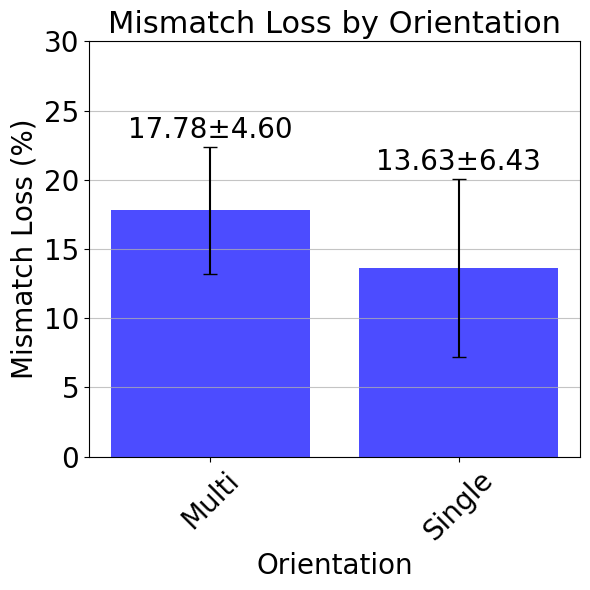

In [15]:
# group by the orientation and calculate mean and std for mismatch loss
orientation_stats = combined_df.groupby('Orientation')['Mismatch Loss (%)'].agg(['mean', 'std'])

plt.figure(figsize=figure_size)
bars = plt.bar(
    orientation_stats.index,
    orientation_stats['mean'],
    yerr=orientation_stats['std'],
    color='blue',
    alpha=0.7,
    capsize=5
)
plt.xlabel('Orientation', fontsize=axis_label_size)
plt.ylabel('Mismatch Loss (%)', fontsize=axis_label_size)
plt.title('Mismatch Loss by Orientation', fontsize=title_size)
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=45, fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.tight_layout()
plt.ylim(0, 30)
# Add value and std on top of each bar
for bar, mean, std in zip(bars, orientation_stats['mean'], orientation_stats['std']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + std + 0.2,
        f"{mean:.2f}±{std:.2f}",
        ha='center',
        va='bottom',
        fontsize=axis_num_size
    )
plt.show()

### 2.2.5. Group by shading

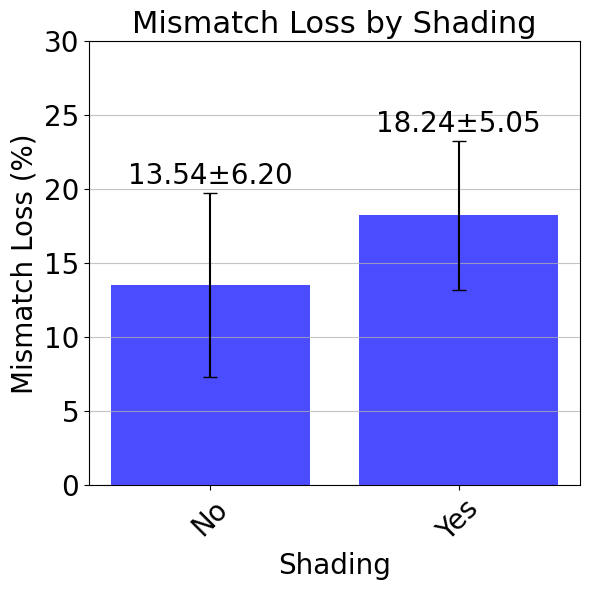

In [16]:
# group by shading and calculate mean and std for mismatch loss
shading_stats = combined_df.groupby('Shade')['Mismatch Loss (%)'].agg(['mean', 'std'])
plt.figure(figsize=figure_size)
bars = plt.bar(
    shading_stats.index,
    shading_stats['mean'],
    yerr=shading_stats['std'],
    color='blue',
    alpha=0.7,
    capsize=5
)
plt.xlabel('Shading', fontsize=axis_label_size)
plt.ylabel('Mismatch Loss (%)', fontsize=axis_label_size)
plt.title('Mismatch Loss by Shading', fontsize=title_size)
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=45, fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.tight_layout()
plt.ylim(0, 30)
# Add value and std on top of each bar
for bar, mean, std in zip(bars, shading_stats['mean'], shading_stats['std']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + std + 0.2,
        f"{mean:.2f}±{std:.2f}",
        ha='center',
        va='bottom',
        fontsize=axis_num_size
    )
plt.show()

### 2.2.6. Group by season

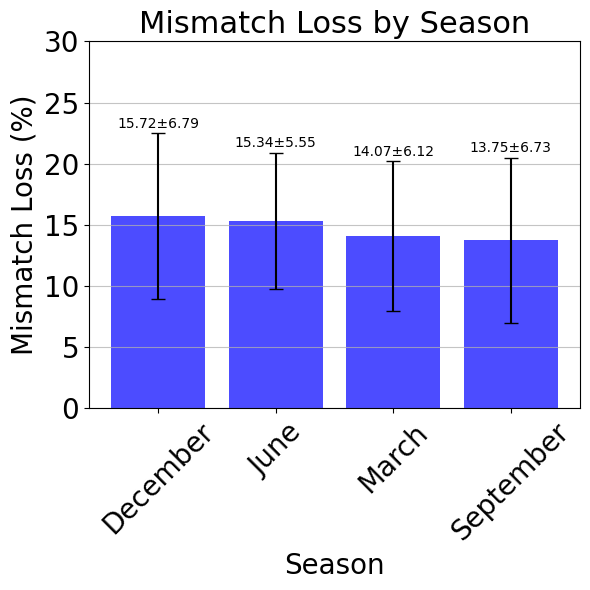

In [17]:
# group by season and calculate mean and std for mismatch loss
season_stats = combined_df.groupby('Season')['Mismatch Loss (%)'].agg(['mean', 'std'])
plt.figure(figsize=figure_size)
bars = plt.bar(
    season_stats.index,
    season_stats['mean'],
    yerr=season_stats['std'],
    color='blue',
    alpha=0.7,
    capsize=5
)
plt.xlabel('Season', fontsize=axis_label_size)
plt.ylabel('Mismatch Loss (%)', fontsize=axis_label_size)
plt.title('Mismatch Loss by Season', fontsize=title_size)
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=45, fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.tight_layout()
plt.ylim(0, 30)
# Add value and std on top of each bar
for bar, mean, std in zip(bars, season_stats['mean'], season_stats['std']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + std + 0.2,
        f"{mean:.2f}±{std:.2f}",
        ha='center',
        va='bottom',
        fontsize=axis_num_size-10
    )
plt.show()

### 2.2.7. Plot against sytem size

December: Slope = 0.7614
June: Slope = -0.2746
March: Slope = -0.0345
September: Slope = -0.0629


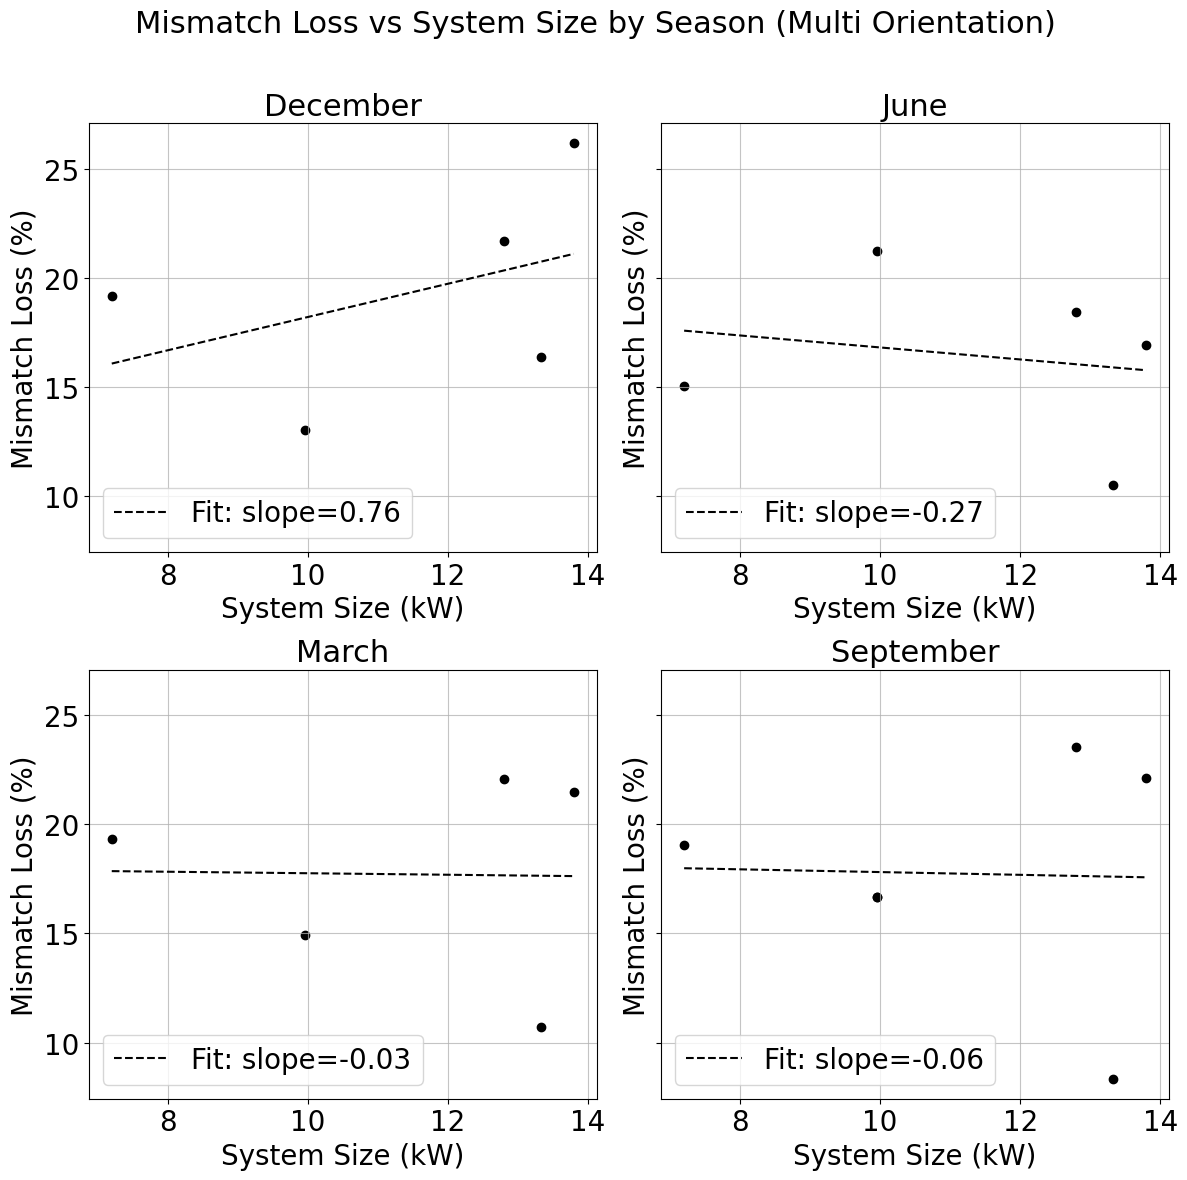

December: Slope = -0.4737
June: Slope = 0.1479
March: Slope = 0.2705
September: Slope = -0.0661


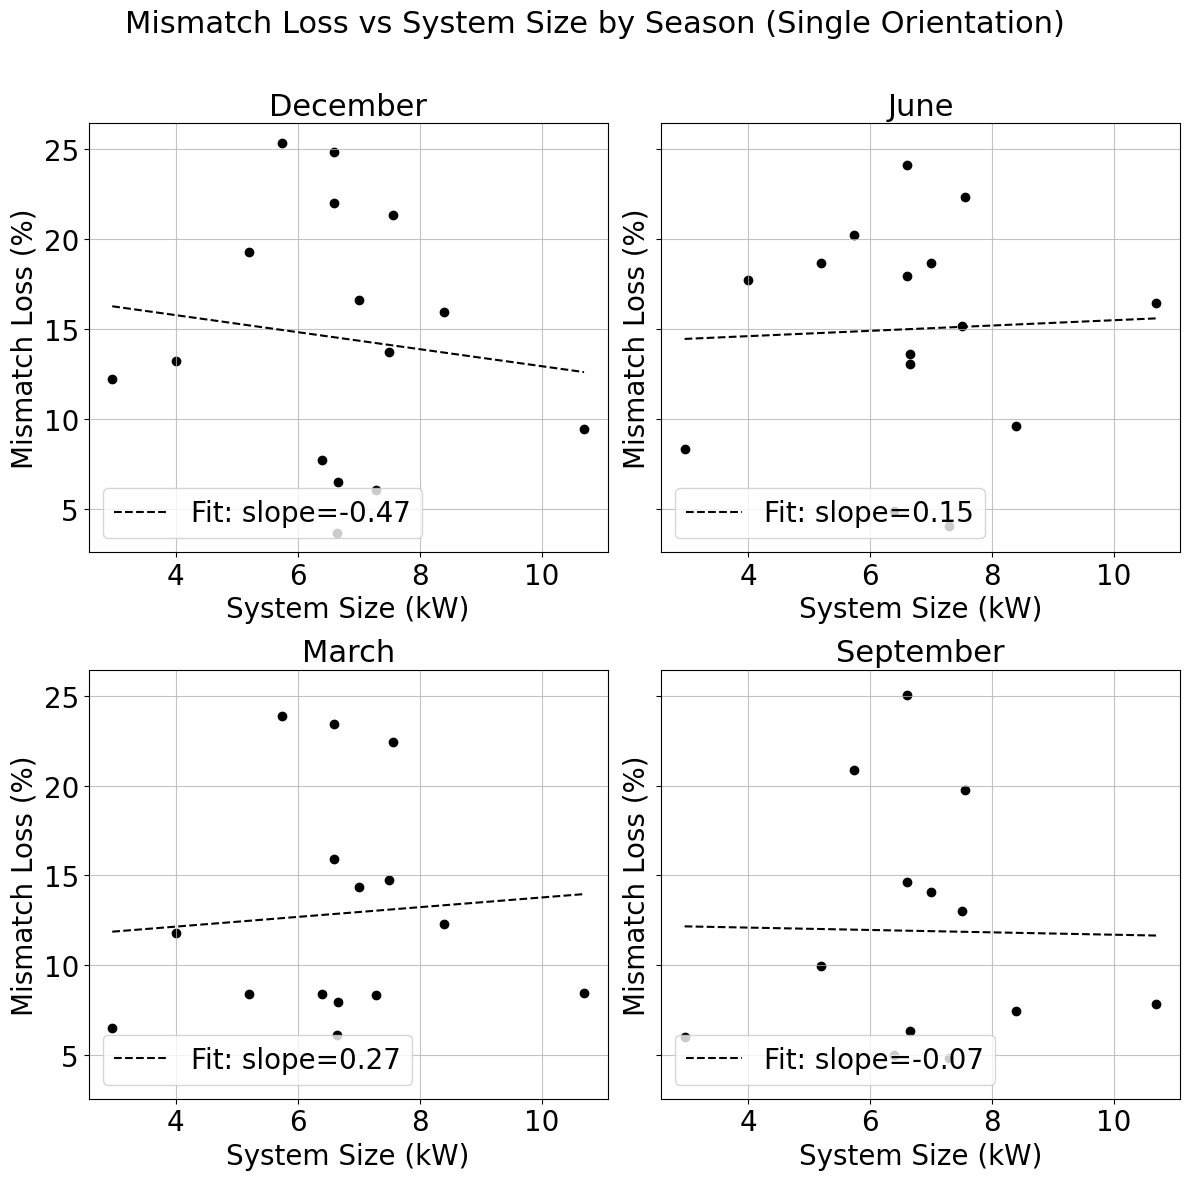

In [18]:
# only plot the site with multiple orientations
multiple_orientations = combined_df[combined_df['Orientation'].str.lower() == 'multi']

# create a new figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=two_by_two_figsize, sharey=True)
fig.subplots_adjust(hspace=0.4, wspace=0.4)

# group by season and plot the mismatch loss vs system size
seasons = multiple_orientations['Season'].unique()
for idx, season in enumerate(seasons):
    ax = axes.flatten()[idx]  # Use a different subplot for each season
    subset = multiple_orientations[multiple_orientations['Season'] == season]
    ax.scatter(
        subset['kWp'],
        subset['Mismatch Loss (%)'],
        color='black'
    )
    # Fit line
    if not subset.empty:
        x = subset['kWp'].values
        y = subset['Mismatch Loss (%)'].values
        if len(x) > 1:
            coeffs = np.polyfit(x, y, 1)
            slope = coeffs[0]
            xfit = np.linspace(np.nanmin(x), np.nanmax(x), 100)
            yfit = np.polyval(coeffs, xfit)
            ax.plot(xfit, yfit, 'k--', label=f'Fit: slope={slope:.2f}')
            print(f"{season}: Slope = {slope:.4f}")
        else:
            slope = np.nan
    ax.set_xlabel('System Size (kW)', fontsize=axis_label_size)
    ax.set_ylabel('Mismatch Loss (%)', fontsize=axis_label_size)
    ax.set_title(f'{season}', fontsize=title_size)
    ax.tick_params(axis='y', labelsize=axis_num_size)
    ax.tick_params(axis='x', labelsize=axis_num_size)
    ax.grid(alpha=0.75)
    ax.legend(fontsize=axis_num_size, loc='lower left')  # Only fit line in legend

plt.suptitle('Mismatch Loss vs System Size by Season (Multi Orientation)', fontsize=title_size)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# only plot the site with single orientation
single_orientations = combined_df[combined_df['Orientation'].str.lower() == 'single']

# create a new figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=two_by_two_figsize, sharey=True)
fig.subplots_adjust(hspace=0.4, wspace=0.4)

# group by season and plot the mismatch loss vs system size
seasons = single_orientations['Season'].unique()
for idx, season in enumerate(seasons):
    ax = axes.flatten()[idx]  # Use a different subplot for each season
    subset = single_orientations[single_orientations['Season'] == season]
    ax.scatter(
        subset['kWp'],
        subset['Mismatch Loss (%)'],
        color='black'
    )
    # Fit line
    if not subset.empty:
        x = subset['kWp'].values
        y = subset['Mismatch Loss (%)'].values
        if len(x) > 1:
            coeffs = np.polyfit(x, y, 1)
            slope = coeffs[0]
            xfit = np.linspace(np.nanmin(x), np.nanmax(x), 100)
            yfit = np.polyval(coeffs, xfit)
            ax.plot(xfit, yfit, 'k--', label=f'Fit: slope={slope:.2f}')
            print(f"{season}: Slope = {slope:.4f}")
        else:
            slope = np.nan
    ax.set_xlabel('System Size (kW)', fontsize=axis_label_size)
    ax.set_ylabel('Mismatch Loss (%)', fontsize=axis_label_size)
    ax.set_title(f'{season}', fontsize=title_size)
    ax.tick_params(axis='y', labelsize=axis_num_size)
    ax.tick_params(axis='x', labelsize=axis_num_size)
    ax.grid(alpha=0.75)
    ax.legend(fontsize=axis_num_size, loc='lower left')  # Only fit line in legend

plt.suptitle('Mismatch Loss vs System Size by Season (Single Orientation)', fontsize=title_size)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 3. Internal bypass diode study by system

In [19]:
# # define the site id
# site_id = '4184502'
# # define the season
# # season = 'winter'
# season = 'june' # later I changed the season to month, but let's keep the name for now, keep the input here lower case

## 3.1. Voc outlier detector

* If has Voc higher than normal, labelld 1
* If loss 1/3 of Voc, labelled -1
* If loss 2/3 of Voc, labelled -2
* Else, labelled 0

In [20]:

# # define the iqr factor for Voc too high
# iqr_factor_1 = 1.5
# # define the iqr factor for lossing 1/3 of Voc
# iqr_factor_n1 = 10
# # define the iqr factor for lossing 2/3 of Voc
# iqr_factor_n2 = 15

# def outlier_1_identifier(row, iqr_factor=iqr_factor_1, min_dvoc = 2):
#     '''
#     Identify outliers using the IQR method. This corresponding to the case when Voc is too high.
#     '''
#     q1 = row.quantile(0.25)
#     q3 = row.quantile(0.75)
#     iqr = q3 - q1
#     upper = q3 + max(iqr_factor * iqr, min_dvoc)
#     return row > upper

# # def outlier_n1_identifier(row, iqr_factor=iqr_factor_n1):
# #     '''
# #     Identify outliers using the IQR method. This corresponding to the case when we loss 1/3 of Voc
# #     '''
# #     q1 = row.quantile(0.25)
# #     q3 = row.quantile(0.75)
# #     iqr = q3 - q1
# #     lower = q1 - iqr_factor * iqr
# #     return row < lower

# # def outlier_n2_identifier(row, iqr_factor=iqr_factor_n2):
# #     '''
# #     Identify outliers using the IQR method. This corresponding to the case when we loss 2/3 of Voc
# #     '''
# #     q1 = row.quantile(0.25)
# #     q3 = row.quantile(0.75)
# #     iqr = q3 - q1
# #     lower = q1 - iqr_factor * iqr
# #     return row < lower

# # Find the folder
# target_folder = None
# for folder in os.listdir(ResultsFolder):
#     if site_id in folder and season.lower() in folder.lower():
#         target_folder = os.path.join(ResultsFolder, folder)
#         print(f"Found target folder: {target_folder}")
#         break
# # print the target folder
# if target_folder is None:
#     print(f"No folder found for site {site_id} and season {season}.")

# if target_folder is not None:
#     # List files in the folder
#     files = os.listdir(target_folder)
#     # look for a csv file that contains the word module
#     for file in files:
#         if 'module' in file.lower() and file.endswith('.csv'):
#             target_file = os.path.join(target_folder, file)
#             print(f"Found file: {target_file}")
#             # read the csv file
#             df = pd.read_csv(target_file)


#             # # remove any row with NaN values
#             # df = df.dropna()
#             # print(df)
#             # # …existing code…
#             # df_pivot = df.pivot(
#             #     index=['Timestamp'],
#             #     columns=['Optimizer'],
#             #     values=['I0', 'Isc', 'Voc', 'FF', 'Pmp', 'Imp', 'Vmp']
#             # ).dropna()
#             # print('df_pivot shape:', df_pivot.shape)

#             df = df.dropna(how='all')   # only toss rows that are 100% NaN

#             df_pivot = df.pivot_table(
#                 index   ='Timestamp',
#                 columns ='Optimizer',
#                 values  =['I0','Isc','Voc','FF','Pmp','Imp','Vmp'],
#                 aggfunc ='first'
#             )

#             # if you really want to lose only optimizers that never showed up:
#             df_pivot = df_pivot.dropna(axis=1, how='all')

#             print('df_pivot shape:', df_pivot.shape)


#             # ensure the index is datetime
#             df_pivot.index = pd.to_datetime(df_pivot.index)

#             # --- flatten the MultiIndex columns to simple strings ---
#             df_pivot.columns = ['{}_{}'.format(var, opt) for var, opt in df_pivot.columns]

#             # find the flattened Voc columns
#             voc_cols = [c for c in df_pivot.columns if c.startswith('Voc_')]

#             # calculate the median of the Voc rows
#             # voc_median = df_pivot[voc_cols].median(axis=0)

#             # compute three outlier masks row‐wise
#             mask1   = df_pivot[voc_cols].apply(lambda row: outlier_1_identifier(row), axis=1)
#             # mask_n1 = df_pivot[voc_cols].apply(lambda row: outlier_n1_identifier(row), axis=1)
#             # mask_n2 = df_pivot[voc_cols].apply(lambda row: outlier_n2_identifier(row), axis=1)
            
#             # define mask_n1 & mask_n2 using the median of each row
#             mask_n1 = df_pivot[voc_cols].apply(
#                 lambda row: (row < 2/3 * row.quantile(0.75)) & (row > 1/3 * row.quantile(0.75)),
#                 axis=1
#             )
#             mask_n2 = df_pivot[voc_cols].apply(
#                 lambda row: row < 1/3 * row.quantile(0.75),
#                 axis=1
#             )
#             # combine all masks into a single label a single label: 
#             #   1 if mask1, -1 if mask_n1, -2 if mask_n2, else 0
#             for col in voc_cols:
#                 df_pivot[f'{col}_outlier_label'] = np.where(
#                     mask1[col],   1,
#                     np.where(mask_n1[col], -1,
#                             np.where(mask_n2[col], -2, 0))
#                 )

#             # print the outlier labels
#             print(df_pivot[[col for col in df_pivot.columns if col.endswith('_outlier_label')]].head(10))

#         else:
#             print(f"File {file} does not match the criteria.")


## 3.2. Voc outlier visualiser (keep as comment if not using)

In [21]:
# # 3.2. Voc outlier visualiser (with separate lower/upper bounds)
# voc_cols   = [c for c in df_pivot.columns
#               if c.startswith('Voc_') and not c.endswith('_outlier_label')]
# label_cols = [f'{c}_outlier_label' for c in voc_cols]

# for timestamp, group in df_pivot.groupby(level=0):
#     # only plot timestamps where at least one Voc has a "-1" label
#     if (group[label_cols] == -1).any(axis=1).any():
#         vals = group[voc_cols].values.flatten()

#         # compute quartiles and IQR
#         q1, q3  = np.percentile(vals, [25, 75])
#         iqr     = q3 - q1
#         upper_fence    = q3 + iqr_factor_1  * iqr
#         lower_fence_n1 = q1 - iqr_factor_n1 * iqr
#         lower_fence_n2 = q1 - iqr_factor_n2 * iqr

#         fig, ax = plt.subplots(figsize=figure_size)
#         # draw boxplot without custom 'whis' to avoid percentile errors
#         ax.boxplot(
#             vals,
#             vert=True,
#             patch_artist=True,
#             showfliers=False
#         )

#         # overlay custom fence lines
#         ax.axhline(upper_fence,    color='red',    linestyle='--',
#                    label=f'High bound: {upper_fence:.2f} V')
#         ax.axhline(lower_fence_n1, color='orange', linestyle='-.',
#                    label=f'Low bound (1/3 loss): {lower_fence_n1:.2f} V')
#         ax.axhline(lower_fence_n2, color='purple', linestyle=':',
#                    label=f'Low bound (2/3 loss): {lower_fence_n2:.2f} V')

#         # highlight actual outliers
#         out_high = vals[vals > upper_fence]
#         out_n1   = vals[vals < lower_fence_n1]
#         out_n2   = vals[(vals >= lower_fence_n1) & (vals < lower_fence_n2)]
#         xh = np.random.normal(1, 0.02, size=out_high.size)
#         xn1= np.random.normal(1, 0.02, size=out_n1.size)
#         xn2= np.random.normal(1, 0.02, size=out_n2.size)
#         ax.scatter(xh, out_high, c='red',    label='_nolegend_')
#         ax.scatter(xn1, out_n1,   c='orange', label='_nolegend_')
#         ax.scatter(xn2, out_n2,   c='purple', label='_nolegend_')

#         # labels & legend
#         ax.set_title(f'Voc distribution at {timestamp}', fontsize=title_size)
#         ax.set_ylabel('Voc (V)', fontsize=axis_label_size)
#         ax.tick_params(axis='both', labelsize=axis_num_size)
#         ax.grid(axis='y', ls='--', alpha=0.7)
#         ax.legend(
#             loc='upper left',
#             bbox_to_anchor=(1.02, 1),
#             borderaxespad=0,
#             fontsize=axis_num_size
#         )

#         # adjust layout and display
#         fig.tight_layout(rect=[0, 0, 0.8, 1])
#         plt.show()

## 3.3. Isc outlier detector

* If Isc is upper outlier, it is labelled as 1
* If Isc is lower outlier, it is labelled as -1
* Otherwise it is labelled as 0

In [22]:
# # 3.3. Isc outlier detector (only high vs low)

# # define I-V specific IQR factor for Isc
# iqr_factor_isc_low = 1.5
# iqr_factor_isc_high = 3

# def outlier_isc_high(row, iqr_factor=iqr_factor_isc_high, min_iqr=0.5):
#     """Isc too high, with min IQR enforcement"""
#     q1, q3   = row.quantile([0.25, 0.75])
#     raw_iqr  = q3 - q1
#     iqr_val  = raw_iqr if raw_iqr >= min_iqr else min_iqr
#     upper    = q3 + iqr_factor * iqr_val
#     return row > upper

# def outlier_isc_low(row, iqr_factor=iqr_factor_isc_low,  min_iqr=0.5):
#     """Isc too low, with min IQR enforcement"""
#     q1, q3   = row.quantile([0.25, 0.75])
#     raw_iqr  = q3 - q1
#     iqr_val  = raw_iqr if raw_iqr >= min_iqr else min_iqr
#     lower    = q1 - iqr_factor * iqr_val
#     return row < lower

# # find all flattened Isc columns
# isc_cols = [c for c in df_pivot.columns if c.startswith('Isc_')]

# # compute high/low masks
# mask_high_isc = df_pivot[isc_cols].apply(outlier_isc_high, axis=1)
# mask_low_isc  = df_pivot[isc_cols].apply(outlier_isc_low,  axis=1)

# # assign labels: 1 if too high, -1 if too low, else 0
# for col in isc_cols:
#     df_pivot[f'{col}_outlier_label'] = np.where(
#         mask_high_isc[col],  1,
#         np.where(mask_low_isc[col], -1, 0)
#     )

# # preview the new Isc outlier labels
# print(df_pivot[[c for c in df_pivot.columns
#                 if c.startswith('Isc_') and c.endswith('_outlier_label')]].head(10))

## 3.4. Isc outlier visualiser (keep as comment)

In [23]:
# # 3.4. Isc outlier visualiser (with separate high/low bounds)

# # flattened Isc columns & their label columns
# isc_cols   = [c for c in df_pivot.columns if c.startswith('Isc_') and not c.endswith('_outlier_label')]
# label_cols = [f'{c}_outlier_label' for c in isc_cols]

# for timestamp, group in df_pivot.groupby(level=0):
#     # skip timestamps without any Isc outlier
#     if not (group[label_cols] != 0).any(axis=1).any():
#         continue

#     # collect all Isc values at this timestamp
#     vals = group[isc_cols].values.flatten()
#     # compute fences
#     q1, q3        = np.percentile(vals, [25, 75])
#     iqr           = q3 - q1
#     upper_fence   = q3 + iqr_factor_isc_high * iqr
#     lower_fence   = q1 - iqr_factor_isc_low * iqr

#     fig, ax = plt.subplots(figsize=figure_size)
#     # boxplot without default fliers, using custom whiskers
#     ax.boxplot(
#         vals,
#         vert=True,
#         patch_artist=True,
#         showfliers=False
#         # removed whis=(lower_fence, upper_fence)
#     )

#     # plot fence lines
#     ax.axhline(upper_fence, color='red',    linestyle='--',
#                label=f'High bound: {upper_fence:.2f} A')
#     ax.axhline(lower_fence, color='orange', linestyle='-.',
#                label=f'Low bound:  {lower_fence:.2f} A')

#     # highlight actual outliers
#     out_high = vals[vals > upper_fence]
#     out_low  = vals[vals < lower_fence]
#     xh = np.random.normal(1, 0.02, size=out_high.size)
#     xl = np.random.normal(1, 0.02, size=out_low.size)
#     ax.scatter(xh, out_high, c='red',    label='_nolegend_')
#     ax.scatter(xl, out_low,  c='orange', label='_nolegend_')

#     # styling
#     ax.set_title(f'Isc distribution at {timestamp}', fontsize=title_size)
#     ax.set_ylabel('Isc (A)', fontsize=axis_label_size)
#     ax.tick_params(axis='both', labelsize=axis_num_size)
#     ax.grid(axis='y', ls='--', alpha=0.7)
#     ax.legend(
#         loc='upper left',
#         bbox_to_anchor=(1.02, 1),
#         borderaxespad=0,
#         fontsize=axis_num_size
#     )
#     fig.tight_layout(rect=[0, 0, 0.8, 1])
#     plt.show()

## 3.5. Diode activation condition definition

- For type 1:
    - Description: Isc is not changed but we lose 1/3 of Voc, this is one case when one diode is activated
    - Voc condition: Voc is lower than the 1/3 lower bound
    - Isc condition: not an outlier
- For type 2:
    - Description: Isc is not changedd but we lose 2/3 of Voc, this is one case when two diodes are activated
    - Voc condition: Voc is lower than the 2/3 lower bound
    - Isc condition: not an outlier
- For type -1
    - Description: Isc is an loew outlier, Voc is an higher outlier, this case can happen when 1, 2, or 3 diodes are activated
    - Voc condition: Voc is higher outlier
    - Isc condition: lower outlier
- Others: 0

In [24]:
# # …existing code before diode‐activation…

# # build lists of your outlier‐label cols
# voc_label_cols = [c for c in df_pivot.columns
#                   if c.startswith('Voc_') and c.endswith('_outlier_label')]
# isc_label_cols = [c for c in df_pivot.columns
#                   if c.startswith('Isc_') and c.endswith('_outlier_label')]

# # for each Voc_xxx_outlier_label, pick the matching Isc_xxx_outlier_label
# for voc_col in voc_label_cols:
#     opt     = voc_col.replace('Voc_', '').replace('_outlier_label', '')
#     isc_lab = f'Isc_{opt}_outlier_label'
#     act_col = f'{opt}_diode_activation'
#     if isc_lab not in df_pivot.columns:
#         continue

#     # define conditions
#     conds   = [
#         (df_pivot[voc_col] == -1) & (df_pivot[isc_lab] == 0),
#         (df_pivot[voc_col] == -2) & (df_pivot[isc_lab] == 0),
#         (df_pivot[voc_col] ==  1) & (df_pivot[isc_lab] == -1)
#     ]
#     choices = [1, 2, -1]

#     # assign activation label
#     df_pivot[act_col] = np.select(conds, choices, default=0)

#     # if actual Isc < 1 A, force activation to 0
#     # df_pivot.loc[df_pivot[f'Isc_{opt}'] < 1, act_col] = 0

# # ensure the index has a name
# df_pivot.index.name = 'Timestamp'

# # build output filename with site_id and season, and save into the matching ResultsFolder sub-folder
# output_filename = f"{site_id}_{season}_outlier_labels.csv"
# output_path     = os.path.join(target_folder or ResultsFolder, output_filename)

# df_pivot.to_csv(
#     output_path,
#     index=True,
#     index_label='Timestamp'
# )

## 3.6. Diode activation visualise

In [25]:
# # collect all diode‐activation columns
# act_cols = [c for c in df_pivot.columns if c.endswith('_diode_activation')]

# # select rows where any activation ≠ 0
# diode_activation = df_pivot[(df_pivot[act_cols] != 0).any(axis=1)]

# # for each timestamp and each activated optimiser, print the diode‐activation value
# # along with its corresponding Voc and Isc outlier labels
# for ts, row in diode_activation.iterrows():
#     for act_col in act_cols:
#         act_val = row[act_col]
#         if act_val != 0:
#             opt = act_col.replace('_diode_activation','')
#             voc_label = f'Voc_{opt}_outlier_label'
#             isc_label = f'Isc_{opt}_outlier_label'
#             print(f"{ts} → {act_col}={act_val}, "
#                   f"{voc_label}={row.get(voc_label,'NA')}, "
#                   f"{isc_label}={row.get(isc_label,'NA')}")

## 3.7. Update the power file for mismatch calculation

In [26]:
# # remove any timestamp that is collected by diode activation from the combined data file and export a new one

# # find the diode activation timestamps
# diode_activation_timestamps = diode_activation.index

# # ensure it is in datetime format
# diode_activation_timestamps = pd.to_datetime(diode_activation_timestamps)

# # read the file in ResultsFolder that contains the word 'combined' and is an excel file
# for file in os.listdir(target_folder):
#     if 'combined' in file and file.endswith('.xlsx'):
#         combined_file = os.path.join(target_folder, file)
#         break
# else:
#     print(f"No combined file found in {target_folder}")

# # from the combined file, read the first sheet
# combined_df = pd.read_excel(combined_file, sheet_name=0)

# # uensure timestamp is in datetime format
# combined_df['Timestamp'] = pd.to_datetime(combined_df['Timestamp'])

# # use it as index
# combined_df.set_index('Timestamp', inplace=True)

# print(f"Original combined data shape: {combined_df.shape}")

# # remove the diode activation timestamps from the combined data
# combined_df = combined_df[~combined_df.index.isin(diode_activation_timestamps)]

# # create a new file name with '_no_diode_activation' suffix
# new_combined_file = combined_file.replace('.xlsx', '_no_diode_activation.xlsx')
# # save the new combined data to the new file
# combined_df.to_excel(new_combined_file, index=True)

# # print hte shape before and after filtering
# print(f"New combined data shape (after removing diode activation timestamps): {combined_df.shape}")

# 4. Internal diode activation in batch (for all system)

## 4.1. Define parameters

This session was moved to session 2.1.1. so keep this session commented

In [27]:
# season list
# seasons = ['spring', 'summer', 'autumn', 'winter']

# system id list
# system_ids = ['4184502', '4184503', '4184504', '4184505']

# create an empty list to store the site_id and season
site_ids = []
seasons = []
# read from the Results folder
for folder in os.listdir(ResultsFolder):
    # check if the folder is a folder rather than a file
    if not os.path.isdir(os.path.join(ResultsFolder, folder)):
        continue
    else:
        site_id = folder.split('_')[0]  # assuming site_id is the first part of the folder name
        season = folder.split('_')[1]  # assuming season is the second part of the folder name
        site_ids.append(site_id)
        seasons.append(season)

# remove duplicates
site_ids = list(set(site_ids))
seasons = list(set(seasons))

# make the seasons to lower case
seasons = [s.lower() for s in seasons]

# print the site_ids and seasons
print(f"Site IDs: {site_ids}")
print(f"Seasons: {seasons}")

Site IDs: ['4111846', '4140175', '4173851', '4123602', '4093272', '4186157', '4112053', '4118327', '3455043', '4034376', '4122216', '4111492', '4111800', '4184502', '4073264', '4093266', '4162787', '4172746', '4153809', '4002138']
Seasons: ['september', 'june', 'december', 'march']


## 4.2. Define functions

run the model in session 3 instead of here so that we are consistent

In [28]:
# define the iqr factor for Voc too high
iqr_factor_1 = 1.5
# define the iqr factor for lossing 1/3 of Voc
iqr_factor_n1 = 10
# define the iqr factor for lossing 2/3 of Voc
iqr_factor_n2 = 20

def outlier_1_identifier(row, iqr_factor=iqr_factor_1):
    '''
    Identify outliers using the IQR method. This corresponding to the case when Voc is too high.
    '''
    q1 = row.quantile(0.25)
    q3 = row.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + iqr_factor * iqr
    return row > upper

# define I-V specific IQR factor for Isc
iqr_factor_isc_low = 1.5
iqr_factor_isc_high = 3

def outlier_isc_high(row, iqr_factor=iqr_factor_isc_high, min_iqr=0.2):
    """Isc too high, with min IQR enforcement"""
    q1, q3   = row.quantile([0.25, 0.75])
    raw_iqr  = q3 - q1
    iqr_val  = raw_iqr if raw_iqr >= min_iqr else min_iqr
    upper    = q3 + iqr_factor * iqr_val
    return row > upper

def outlier_isc_low(row, iqr_factor=iqr_factor_isc_low,  min_iqr=0.2):
    """Isc too low, with min IQR enforcement"""
    q1, q3   = row.quantile([0.25, 0.75])
    raw_iqr  = q3 - q1
    iqr_val  = raw_iqr if raw_iqr >= min_iqr else min_iqr
    lower    = q1 - iqr_factor * iqr_val
    return row < lower

## 4.3. Run the analysis

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111846_September_20250630_074216
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111846_September_20250630_074216\module_param_df.csv
df_pivot shape: (1474, 112)
2024-09-20 09:30:00 → 247639229_diode_activation=-1.0, Voc_247639229_outlier_label=1.0, Isc_247639229_outlier_label=-1.0
2024-09-20 09:35:00 → 247639229_diode_activation=-1.0, Voc_247639229_outlier_label=1.0, Isc_247639229_outlier_label=-1.0
2024-09-20 09:40:00 → 247639229_diode_activation=-1.0, Voc_247639229_outlier_label=1.0, Isc_247639229_outlier_label=-1.0
2024-09-20 09:45:00 → 247639229_diode_activation=-1.0, Voc_247639229_outlier_label=1.0, Isc_247639229_outlier_label=-1.0
2024-09-20 09:50:00 → 247639229_diode_activation=-1.0, Voc_247639229_outlier_label=1.0, Isc_247639229_outlier_label=-1.0
2024-09-20 09:55:0

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


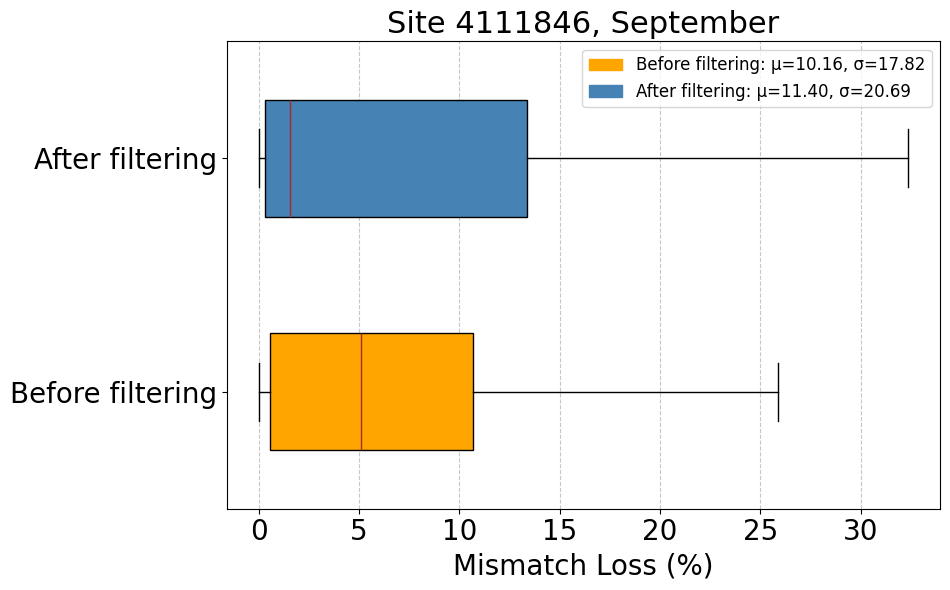

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111846_June_20250630_072121
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111846_June_20250630_072121\module_param_df.csv
df_pivot shape: (1771, 112)
2024-06-15 07:05:00 → 247639227_diode_activation=-1.0, Voc_247639227_outlier_label=1.0, Isc_247639227_outlier_label=-1.0
2024-06-15 08:15:00 → 247639227_diode_activation=-1.0, Voc_247639227_outlier_label=1.0, Isc_247639227_outlier_label=-1.0
2024-06-15 08:20:00 → 247639227_diode_activation=-1.0, Voc_247639227_outlier_label=1.0, Isc_247639227_outlier_label=-1.0
2024-06-15 08:25:00 → 247639227_diode_activation=-1.0, Voc_247639227_outlier_label=1.0, Isc_247639227_outlier_label=-1.0
2024-06-15 08:30:00 → 247639227_diode_activation=-1.0, Voc_247639227_outlier_label=1.0, Isc_247639227_outlier_label=-1.0
2024-06-15 08:35:00 → 247639

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


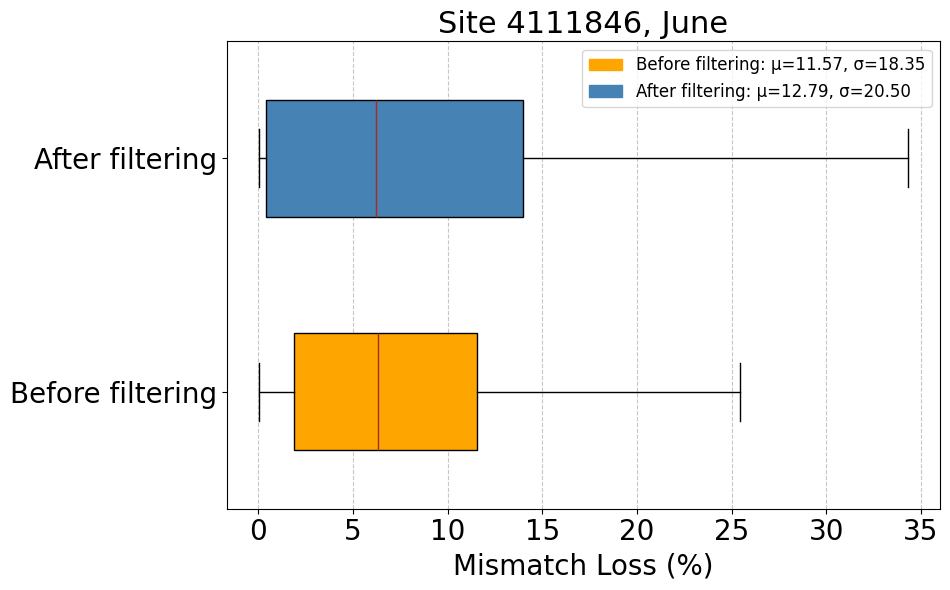

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111846_December_20250630_081057
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111846_December_20250630_081057\module_param_df.csv
df_pivot shape: (1197, 112)
2024-12-15 08:20:00 → 247639225_diode_activation=-1.0, Voc_247639225_outlier_label=1.0, Isc_247639225_outlier_label=-1.0
2024-12-15 08:25:00 → 247639225_diode_activation=-1.0, Voc_247639225_outlier_label=1.0, Isc_247639225_outlier_label=-1.0
2024-12-15 14:25:00 → 247639226_diode_activation=-1.0, Voc_247639226_outlier_label=1.0, Isc_247639226_outlier_label=-1.0
2024-12-15 14:30:00 → 247639032_diode_activation=-1.0, Voc_247639032_outlier_label=1.0, Isc_247639032_outlier_label=-1.0
2024-12-15 14:30:00 → 247639223_diode_activation=-1.0, Voc_247639223_outlier_label=1.0, Isc_247639223_outlier_label=-1.0
2024-12-15 14:30:00 

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


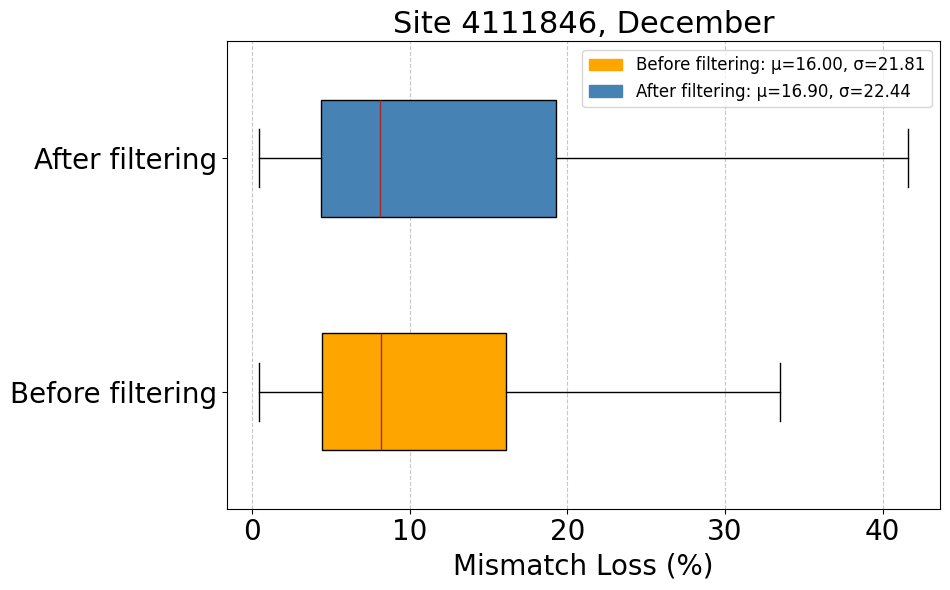

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111846_March_20250630_070455
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111846_March_20250630_070455\module_param_df.csv
df_pivot shape: (1477, 112)
2024-03-15 17:50:00 → 247639223_diode_activation=-1.0, Voc_247639223_outlier_label=1.0, Isc_247639223_outlier_label=-1.0
2024-03-16 15:00:00 → 247639028_diode_activation=-1.0, Voc_247639028_outlier_label=1.0, Isc_247639028_outlier_label=-1.0
2024-03-16 15:05:00 → 247639028_diode_activation=-1.0, Voc_247639028_outlier_label=1.0, Isc_247639028_outlier_label=-1.0
2024-03-16 15:10:00 → 247639028_diode_activation=-1.0, Voc_247639028_outlier_label=1.0, Isc_247639028_outlier_label=-1.0
2024-03-17 08:45:00 → 247639030_diode_activation=-1.0, Voc_247639030_outlier_label=1.0, Isc_247639030_outlier_label=-1.0
2024-03-17 08:50:00 → 2476

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


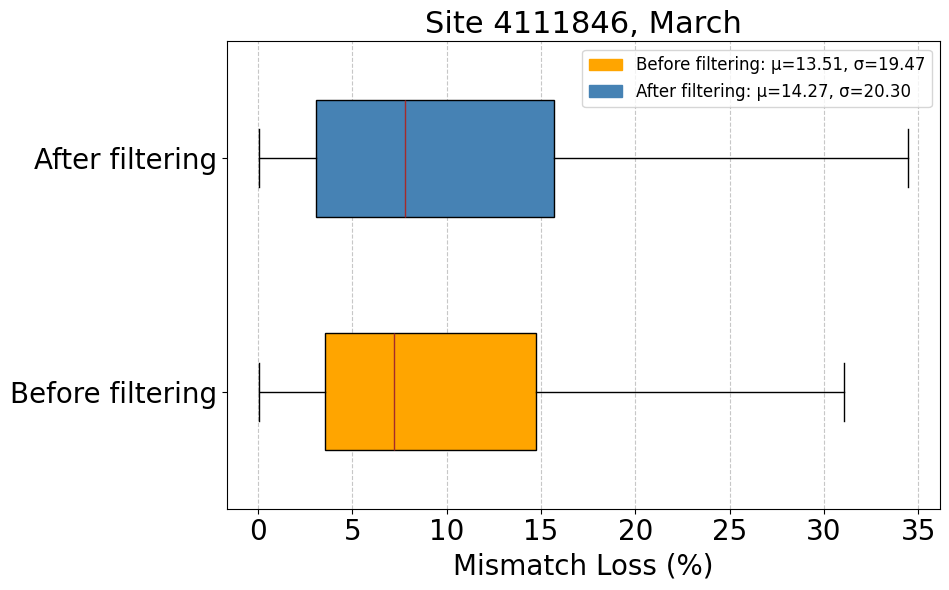

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4140175_September_20250630_133556
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4140175_September_20250630_133556\module_param_df.csv
df_pivot shape: (527, 105)
2024-09-20 09:45:00 → 258942418_diode_activation=-1.0, Voc_258942418_outlier_label=1.0, Isc_258942418_outlier_label=-1.0
2024-09-20 10:10:00 → 258942418_diode_activation=-1.0, Voc_258942418_outlier_label=1.0, Isc_258942418_outlier_label=-1.0
2024-09-20 10:15:00 → 258942418_diode_activation=-1.0, Voc_258942418_outlier_label=1.0, Isc_258942418_outlier_label=-1.0
2024-09-20 10:20:00 → 258942418_diode_activation=-1.0, Voc_258942418_outlier_label=1.0, Isc_258942418_outlier_label=-1.0
2024-09-20 10:25:00 → 258942418_diode_activation=-1.0, Voc_258942418_outlier_label=1.0, Isc_258942418_outlier_label=-1.0
2024-09-20 10:35:00

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


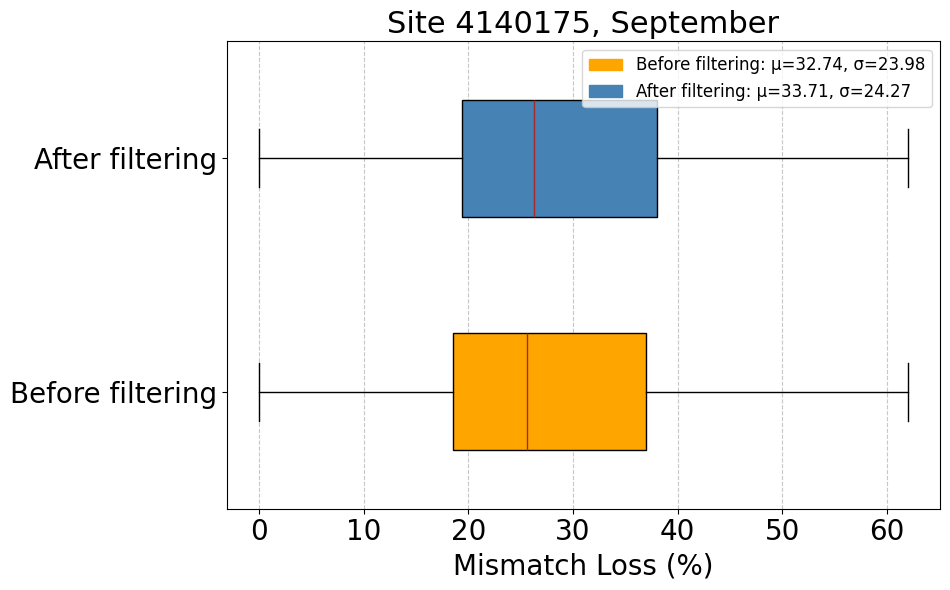

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4140175_June_20250630_141448
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4140175_June_20250630_141448\module_param_df.csv
df_pivot shape: (1196, 105)
2024-06-15 10:30:00 → 258942424_diode_activation=-1.0, Voc_258942424_outlier_label=1.0, Isc_258942424_outlier_label=-1.0
2024-06-15 10:35:00 → 258942424_diode_activation=-1.0, Voc_258942424_outlier_label=1.0, Isc_258942424_outlier_label=-1.0
2024-06-15 10:40:00 → 258942424_diode_activation=-1.0, Voc_258942424_outlier_label=1.0, Isc_258942424_outlier_label=-1.0
2024-06-15 13:40:00 → 258942424_diode_activation=-1.0, Voc_258942424_outlier_label=1.0, Isc_258942424_outlier_label=-1.0
2024-06-16 08:30:00 → 258942424_diode_activation=-1.0, Voc_258942424_outlier_label=1.0, Isc_258942424_outlier_label=-1.0
2024-06-16 08:35:00 → 258942

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


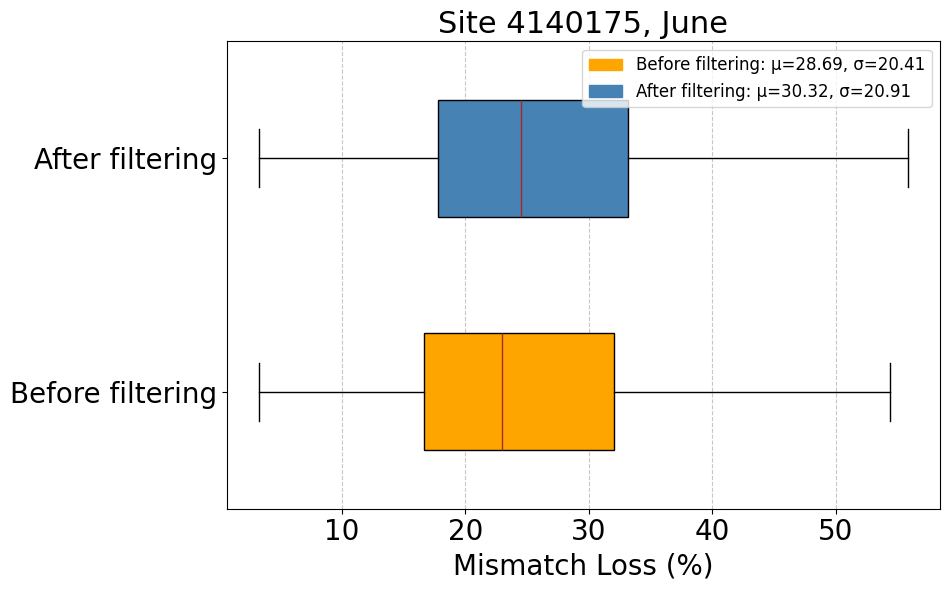

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4140175_December_20250630_134104
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4140175_December_20250630_134104\module_param_df.csv
df_pivot shape: (1717, 105)
2024-12-15 11:50:00 → 258942420_diode_activation=-1.0, Voc_258942420_outlier_label=1.0, Isc_258942420_outlier_label=-1.0
2024-12-15 11:55:00 → 258942418_diode_activation=-1.0, Voc_258942418_outlier_label=1.0, Isc_258942418_outlier_label=-1.0
2024-12-15 11:55:00 → 258942420_diode_activation=-1.0, Voc_258942420_outlier_label=1.0, Isc_258942420_outlier_label=-1.0
2024-12-15 12:00:00 → 258942418_diode_activation=-1.0, Voc_258942418_outlier_label=1.0, Isc_258942418_outlier_label=-1.0
2024-12-15 12:00:00 → 258942420_diode_activation=-1.0, Voc_258942420_outlier_label=1.0, Isc_258942420_outlier_label=-1.0
2024-12-15 12:05:00 

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


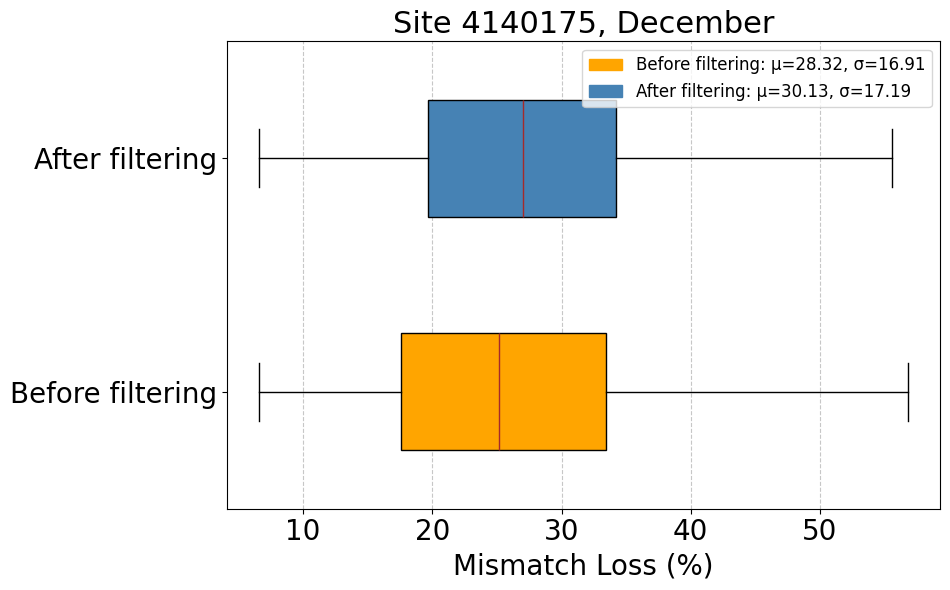

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4140175_March_20250630_135758
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4140175_March_20250630_135758\module_param_df.csv
df_pivot shape: (1443, 105)
2024-03-15 10:40:00 → 258942424_diode_activation=-1.0, Voc_258942424_outlier_label=1.0, Isc_258942424_outlier_label=-1.0
2024-03-15 10:55:00 → 258942424_diode_activation=-1.0, Voc_258942424_outlier_label=1.0, Isc_258942424_outlier_label=-1.0
2024-03-15 11:00:00 → 258942424_diode_activation=-1.0, Voc_258942424_outlier_label=1.0, Isc_258942424_outlier_label=-1.0
2024-03-15 11:15:00 → 258942424_diode_activation=-1.0, Voc_258942424_outlier_label=1.0, Isc_258942424_outlier_label=-1.0
2024-03-15 11:20:00 → 258942424_diode_activation=-1.0, Voc_258942424_outlier_label=1.0, Isc_258942424_outlier_label=-1.0
2024-03-15 11:25:00 → 2589

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


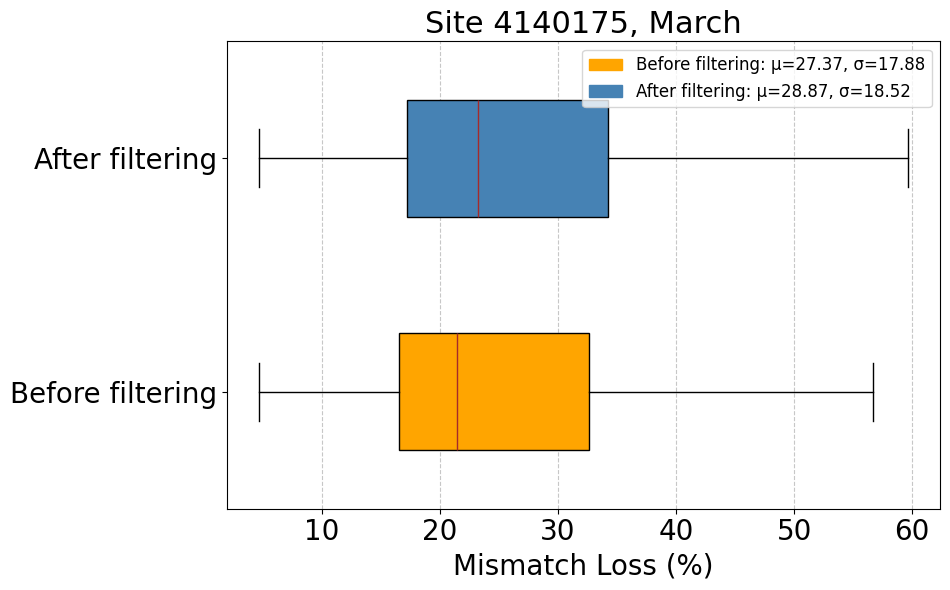

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4173851_September_20250630_180214
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4173851_September_20250630_180214\module_param_df.csv
df_pivot shape: (1450, 217)
2024-09-20 09:50:00 → 260957755_diode_activation=-1.0, Voc_260957755_outlier_label=1.0, Isc_260957755_outlier_label=-1.0
2024-09-20 09:50:00 → 260957806_diode_activation=-1.0, Voc_260957806_outlier_label=1.0, Isc_260957806_outlier_label=-1.0
2024-09-20 10:05:00 → 260957622_diode_activation=-1.0, Voc_260957622_outlier_label=1.0, Isc_260957622_outlier_label=-1.0
2024-09-20 10:10:00 → 260957622_diode_activation=-1.0, Voc_260957622_outlier_label=1.0, Isc_260957622_outlier_label=-1.0
2024-09-20 10:20:00 → 260957757_diode_activation=-1.0, Voc_260957757_outlier_label=1.0, Isc_260957757_outlier_label=-1.0
2024-09-20 10:25:0

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


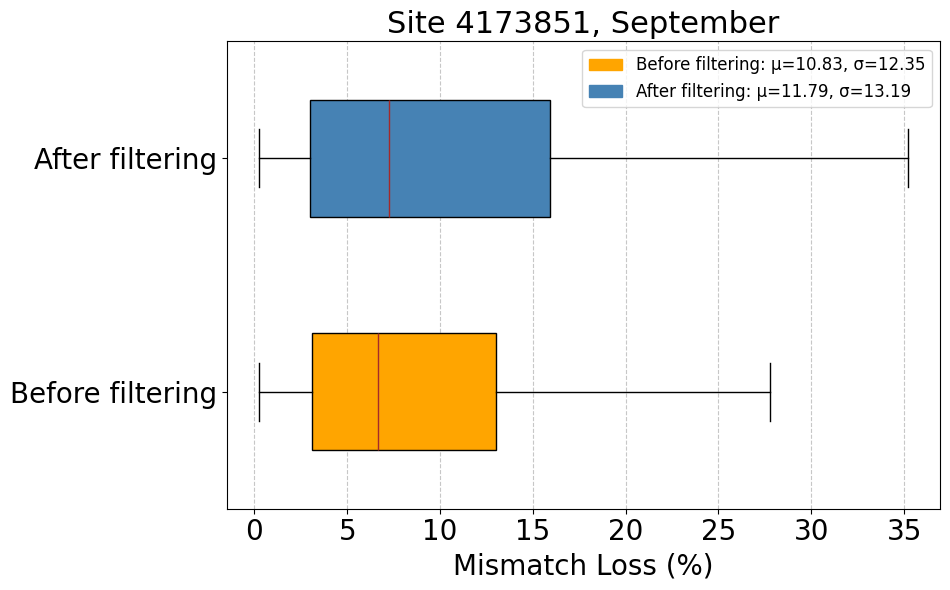

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4173851_June_20250630_173922
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4173851_June_20250630_173922\module_param_df.csv
df_pivot shape: (1922, 217)
2024-06-15 09:55:00 → 260957751_diode_activation=-1.0, Voc_260957751_outlier_label=1.0, Isc_260957751_outlier_label=-1.0
2024-06-15 09:55:00 → 260957976_diode_activation=-1.0, Voc_260957976_outlier_label=1.0, Isc_260957976_outlier_label=-1.0
2024-06-15 10:00:00 → 260957453_diode_activation=-1.0, Voc_260957453_outlier_label=1.0, Isc_260957453_outlier_label=-1.0
2024-06-15 10:00:00 → 260957751_diode_activation=-1.0, Voc_260957751_outlier_label=1.0, Isc_260957751_outlier_label=-1.0
2024-06-15 10:05:00 → 260957453_diode_activation=-1.0, Voc_260957453_outlier_label=1.0, Isc_260957453_outlier_label=-1.0
2024-06-15 10:05:00 → 260957

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


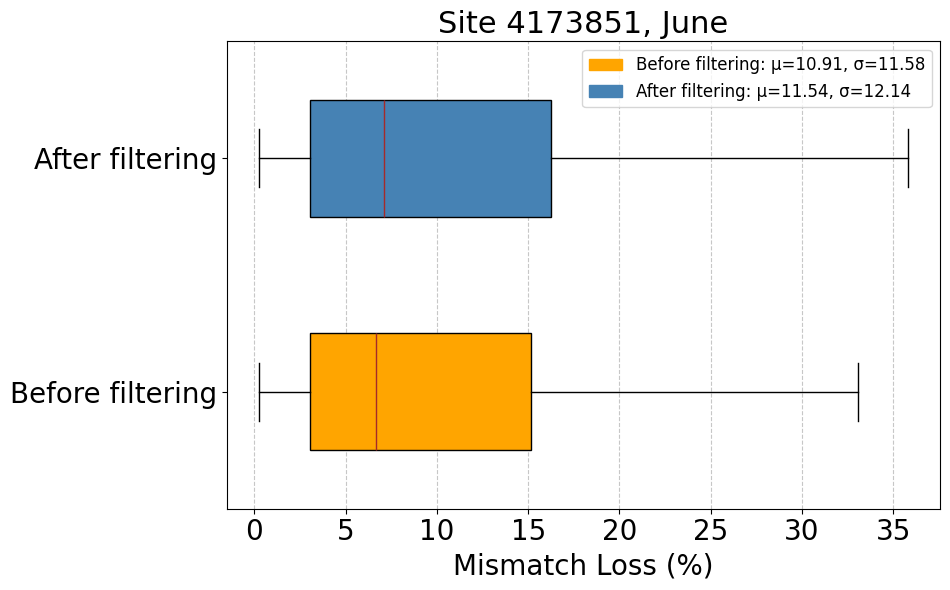

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4173851_December_20250630_182137
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4173851_December_20250630_182137\module_param_df.csv
df_pivot shape: (986, 217)
2024-12-15 11:55:00 → 260957806_diode_activation=-1.0, Voc_260957806_outlier_label=1.0, Isc_260957806_outlier_label=-1.0
2024-12-15 12:00:00 → 260957806_diode_activation=-1.0, Voc_260957806_outlier_label=1.0, Isc_260957806_outlier_label=-1.0
2024-12-16 12:05:00 → 260957806_diode_activation=-1.0, Voc_260957806_outlier_label=1.0, Isc_260957806_outlier_label=-1.0
2024-12-16 12:15:00 → 260957806_diode_activation=-1.0, Voc_260957806_outlier_label=1.0, Isc_260957806_outlier_label=-1.0
2024-12-16 12:20:00 → 260957806_diode_activation=-1.0, Voc_260957806_outlier_label=1.0, Isc_260957806_outlier_label=-1.0
2024-12-16 13:15:00 →

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


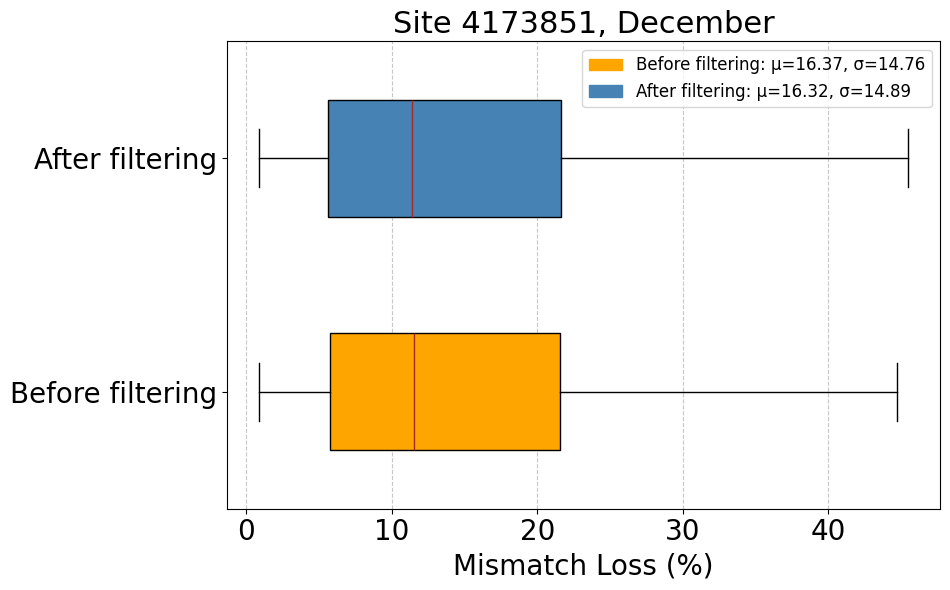

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4173851_March_20250630_172233
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4173851_March_20250630_172233\module_param_df.csv
df_pivot shape: (1465, 217)
2024-03-16 13:20:00 → 260957750_diode_activation=-1.0, Voc_260957750_outlier_label=1.0, Isc_260957750_outlier_label=-1.0
2024-03-16 13:20:00 → 260957977_diode_activation=-1.0, Voc_260957977_outlier_label=1.0, Isc_260957977_outlier_label=-1.0
2024-03-16 14:40:00 → 260957750_diode_activation=-1.0, Voc_260957750_outlier_label=1.0, Isc_260957750_outlier_label=-1.0
2024-03-16 16:30:00 → 260957805_diode_activation=-1.0, Voc_260957805_outlier_label=1.0, Isc_260957805_outlier_label=-1.0
2024-03-16 16:35:00 → 260957805_diode_activation=-1.0, Voc_260957805_outlier_label=1.0, Isc_260957805_outlier_label=-1.0
2024-03-18 13:40:00 → 2609

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


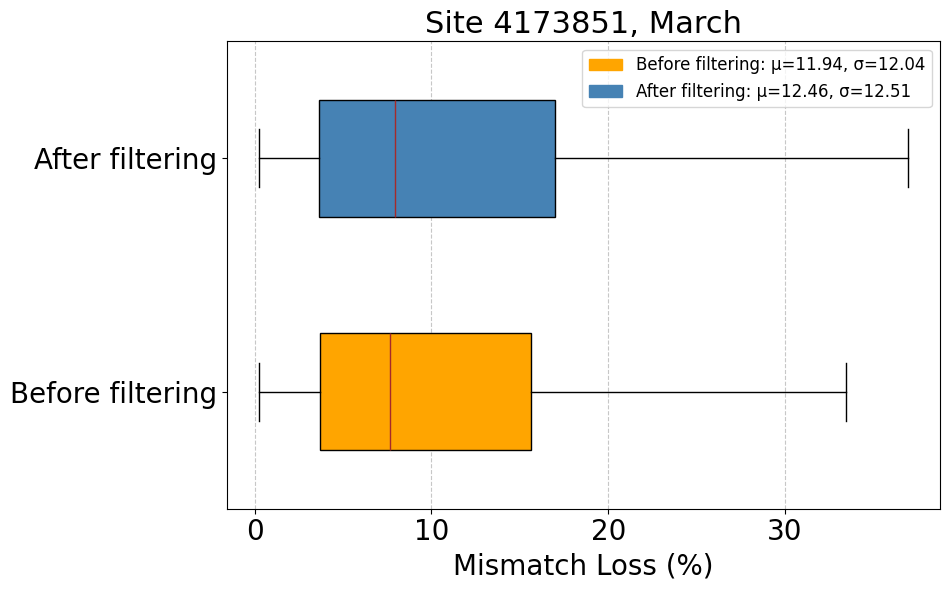

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4123602_September_20250630_130720
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4123602_September_20250630_130720\module_param_df.csv
df_pivot shape: (1460, 112)
2024-09-20 12:15:00 → 256284251_diode_activation=-1.0, Voc_256284251_outlier_label=1.0, Isc_256284251_outlier_label=-1.0
2024-09-20 12:35:00 → 256284251_diode_activation=-1.0, Voc_256284251_outlier_label=1.0, Isc_256284251_outlier_label=-1.0
2024-09-20 13:05:00 → 256284251_diode_activation=-1.0, Voc_256284251_outlier_label=1.0, Isc_256284251_outlier_label=-1.0
2024-09-20 13:10:00 → 256284251_diode_activation=-1.0, Voc_256284251_outlier_label=1.0, Isc_256284251_outlier_label=-1.0
2024-09-20 13:15:00 → 256284251_diode_activation=-1.0, Voc_256284251_outlier_label=1.0, Isc_256284251_outlier_label=-1.0
2024-09-20 13:20:0

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


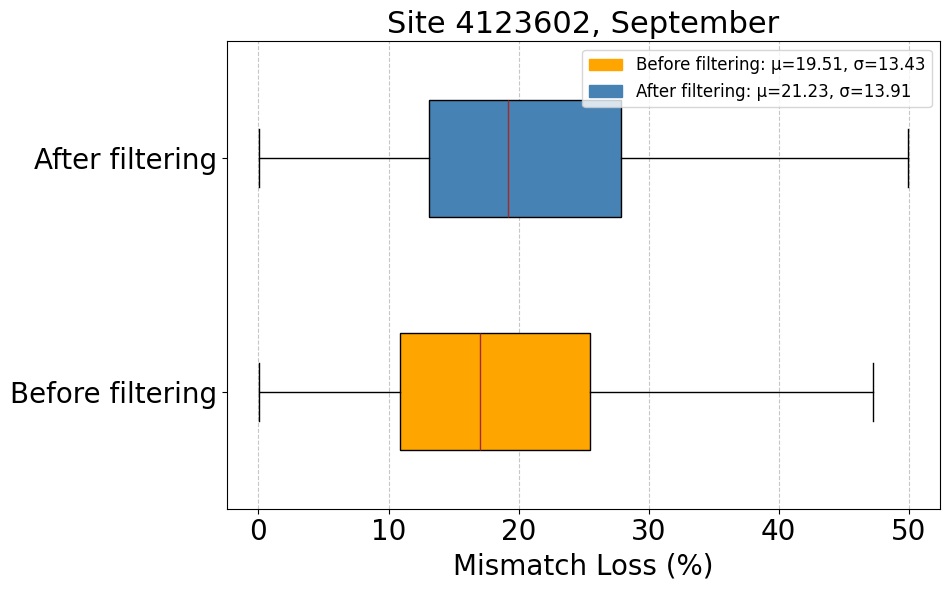

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4123602_June_20250630_124258
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4123602_June_20250630_124258\module_param_df.csv
df_pivot shape: (1687, 112)
2024-06-15 12:40:00 → 256284251_diode_activation=-1.0, Voc_256284251_outlier_label=1.0, Isc_256284251_outlier_label=-1.0
2024-06-15 12:45:00 → 256284251_diode_activation=-1.0, Voc_256284251_outlier_label=1.0, Isc_256284251_outlier_label=-1.0
2024-06-15 12:50:00 → 256284251_diode_activation=-1.0, Voc_256284251_outlier_label=1.0, Isc_256284251_outlier_label=-1.0
2024-06-15 12:55:00 → 256284251_diode_activation=-1.0, Voc_256284251_outlier_label=1.0, Isc_256284251_outlier_label=-1.0
2024-06-15 13:00:00 → 256284251_diode_activation=-1.0, Voc_256284251_outlier_label=1.0, Isc_256284251_outlier_label=-1.0
2024-06-15 13:05:00 → 256284

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


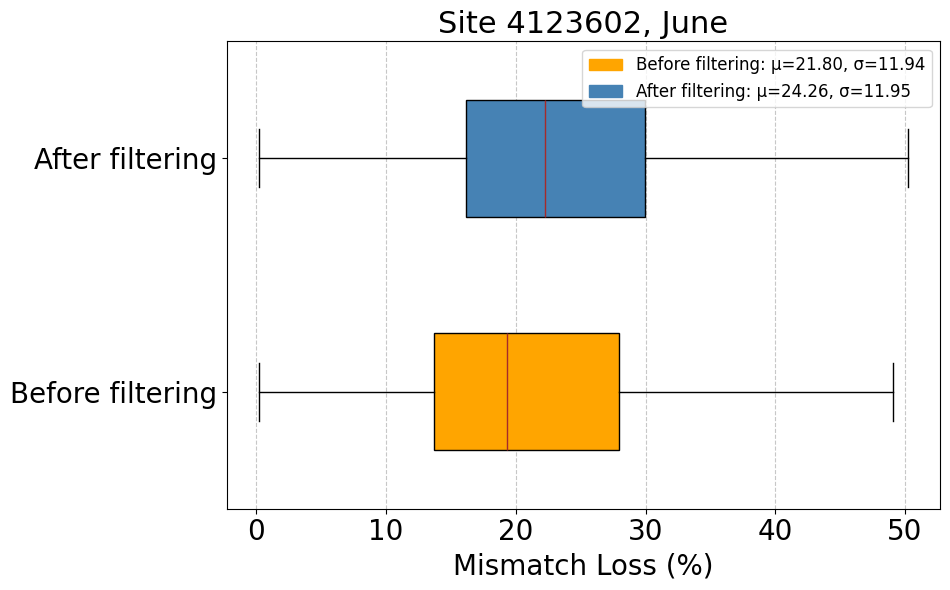

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4123602_December_20250630_132255
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4123602_December_20250630_132255\module_param_df.csv
df_pivot shape: (1246, 112)
2024-12-15 10:00:00 → 256284256_diode_activation=-1.0, Voc_256284256_outlier_label=1.0, Isc_256284256_outlier_label=-1.0
2024-12-15 14:50:00 → 256284251_diode_activation=-1.0, Voc_256284251_outlier_label=1.0, Isc_256284251_outlier_label=-1.0
2024-12-15 14:55:00 → 256284251_diode_activation=-1.0, Voc_256284251_outlier_label=1.0, Isc_256284251_outlier_label=-1.0
2024-12-15 15:00:00 → 256284251_diode_activation=-1.0, Voc_256284251_outlier_label=1.0, Isc_256284251_outlier_label=-1.0
2024-12-15 15:05:00 → 256284251_diode_activation=-1.0, Voc_256284251_outlier_label=1.0, Isc_256284251_outlier_label=-1.0
2024-12-15 15:10:00 

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


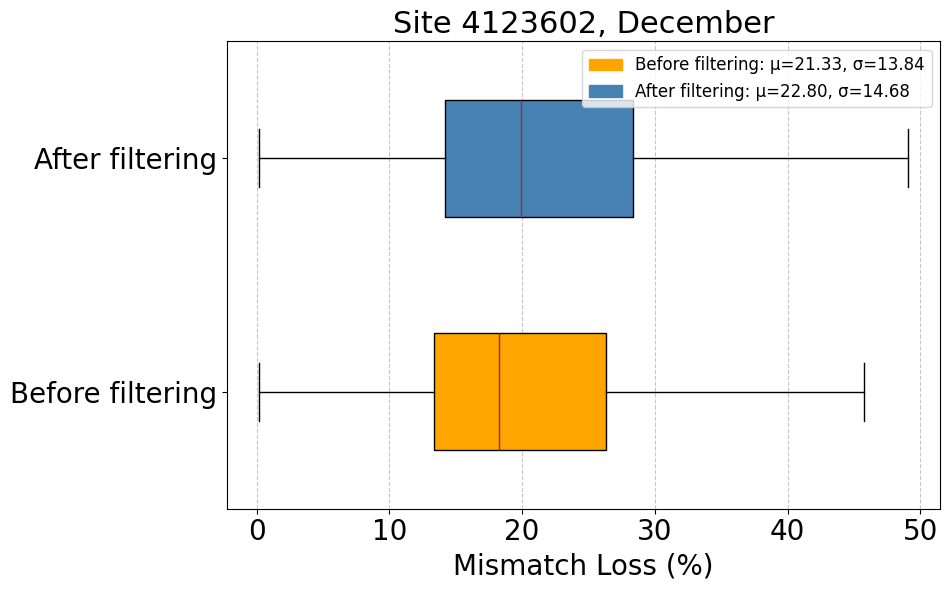

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4123602_March_20250630_122819
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4123602_March_20250630_122819\module_param_df.csv
df_pivot shape: (1408, 112)
2024-03-15 09:40:00 → 256284251_diode_activation=-1.0, Voc_256284251_outlier_label=1.0, Isc_256284251_outlier_label=-1.0
2024-03-15 09:50:00 → 256284251_diode_activation=-1.0, Voc_256284251_outlier_label=1.0, Isc_256284251_outlier_label=-1.0
2024-03-15 09:55:00 → 256284251_diode_activation=-1.0, Voc_256284251_outlier_label=1.0, Isc_256284251_outlier_label=-1.0
2024-03-15 12:00:00 → 256284251_diode_activation=-1.0, Voc_256284251_outlier_label=1.0, Isc_256284251_outlier_label=-1.0
2024-03-15 13:40:00 → 256284251_diode_activation=-1.0, Voc_256284251_outlier_label=1.0, Isc_256284251_outlier_label=-1.0
2024-03-15 13:55:00 → 2562

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


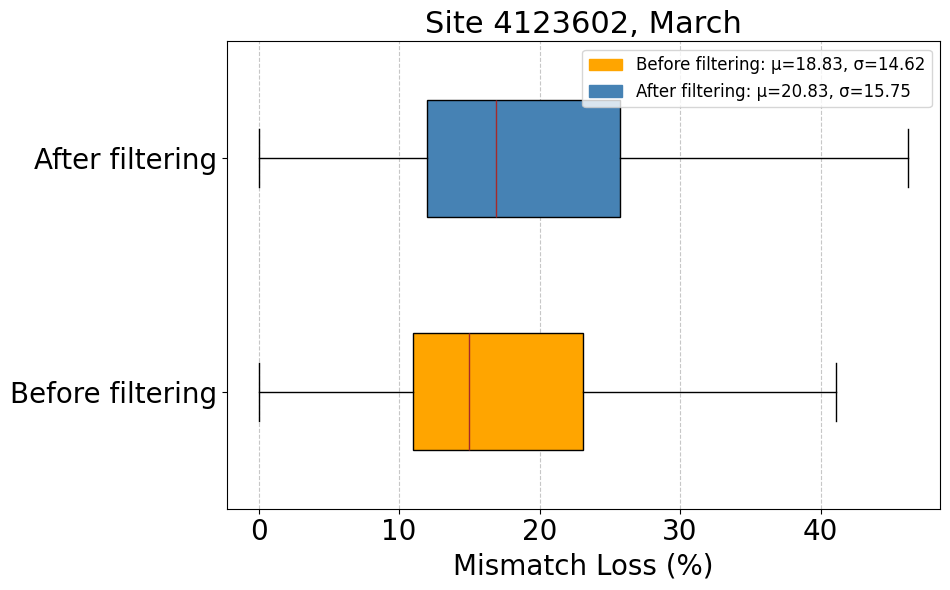

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4093272_September_20250630_035320
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4093272_September_20250630_035320\module_param_df.csv
df_pivot shape: (1441, 126)
2024-09-20 09:10:00 → 164811443_diode_activation=-1.0, Voc_164811443_outlier_label=1.0, Isc_164811443_outlier_label=-1.0
2024-09-20 09:20:00 → 164811443_diode_activation=-1.0, Voc_164811443_outlier_label=1.0, Isc_164811443_outlier_label=-1.0
2024-09-20 09:25:00 → 164811443_diode_activation=-1.0, Voc_164811443_outlier_label=1.0, Isc_164811443_outlier_label=-1.0
2024-09-20 09:30:00 → 164811443_diode_activation=-1.0, Voc_164811443_outlier_label=1.0, Isc_164811443_outlier_label=-1.0
2024-09-20 09:35:00 → 164811443_diode_activation=-1.0, Voc_164811443_outlier_label=1.0, Isc_164811443_outlier_label=-1.0
2024-09-20 10:10:0

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


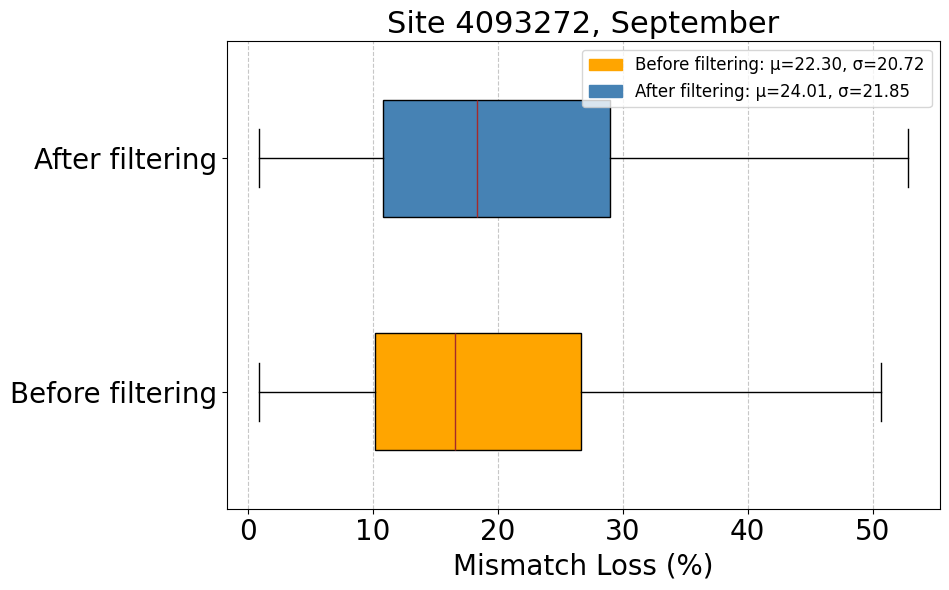

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4093272_June_20250630_033139
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4093272_June_20250630_033139\module_param_df.csv
df_pivot shape: (1961, 126)
2024-06-15 15:45:00 → 164811441_diode_activation=-1.0, Voc_164811441_outlier_label=1.0, Isc_164811441_outlier_label=-1.0
2024-06-15 15:50:00 → 164811441_diode_activation=-1.0, Voc_164811441_outlier_label=1.0, Isc_164811441_outlier_label=-1.0
2024-06-15 16:05:00 → 164811441_diode_activation=-1.0, Voc_164811441_outlier_label=1.0, Isc_164811441_outlier_label=-1.0
2024-06-15 16:10:00 → 164811441_diode_activation=-1.0, Voc_164811441_outlier_label=1.0, Isc_164811441_outlier_label=-1.0
2024-06-15 16:30:00 → 164811482_diode_activation=-1.0, Voc_164811482_outlier_label=1.0, Isc_164811482_outlier_label=-1.0
2024-06-15 16:30:00 → 164811

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


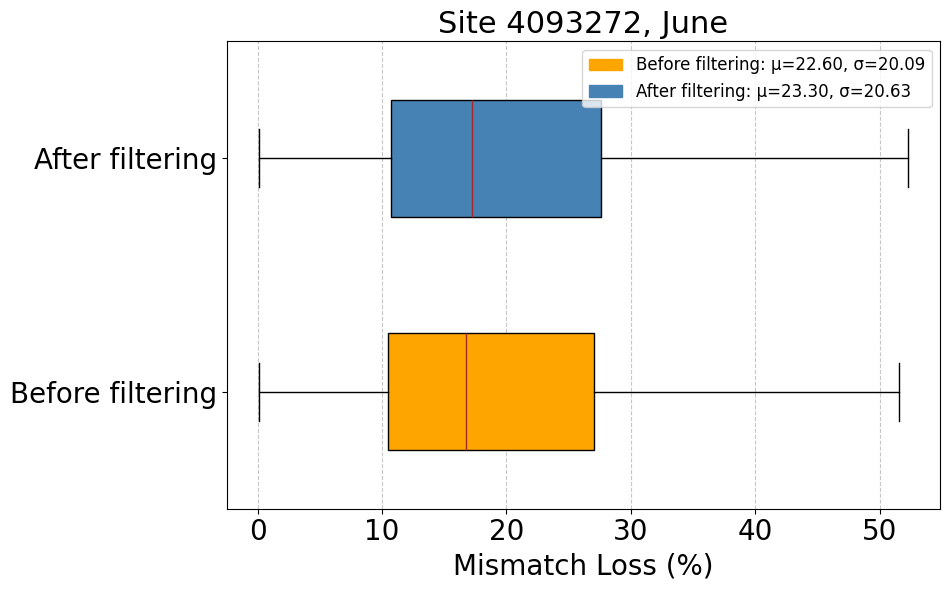

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4093272_December_20250630_041022
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4093272_December_20250630_041022\module_param_df.csv
df_pivot shape: (871, 126)
2024-12-22 15:50:00 → 164811443_diode_activation=1.0, Voc_164811443_outlier_label=-1.0, Isc_164811443_outlier_label=0.0
2024-12-22 15:55:00 → 164811443_diode_activation=1.0, Voc_164811443_outlier_label=-1.0, Isc_164811443_outlier_label=0.0
2024-12-22 16:00:00 → 164811443_diode_activation=1.0, Voc_164811443_outlier_label=-1.0, Isc_164811443_outlier_label=0.0
Looking for combined file in C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4093272_December_20250630_041022
Original combined data shape: (871, 4)
New combined data shape (after removing diode activ

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


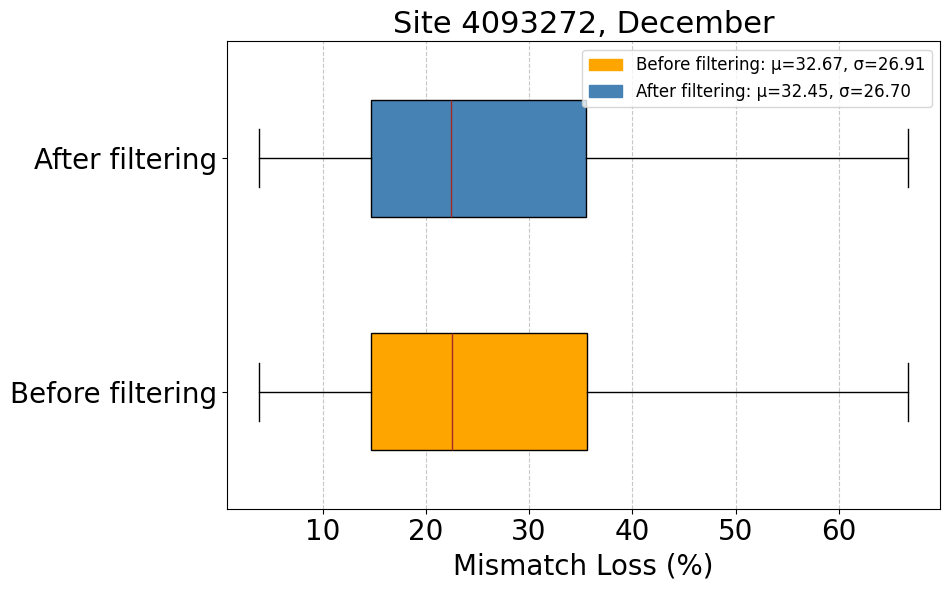

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4093272_March_20250630_031555
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4093272_March_20250630_031555\module_param_df.csv
df_pivot shape: (1425, 126)
2024-03-16 13:40:00 → 164811484_diode_activation=-1.0, Voc_164811484_outlier_label=1.0, Isc_164811484_outlier_label=-1.0
2024-03-17 08:20:00 → 164811443_diode_activation=-1.0, Voc_164811443_outlier_label=1.0, Isc_164811443_outlier_label=-1.0
2024-03-17 08:45:00 → 164811443_diode_activation=-1.0, Voc_164811443_outlier_label=1.0, Isc_164811443_outlier_label=-1.0
2024-03-17 08:50:00 → 164811443_diode_activation=-1.0, Voc_164811443_outlier_label=1.0, Isc_164811443_outlier_label=-1.0
2024-03-17 12:15:00 → 164811482_diode_activation=-1.0, Voc_164811482_outlier_label=1.0, Isc_164811482_outlier_label=-1.0
2024-03-17 12:20:00 → 1648

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


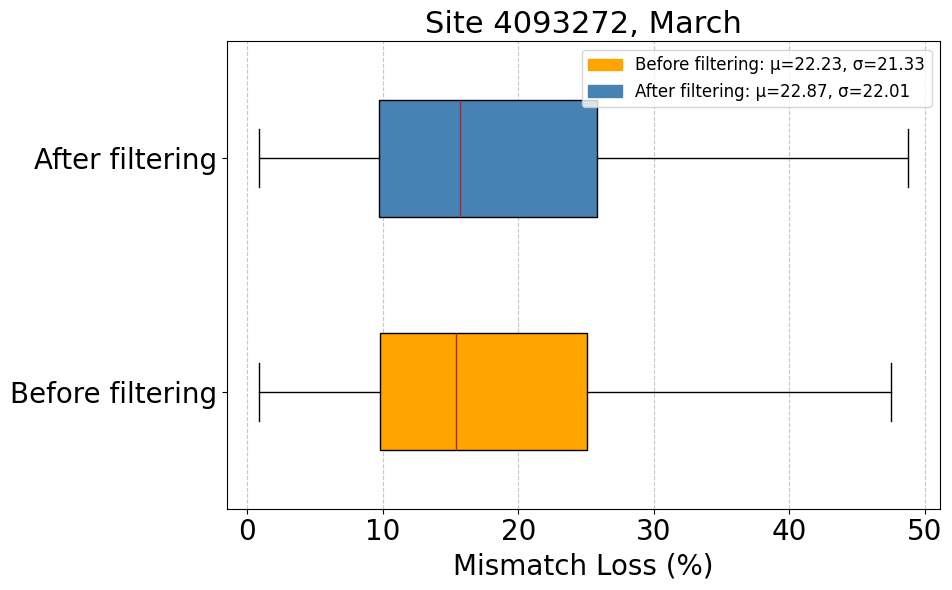

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4186157_September_20250630_232836
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4186157_September_20250630_232836\module_param_df.csv
df_pivot shape: (1482, 217)
2024-09-20 08:50:00 → 260028826_diode_activation=-1.0, Voc_260028826_outlier_label=1.0, Isc_260028826_outlier_label=-1.0
2024-09-20 08:50:00 → 260028882_diode_activation=-1.0, Voc_260028882_outlier_label=1.0, Isc_260028882_outlier_label=-1.0
2024-09-20 08:50:00 → 260028901_diode_activation=-1.0, Voc_260028901_outlier_label=1.0, Isc_260028901_outlier_label=-1.0
2024-09-20 08:55:00 → 260028826_diode_activation=-1.0, Voc_260028826_outlier_label=1.0, Isc_260028826_outlier_label=-1.0
2024-09-20 08:55:00 → 260028882_diode_activation=-1.0, Voc_260028882_outlier_label=1.0, Isc_260028882_outlier_label=-1.0
2024-09-20 08:55:0

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


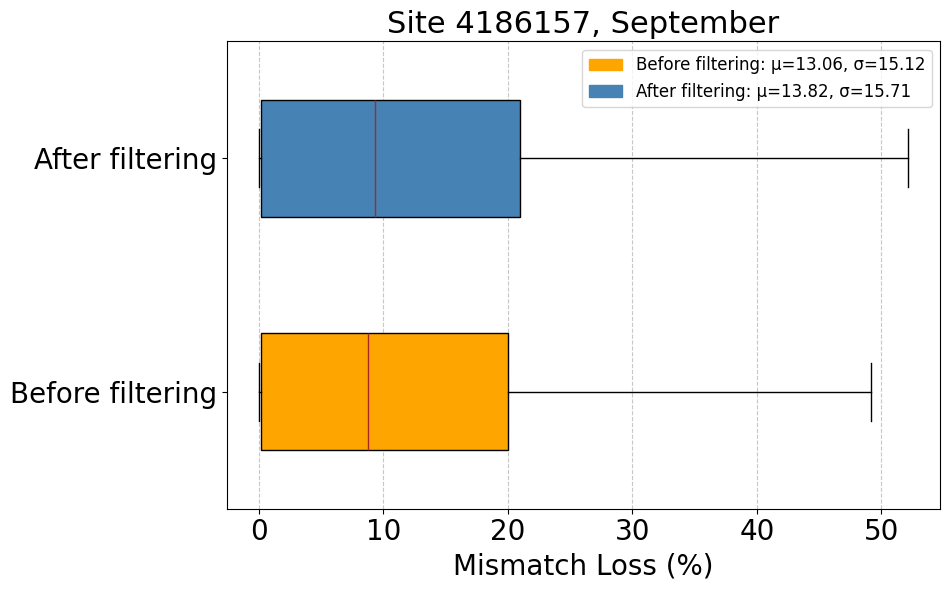

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4186157_June_20250630_230433
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4186157_June_20250630_230433\module_param_df.csv
df_pivot shape: (1692, 217)
2024-06-15 09:00:00 → 260028884_diode_activation=-1.0, Voc_260028884_outlier_label=1.0, Isc_260028884_outlier_label=-1.0
2024-06-15 09:05:00 → 260028884_diode_activation=-1.0, Voc_260028884_outlier_label=1.0, Isc_260028884_outlier_label=-1.0
2024-06-15 17:50:00 → 260028901_diode_activation=-1.0, Voc_260028901_outlier_label=1.0, Isc_260028901_outlier_label=-1.0
2024-06-15 18:05:00 → 260028792_diode_activation=-1.0, Voc_260028792_outlier_label=1.0, Isc_260028792_outlier_label=-1.0
2024-06-15 18:05:00 → 260028901_diode_activation=-1.0, Voc_260028901_outlier_label=1.0, Isc_260028901_outlier_label=-1.0
2024-06-15 18:10:00 → 260028

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


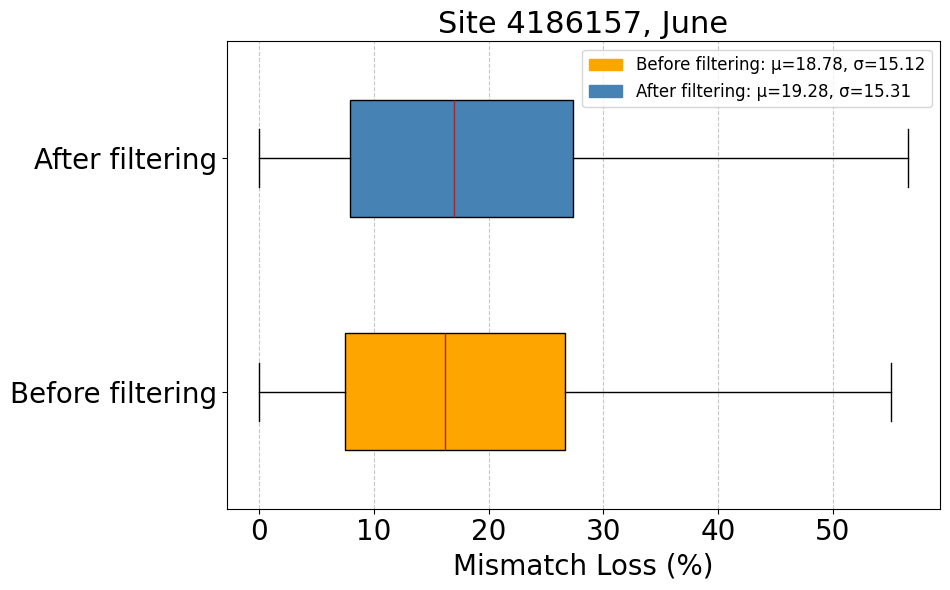

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4186157_December_20250701_000003
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4186157_December_20250701_000003\module_param_df.csv
df_pivot shape: (1259, 217)
2024-12-16 16:50:00 → 260028829_diode_activation=-1.0, Voc_260028829_outlier_label=1.0, Isc_260028829_outlier_label=-1.0
2024-12-16 16:55:00 → 260028829_diode_activation=-1.0, Voc_260028829_outlier_label=1.0, Isc_260028829_outlier_label=-1.0
2024-12-16 16:55:00 → 260028885_diode_activation=-1.0, Voc_260028885_outlier_label=1.0, Isc_260028885_outlier_label=-1.0
2024-12-16 16:55:00 → 260028888_diode_activation=-1.0, Voc_260028888_outlier_label=1.0, Isc_260028888_outlier_label=-1.0
2024-12-16 16:55:00 → 260028901_diode_activation=-1.0, Voc_260028901_outlier_label=1.0, Isc_260028901_outlier_label=-1.0
2024-12-16 17:00:00 

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


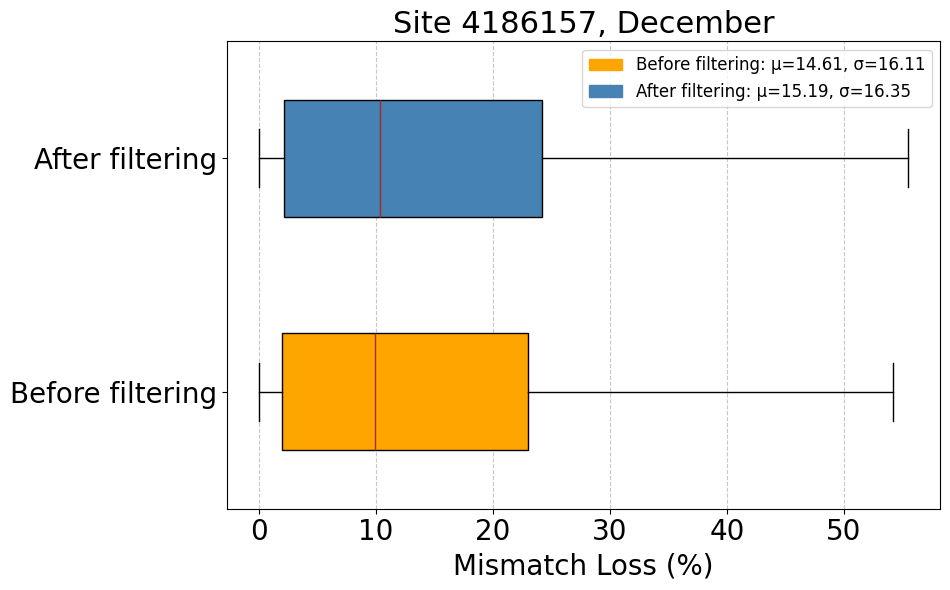

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4186157_March_20250630_224353
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4186157_March_20250630_224353\module_param_df.csv
df_pivot shape: (986, 217)
2024-03-19 09:05:00 → 260028884_diode_activation=-1.0, Voc_260028884_outlier_label=1.0, Isc_260028884_outlier_label=-1.0
2024-03-19 09:15:00 → 260028826_diode_activation=-1.0, Voc_260028826_outlier_label=1.0, Isc_260028826_outlier_label=-1.0
2024-03-19 09:15:00 → 260028882_diode_activation=-1.0, Voc_260028882_outlier_label=1.0, Isc_260028882_outlier_label=-1.0
2024-03-19 09:15:00 → 260028884_diode_activation=-1.0, Voc_260028884_outlier_label=1.0, Isc_260028884_outlier_label=-1.0
2024-03-19 09:20:00 → 260028884_diode_activation=-1.0, Voc_260028884_outlier_label=1.0, Isc_260028884_outlier_label=-1.0
2024-03-19 09:25:00 → 26002

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


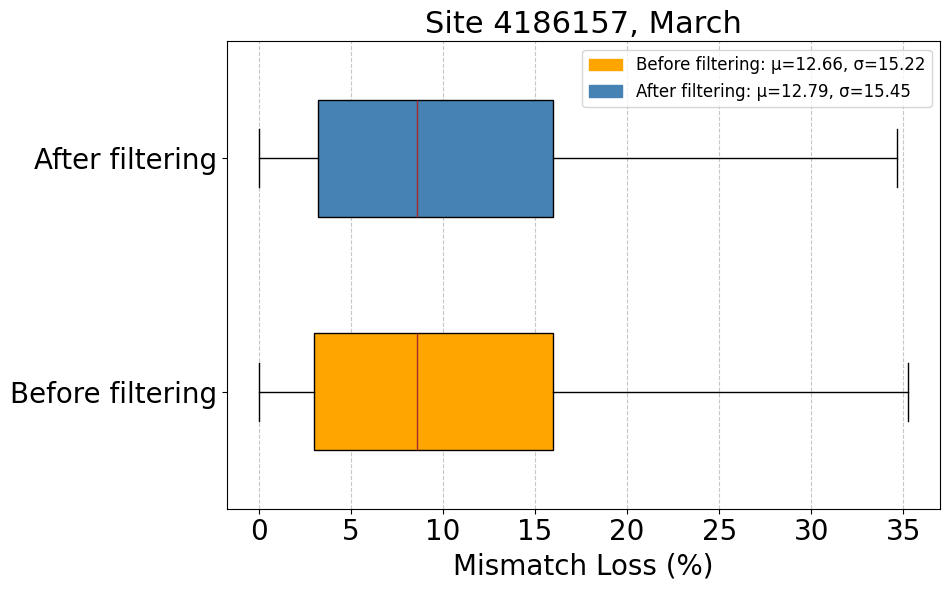

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4112053_September_20250630_090700
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4112053_September_20250630_090700\module_param_df.csv
df_pivot shape: (1455, 140)
2024-09-20 09:55:00 → 257486236_diode_activation=-1.0, Voc_257486236_outlier_label=1.0, Isc_257486236_outlier_label=-1.0
2024-09-20 10:00:00 → 257486236_diode_activation=-1.0, Voc_257486236_outlier_label=1.0, Isc_257486236_outlier_label=-1.0
2024-09-20 10:00:00 → 257486240_diode_activation=-1.0, Voc_257486240_outlier_label=1.0, Isc_257486240_outlier_label=-1.0
2024-09-20 16:00:00 → 257486244_diode_activation=-1.0, Voc_257486244_outlier_label=1.0, Isc_257486244_outlier_label=-1.0
2024-09-20 16:05:00 → 257486244_diode_activation=-1.0, Voc_257486244_outlier_label=1.0, Isc_257486244_outlier_label=-1.0
2024-09-20 16:10:0

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


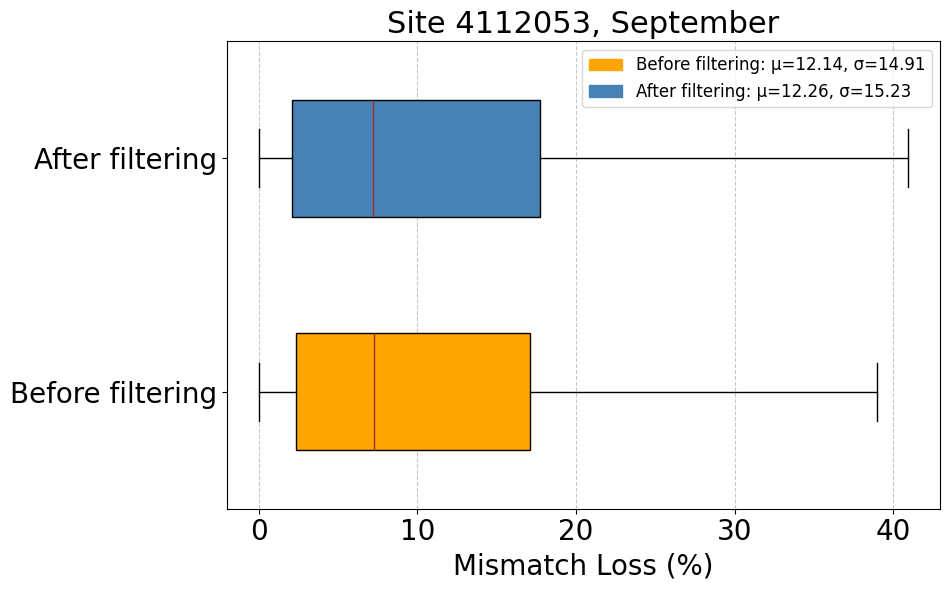

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4112053_June_20250630_083838
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4112053_June_20250630_083838\module_param_df.csv
df_pivot shape: (2047, 140)
2024-06-15 06:00:00 → 257486233_diode_activation=1.0, Voc_257486233_outlier_label=-1.0, Isc_257486233_outlier_label=0.0
2024-06-18 06:30:00 → 257486240_diode_activation=1.0, Voc_257486240_outlier_label=-1.0, Isc_257486240_outlier_label=0.0
2024-06-18 09:20:00 → 257486233_diode_activation=-1.0, Voc_257486233_outlier_label=1.0, Isc_257486233_outlier_label=-1.0
2024-06-19 13:15:00 → 257486237_diode_activation=-1.0, Voc_257486237_outlier_label=1.0, Isc_257486237_outlier_label=-1.0
Looking for combined file in C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4112053_

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


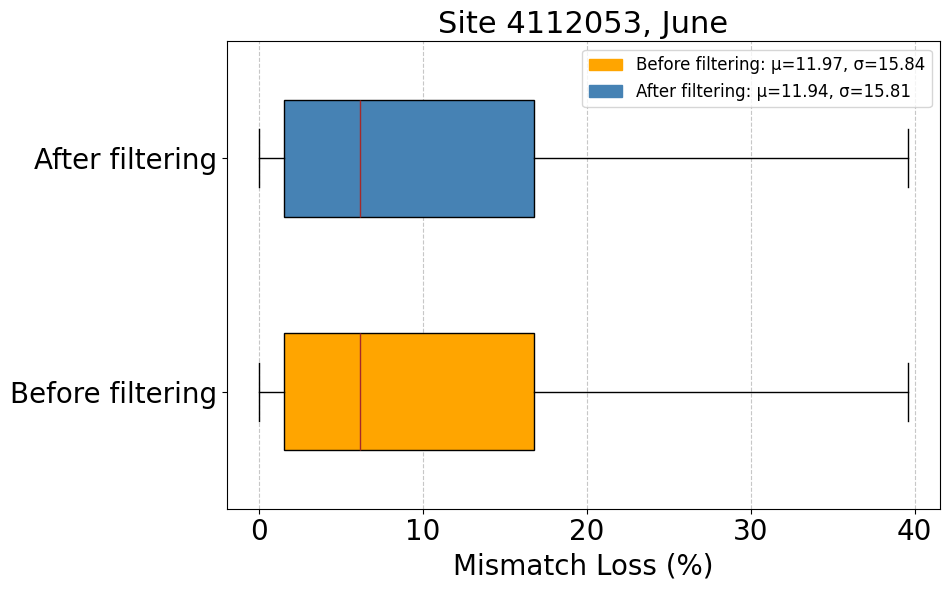

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4112053_December_20250630_092405
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4112053_December_20250630_092405\module_param_df.csv
df_pivot shape: (906, 140)
2024-12-16 15:55:00 → 257486234_diode_activation=1.0, Voc_257486234_outlier_label=-1.0, Isc_257486234_outlier_label=0.0
2024-12-20 11:20:00 → 257486244_diode_activation=-1.0, Voc_257486244_outlier_label=1.0, Isc_257486244_outlier_label=-1.0
2024-12-20 11:30:00 → 257486244_diode_activation=-1.0, Voc_257486244_outlier_label=1.0, Isc_257486244_outlier_label=-1.0
2024-12-20 11:35:00 → 257486238_diode_activation=-1.0, Voc_257486238_outlier_label=1.0, Isc_257486238_outlier_label=-1.0
2024-12-20 11:35:00 → 257486244_diode_activation=-1.0, Voc_257486244_outlier_label=1.0, Isc_257486244_outlier_label=-1.0
2024-12-20 11:35:00 → 

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


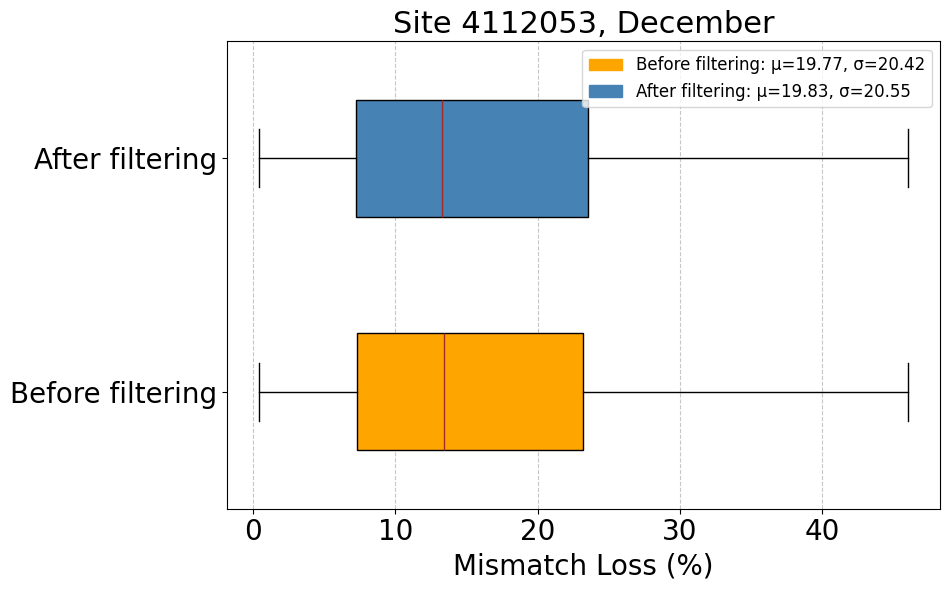

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4112053_March_20250630_082214
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4112053_March_20250630_082214\module_param_df.csv
df_pivot shape: (1462, 140)
2024-03-18 15:00:00 → 257486244_diode_activation=-1.0, Voc_257486244_outlier_label=1.0, Isc_257486244_outlier_label=-1.0
2024-03-18 15:35:00 → 257486244_diode_activation=-1.0, Voc_257486244_outlier_label=1.0, Isc_257486244_outlier_label=-1.0
2024-03-18 15:40:00 → 257486244_diode_activation=-1.0, Voc_257486244_outlier_label=1.0, Isc_257486244_outlier_label=-1.0
2024-03-18 15:45:00 → 257486244_diode_activation=-1.0, Voc_257486244_outlier_label=1.0, Isc_257486244_outlier_label=-1.0
2024-03-18 15:50:00 → 257486244_diode_activation=-1.0, Voc_257486244_outlier_label=1.0, Isc_257486244_outlier_label=-1.0
2024-03-18 15:55:00 → 2574

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


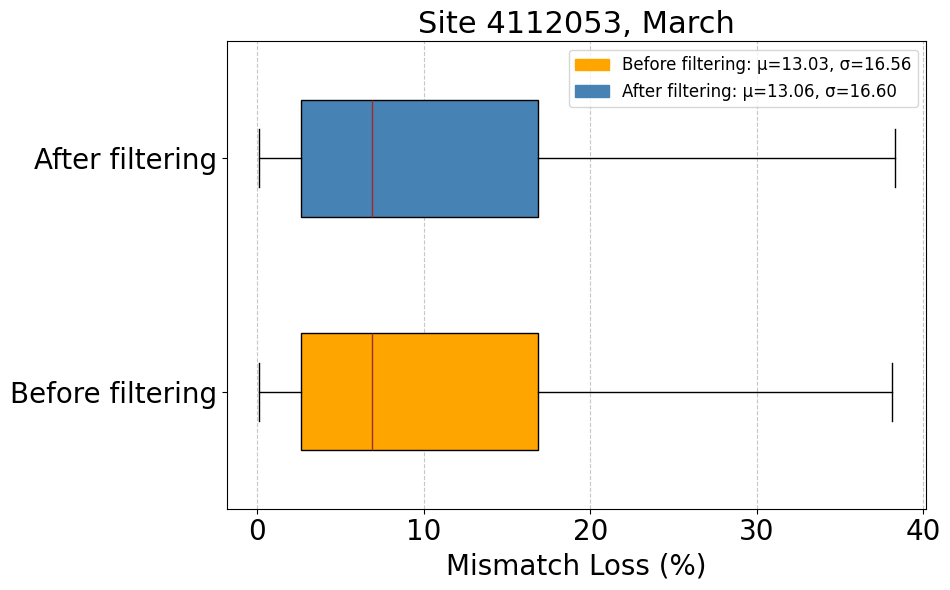

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4118327_September_20250630_104444
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4118327_September_20250630_104444\module_param_df.csv
df_pivot shape: (1488, 224)
2024-09-23 18:45:00 → 257820181_diode_activation=1.0, Voc_257820181_outlier_label=-1.0, Isc_257820181_outlier_label=0.0
2024-09-25 17:35:00 → 257820181_diode_activation=1.0, Voc_257820181_outlier_label=-1.0, Isc_257820181_outlier_label=0.0
Looking for combined file in C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4118327_September_20250630_104444
Original combined data shape: (1488, 4)
New combined data shape (after removing diode activation timestamps): (1486, 4)
Columns in combined_df: ['Sum of I*V (W)', 'Pmppt (W)', 'Season', 'Site ID']


C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


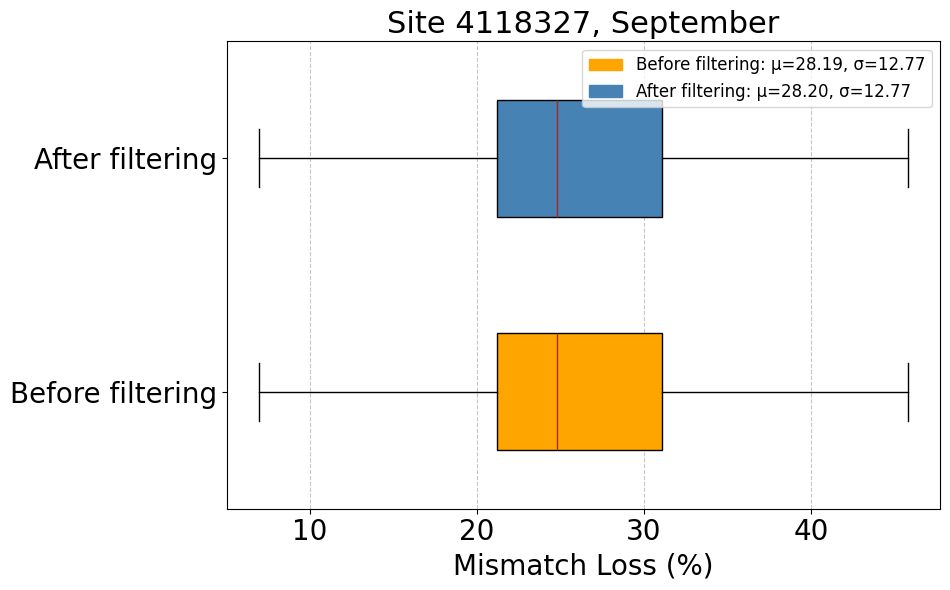

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4118327_June_20250630_102021
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4118327_June_20250630_102021\module_param_df.csv
df_pivot shape: (1743, 224)
2024-06-15 09:10:00 → 257826382_diode_activation=-1.0, Voc_257826382_outlier_label=1.0, Isc_257826382_outlier_label=-1.0
2024-06-15 09:15:00 → 257826382_diode_activation=-1.0, Voc_257826382_outlier_label=1.0, Isc_257826382_outlier_label=-1.0
2024-06-15 09:20:00 → 257826382_diode_activation=-1.0, Voc_257826382_outlier_label=1.0, Isc_257826382_outlier_label=-1.0
2024-06-15 09:25:00 → 257825991_diode_activation=-1.0, Voc_257825991_outlier_label=1.0, Isc_257825991_outlier_label=-1.0
2024-06-15 09:25:00 → 257826382_diode_activation=-1.0, Voc_257826382_outlier_label=1.0, Isc_257826382_outlier_label=-1.0
2024-06-15 09:30:00 → 257826

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


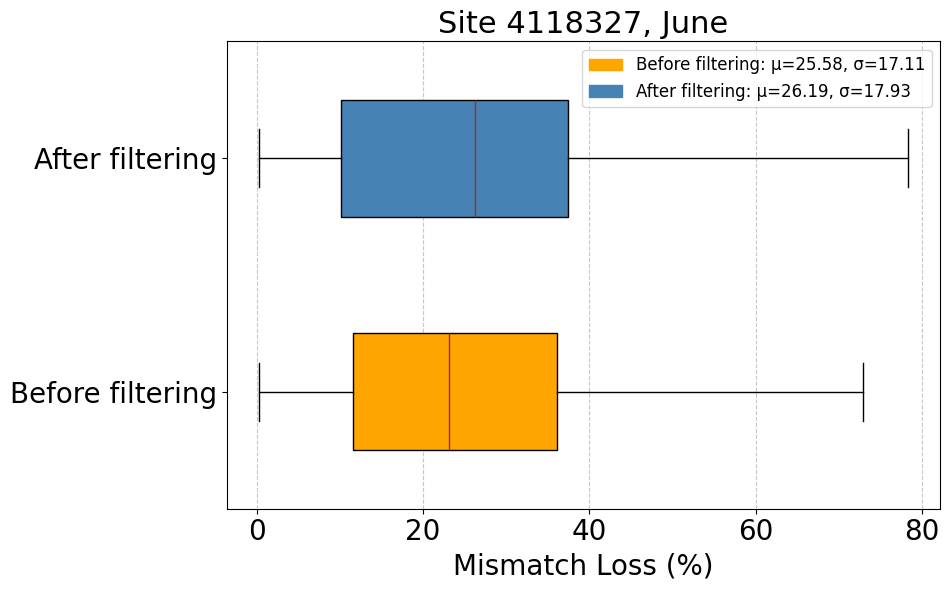

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4118327_December_20250630_110831
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4118327_December_20250630_110831\module_param_df.csv
df_pivot shape: (1263, 224)
2024-12-16 16:15:00 → 257820181_diode_activation=1.0, Voc_257820181_outlier_label=-1.0, Isc_257820181_outlier_label=0.0
2024-12-16 16:20:00 → 257820181_diode_activation=1.0, Voc_257820181_outlier_label=-1.0, Isc_257820181_outlier_label=0.0
2024-12-20 16:20:00 → 257820181_diode_activation=1.0, Voc_257820181_outlier_label=-1.0, Isc_257820181_outlier_label=0.0
Looking for combined file in C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4118327_December_20250630_110831
Original combined data shape: (1263, 4)
New combined data shape (after removing diode act

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


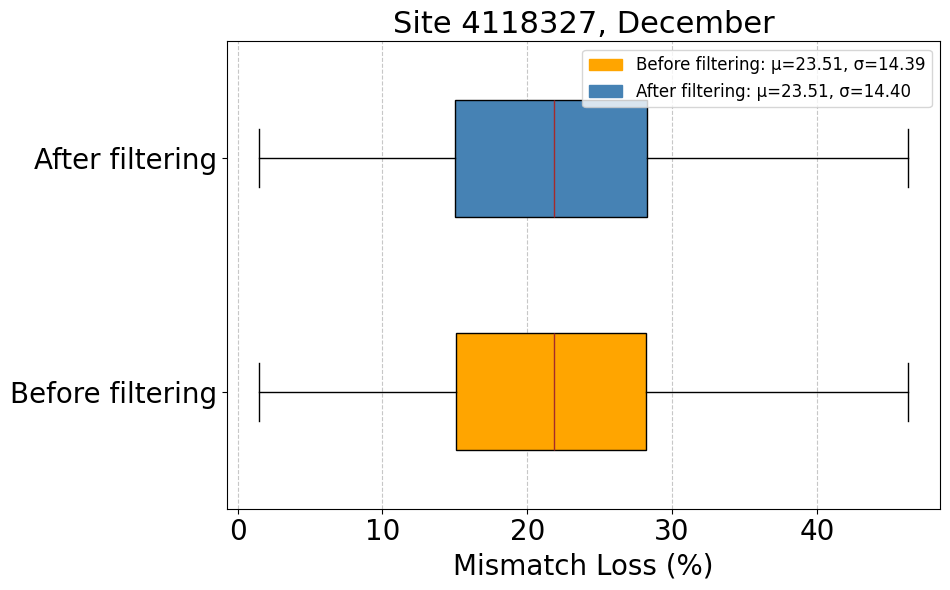

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4118327_March_20250630_100008
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4118327_March_20250630_100008\module_param_df.csv
df_pivot shape: (1487, 224)
2024-03-16 08:55:00 → 257820474_diode_activation=-1.0, Voc_257820474_outlier_label=1.0, Isc_257820474_outlier_label=-1.0
2024-03-16 09:00:00 → 257826648_diode_activation=-1.0, Voc_257826648_outlier_label=1.0, Isc_257826648_outlier_label=-1.0
2024-03-16 09:20:00 → 257820181_diode_activation=-1.0, Voc_257820181_outlier_label=1.0, Isc_257820181_outlier_label=-1.0
2024-03-16 09:20:00 → 257825991_diode_activation=-1.0, Voc_257825991_outlier_label=1.0, Isc_257825991_outlier_label=-1.0
2024-03-16 10:15:00 → 257820472_diode_activation=-1.0, Voc_257820472_outlier_label=1.0, Isc_257820472_outlier_label=-1.0
2024-03-16 10:30:00 → 2578

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


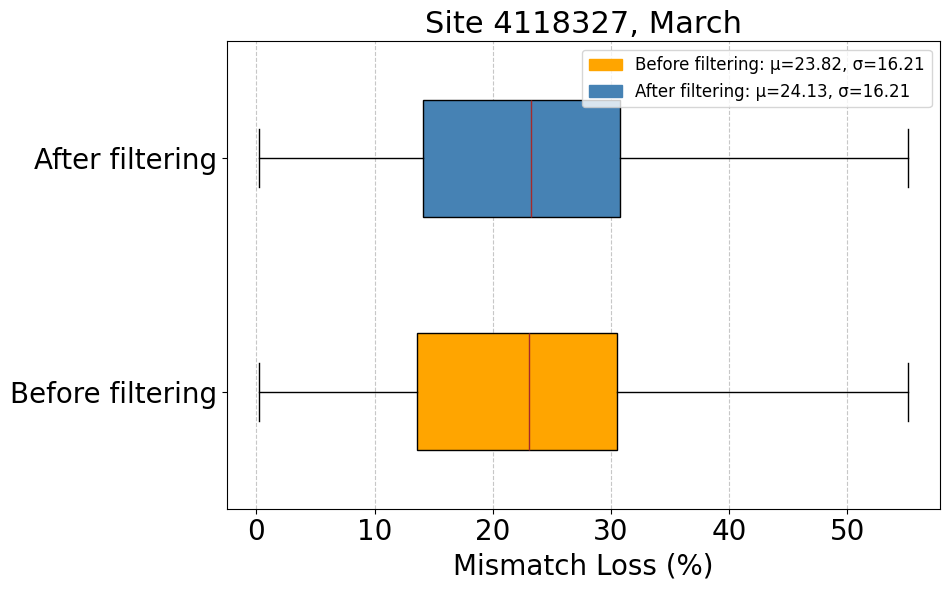

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\3455043_September_20250629_213217
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\3455043_September_20250629_213217\module_param_df.csv
df_pivot shape: (1498, 168)
2024-09-20 14:10:00 → 226780738_diode_activation=-1.0, Voc_226780738_outlier_label=1.0, Isc_226780738_outlier_label=-1.0
2024-09-20 14:15:00 → 226780728_diode_activation=-1.0, Voc_226780728_outlier_label=1.0, Isc_226780728_outlier_label=-1.0
2024-09-20 14:30:00 → 226780740_diode_activation=-1.0, Voc_226780740_outlier_label=1.0, Isc_226780740_outlier_label=-1.0
2024-09-20 14:55:00 → 226780742_diode_activation=-1.0, Voc_226780742_outlier_label=1.0, Isc_226780742_outlier_label=-1.0
2024-09-20 16:25:00 → 226780326_diode_activation=-1.0, Voc_226780326_outlier_label=1.0, Isc_226780326_outlier_label=-1.0
2024-09-20 16:40:0

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


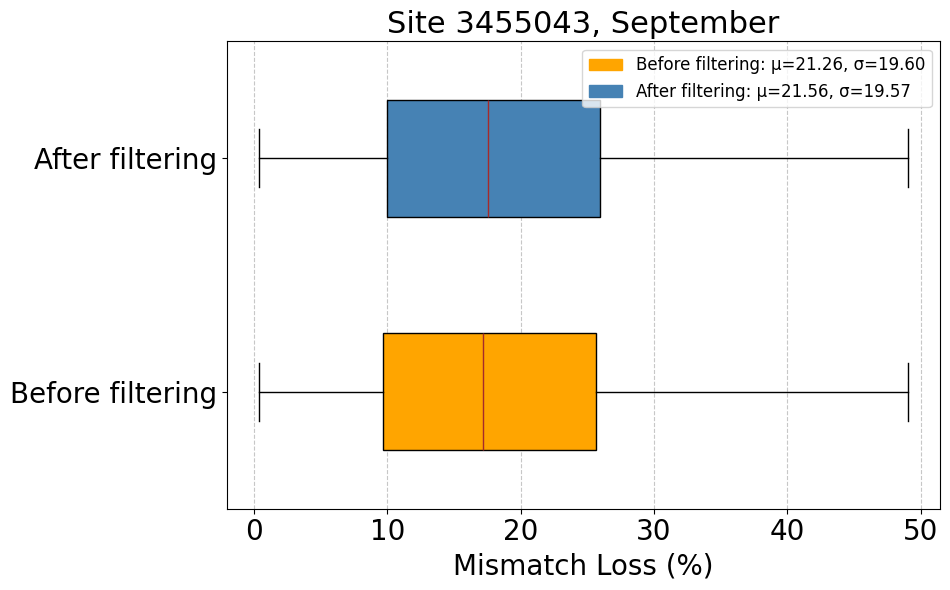

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\3455043_June_20250629_225535
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\3455043_June_20250629_225535\module_param_df.csv
df_pivot shape: (1289, 168)
2024-06-15 15:45:00 → 226780737_diode_activation=-1.0, Voc_226780737_outlier_label=1.0, Isc_226780737_outlier_label=-1.0
2024-06-15 15:45:00 → 226780739_diode_activation=-1.0, Voc_226780739_outlier_label=1.0, Isc_226780739_outlier_label=-1.0
2024-06-16 15:45:00 → 226780737_diode_activation=-1.0, Voc_226780737_outlier_label=1.0, Isc_226780737_outlier_label=-1.0
2024-06-16 15:45:00 → 226780739_diode_activation=-1.0, Voc_226780739_outlier_label=1.0, Isc_226780739_outlier_label=-1.0
2024-06-17 15:45:00 → 226780737_diode_activation=-1.0, Voc_226780737_outlier_label=1.0, Isc_226780737_outlier_label=-1.0
2024-06-17 15:45:00 → 226780

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


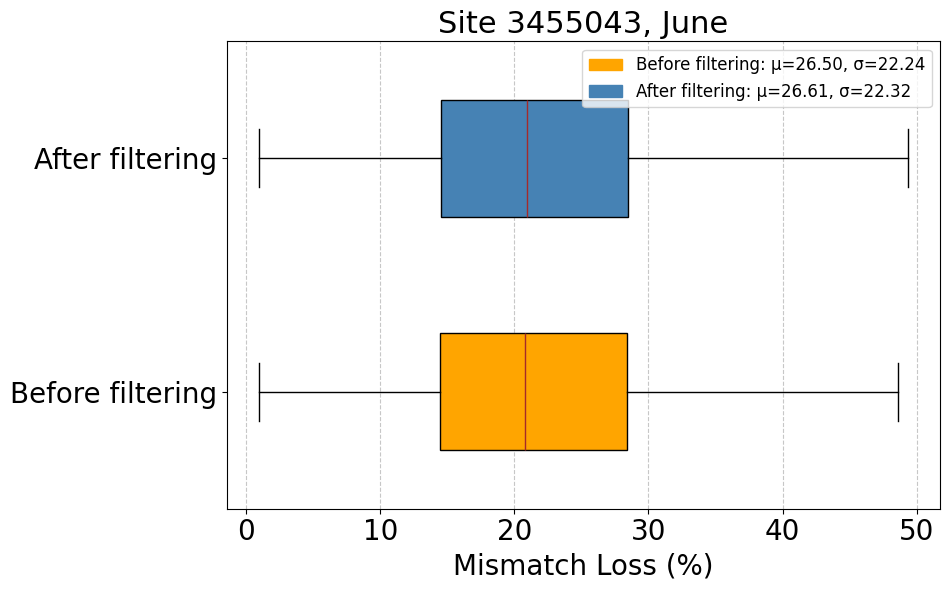

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\3455043_December_20250629_221553
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\3455043_December_20250629_221553\module_param_df.csv
df_pivot shape: (1698, 168)
2024-12-15 15:30:00 → 226780742_diode_activation=-1.0, Voc_226780742_outlier_label=1.0, Isc_226780742_outlier_label=-1.0
2024-12-15 15:55:00 → 226780731_diode_activation=-1.0, Voc_226780731_outlier_label=1.0, Isc_226780731_outlier_label=-1.0
2024-12-15 15:55:00 → 226780735_diode_activation=-1.0, Voc_226780735_outlier_label=1.0, Isc_226780735_outlier_label=-1.0
2024-12-16 10:05:00 → 226780739_diode_activation=-1.0, Voc_226780739_outlier_label=1.0, Isc_226780739_outlier_label=-1.0
2024-12-16 10:30:00 → 226780327_diode_activation=-1.0, Voc_226780327_outlier_label=1.0, Isc_226780327_outlier_label=-1.0
2024-12-16 11:50:00 

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


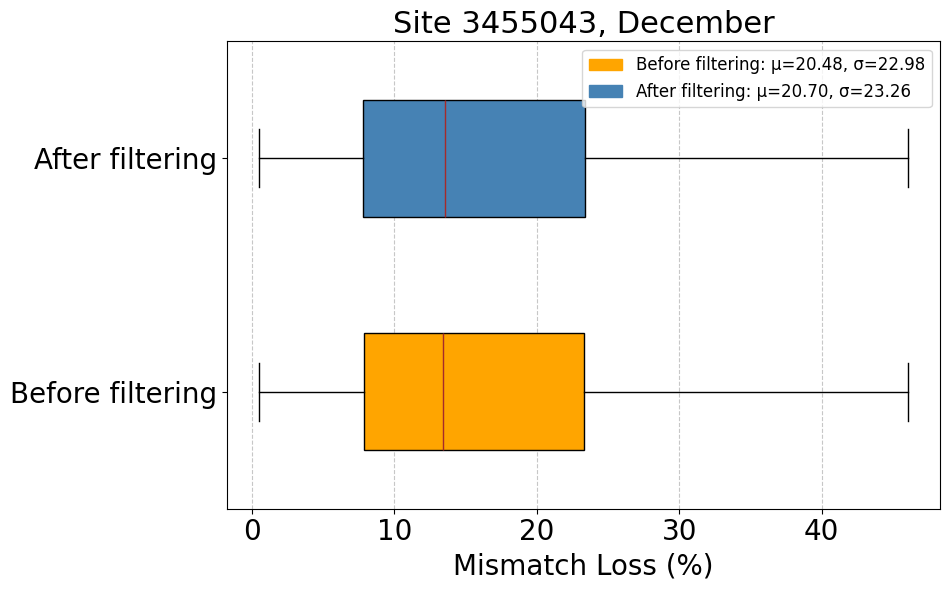

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\3455043_March_20250627_224510
2024-12-18 15:25:00 → 226782364_diode_activation=1.0, Voc_226782364_outlier_label=-1.0, Isc_226782364_outlier_label=0.0
Looking for combined file in C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\3455043_March_20250627_224510
No combined file found in C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\3455043_March_20250627_224510
Original combined data shape: (1698, 4)
New combined data shape (after removing diode activation timestamps): (1697, 4)
Columns in combined_df: ['Sum of I*V (W)', 'Pmppt (W)', 'Season', 'Site ID']


C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


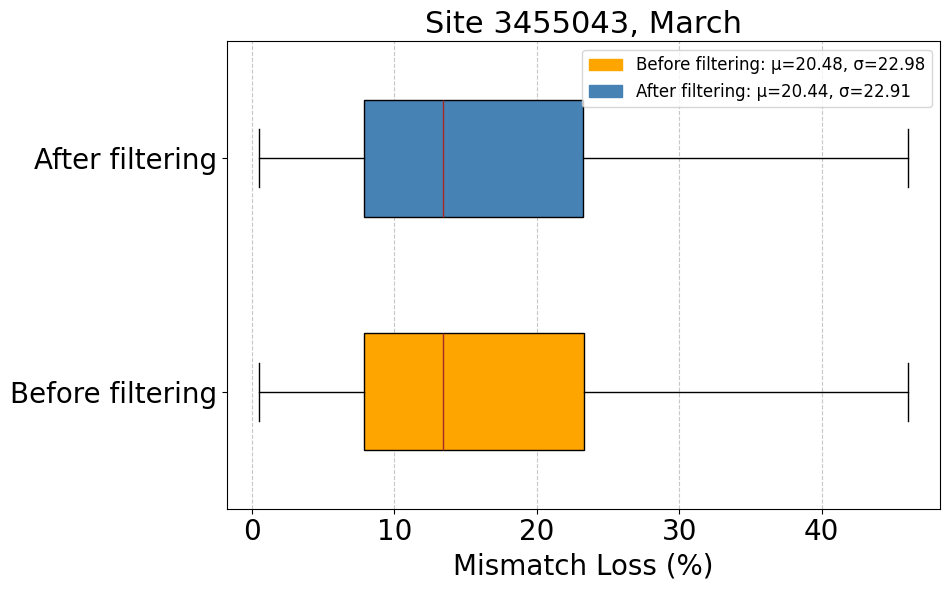

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4034376_September_20250630_001545
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4034376_September_20250630_001545\module_param_df.csv
df_pivot shape: (1496, 98)
2024-09-20 12:00:00 → 253276338_diode_activation=-1.0, Voc_253276338_outlier_label=1.0, Isc_253276338_outlier_label=-1.0
2024-09-20 14:45:00 → 253276327_diode_activation=-1.0, Voc_253276327_outlier_label=1.0, Isc_253276327_outlier_label=-1.0
2024-09-20 14:45:00 → 253276340_diode_activation=-1.0, Voc_253276340_outlier_label=1.0, Isc_253276340_outlier_label=-1.0
2024-09-21 11:05:00 → 253276334_diode_activation=-1.0, Voc_253276334_outlier_label=1.0, Isc_253276334_outlier_label=-1.0
2024-09-22 09:30:00 → 253276328_diode_activation=-1.0, Voc_253276328_outlier_label=1.0, Isc_253276328_outlier_label=-1.0
2024-09-22 09:30:00

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


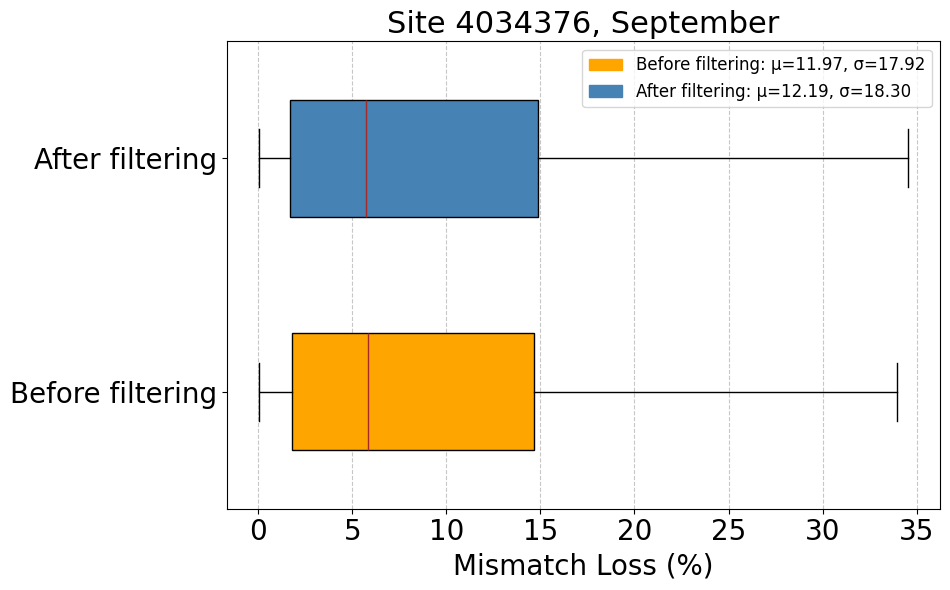

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4034376_June_20250630_010512
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4034376_June_20250630_010512\module_param_df.csv
df_pivot shape: (1213, 98)
2024-06-16 09:50:00 → 253276332_diode_activation=-1.0, Voc_253276332_outlier_label=1.0, Isc_253276332_outlier_label=-1.0
2024-06-16 09:50:00 → 253276335_diode_activation=-1.0, Voc_253276335_outlier_label=1.0, Isc_253276335_outlier_label=-1.0
2024-06-16 09:50:00 → 253276338_diode_activation=-1.0, Voc_253276338_outlier_label=1.0, Isc_253276338_outlier_label=-1.0
2024-06-16 09:55:00 → 253276335_diode_activation=-1.0, Voc_253276335_outlier_label=1.0, Isc_253276335_outlier_label=-1.0
2024-06-16 10:00:00 → 253276335_diode_activation=-1.0, Voc_253276335_outlier_label=1.0, Isc_253276335_outlier_label=-1.0
2024-06-16 10:05:00 → 2532763

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


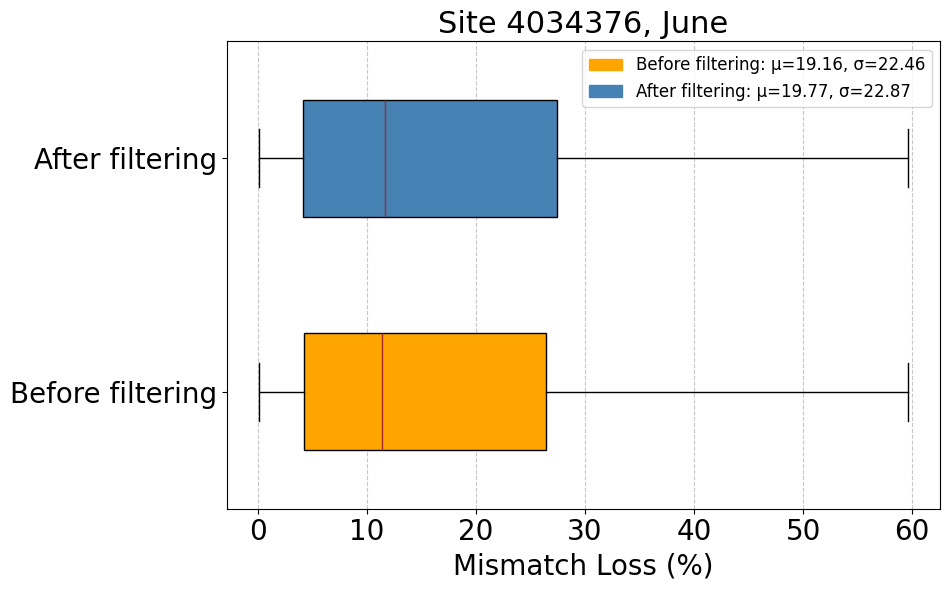

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4034376_December_20250630_003048
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4034376_December_20250630_003048\module_param_df.csv
df_pivot shape: (1785, 98)
2024-12-15 09:25:00 → 253276327_diode_activation=-1.0, Voc_253276327_outlier_label=1.0, Isc_253276327_outlier_label=-1.0
2024-12-15 10:00:00 → 253276336_diode_activation=-1.0, Voc_253276336_outlier_label=1.0, Isc_253276336_outlier_label=-1.0
2024-12-16 09:00:00 → 253276327_diode_activation=-1.0, Voc_253276327_outlier_label=1.0, Isc_253276327_outlier_label=-1.0
2024-12-16 13:05:00 → 253276339_diode_activation=-1.0, Voc_253276339_outlier_label=1.0, Isc_253276339_outlier_label=-1.0
2024-12-17 08:50:00 → 253276331_diode_activation=-1.0, Voc_253276331_outlier_label=1.0, Isc_253276331_outlier_label=-1.0
2024-12-17 09:05:00 →

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


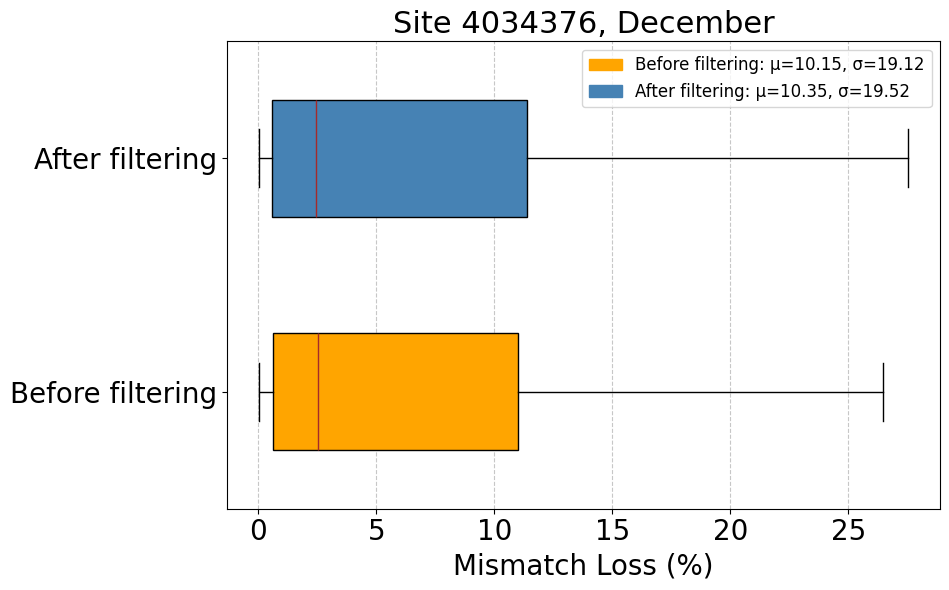

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4034376_March_20250630_004904
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4034376_March_20250630_004904\module_param_df.csv
df_pivot shape: (1501, 98)
2024-03-15 11:00:00 → 253276338_diode_activation=-1.0, Voc_253276338_outlier_label=1.0, Isc_253276338_outlier_label=-1.0
2024-03-16 09:30:00 → 253276335_diode_activation=-1.0, Voc_253276335_outlier_label=1.0, Isc_253276335_outlier_label=-1.0
2024-03-16 09:45:00 → 253276335_diode_activation=-1.0, Voc_253276335_outlier_label=1.0, Isc_253276335_outlier_label=-1.0
2024-03-16 09:50:00 → 253276335_diode_activation=-1.0, Voc_253276335_outlier_label=1.0, Isc_253276335_outlier_label=-1.0
2024-03-16 09:55:00 → 253276335_diode_activation=-1.0, Voc_253276335_outlier_label=1.0, Isc_253276335_outlier_label=-1.0
2024-03-16 10:00:00 → 25327

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


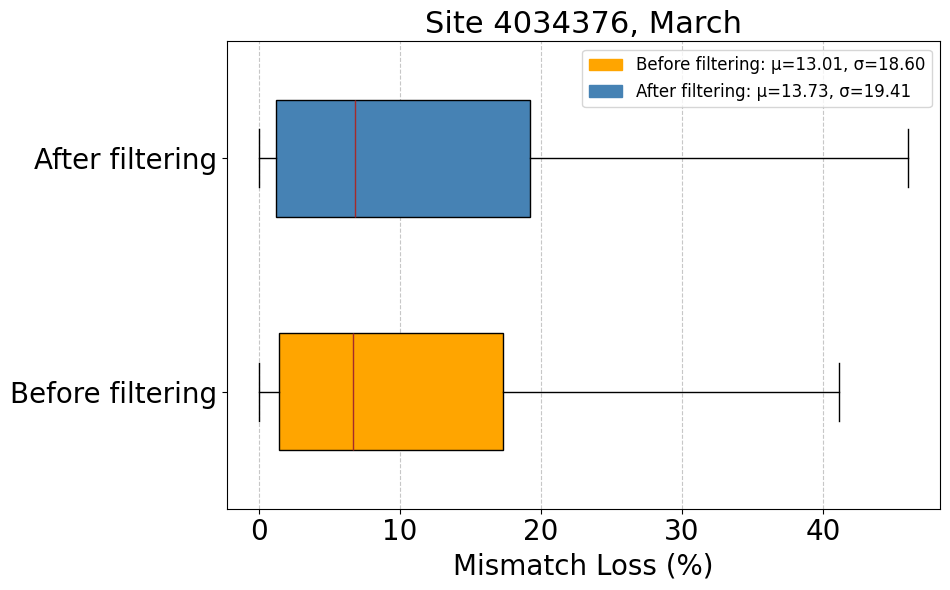

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4122216_September_20250630_120339
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4122216_September_20250630_120339\module_param_df.csv
df_pivot shape: (1438, 98)
2024-09-20 10:10:00 → 257948933_diode_activation=-1.0, Voc_257948933_outlier_label=1.0, Isc_257948933_outlier_label=-1.0
2024-09-20 10:15:00 → 257948933_diode_activation=-1.0, Voc_257948933_outlier_label=1.0, Isc_257948933_outlier_label=-1.0
2024-09-20 10:20:00 → 257948933_diode_activation=-1.0, Voc_257948933_outlier_label=1.0, Isc_257948933_outlier_label=-1.0
2024-09-20 10:25:00 → 257948933_diode_activation=-1.0, Voc_257948933_outlier_label=1.0, Isc_257948933_outlier_label=-1.0
2024-09-20 10:30:00 → 257948933_diode_activation=-1.0, Voc_257948933_outlier_label=1.0, Isc_257948933_outlier_label=-1.0
2024-09-20 10:35:00

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


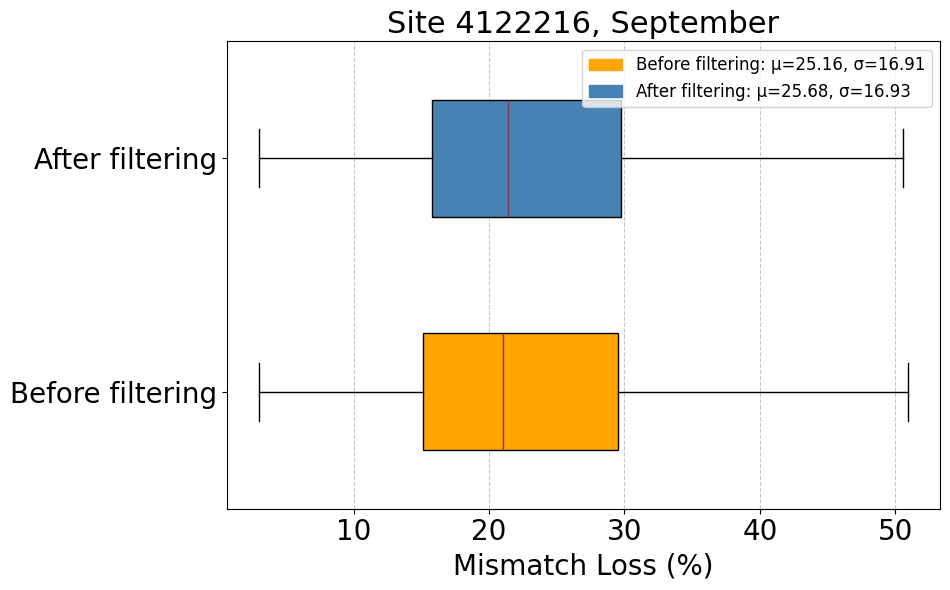

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4122216_June_20250630_114216
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4122216_June_20250630_114216\module_param_df.csv
df_pivot shape: (2031, 98)
2024-06-15 09:55:00 → 257948925_diode_activation=-1.0, Voc_257948925_outlier_label=1.0, Isc_257948925_outlier_label=-1.0
2024-06-15 10:30:00 → 257948931_diode_activation=-1.0, Voc_257948931_outlier_label=1.0, Isc_257948931_outlier_label=-1.0
2024-06-15 10:30:00 → 257948932_diode_activation=-1.0, Voc_257948932_outlier_label=1.0, Isc_257948932_outlier_label=-1.0
2024-06-15 11:15:00 → 257948931_diode_activation=-1.0, Voc_257948931_outlier_label=1.0, Isc_257948931_outlier_label=-1.0
2024-06-16 14:15:00 → 257948923_diode_activation=-1.0, Voc_257948923_outlier_label=1.0, Isc_257948923_outlier_label=-1.0
2024-06-16 14:15:00 → 2579489

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


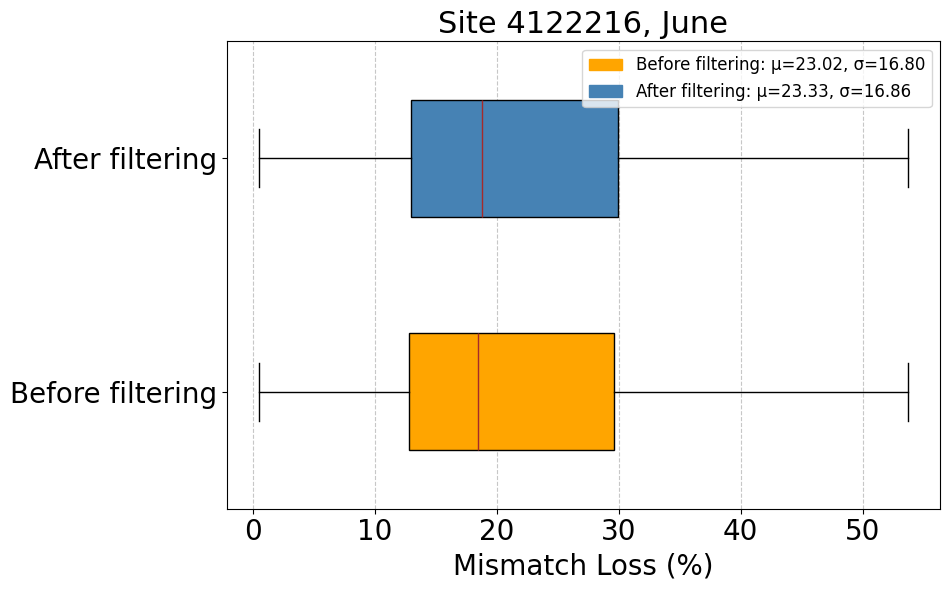

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4122216_December_20250630_121900
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4122216_December_20250630_121900\module_param_df.csv
df_pivot shape: (893, 98)
Looking for combined file in C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4122216_December_20250630_121900
Original combined data shape: (893, 4)
New combined data shape (after removing diode activation timestamps): (893, 4)
Columns in combined_df: ['Sum of I*V (W)', 'Pmppt (W)', 'Season', 'Site ID']


C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


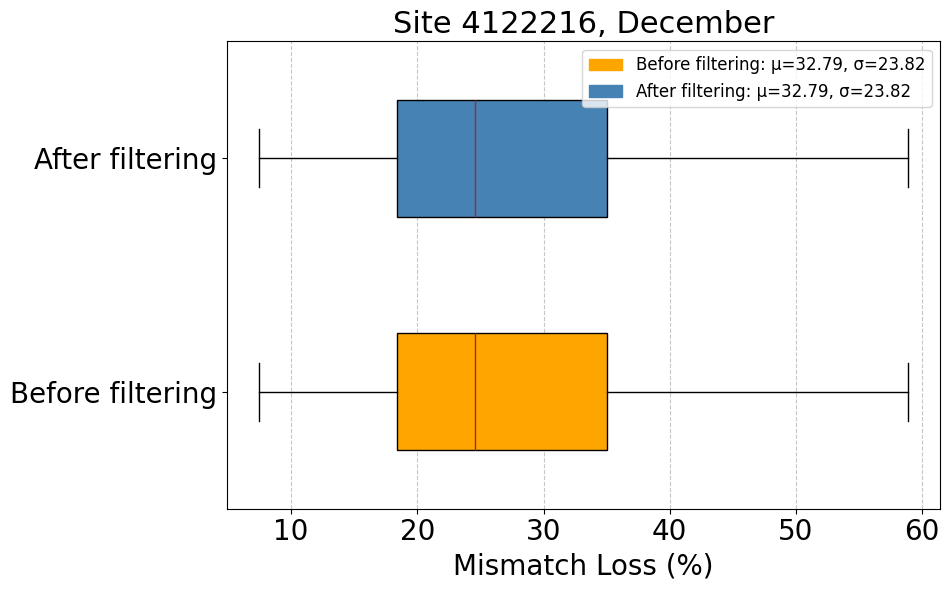

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4122216_March_20250630_112754
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4122216_March_20250630_112754\module_param_df.csv
df_pivot shape: (1453, 98)
2024-03-15 09:15:00 → 257948931_diode_activation=1.0, Voc_257948931_outlier_label=-1.0, Isc_257948931_outlier_label=0.0
2024-03-19 13:00:00 → 257948930_diode_activation=1.0, Voc_257948930_outlier_label=-1.0, Isc_257948930_outlier_label=0.0
2024-03-19 13:05:00 → 257948930_diode_activation=1.0, Voc_257948930_outlier_label=-1.0, Isc_257948930_outlier_label=0.0
2024-03-19 13:10:00 → 257948930_diode_activation=1.0, Voc_257948930_outlier_label=-1.0, Isc_257948930_outlier_label=0.0
2024-03-19 13:20:00 → 257948930_diode_activation=1.0, Voc_257948930_outlier_label=-1.0, Isc_257948930_outlier_label=0.0
2024-03-19 13:50:00 → 257948930_

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


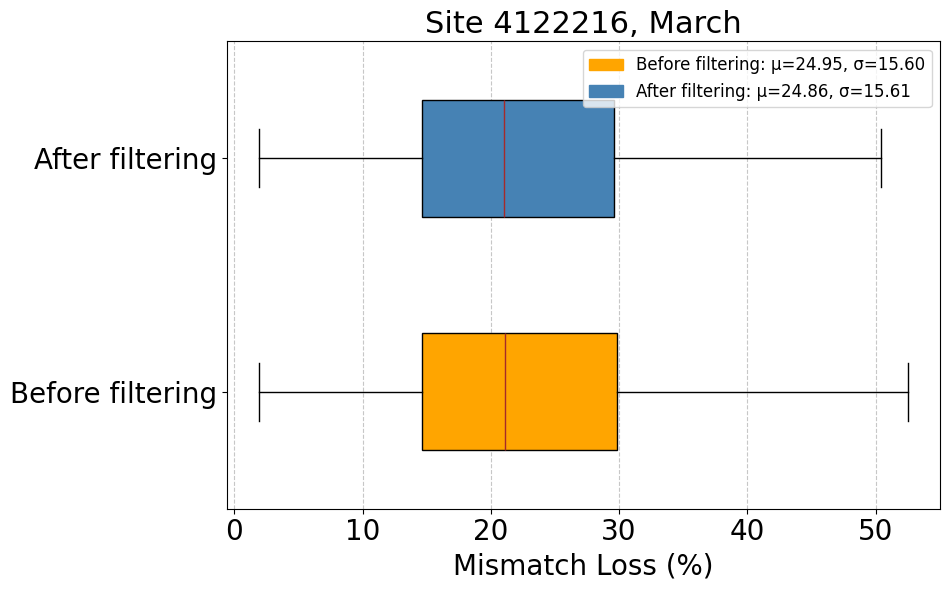

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111492_September_20250630_050745
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111492_September_20250630_050745\module_param_df.csv
df_pivot shape: (1473, 210)
2024-09-20 09:30:00 → 256552540_diode_activation=-1.0, Voc_256552540_outlier_label=1.0, Isc_256552540_outlier_label=-1.0
2024-09-20 09:35:00 → 256552540_diode_activation=-1.0, Voc_256552540_outlier_label=1.0, Isc_256552540_outlier_label=-1.0
2024-09-20 09:40:00 → 256552540_diode_activation=-1.0, Voc_256552540_outlier_label=1.0, Isc_256552540_outlier_label=-1.0
2024-09-20 09:45:00 → 256552539_diode_activation=-1.0, Voc_256552539_outlier_label=1.0, Isc_256552539_outlier_label=-1.0
2024-09-20 09:45:00 → 256552540_diode_activation=-1.0, Voc_256552540_outlier_label=1.0, Isc_256552540_outlier_label=-1.0
2024-09-20 09:45:0

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


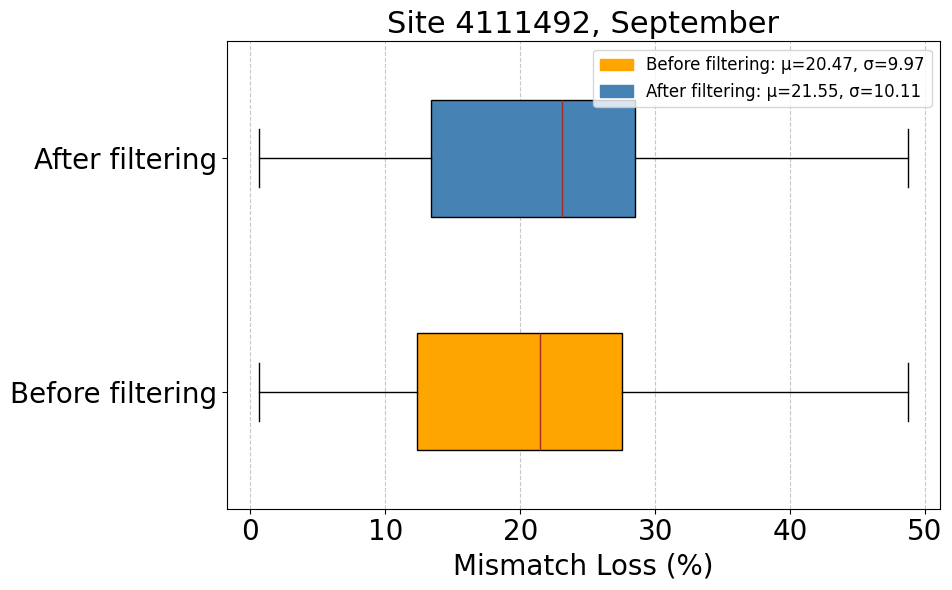

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111492_June_20250630_044045
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111492_June_20250630_044045\module_param_df.csv
df_pivot shape: (1825, 210)
2024-06-15 08:45:00 → 256552539_diode_activation=-1.0, Voc_256552539_outlier_label=1.0, Isc_256552539_outlier_label=-1.0
2024-06-15 08:50:00 → 256552539_diode_activation=-1.0, Voc_256552539_outlier_label=1.0, Isc_256552539_outlier_label=-1.0
2024-06-15 08:55:00 → 256552217_diode_activation=-1.0, Voc_256552217_outlier_label=1.0, Isc_256552217_outlier_label=-1.0
2024-06-15 08:55:00 → 256552539_diode_activation=-1.0, Voc_256552539_outlier_label=1.0, Isc_256552539_outlier_label=-1.0
2024-06-15 09:00:00 → 256552539_diode_activation=-1.0, Voc_256552539_outlier_label=1.0, Isc_256552539_outlier_label=-1.0
2024-06-15 09:05:00 → 256552

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


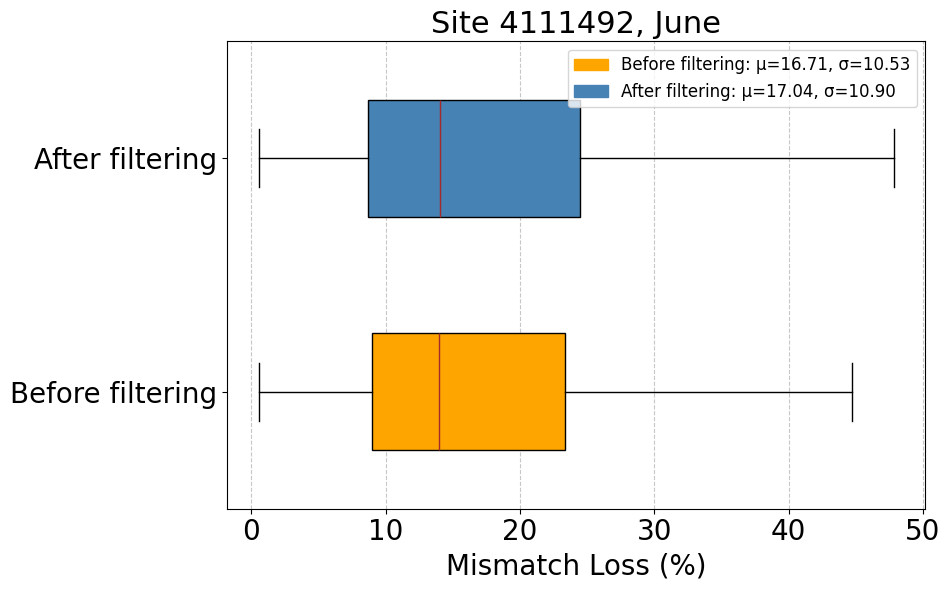

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111492_December_20250630_052938
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111492_December_20250630_052938\module_param_df.csv
df_pivot shape: (1094, 210)
2024-12-16 14:30:00 → 256611361_diode_activation=1.0, Voc_256611361_outlier_label=-1.0, Isc_256611361_outlier_label=0.0
2024-12-16 14:35:00 → 256611361_diode_activation=1.0, Voc_256611361_outlier_label=-1.0, Isc_256611361_outlier_label=0.0
2024-12-16 14:40:00 → 256611361_diode_activation=1.0, Voc_256611361_outlier_label=-1.0, Isc_256611361_outlier_label=0.0
2024-12-16 15:25:00 → 256552224_diode_activation=1.0, Voc_256552224_outlier_label=-1.0, Isc_256552224_outlier_label=0.0
2024-12-18 14:35:00 → 256611361_diode_activation=1.0, Voc_256611361_outlier_label=-1.0, Isc_256611361_outlier_label=0.0
2024-12-18 14:40:00 → 256

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


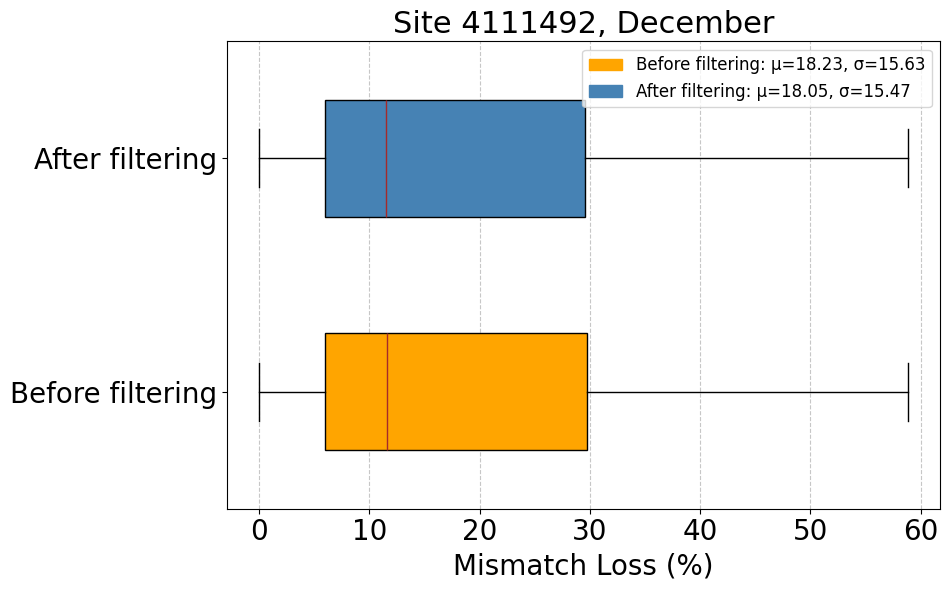

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111492_March_20250630_042052
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111492_March_20250630_042052\module_param_df.csv
df_pivot shape: (1439, 210)
2024-03-15 10:00:00 → 256552540_diode_activation=-1.0, Voc_256552540_outlier_label=1.0, Isc_256552540_outlier_label=-1.0
2024-03-15 10:05:00 → 256552540_diode_activation=-1.0, Voc_256552540_outlier_label=1.0, Isc_256552540_outlier_label=-1.0
2024-03-15 10:05:00 → 256611245_diode_activation=-1.0, Voc_256611245_outlier_label=1.0, Isc_256611245_outlier_label=-1.0
2024-03-15 10:10:00 → 256552538_diode_activation=-1.0, Voc_256552538_outlier_label=1.0, Isc_256552538_outlier_label=-1.0
2024-03-15 10:10:00 → 256552539_diode_activation=-1.0, Voc_256552539_outlier_label=1.0, Isc_256552539_outlier_label=-1.0
2024-03-15 10:10:00 → 2565

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


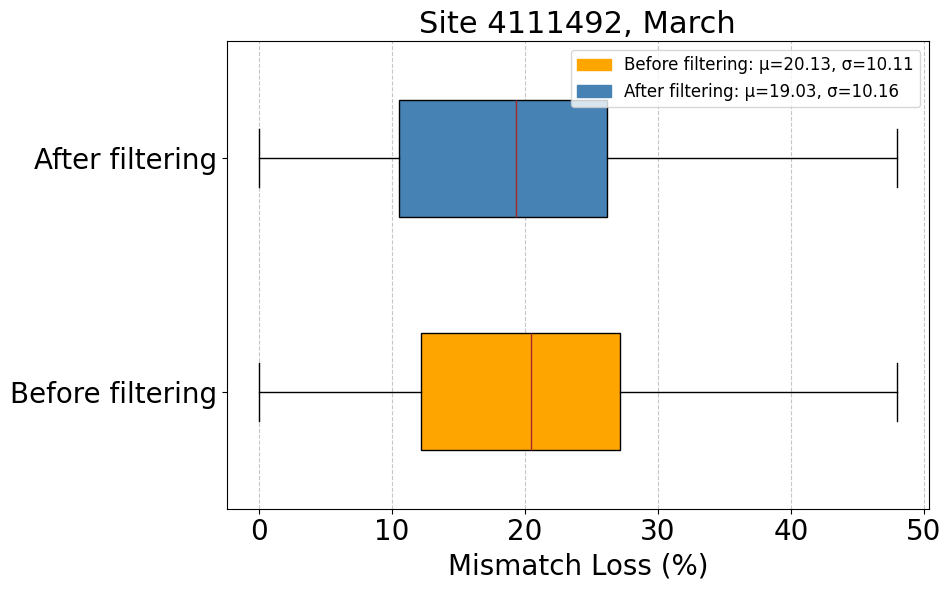

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111800_September_20250630_063020
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111800_September_20250630_063020\module_param_df.csv
df_pivot shape: (1456, 203)
2024-09-29 18:15:00 → 256989174_diode_activation=1.0, Voc_256989174_outlier_label=-1.0, Isc_256989174_outlier_label=0.0
2024-09-29 18:20:00 → 256989174_diode_activation=1.0, Voc_256989174_outlier_label=-1.0, Isc_256989174_outlier_label=0.0
Looking for combined file in C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111800_September_20250630_063020
Original combined data shape: (1456, 4)
New combined data shape (after removing diode activation timestamps): (1454, 4)
Columns in combined_df: ['Sum of I*V (W)', 'Pmppt (W)', 'Season', 'Site ID']


C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


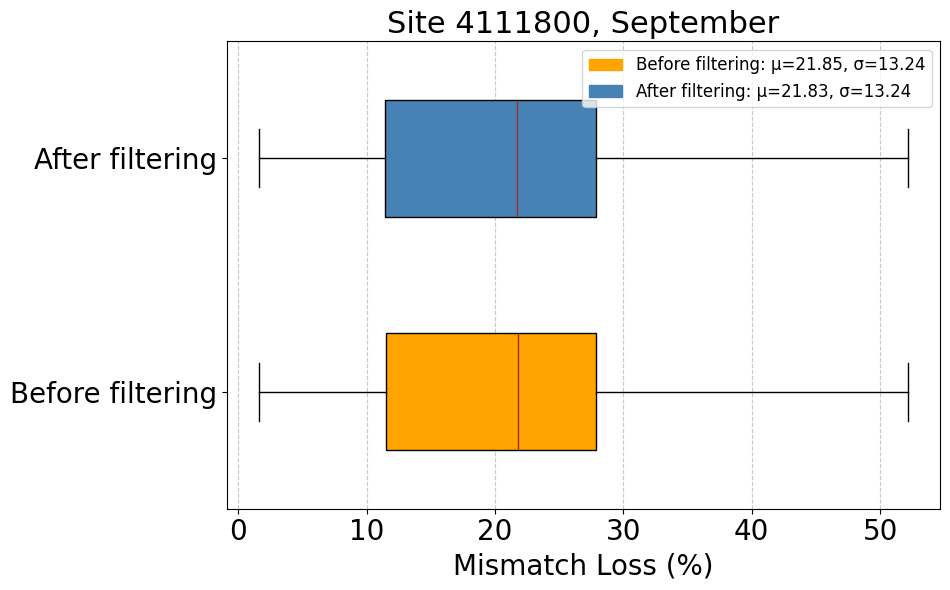

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111800_June_20250630_060555
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111800_June_20250630_060555\module_param_df.csv
df_pivot shape: (1745, 203)
2024-06-15 10:10:00 → 256986886_diode_activation=-1.0, Voc_256986886_outlier_label=1.0, Isc_256986886_outlier_label=-1.0
2024-06-15 10:15:00 → 256986886_diode_activation=-1.0, Voc_256986886_outlier_label=1.0, Isc_256986886_outlier_label=-1.0
2024-06-15 10:20:00 → 256986886_diode_activation=-1.0, Voc_256986886_outlier_label=1.0, Isc_256986886_outlier_label=-1.0
2024-06-15 14:55:00 → 256986713_diode_activation=-1.0, Voc_256986713_outlier_label=1.0, Isc_256986713_outlier_label=-1.0
2024-06-15 15:00:00 → 256986712_diode_activation=-1.0, Voc_256986712_outlier_label=1.0, Isc_256986712_outlier_label=-1.0
2024-06-15 15:00:00 → 256986

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


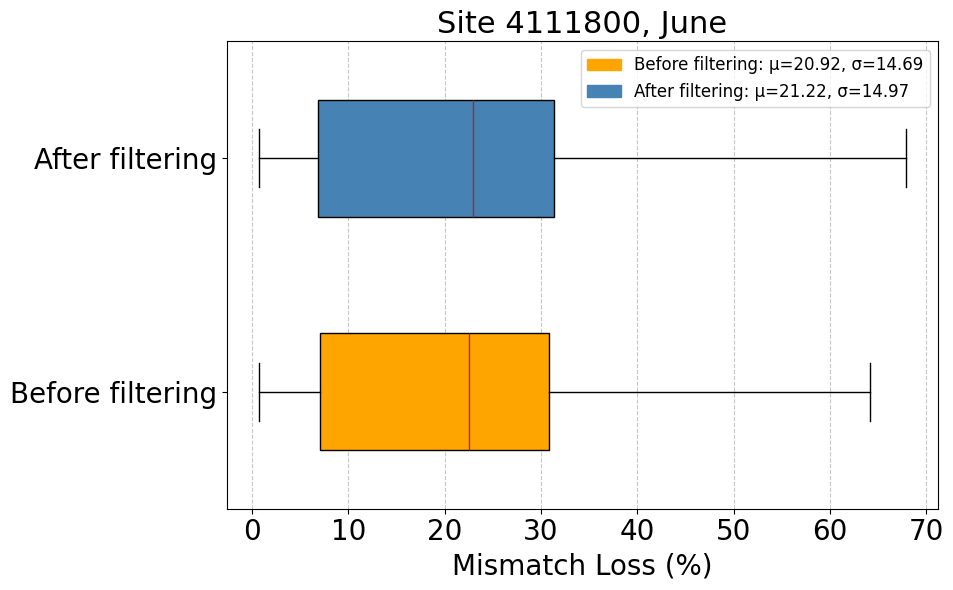

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111800_December_20250630_065023
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111800_December_20250630_065023\module_param_df.csv
df_pivot shape: (1209, 203)
2024-12-17 16:40:00 → 256989175_diode_activation=1.0, Voc_256989175_outlier_label=-1.0, Isc_256989175_outlier_label=0.0
2024-12-17 16:45:00 → 256989175_diode_activation=1.0, Voc_256989175_outlier_label=-1.0, Isc_256989175_outlier_label=0.0
2024-12-17 16:50:00 → 256989175_diode_activation=1.0, Voc_256989175_outlier_label=-1.0, Isc_256989175_outlier_label=0.0
2024-12-18 10:35:00 → 256989179_diode_activation=-1.0, Voc_256989179_outlier_label=1.0, Isc_256989179_outlier_label=-1.0
2024-12-18 10:45:00 → 256989179_diode_activation=-1.0, Voc_256989179_outlier_label=1.0, Isc_256989179_outlier_label=-1.0
Looking for combined fi

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


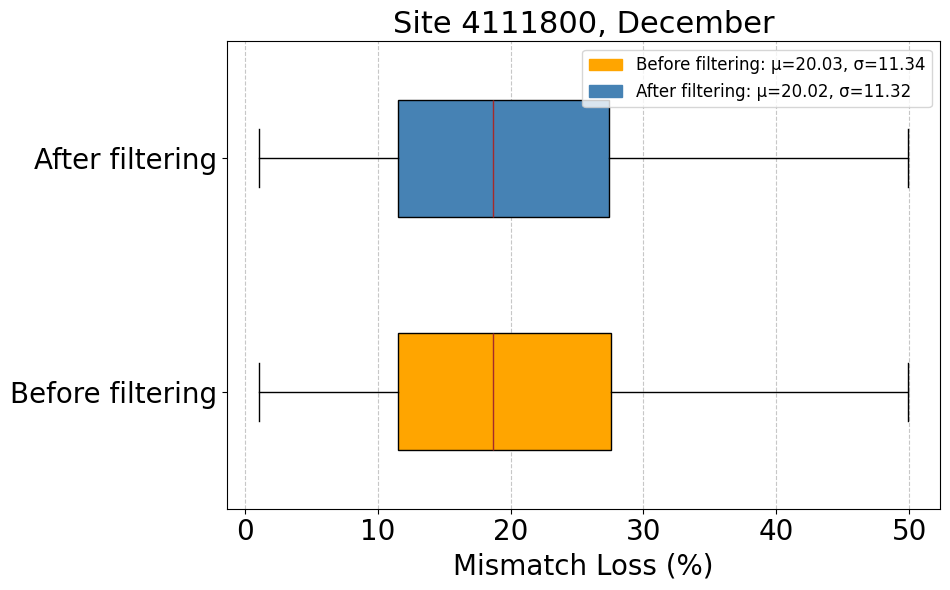

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111800_March_20250630_054527
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111800_March_20250630_054527\module_param_df.csv
df_pivot shape: (1481, 203)
2024-03-15 13:10:00 → 256986712_diode_activation=-1.0, Voc_256986712_outlier_label=1.0, Isc_256986712_outlier_label=-1.0
2024-03-15 13:15:00 → 256986712_diode_activation=-1.0, Voc_256986712_outlier_label=1.0, Isc_256986712_outlier_label=-1.0
2024-03-15 13:20:00 → 256986712_diode_activation=-1.0, Voc_256986712_outlier_label=1.0, Isc_256986712_outlier_label=-1.0
2024-03-15 13:30:00 → 256986712_diode_activation=-1.0, Voc_256986712_outlier_label=1.0, Isc_256986712_outlier_label=-1.0
2024-03-15 13:35:00 → 256986712_diode_activation=-1.0, Voc_256986712_outlier_label=1.0, Isc_256986712_outlier_label=-1.0
2024-03-15 13:40:00 → 2569

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


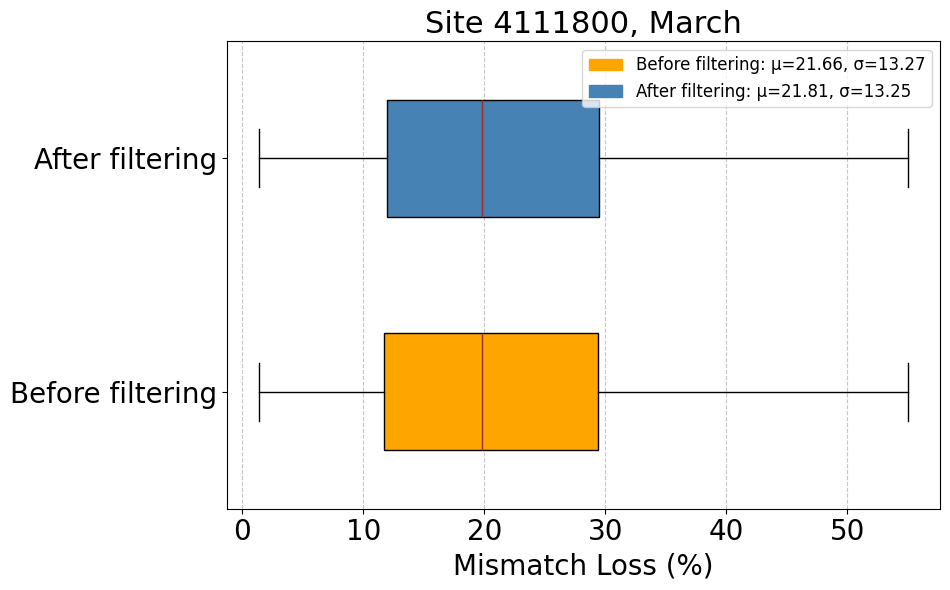

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4184502_September_20250630_204348
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4184502_September_20250630_204348\module_param_df.csv
df_pivot shape: (1465, 98)
2024-09-20 08:20:00 → 261526613_diode_activation=-1.0, Voc_261526613_outlier_label=1.0, Isc_261526613_outlier_label=-1.0
2024-09-20 08:25:00 → 261526613_diode_activation=-1.0, Voc_261526613_outlier_label=1.0, Isc_261526613_outlier_label=-1.0
2024-09-20 08:30:00 → 261526613_diode_activation=-1.0, Voc_261526613_outlier_label=1.0, Isc_261526613_outlier_label=-1.0
2024-09-20 08:35:00 → 261526613_diode_activation=-1.0, Voc_261526613_outlier_label=1.0, Isc_261526613_outlier_label=-1.0
2024-09-20 08:40:00 → 261526613_diode_activation=-1.0, Voc_261526613_outlier_label=1.0, Isc_261526613_outlier_label=-1.0
2024-09-20 08:45:00

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


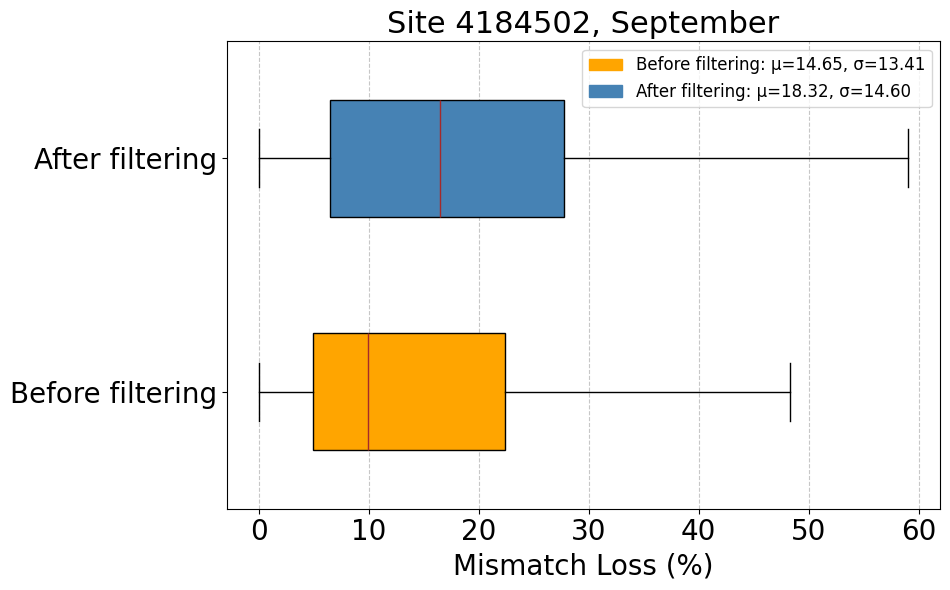

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4184502_June_20250630_184750
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4184502_June_20250630_184750\module_param_df.csv
df_pivot shape: (1685, 98)
2024-06-15 08:10:00 → 261526609_diode_activation=-1.0, Voc_261526609_outlier_label=1.0, Isc_261526609_outlier_label=-1.0
2024-06-15 08:15:00 → 261526502_diode_activation=-1.0, Voc_261526502_outlier_label=1.0, Isc_261526502_outlier_label=-1.0
2024-06-15 08:20:00 → 261526502_diode_activation=-1.0, Voc_261526502_outlier_label=1.0, Isc_261526502_outlier_label=-1.0
2024-06-15 08:30:00 → 261526502_diode_activation=-1.0, Voc_261526502_outlier_label=1.0, Isc_261526502_outlier_label=-1.0
2024-06-15 08:35:00 → 261526502_diode_activation=-1.0, Voc_261526502_outlier_label=1.0, Isc_261526502_outlier_label=-1.0
2024-06-15 08:40:00 → 2615265

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


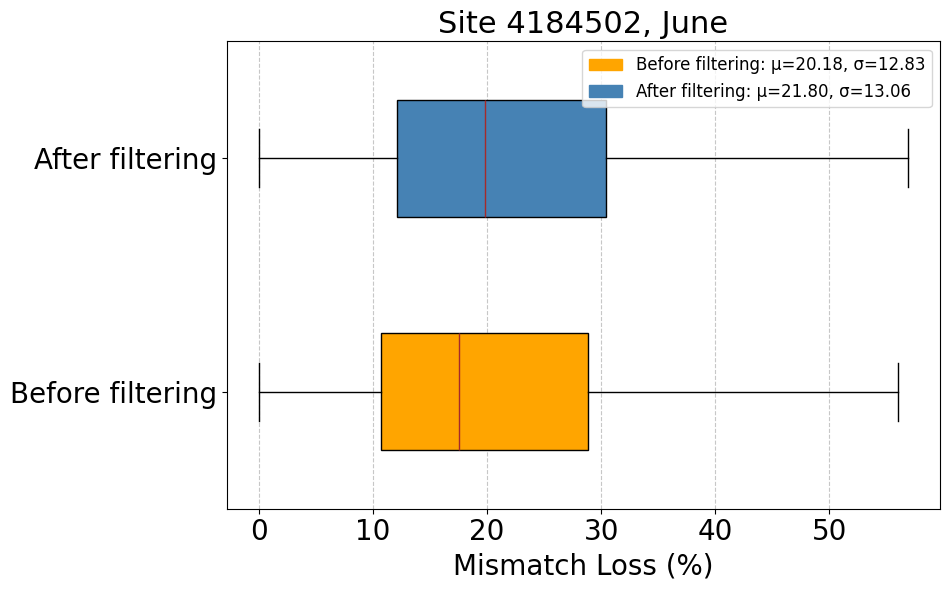

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4184502_December_20250630_211825
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4184502_December_20250630_211825\module_param_df.csv
df_pivot shape: (1247, 98)
2024-12-15 10:55:00 → 261526500_diode_activation=-1.0, Voc_261526500_outlier_label=1.0, Isc_261526500_outlier_label=-1.0
2024-12-15 12:05:00 → 261526611_diode_activation=-1.0, Voc_261526611_outlier_label=1.0, Isc_261526611_outlier_label=-1.0
2024-12-15 12:05:00 → 261526613_diode_activation=-1.0, Voc_261526613_outlier_label=1.0, Isc_261526613_outlier_label=-1.0
2024-12-16 12:20:00 → 261526613_diode_activation=-1.0, Voc_261526613_outlier_label=1.0, Isc_261526613_outlier_label=-1.0
2024-12-16 12:30:00 → 261526613_diode_activation=-1.0, Voc_261526613_outlier_label=1.0, Isc_261526613_outlier_label=-1.0
2024-12-16 12:35:00 →

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


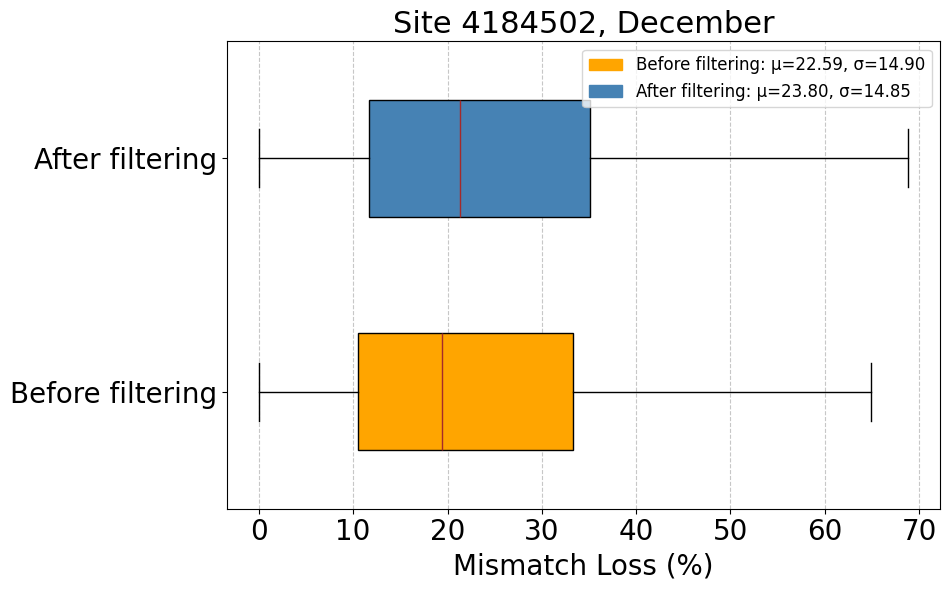

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4184502_March_20250630_183556
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4184502_March_20250630_183556\module_param_df.csv
df_pivot shape: (1164, 98)
2024-03-17 11:25:00 → 261526501_diode_activation=-1.0, Voc_261526501_outlier_label=1.0, Isc_261526501_outlier_label=-1.0
2024-03-17 11:30:00 → 261526501_diode_activation=-1.0, Voc_261526501_outlier_label=1.0, Isc_261526501_outlier_label=-1.0
2024-03-17 11:50:00 → 261526615_diode_activation=-1.0, Voc_261526615_outlier_label=1.0, Isc_261526615_outlier_label=-1.0
2024-03-18 11:25:00 → 261526501_diode_activation=-1.0, Voc_261526501_outlier_label=1.0, Isc_261526501_outlier_label=-1.0
2024-03-18 11:30:00 → 261526501_diode_activation=-1.0, Voc_261526501_outlier_label=1.0, Isc_261526501_outlier_label=-1.0
2024-03-18 11:35:00 → 26152

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


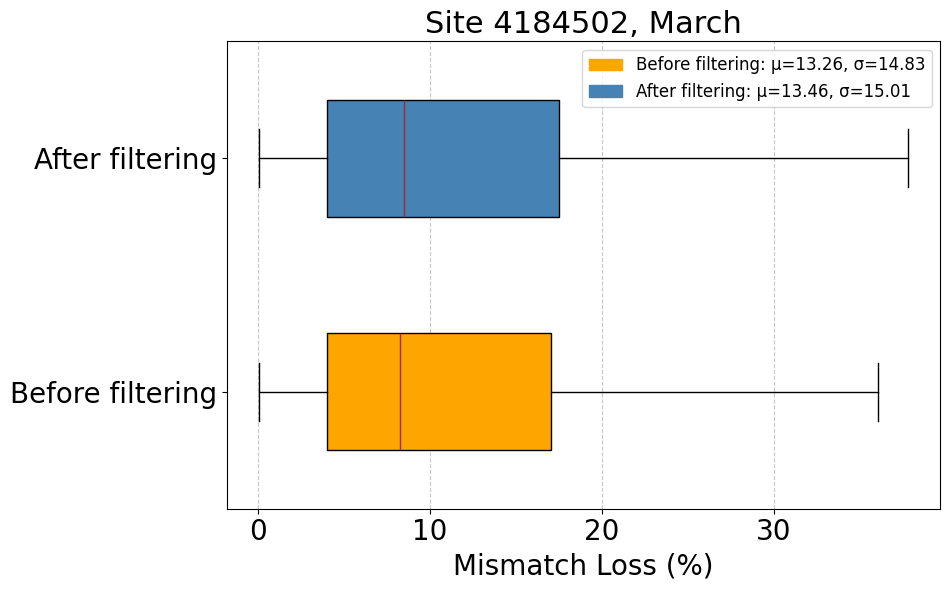

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4073264_September_20250630_014857
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4073264_September_20250630_014857\module_param_df.csv
df_pivot shape: (1431, 56)
2024-09-21 14:40:00 → 260179396_diode_activation=-1.0, Voc_260179396_outlier_label=1.0, Isc_260179396_outlier_label=-1.0
2024-09-21 14:45:00 → 260179396_diode_activation=-1.0, Voc_260179396_outlier_label=1.0, Isc_260179396_outlier_label=-1.0
2024-09-28 16:30:00 → 260179401_diode_activation=-1.0, Voc_260179401_outlier_label=1.0, Isc_260179401_outlier_label=-1.0
2024-09-28 16:45:00 → 260179401_diode_activation=-1.0, Voc_260179401_outlier_label=1.0, Isc_260179401_outlier_label=-1.0
2024-09-28 16:50:00 → 260179401_diode_activation=-1.0, Voc_260179401_outlier_label=1.0, Isc_260179401_outlier_label=-1.0
2024-09-28 17:00:00

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


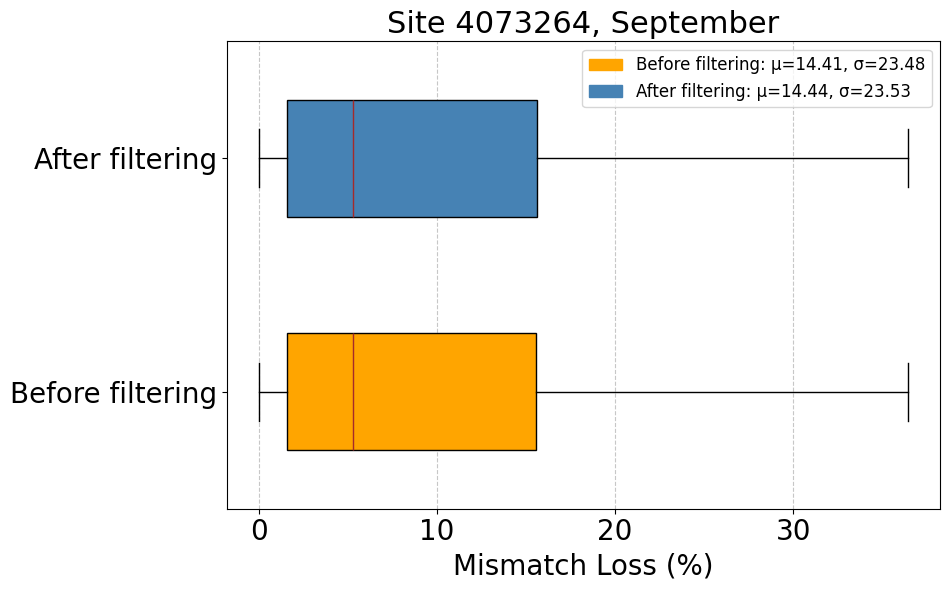

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4073264_June_20250630_013114
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4073264_June_20250630_013114\module_param_df.csv
df_pivot shape: (1898, 56)
2024-06-15 07:35:00 → 260179429_diode_activation=-1.0, Voc_260179429_outlier_label=1.0, Isc_260179429_outlier_label=-1.0
2024-06-15 07:40:00 → 260179429_diode_activation=-1.0, Voc_260179429_outlier_label=1.0, Isc_260179429_outlier_label=-1.0
2024-06-15 07:45:00 → 260179429_diode_activation=-1.0, Voc_260179429_outlier_label=1.0, Isc_260179429_outlier_label=-1.0
2024-06-15 07:50:00 → 260179429_diode_activation=-1.0, Voc_260179429_outlier_label=1.0, Isc_260179429_outlier_label=-1.0
2024-06-15 07:55:00 → 260179429_diode_activation=-1.0, Voc_260179429_outlier_label=1.0, Isc_260179429_outlier_label=-1.0
2024-06-15 08:00:00 → 2601794

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


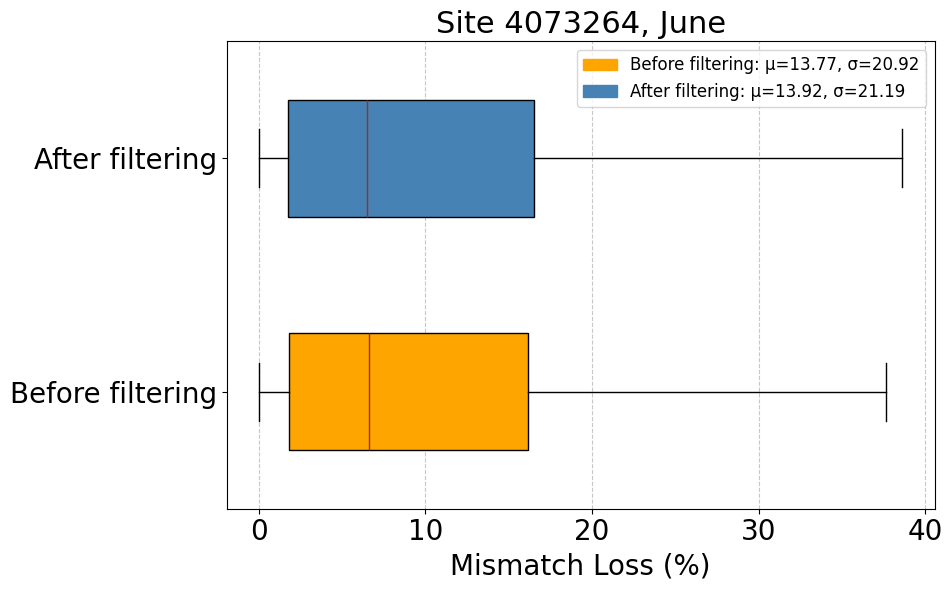

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4073264_December_20250630_020204
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4073264_December_20250630_020204\module_param_df.csv
df_pivot shape: (1030, 56)
2024-12-17 13:15:00 → 260179396_diode_activation=-1.0, Voc_260179396_outlier_label=1.0, Isc_260179396_outlier_label=-1.0
2024-12-17 13:15:00 → 260179401_diode_activation=-1.0, Voc_260179401_outlier_label=1.0, Isc_260179401_outlier_label=-1.0
2024-12-24 09:50:00 → 260179401_diode_activation=-1.0, Voc_260179401_outlier_label=1.0, Isc_260179401_outlier_label=-1.0
2024-12-24 09:55:00 → 260179401_diode_activation=-1.0, Voc_260179401_outlier_label=1.0, Isc_260179401_outlier_label=-1.0
2024-12-24 10:00:00 → 260179401_diode_activation=-1.0, Voc_260179401_outlier_label=1.0, Isc_260179401_outlier_label=-1.0
2024-12-24 10:05:00 →

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


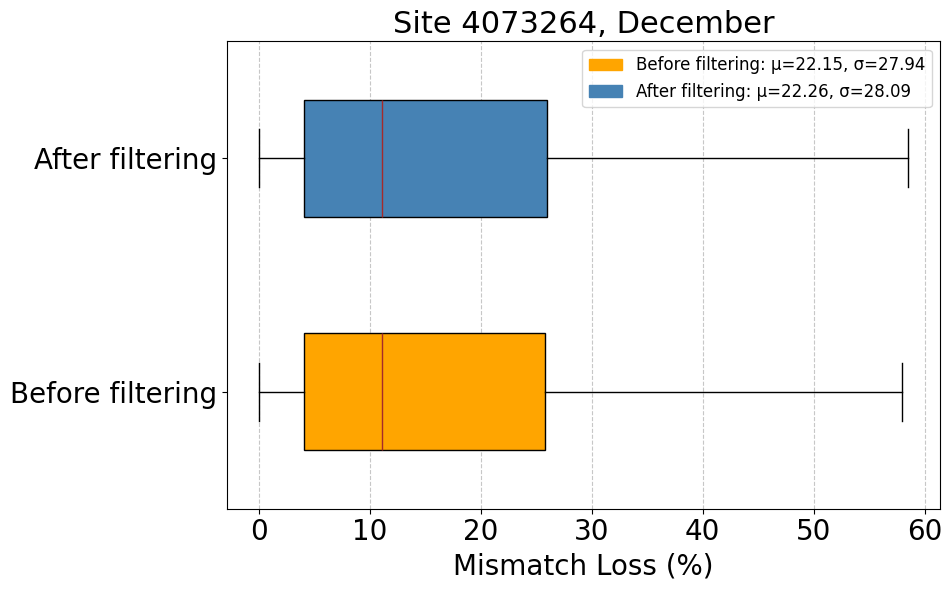

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4073264_March_20250630_011727
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4073264_March_20250630_011727\module_param_df.csv
df_pivot shape: (1469, 56)
2024-03-20 07:45:00 → 260179429_diode_activation=-1.0, Voc_260179429_outlier_label=1.0, Isc_260179429_outlier_label=-1.0
2024-03-21 08:05:00 → 260179426_diode_activation=-1.0, Voc_260179426_outlier_label=1.0, Isc_260179426_outlier_label=-1.0
2024-03-23 10:50:00 → 260179396_diode_activation=-1.0, Voc_260179396_outlier_label=1.0, Isc_260179396_outlier_label=-1.0
2024-03-24 10:30:00 → 260179429_diode_activation=-1.0, Voc_260179429_outlier_label=1.0, Isc_260179429_outlier_label=-1.0
Looking for combined file in C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\40732

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


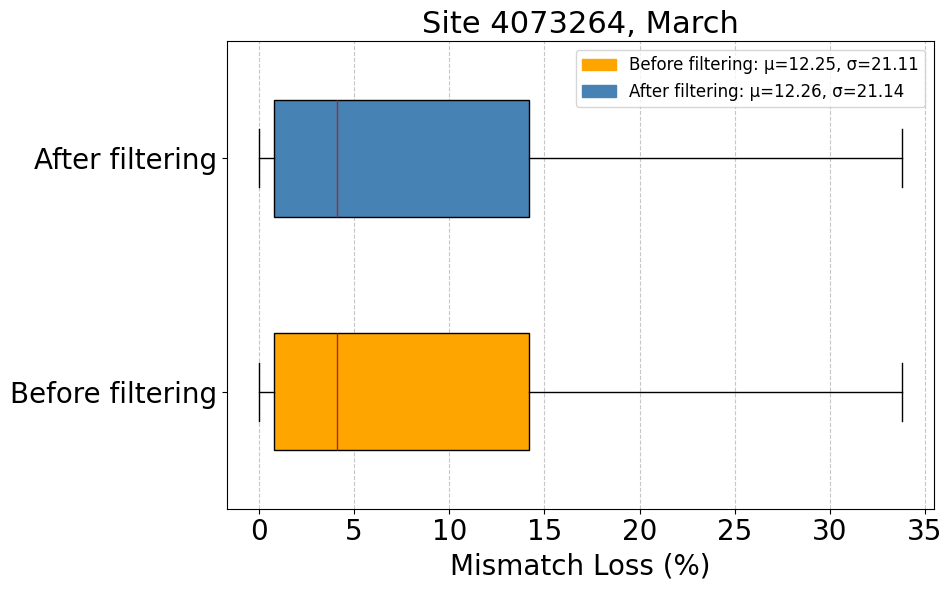

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4093266_September_20250630_024744
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4093266_September_20250630_024744\module_param_df.csv
df_pivot shape: (1410, 126)
2024-09-20 11:05:00 → 255143481_diode_activation=-1.0, Voc_255143481_outlier_label=1.0, Isc_255143481_outlier_label=-1.0
2024-09-20 11:20:00 → 255143481_diode_activation=-1.0, Voc_255143481_outlier_label=1.0, Isc_255143481_outlier_label=-1.0
2024-09-20 11:25:00 → 255143481_diode_activation=-1.0, Voc_255143481_outlier_label=1.0, Isc_255143481_outlier_label=-1.0
2024-09-20 11:25:00 → 255143482_diode_activation=-1.0, Voc_255143482_outlier_label=1.0, Isc_255143482_outlier_label=-1.0
2024-09-20 11:30:00 → 255143481_diode_activation=-1.0, Voc_255143481_outlier_label=1.0, Isc_255143481_outlier_label=-1.0
2024-09-20 11:30:0

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


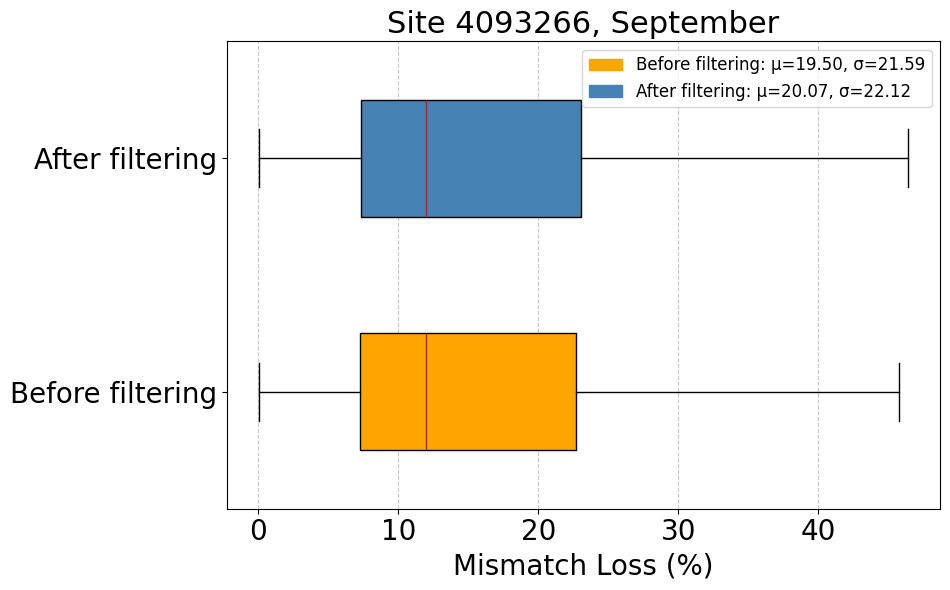

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4093266_June_20250630_022704
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4093266_June_20250630_022704\module_param_df.csv
df_pivot shape: (1816, 126)
2024-06-15 11:20:00 → 255143481_diode_activation=-1.0, Voc_255143481_outlier_label=1.0, Isc_255143481_outlier_label=-1.0
2024-06-15 11:20:00 → 255143482_diode_activation=-1.0, Voc_255143482_outlier_label=1.0, Isc_255143482_outlier_label=-1.0
2024-06-15 11:20:00 → 255144112_diode_activation=-1.0, Voc_255144112_outlier_label=1.0, Isc_255144112_outlier_label=-1.0
2024-06-15 11:25:00 → 255143482_diode_activation=-1.0, Voc_255143482_outlier_label=1.0, Isc_255143482_outlier_label=-1.0
2024-06-15 11:25:00 → 255144112_diode_activation=-1.0, Voc_255144112_outlier_label=1.0, Isc_255144112_outlier_label=-1.0
2024-06-15 11:35:00 → 255143

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


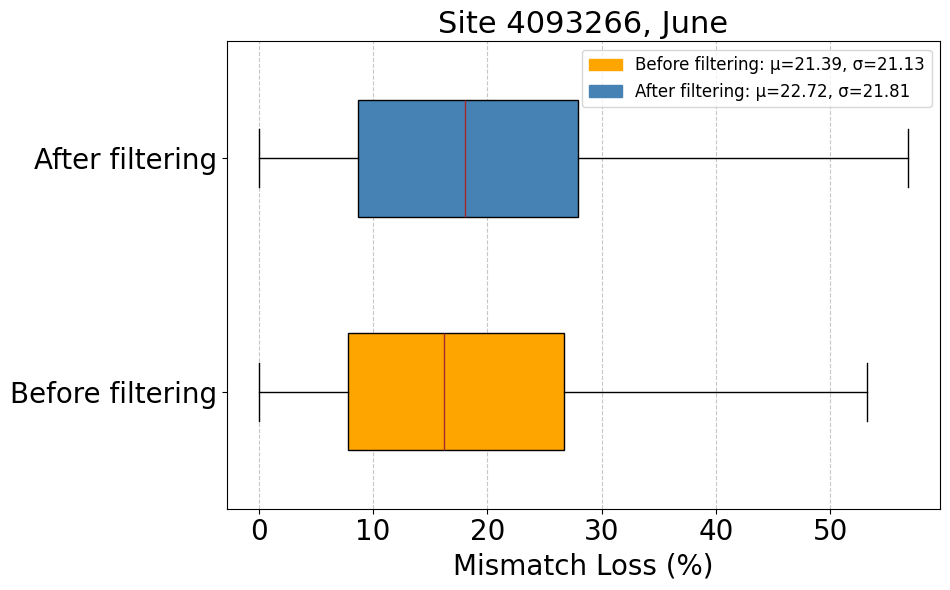

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4093266_December_20250630_030414
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4093266_December_20250630_030414\module_param_df.csv
df_pivot shape: (1021, 126)
2024-12-17 09:00:00 → 255143482_diode_activation=-1.0, Voc_255143482_outlier_label=1.0, Isc_255143482_outlier_label=-1.0
2024-12-17 09:05:00 → 255143481_diode_activation=-1.0, Voc_255143481_outlier_label=1.0, Isc_255143481_outlier_label=-1.0
2024-12-17 09:05:00 → 255143482_diode_activation=-1.0, Voc_255143482_outlier_label=1.0, Isc_255143482_outlier_label=-1.0
2024-12-17 09:10:00 → 255143481_diode_activation=-1.0, Voc_255143481_outlier_label=1.0, Isc_255143481_outlier_label=-1.0
2024-12-17 09:10:00 → 255143482_diode_activation=-1.0, Voc_255143482_outlier_label=1.0, Isc_255143482_outlier_label=-1.0
2024-12-17 09:15:00 

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


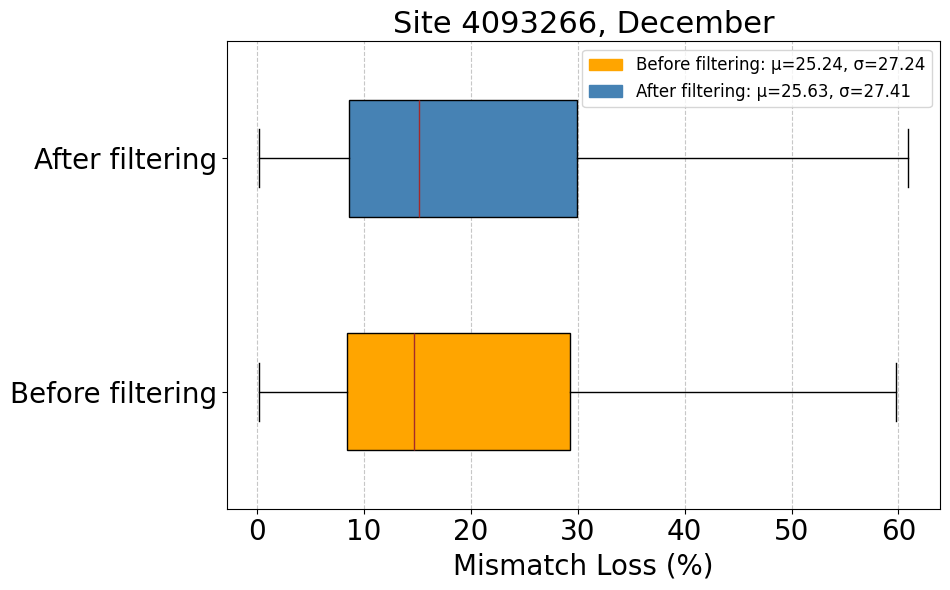

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4093266_March_20250630_021134
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4093266_March_20250630_021134\module_param_df.csv
df_pivot shape: (1447, 126)
2024-03-15 14:50:00 → 255143502_diode_activation=-1.0, Voc_255143502_outlier_label=1.0, Isc_255143502_outlier_label=-1.0
2024-03-15 14:55:00 → 255143502_diode_activation=-1.0, Voc_255143502_outlier_label=1.0, Isc_255143502_outlier_label=-1.0
2024-03-15 15:05:00 → 255143502_diode_activation=-1.0, Voc_255143502_outlier_label=1.0, Isc_255143502_outlier_label=-1.0
2024-03-15 15:10:00 → 255143502_diode_activation=-1.0, Voc_255143502_outlier_label=1.0, Isc_255143502_outlier_label=-1.0
2024-03-15 15:25:00 → 255144102_diode_activation=-1.0, Voc_255144102_outlier_label=1.0, Isc_255144102_outlier_label=-1.0
2024-03-15 15:45:00 → 2551

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


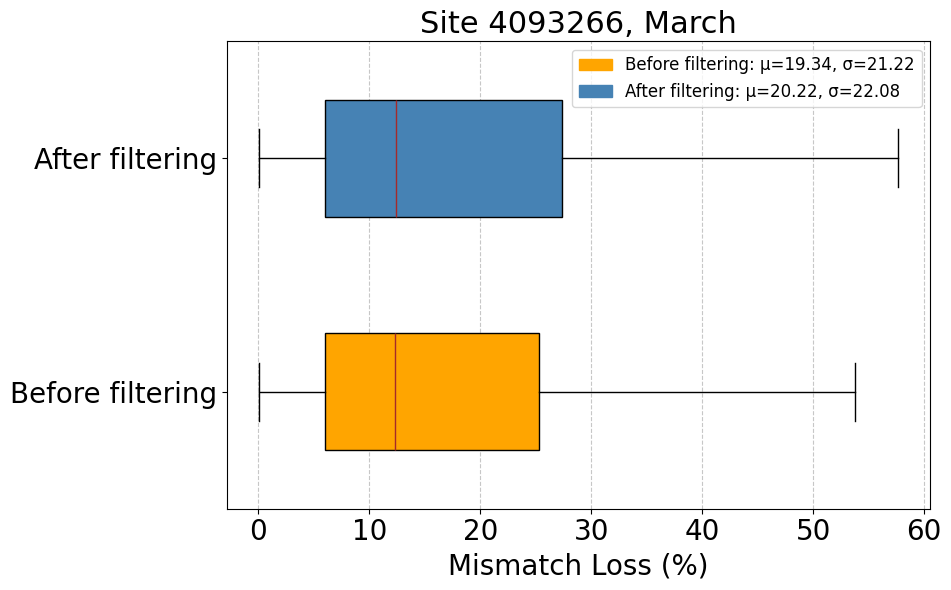

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4162787_September_20250630_160724
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4162787_September_20250630_160724\module_param_df.csv
df_pivot shape: (1454, 56)
2024-09-20 16:10:00 → 260340234_diode_activation=-1.0, Voc_260340234_outlier_label=1.0, Isc_260340234_outlier_label=-1.0
2024-09-20 16:15:00 → 260340234_diode_activation=-1.0, Voc_260340234_outlier_label=1.0, Isc_260340234_outlier_label=-1.0
2024-09-20 16:30:00 → 260340234_diode_activation=-1.0, Voc_260340234_outlier_label=1.0, Isc_260340234_outlier_label=-1.0
2024-09-20 16:35:00 → 260340234_diode_activation=-1.0, Voc_260340234_outlier_label=1.0, Isc_260340234_outlier_label=-1.0
2024-09-20 16:40:00 → 260340227_diode_activation=-1.0, Voc_260340227_outlier_label=1.0, Isc_260340227_outlier_label=-1.0
2024-09-21 16:15:00

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


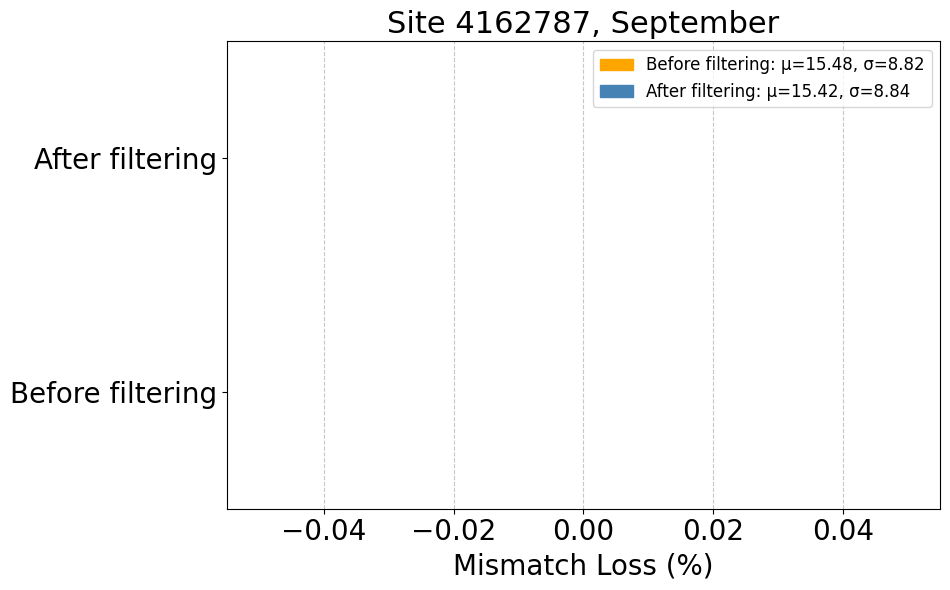

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4162787_June_20250630_155048
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4162787_June_20250630_155048\module_param_df.csv
df_pivot shape: (2051, 56)
2024-06-17 20:45:00 → 260340229_diode_activation=1.0, Voc_260340229_outlier_label=-1.0, Isc_260340229_outlier_label=0.0
2024-06-20 10:30:00 → 260340226_diode_activation=-1.0, Voc_260340226_outlier_label=1.0, Isc_260340226_outlier_label=-1.0
2024-06-23 07:25:00 → 260340230_diode_activation=1.0, Voc_260340230_outlier_label=-1.0, Isc_260340230_outlier_label=0.0
2024-06-24 07:25:00 → 260340230_diode_activation=1.0, Voc_260340230_outlier_label=-1.0, Isc_260340230_outlier_label=0.0
Looking for combined file in C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4162787_Ju

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


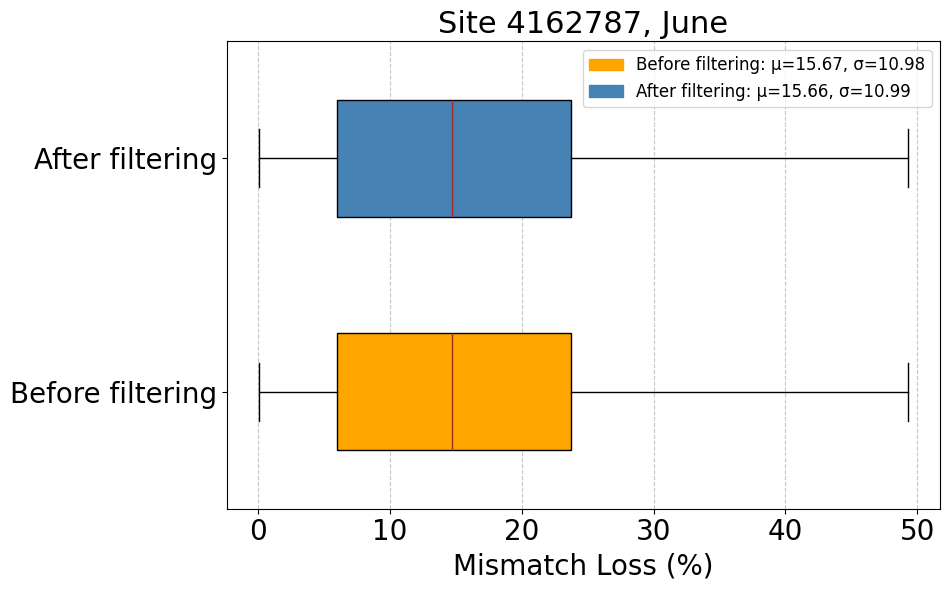

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4162787_December_20250630_161858
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4162787_December_20250630_161858\module_param_df.csv
df_pivot shape: (914, 56)
Looking for combined file in C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4162787_December_20250630_161858
Original combined data shape: (914, 4)
New combined data shape (after removing diode activation timestamps): (914, 4)
Columns in combined_df: ['Sum of I*V (W)', 'Pmppt (W)', 'Season', 'Site ID']


C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


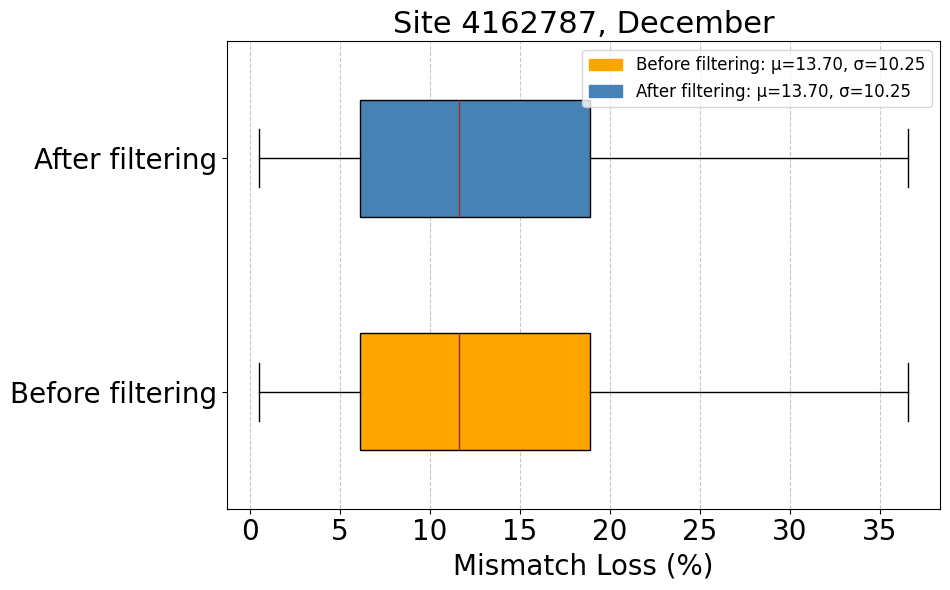

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4162787_March_20250630_153919
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4162787_March_20250630_153919\module_param_df.csv
df_pivot shape: (1457, 56)
2024-03-18 15:25:00 → 260340227_diode_activation=-1.0, Voc_260340227_outlier_label=1.0, Isc_260340227_outlier_label=-1.0
2024-03-18 15:30:00 → 260340227_diode_activation=-1.0, Voc_260340227_outlier_label=1.0, Isc_260340227_outlier_label=-1.0
2024-03-18 15:35:00 → 260340227_diode_activation=-1.0, Voc_260340227_outlier_label=1.0, Isc_260340227_outlier_label=-1.0
2024-03-18 15:40:00 → 260340227_diode_activation=-1.0, Voc_260340227_outlier_label=1.0, Isc_260340227_outlier_label=-1.0
2024-03-18 15:45:00 → 260340227_diode_activation=-1.0, Voc_260340227_outlier_label=1.0, Isc_260340227_outlier_label=-1.0
Looking for combined file i

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


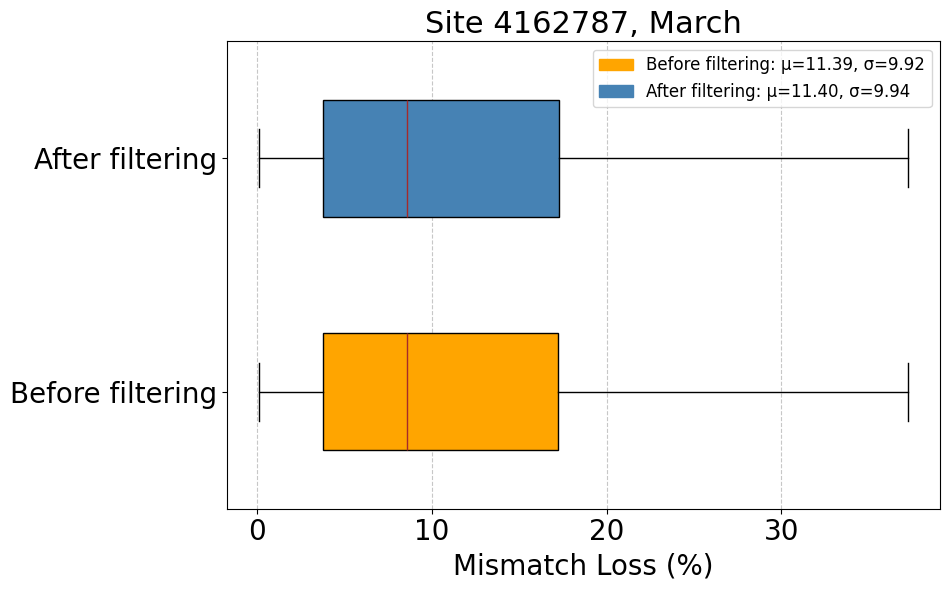

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4172746_September_20250630_165604
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4172746_September_20250630_165604\module_param_df.csv
df_pivot shape: (1483, 126)
2024-09-20 10:50:00 → 260988686_diode_activation=-1.0, Voc_260988686_outlier_label=1.0, Isc_260988686_outlier_label=-1.0
2024-09-20 14:10:00 → 260988490_diode_activation=-1.0, Voc_260988490_outlier_label=1.0, Isc_260988490_outlier_label=-1.0
2024-09-20 14:10:00 → 260988686_diode_activation=-1.0, Voc_260988686_outlier_label=1.0, Isc_260988686_outlier_label=-1.0
2024-09-20 14:15:00 → 260988490_diode_activation=-1.0, Voc_260988490_outlier_label=1.0, Isc_260988490_outlier_label=-1.0
2024-09-20 14:15:00 → 260988686_diode_activation=-1.0, Voc_260988686_outlier_label=1.0, Isc_260988686_outlier_label=-1.0
2024-09-20 14:20:0

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


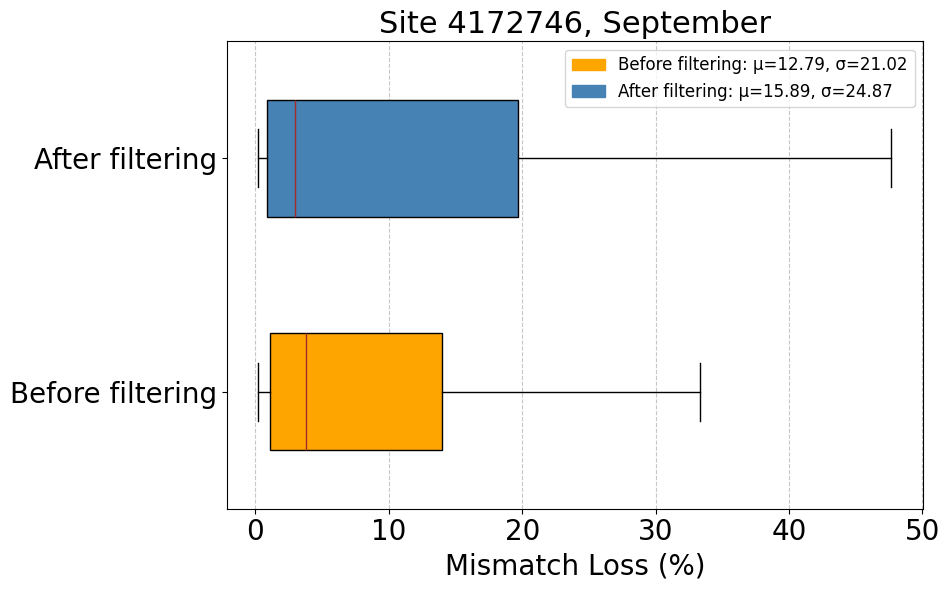

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4172746_June_20250630_163939
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4172746_June_20250630_163939\module_param_df.csv
df_pivot shape: (1743, 126)
2024-06-15 07:10:00 → 260988686_diode_activation=-1.0, Voc_260988686_outlier_label=1.0, Isc_260988686_outlier_label=-1.0
2024-06-15 12:00:00 → 260988685_diode_activation=-1.0, Voc_260988685_outlier_label=1.0, Isc_260988685_outlier_label=-1.0
2024-06-15 14:10:00 → 260988680_diode_activation=-1.0, Voc_260988680_outlier_label=1.0, Isc_260988680_outlier_label=-1.0
2024-06-15 14:15:00 → 260988680_diode_activation=-1.0, Voc_260988680_outlier_label=1.0, Isc_260988680_outlier_label=-1.0
2024-06-15 14:20:00 → 260988679_diode_activation=-1.0, Voc_260988679_outlier_label=1.0, Isc_260988679_outlier_label=-1.0
2024-06-15 14:25:00 → 260988

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


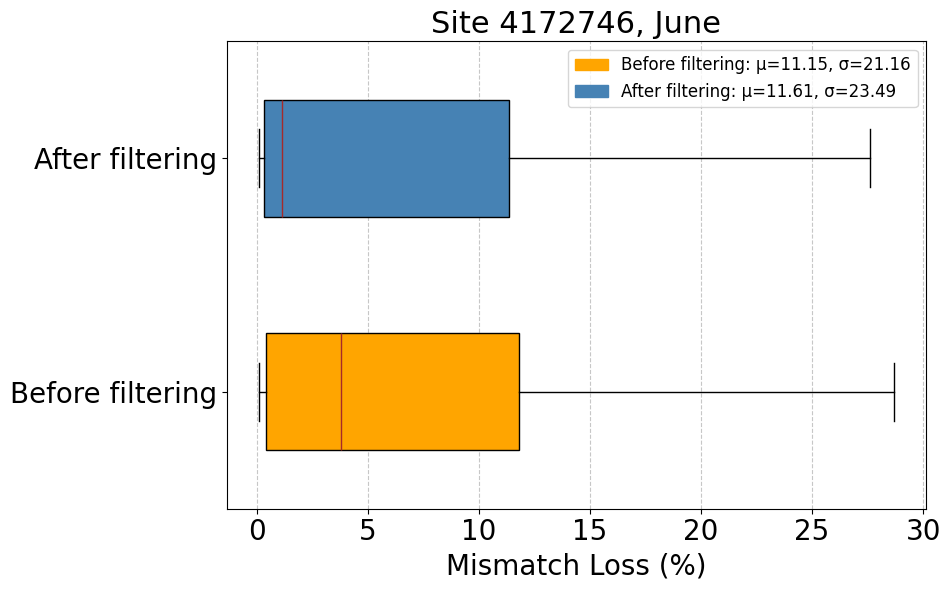

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4172746_December_20250630_171038
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4172746_December_20250630_171038\module_param_df.csv
df_pivot shape: (1234, 126)
2024-12-15 09:00:00 → 260988680_diode_activation=-1.0, Voc_260988680_outlier_label=1.0, Isc_260988680_outlier_label=-1.0
2024-12-15 09:00:00 → 260989411_diode_activation=-1.0, Voc_260989411_outlier_label=1.0, Isc_260989411_outlier_label=-1.0
2024-12-15 09:05:00 → 260988680_diode_activation=-1.0, Voc_260988680_outlier_label=1.0, Isc_260988680_outlier_label=-1.0
2024-12-15 09:05:00 → 260989411_diode_activation=-1.0, Voc_260989411_outlier_label=1.0, Isc_260989411_outlier_label=-1.0
2024-12-15 09:10:00 → 260988680_diode_activation=-1.0, Voc_260988680_outlier_label=1.0, Isc_260988680_outlier_label=-1.0
2024-12-15 09:10:00 

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


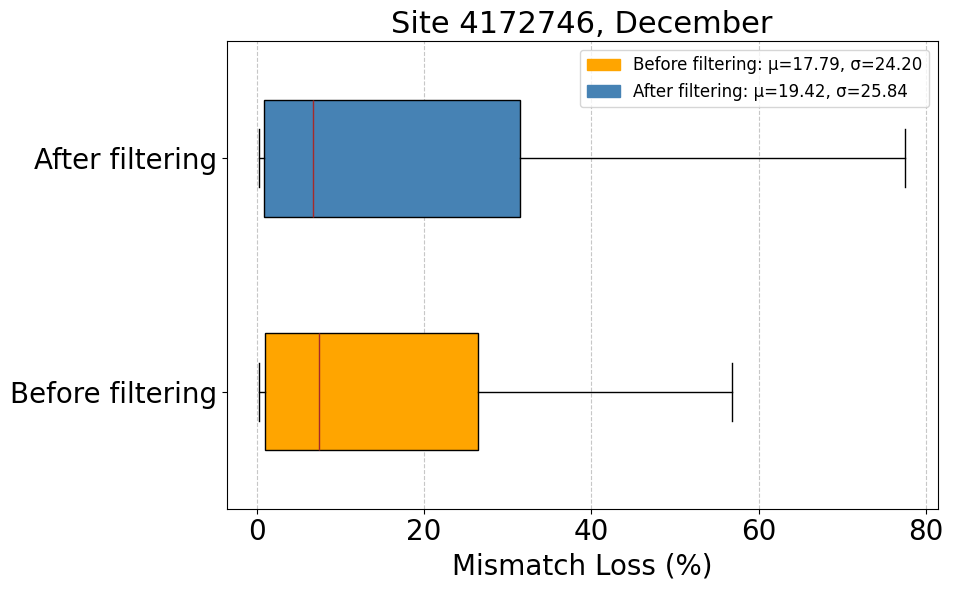

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4172746_March_20250630_162603
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4172746_March_20250630_162603\module_param_df.csv
df_pivot shape: (1480, 126)
2024-03-16 08:20:00 → 260988490_diode_activation=-1.0, Voc_260988490_outlier_label=1.0, Isc_260988490_outlier_label=-1.0
2024-03-16 08:45:00 → 260988490_diode_activation=-1.0, Voc_260988490_outlier_label=1.0, Isc_260988490_outlier_label=-1.0
2024-03-16 08:55:00 → 260988878_diode_activation=-1.0, Voc_260988878_outlier_label=1.0, Isc_260988878_outlier_label=-1.0
2024-03-16 10:15:00 → 260988679_diode_activation=-1.0, Voc_260988679_outlier_label=1.0, Isc_260988679_outlier_label=-1.0
2024-03-16 10:20:00 → 260988679_diode_activation=-1.0, Voc_260988679_outlier_label=1.0, Isc_260988679_outlier_label=-1.0
2024-03-16 10:35:00 → 2609

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


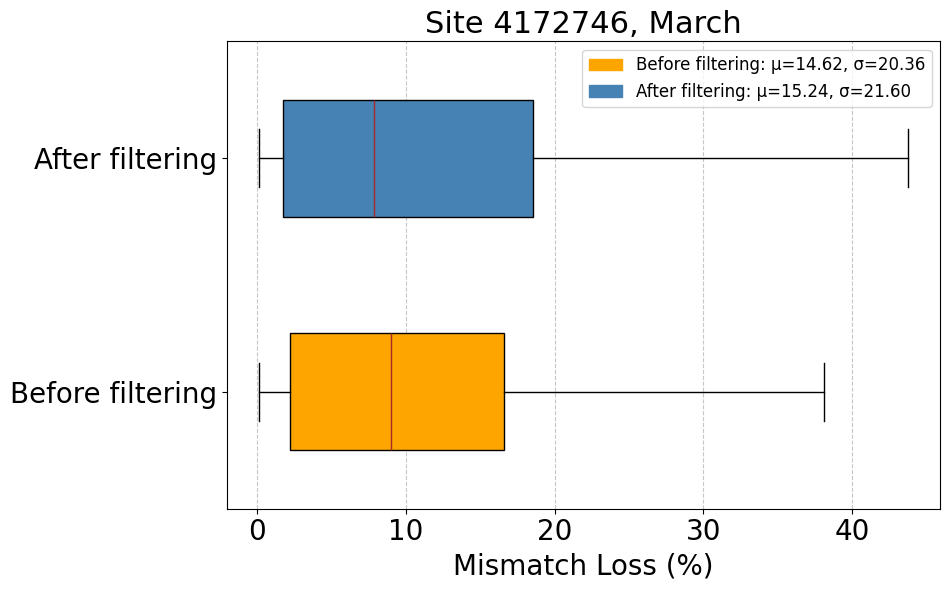

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4153809_September_20250630_150933
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4153809_September_20250630_150933\module_param_df.csv
df_pivot shape: (1460, 126)
2024-09-20 18:50:00 → 260258838_diode_activation=1.0, Voc_260258838_outlier_label=-1.0, Isc_260258838_outlier_label=0.0
2024-09-22 09:25:00 → 260258848_diode_activation=1.0, Voc_260258848_outlier_label=-1.0, Isc_260258848_outlier_label=0.0
2024-09-28 18:50:00 → 260258838_diode_activation=1.0, Voc_260258838_outlier_label=-1.0, Isc_260258838_outlier_label=0.0
2024-09-29 09:15:00 → 260258848_diode_activation=1.0, Voc_260258848_outlier_label=-1.0, Isc_260258848_outlier_label=0.0
2024-09-29 09:25:00 → 260258835_diode_activation=1.0, Voc_260258835_outlier_label=-1.0, Isc_260258835_outlier_label=0.0
Looking for combined fi

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


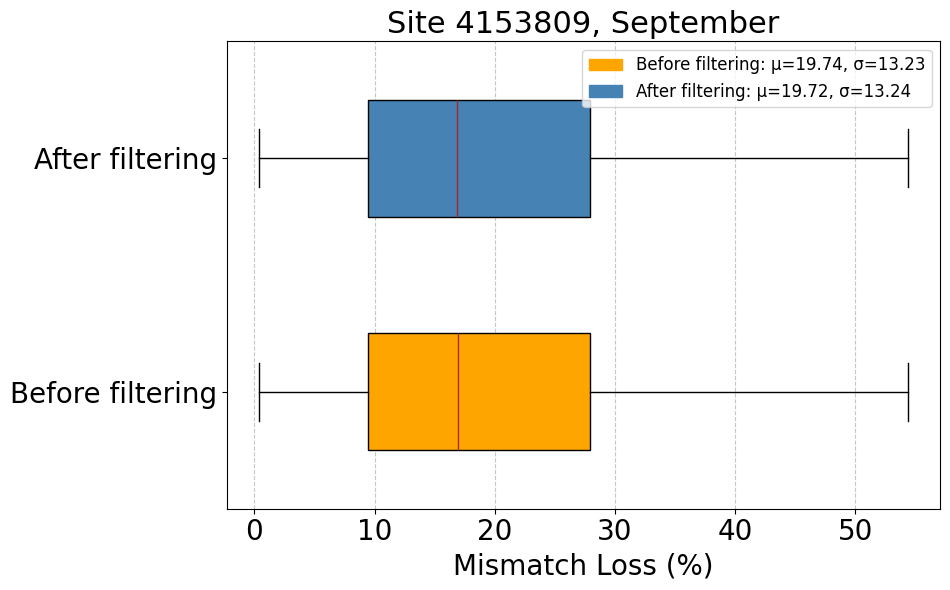

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4153809_June_20250630_144258
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4153809_June_20250630_144258\module_param_df.csv
df_pivot shape: (2041, 126)
2024-06-15 13:45:00 → 260258840_diode_activation=-1.0, Voc_260258840_outlier_label=1.0, Isc_260258840_outlier_label=-1.0
2024-06-15 21:00:00 → 260258845_diode_activation=1.0, Voc_260258845_outlier_label=-1.0, Isc_260258845_outlier_label=0.0
2024-06-16 21:05:00 → 260258845_diode_activation=1.0, Voc_260258845_outlier_label=-1.0, Isc_260258845_outlier_label=0.0
2024-06-17 21:00:00 → 260258845_diode_activation=1.0, Voc_260258845_outlier_label=-1.0, Isc_260258845_outlier_label=0.0
2024-06-19 21:00:00 → 260258837_diode_activation=1.0, Voc_260258837_outlier_label=-1.0, Isc_260258837_outlier_label=0.0
2024-06-21 11:45:00 → 260258831_

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


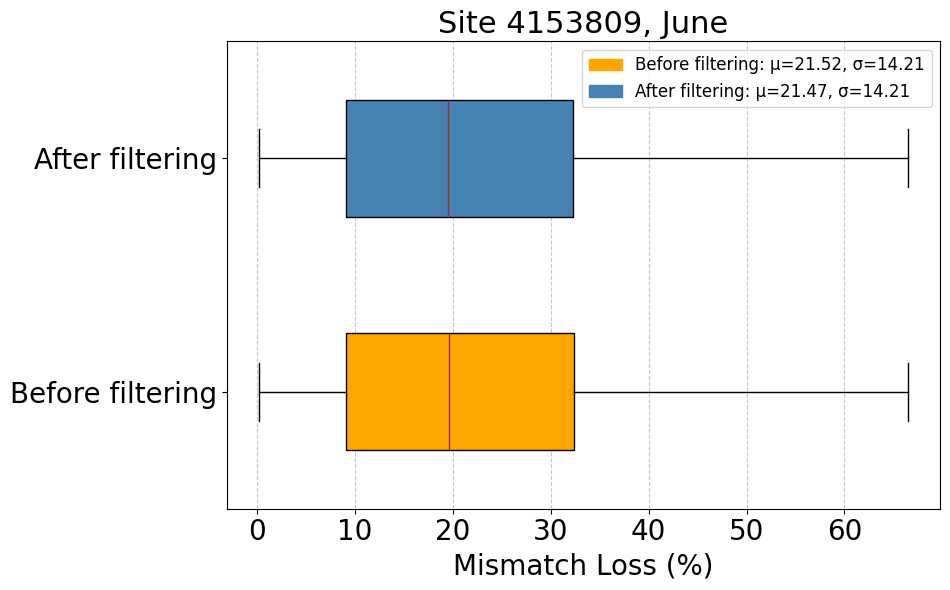

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4153809_December_20250630_153012
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4153809_December_20250630_153012\module_param_df.csv
df_pivot shape: (891, 126)
2024-12-20 10:25:00 → 260258847_diode_activation=1.0, Voc_260258847_outlier_label=-1.0, Isc_260258847_outlier_label=0.0
2024-12-23 09:55:00 → 260258836_diode_activation=1.0, Voc_260258836_outlier_label=-1.0, Isc_260258836_outlier_label=0.0
Looking for combined file in C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4153809_December_20250630_153012
Original combined data shape: (891, 4)
New combined data shape (after removing diode activation timestamps): (889, 4)
Columns in combined_df: ['Sum of I*V (W)', 'Pmppt (W)', 'Season', 'Site ID']


C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


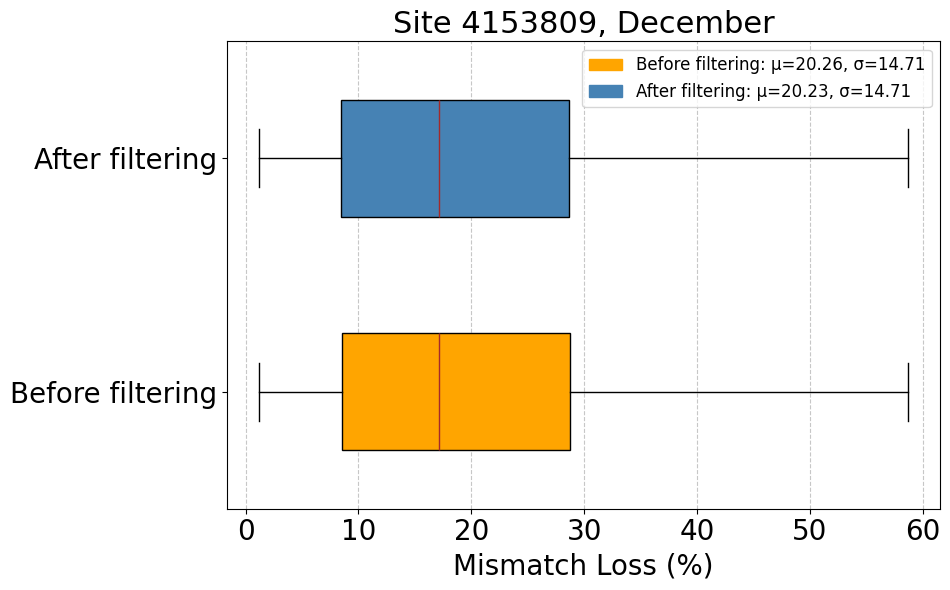

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4153809_March_20250630_142726
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4153809_March_20250630_142726\module_param_df.csv
df_pivot shape: (1465, 126)
2024-03-22 18:40:00 → 260258846_diode_activation=1.0, Voc_260258846_outlier_label=-1.0, Isc_260258846_outlier_label=0.0
2024-03-22 18:45:00 → 260258846_diode_activation=1.0, Voc_260258846_outlier_label=-1.0, Isc_260258846_outlier_label=0.0
2024-03-22 18:50:00 → 260258846_diode_activation=1.0, Voc_260258846_outlier_label=-1.0, Isc_260258846_outlier_label=0.0
2024-03-23 07:50:00 → 260258836_diode_activation=1.0, Voc_260258836_outlier_label=-1.0, Isc_260258836_outlier_label=0.0
Looking for combined file in C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4153809_

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


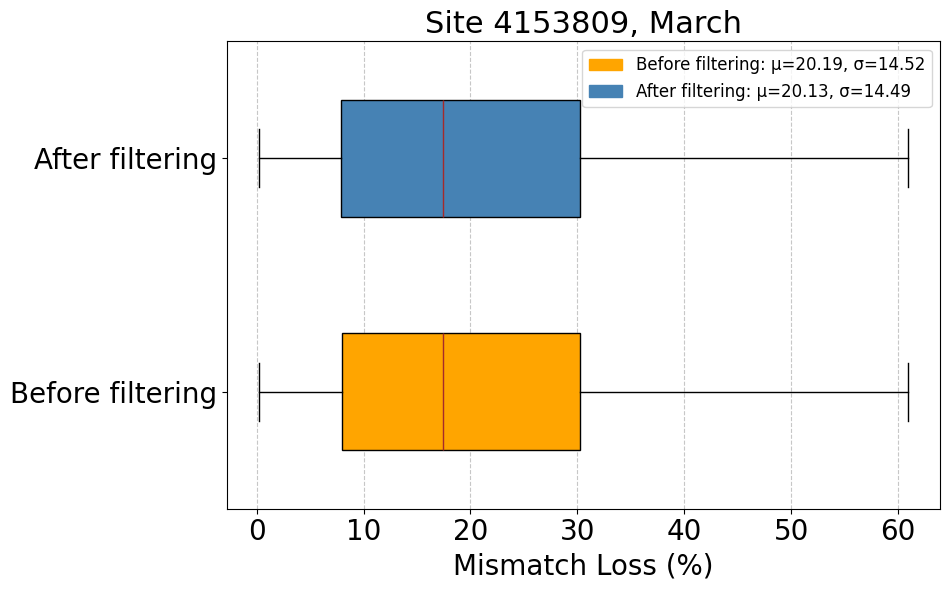

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4002138_September_20250629_231118
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4002138_September_20250629_231118\module_param_df.csv
df_pivot shape: (1515, 98)
Looking for combined file in C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4002138_September_20250629_231118
Original combined data shape: (1515, 4)
New combined data shape (after removing diode activation timestamps): (1515, 4)
Columns in combined_df: ['Sum of I*V (W)', 'Pmppt (W)', 'Season', 'Site ID']


C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


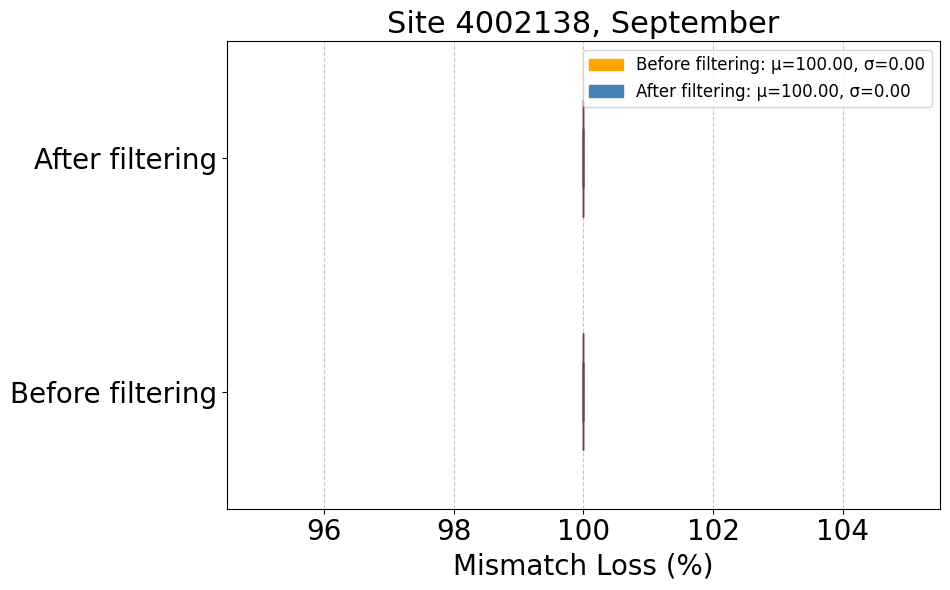

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4002138_June_20250630_000254
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4002138_June_20250630_000254\module_param_df.csv
df_pivot shape: (1175, 126)
2024-06-15 17:05:00 → 251791345_diode_activation=1.0, Voc_251791345_outlier_label=-1.0, Isc_251791345_outlier_label=0.0
2024-06-15 17:10:00 → 251791345_diode_activation=1.0, Voc_251791345_outlier_label=-1.0, Isc_251791345_outlier_label=0.0
2024-06-15 17:15:00 → 251791345_diode_activation=1.0, Voc_251791345_outlier_label=-1.0, Isc_251791345_outlier_label=0.0
2024-06-21 16:10:00 → 251791342_diode_activation=-1.0, Voc_251791342_outlier_label=1.0, Isc_251791342_outlier_label=-1.0
2024-06-23 16:00:00 → 251791342_diode_activation=-1.0, Voc_251791342_outlier_label=1.0, Isc_251791342_outlier_label=-1.0
2024-06-24 16:00:00 → 251791342

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


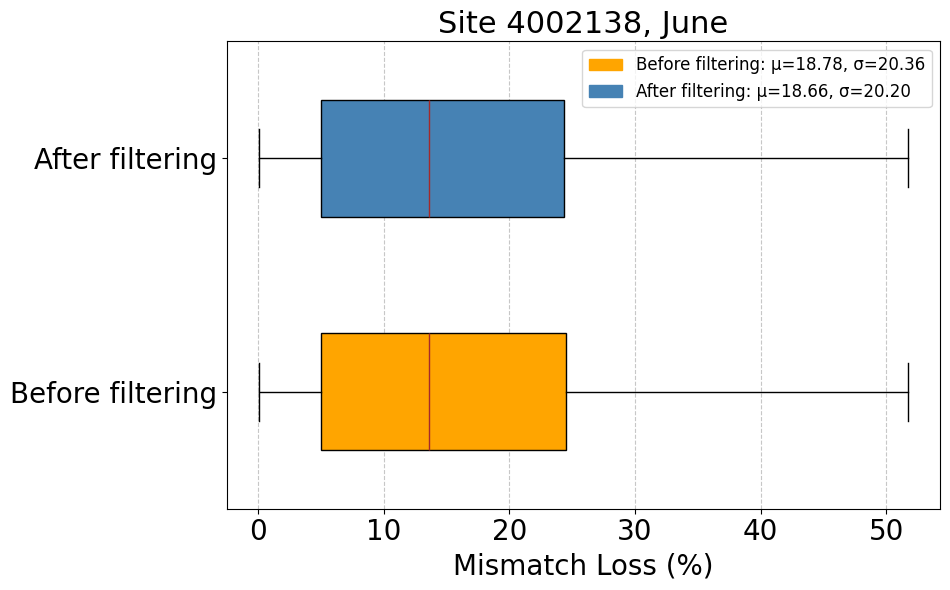

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4002138_December_20250629_232551
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4002138_December_20250629_232551\module_param_df.csv
df_pivot shape: (1762, 126)
2024-12-15 07:45:00 → 251791345_diode_activation=-1.0, Voc_251791345_outlier_label=1.0, Isc_251791345_outlier_label=-1.0
2024-12-15 07:45:00 → 251791348_diode_activation=-1.0, Voc_251791348_outlier_label=1.0, Isc_251791348_outlier_label=-1.0
2024-12-15 07:50:00 → 251791345_diode_activation=-1.0, Voc_251791345_outlier_label=1.0, Isc_251791345_outlier_label=-1.0
2024-12-15 07:50:00 → 251791348_diode_activation=-1.0, Voc_251791348_outlier_label=1.0, Isc_251791348_outlier_label=-1.0
2024-12-15 08:00:00 → 251791346_diode_activation=-1.0, Voc_251791346_outlier_label=1.0, Isc_251791346_outlier_label=-1.0
2024-12-15 08:05:00 

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


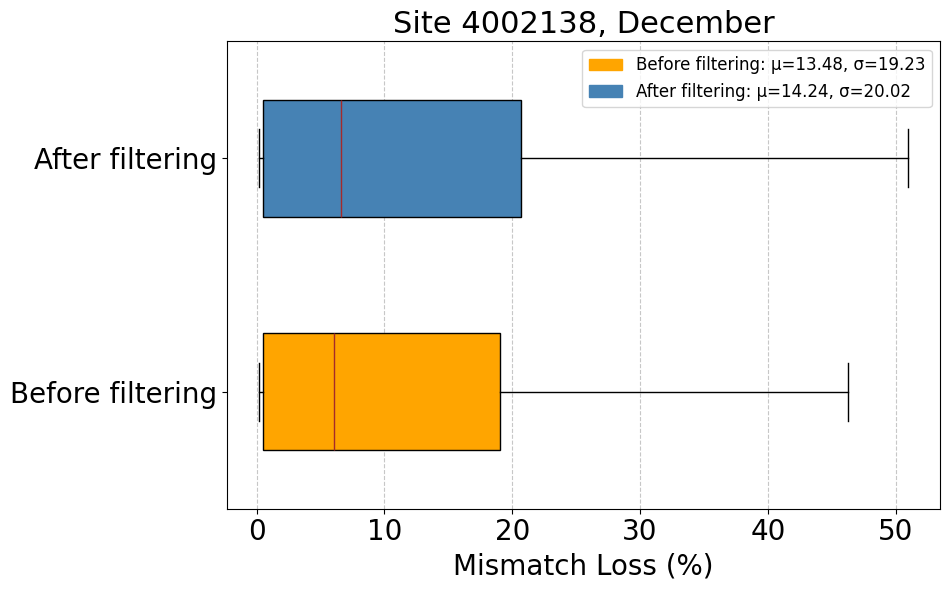

Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4002138_March_20250629_234540
Found file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4002138_March_20250629_234540\module_param_df.csv
df_pivot shape: (1485, 126)
2024-03-15 17:40:00 → 251791341_diode_activation=-1.0, Voc_251791341_outlier_label=1.0, Isc_251791341_outlier_label=-1.0
2024-03-15 17:45:00 → 251791341_diode_activation=-1.0, Voc_251791341_outlier_label=1.0, Isc_251791341_outlier_label=-1.0
2024-03-15 17:50:00 → 251791341_diode_activation=-1.0, Voc_251791341_outlier_label=1.0, Isc_251791341_outlier_label=-1.0
2024-03-15 17:55:00 → 251791341_diode_activation=-1.0, Voc_251791341_outlier_label=1.0, Isc_251791341_outlier_label=-1.0
2024-03-15 18:00:00 → 251791341_diode_activation=-1.0, Voc_251791341_outlier_label=1.0, Isc_251791341_outlier_label=-1.0
2024-03-15 18:00:00 → 2517

C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['Mismatch Loss (%)'] = (
C:\Users\z5183876\AppData\Local\Temp\ipykernel_4316\17882372.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


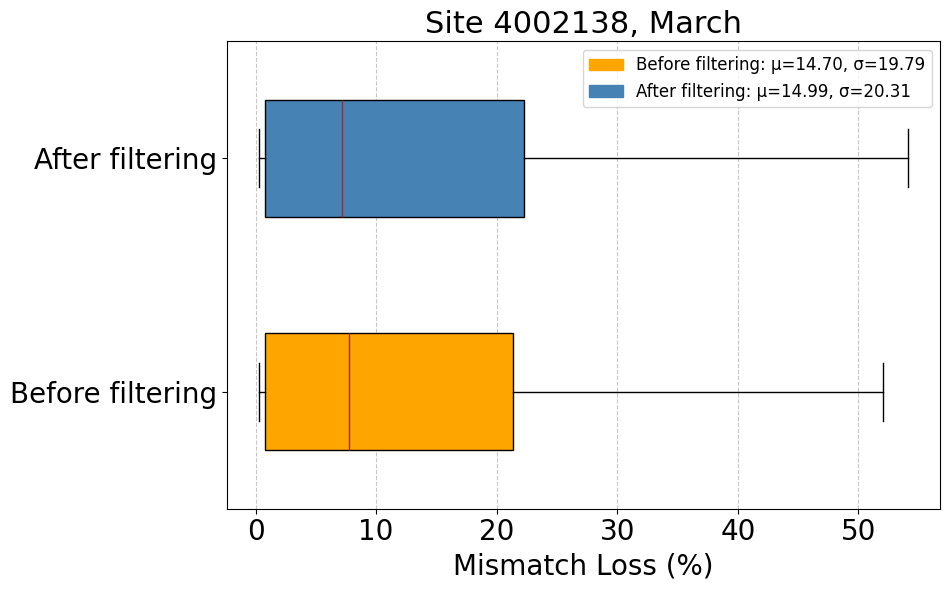

In [29]:
for site_id in site_ids:
    for season in seasons:

       ######################## Voc outlier detector ########################
       # Find the folder
        target_folder = None
        for name in os.listdir(ResultsFolder):
            path = os.path.join(ResultsFolder, name)
            if not os.path.isdir(path):
                continue
            if site_id in name and season.lower() in name.lower():
                target_folder = path
                print(f"Found target folder: {target_folder}")
                break

        if target_folder is not None:
            # List files in the folder
            files = os.listdir(target_folder)
            # look for a csv file that contains the word module
            for file in files:
                if 'module' in file.lower() and file.endswith('.csv'):
                    target_file = os.path.join(target_folder, file)
                    print(f"Found file: {target_file}")
                    # read the csv file
                    df = pd.read_csv(target_file)

                    df = df.dropna(how='all')   # only toss rows that are 100% NaN

                    df_pivot = df.pivot_table(
                        index   ='Timestamp',
                        columns ='Optimizer',
                        values  =['I0','Isc','Voc','FF','Pmp','Imp','Vmp'],
                        aggfunc ='first'
                    )

                    # if you really want to lose only optimizers that never showed up:
                    df_pivot = df_pivot.dropna(axis=1, how='all')

                    print('df_pivot shape:', df_pivot.shape)


                    # ensure the index is datetime
                    df_pivot.index = pd.to_datetime(df_pivot.index)

                    # --- flatten the MultiIndex columns to simple strings ---
                    df_pivot.columns = ['{}_{}'.format(var, opt) for var, opt in df_pivot.columns]

                    # find the flattened Voc columns
                    voc_cols = [c for c in df_pivot.columns if c.startswith('Voc_')]

                    # calculate the median of the Voc rows
                    # voc_median = df_pivot[voc_cols].median(axis=0)

                    # compute three outlier masks row‐wise
                    mask1   = df_pivot[voc_cols].apply(lambda row: outlier_1_identifier(row), axis=1)
                    # mask_n1 = df_pivot[voc_cols].apply(lambda row: outlier_n1_identifier(row), axis=1)
                    # mask_n2 = df_pivot[voc_cols].apply(lambda row: outlier_n2_identifier(row), axis=1)
                    
                    # define mask_n1 & mask_n2 using the median of each row
                    mask_n1 = df_pivot[voc_cols].apply(
                        lambda row: (row < 2/3 * row.quantile(0.95)) & (row > 1/3 * row.quantile(0.95)),
                        axis=1
                    )
                    mask_n2 = df_pivot[voc_cols].apply(
                        lambda row: row < 1/3 * row.quantile(0.95),
                        axis=1
                    )
                    # combine all masks into a single label a single label: 
                    #   1 if mask1, -1 if mask_n1, -2 if mask_n2, else 0
                    for col in voc_cols:
                        df_pivot[f'{col}_outlier_label'] = np.where(
                            mask1[col],   1,
                            np.where(mask_n1[col], -1,
                                    np.where(mask_n2[col], -2, 0))
                        )

                    # print the outlier labels
                    # print(df_pivot[[col for col in df_pivot.columns if col.endswith('_outlier_label')]].head(10))

            
        ######################## Isc outlier detector ########################
        # find all flattened Isc columns
        isc_cols = [c for c in df_pivot.columns if c.startswith('Isc_')]

        # compute high/low masks
        mask_high_isc = df_pivot[isc_cols].apply(outlier_isc_high, axis=1)
        mask_low_isc  = df_pivot[isc_cols].apply(outlier_isc_low,  axis=1)

        # assign labels: 1 if too high, -1 if too low, else 0
        for col in isc_cols:
            df_pivot[f'{col}_outlier_label'] = np.where(
                mask_high_isc[col],  1,
                np.where(mask_low_isc[col], -1, 0)
            )

        # preview the new Isc outlier labels
        # print(df_pivot[[c for c in df_pivot.columns
        #                 if c.startswith('Isc_') and c.endswith('_outlier_label')]].head(10))
        

        ######################## Diode activation detector ########################
        # build lists of your outlier‐label cols
        voc_label_cols = [c for c in df_pivot.columns
                        if c.startswith('Voc_') and c.endswith('_outlier_label')]
        isc_label_cols = [c for c in df_pivot.columns
                        if c.startswith('Isc_') and c.endswith('_outlier_label')]

        # for each Voc_xxx_outlier_label, pick the matching Isc_xxx_outlier_label
        for voc_col in voc_label_cols:
            opt     = voc_col.replace('Voc_', '').replace('_outlier_label', '')
            isc_lab = f'Isc_{opt}_outlier_label'
            act_col = f'{opt}_diode_activation'
            if isc_lab not in df_pivot.columns:
                continue

            # define conditions
            conds   = [
                (df_pivot[voc_col] == -1) & (df_pivot[isc_lab] == 0),
                (df_pivot[voc_col] == -2) & (df_pivot[isc_lab] == 0),
                (df_pivot[voc_col] ==  1) & (df_pivot[isc_lab] == -1)
            ]
            choices = [1, 2, -1]

            # assign activation label
            df_pivot[act_col] = np.select(conds, choices, default=0)

            # if actual Isc < 1 A, force activation to 0
            # df_pivot.loc[df_pivot[f'Isc_{opt}'] < 1, act_col] = 0

        # ensure the index has a name
        df_pivot.index.name = 'Timestamp'

        # build output filename with site_id and season, and save into the matching ResultsFolder sub-folder
        output_filename = f"{site_id}_{season}_outlier_labels.csv"
        output_path     = os.path.join(target_folder or ResultsFolder, output_filename)

        df_pivot.to_csv(
            output_path,
            index=True,
            index_label='Timestamp'
        )

        # # collect all diode‐activation columns
        act_cols = [c for c in df_pivot.columns if c.endswith('_diode_activation')]

        # select rows where any activation ≠ 0
        diode_activation = df_pivot[(df_pivot[act_cols] != 0).any(axis=1)]

        # for each timestamp and each activated optimiser, print the diode‐activation value
        # along with its corresponding Voc and Isc outlier labels
        for ts, row in diode_activation.iterrows():
            for act_col in act_cols:
                act_val = row[act_col]
                if act_val != 0:
                    opt = act_col.replace('_diode_activation','')
                    voc_label = f'Voc_{opt}_outlier_label'
                    isc_label = f'Isc_{opt}_outlier_label'
                    print(f"{ts} → {act_col}={act_val}, "
                          f"{voc_label}={row.get(voc_label,'NA')}, "
                          f"{isc_label}={row.get(isc_label,'NA')}")

        ########################## Filter the power files ##########################
        # find the diode activation timestamps
        diode_activation_timestamps = diode_activation.index

        # ensure it is in datetime format
        diode_activation_timestamps = pd.to_datetime(diode_activation_timestamps)

        # read the file in ResultsFolder that contains the word 'combined' and is an excel file
        print(f"Looking for combined file in {target_folder}")
        for file in os.listdir(target_folder):
            if 'combined' in file and file.endswith('.xlsx'):
                combined_file = os.path.join(target_folder, file)
                break
        else:
            print(f"No combined file found in {target_folder}")

        # from the combined file, read the first sheet
        combined_df = pd.read_excel(combined_file, sheet_name=0)

        # uensure timestamp is in datetime format
        combined_df['Timestamp'] = pd.to_datetime(combined_df['Timestamp'])

        # use it as index
        combined_df.set_index('Timestamp', inplace=True)

        print(f"Original combined data shape: {combined_df.shape}")

        # remove the diode activation timestamps from the combined data
        combined_df_filtered = combined_df[~combined_df.index.isin(diode_activation_timestamps)]

        # create a new file name with '_no_diode_activation' suffix
        new_combined_file = combined_file.replace('.xlsx', '_no_diode_activation.xlsx')
        # save the new combined data to the new file
        combined_df_filtered.to_excel(new_combined_file, index=True)

        # print hte shape before and after filtering
        print(f"New combined data shape (after removing diode activation timestamps): {combined_df_filtered.shape}")

        # plot a comparison of the original and filtered data as boxplot
        # print the columns of the combined_df
        print(f"Columns in combined_df: {combined_df.columns.tolist()}")
        # Calculate mismatch loss for both datasets
        combined_df['Mismatch Loss (%)'] = (
            (combined_df['Sum of I*V (W)'] - combined_df['Pmppt (W)']) / combined_df['Sum of I*V (W)'] * 100
        ).clip(0, 100)
        combined_df_filtered['Mismatch Loss (%)'] = (
            (combined_df_filtered['Sum of I*V (W)'] - combined_df_filtered['Pmppt (W)']) / combined_df_filtered['Sum of I*V (W)'] * 100
        ).clip(0, 100)

        # Prepare data
        data = [
            combined_df['Mismatch Loss (%)'],
            combined_df_filtered['Mismatch Loss (%)']
        ]

        labels = ['Before filtering', 'After filtering']
        colors = ['orange', 'steelblue']

        fig, ax = plt.subplots(figsize=long_hoz_figsize)

        # Horizontal boxplot without outliers
        box = ax.boxplot(
            data,
            vert=False,
            patch_artist=True,
            labels=labels,
            showfliers=False,
            widths=0.5
        )

        # Set box colors
        for patch, color in zip(box['boxes'], colors):
            patch.set_facecolor(color)

        # Set median line color
        for median in box['medians']:
            median.set_color('brown')

        # Set whisker and cap colors
        for whisker in box['whiskers']:
            whisker.set_color('black')
        for cap in box['caps']:
            cap.set_color('black')

        # Calculate mean and std for legend
        means = [np.mean(d) for d in data]
        stds = [np.std(d) for d in data]
        legend_labels = [
            f"{labels[0]}: μ={means[0]:.2f}, σ={stds[0]:.2f}",
            f"{labels[1]}: μ={means[1]:.2f}, σ={stds[1]:.2f}"
        ]
        legend_patches = [
            mpatches.Patch(color=colors[0], label=legend_labels[0]),
            mpatches.Patch(color=colors[1], label=legend_labels[1])
        ]

        # Set labels and title
        ax.set_xlabel('Mismatch Loss (%)', fontsize=axis_label_size)
        ax.set_title(f'Site {site_id}, {season.capitalize()}', fontsize=title_size)
        ax.tick_params(axis='both', labelsize=axis_num_size)
        ax.grid(axis='x', ls='--', alpha=0.7)
        ax.legend(handles=legend_patches, fontsize=axis_num_size-8, loc='upper right')

        fig.tight_layout(rect=[0, 0, 0.8, 1])
        # Only save if target_folder is not None
        if target_folder is not None:
            output_figure_path = os.path.join(target_folder, f"{site_id}_{season}_mismatch_loss_boxplot.png")
            plt.savefig(output_figure_path, bbox_inches='tight', dpi=300)
        plt.show()

## 4.4. Results comparison

NameError: name 'zone_df' is not defined

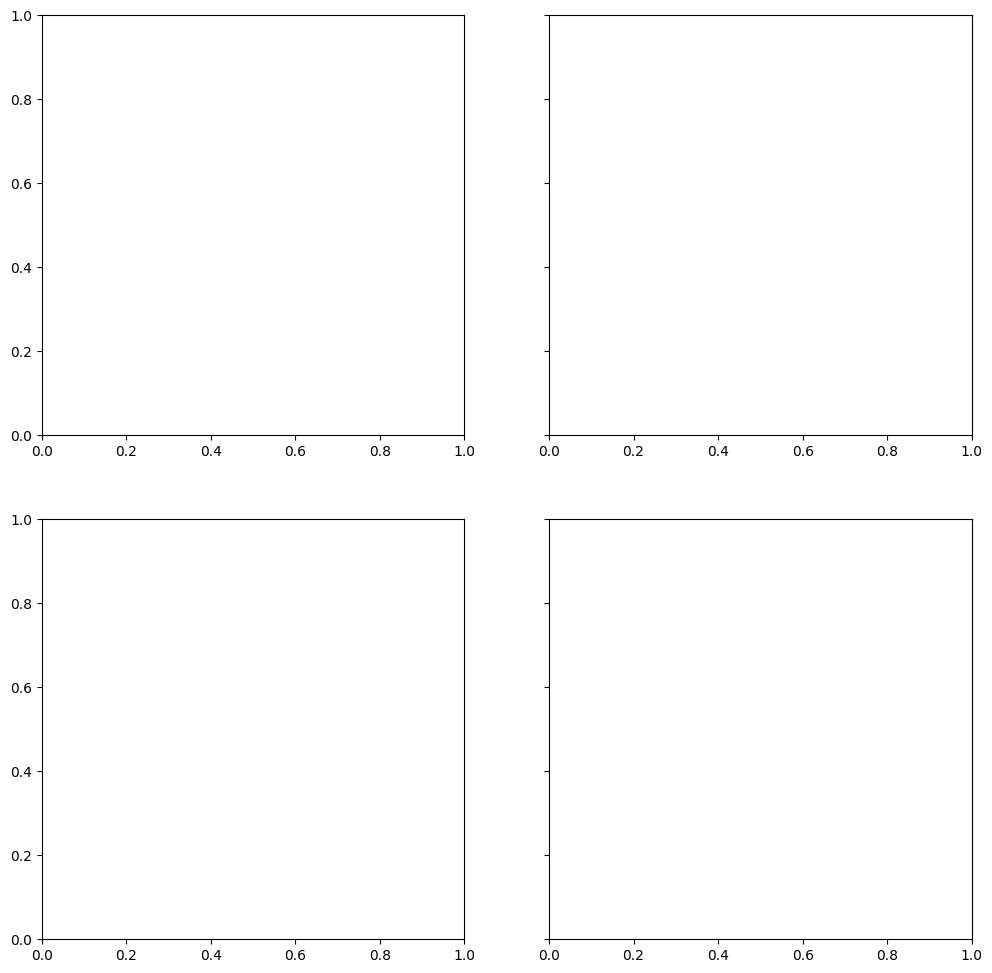

# 5. Mismatch without diode activation (you can skip session 3 and 4 if you already ran them before)

## 5.1. Generate the results

In [35]:
zone_file = os.path.join(ResultsFolder, 'new_and_old_with_climate_zone.xlsx')
if not os.path.exists(zone_file):
    raise FileNotFoundError(f"Cannot find climate zone file: {zone_file}")
print(f"Reading climate zone file: {zone_file}")
zone_df = pd.read_excel(zone_file, sheet_name=0)

# add extra columns into the zone_df: autumn mismatch loss, spring mismatch loss, summer mismatch loss, winter mismatch loss, 
# mean mismatch loss without diode activation
# zone_df['autumn Mismatch no diode (%)'] = np.nan
# zone_df['spring Mismatch no diode (%)'] = np.nan
# zone_df['summer Mismatch no diode (%)'] = np.nan
# zone_df['winter Mismatch no diode (%)'] = np.nan
# zone_df['mean Mismatch no diode (%)']   = np.nan

for season in seasons:
    # add the season column into the zone_df if not exists
    if f'{season} Mismatch no diode (%)' not in zone_df.columns:
        zone_df[f'{season} Mismatch no diode (%)'] = np.nan



# iterate through the site_ids and seasons
for site_id in site_ids:
    for season in seasons:
        # find the matching sub‐directory (skip any files)
        target_folder = None
        for name in os.listdir(ResultsFolder):
            path = os.path.join(ResultsFolder, name)
            if os.path.isdir(path) and site_id in name and season.lower() in name.lower():
                target_folder = path
                print(f"Found target folder: {target_folder}")
                break
        if target_folder is None:
            print(f"No directory for site {site_id} / season {season}, skipping")
            continue

        # now list only inside that directory
        for fname in os.listdir(target_folder):
            if 'no_diode_activation' in fname and fname.endswith('.xlsx'):
                no_diode_activation_file = os.path.join(target_folder, fname)
                print(f"Found no diode activation file: {no_diode_activation_file}")
                no_diode_activation_df = pd.read_excel(no_diode_activation_file)
                # extract the file name without the text no_diode_activation
                file_name = fname.replace('_no_diode_activation.xlsx', '')
                # read the original file and read as with_diode_activation_df
                with_diode_activation_file = os.path.join(target_folder, file_name + '.xlsx')
                # print the file name for both no_diode_activation and with_diode_activation
                print(f"With diode activation file: {with_diode_activation_file}")
                print(f"Reading no_diode_activation_df from {no_diode_activation_file}")
                break
        else:
            print(f"No no_diode_activation.xlsx in {target_folder}, skipping")
            continue

        # print the dimension of hte no_diode_activation_df
        print(f"no_diode_activation_df shape: {no_diode_activation_df.shape}")
        # print the dimension of the with_diode_activation_df
        with_diode_activation_df = pd.read_excel(with_diode_activation_file)
        print(f"with_diode_activation_df shape: {with_diode_activation_df.shape}")

        # calculate the mismatch loss
        available_power = no_diode_activation_df['Sum of I*V (W)'].sum()
        series_power    = no_diode_activation_df['Pmppt (W)'].sum()
        mismatch_loss   = (available_power - series_power) / available_power * 100 
        print(f"Updating zone_df for site {site_id} in {season} with mismatch loss: {mismatch_loss}%")

        # find the original mismatch loss location, only add the results if it is not nan
        # Note: "before" columns use capitalized month names, "after" columns use lowercase
        # if not pd.isna(zone_df.loc[zone_df['Site ID'] == int(site_id), f'{season_capitalized} Mismatch Loss (%)'].values[0]):
        #     zone_df.loc[zone_df['Site ID'] == int(site_id), f'{season} Mismatch no diode (%)'] = mismatch_loss
        # else:
        #     print(f"Mismatch loss for site {site_id} in {season} was emtpy, not need to compare")
        zone_df.loc[zone_df['Site ID'] == int(site_id), f'{season} Mismatch no diode (%)'] = mismatch_loss
        
        # check the available columns in zone_df
        print(zone_df.columns)
        # read the original mismatch loss value from the zone_df
        # Note: "before" columns use capitalized month names, "after" columns use lowercase
        season_capitalized = season.capitalize()
        original_mismatch_loss = zone_df.loc[zone_df['Site ID'] == int(site_id), f'{season_capitalized} Mismatch Loss (%)'].values[0]
        # print it out
        print(f"Original mismatch loss for site {site_id} in {season}: {original_mismatch_loss}%")

        # validating using the with diode activation file
        available_power_with_diode = with_diode_activation_df['Sum of I*V (W)'].sum()
        series_power_with_diode    = with_diode_activation_df['Pmppt (W)'].sum()
        original_mismatch_loss = (available_power_with_diode - series_power_with_diode) / available_power_with_diode * 100
        print(f"Original mismatch loss for site {site_id} in {season} (with diode activation): {original_mismatch_loss}%")

        # replace the vluae back for original value
        # Note: "before" columns use capitalized month names
        zone_df.loc[zone_df['Site ID'] == int(site_id), f'{season_capitalized} Mismatch Loss (%)'] = original_mismatch_loss



# for values in column that contains the word "Mismatch Loss (%)", if the value is NaN
# replace the value in the corresponding column that contains the word "Mismatch no diode (%)" with nan
for col in zone_df.columns:
    if 'Mismatch Loss (%)' in col:
        # find the corresponding column that contains the word "Mismatch no diode (%)"
        no_diode_col = col.replace('Mismatch Loss (%)', 'Mismatch no diode (%)')
        # replace the value in the no_diode_col with NaN if the value in col is NaN
        zone_df.loc[pd.isna(zone_df[col]), no_diode_col] = np.nan

# replace any value in any columns above 60% with nan
num_cols = zone_df.select_dtypes(include='number').columns
# exclude the column named 'Site ID' from num_cols
num_cols = num_cols[num_cols != 'Site ID']
for col in num_cols:
    zone_df.loc[zone_df[col] > 60, col] = np.nan

# calculate the mean mismatch loss without diode activation
# zone_df['mean Mismatch no diode (%)'] = zone_df[['autumn Mismatch no diode (%)', 
#                                                     'spring Mismatch no diode (%)', 
#                                                     'summer Mismatch no diode (%)', 
#                                                     'winter Mismatch no diode (%)']].mean(axis=1)
# calculate the mean mismatch loss without diode activation
# zone_df['mean Mismatch no diode (%)'] = zone_df[[f'{season} Mismatch no diode (%)' for season in seasons]].mean(axis=1)
# take the average of all columns that contain the word "Mismatch no diode (%)"
zone_df['Mean Mismatch no diode (%)'] = zone_df.filter(like='Mismatch no diode (%)').mean(axis=1)

# update the orignal mean value
zone_df['Mean Mismatch Loss (%)'] = zone_df.filter(like='Mismatch Loss (%)').mean(axis=1)

# save the zone_df and export an excel file
output_zone_file = os.path.join(ResultsFolder, 'Mismatch loss without diode activation.xlsx')
zone_df.to_excel(output_zone_file, index=False)

print(zone_df)

# remove all columns whose value are all nan
zone_df = zone_df.dropna(axis=1, how='all')


Reading climate zone file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\new_and_old_with_climate_zone.xlsx
Found target folder: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111846_September_20250630_074216
Found no diode activation file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111846_September_20250630_074216\combined_data_autumn_4111846_no_diode_activation.xlsx
With diode activation file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111846_September_20250630_074216\combined_data_autumn_4111846.xlsx
Reading no_diode_activation_df from C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_06_24_Results\4111846_September_20250630_074216\combined_data_autumn_411184

## 5.2. Visualisation

### 5.2.1. Compare the overall distribution

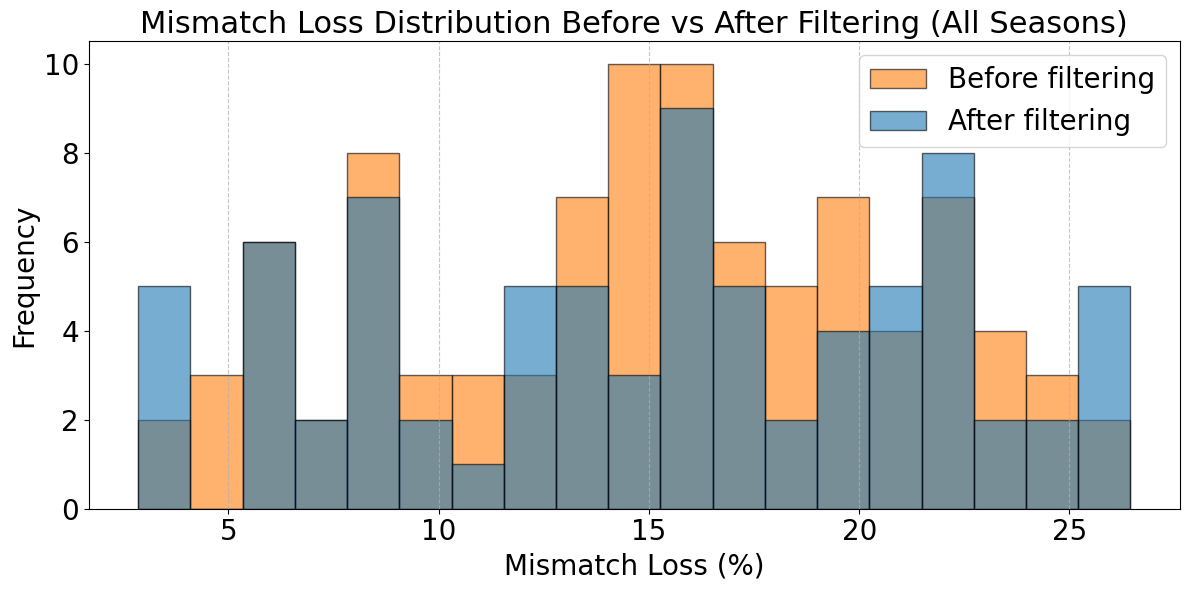

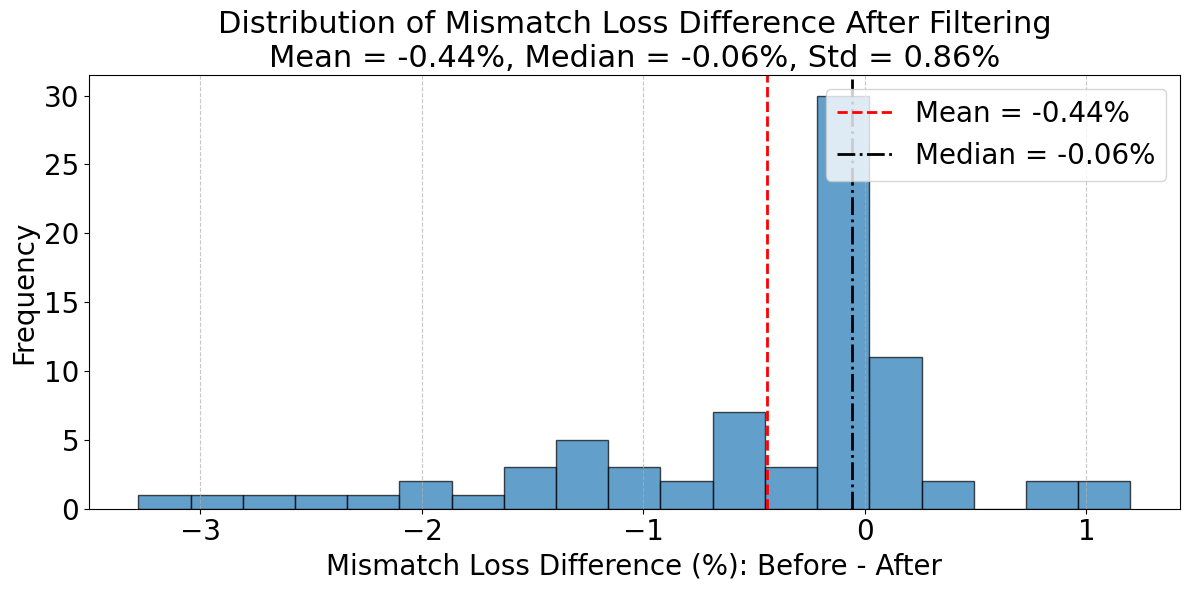

In [38]:
# 4.4. Results comparison: Visualize the effect of bypass diode activation filtering

# Ensure zone_df is loaded (should be loaded from section 5.1)
# If not loaded, uncomment the following:
# zone_file = os.path.join(ResultsFolder, 'new_and_old_with_climate_zone.xlsx')
# zone_df = pd.read_excel(zone_file, sheet_name=0)

# Plot 1: Histogram of Mismatch Loss (Before vs After) - All Seasons Combined
# Season mapping: December→Summer, June→Winter, March→Autumn, September→Spring
seasons_data = [
    ('December', 'december'),
    ('June', 'june'),
    ('March', 'march'),
    ('September', 'september')
]

# Collect all before and after data across all seasons
before_all = pd.Series(dtype=float)
after_all = pd.Series(dtype=float)

for month_cap, month_lower in seasons_data:
    # Extract before and after columns
    before_col = f'{month_cap} Mismatch Loss (%)'
    after_col = f'{month_lower} Mismatch no diode (%)'
    
    # Get data and drop NaN values, then concatenate
    before = zone_df[before_col].dropna()
    after = zone_df[after_col].dropna()
    
    before_all = pd.concat([before_all, before])
    after_all = pd.concat([after_all, after])

# Create single histogram figure
fig1, ax1 = plt.subplots(figsize=long_hoz_figsize)

# Use common bins for both histograms
bins = np.linspace(
    min(before_all.min(), after_all.min()),
    max(before_all.max(), after_all.max()),
    20
)

# Plot overlapping histograms
ax1.hist(before_all, bins=bins, alpha=0.6, label='Before filtering', color='C1', edgecolor='black')
ax1.hist(after_all, bins=bins, alpha=0.6, label='After filtering', color='C0', edgecolor='black')

# Formatting
ax1.set_xlabel('Mismatch Loss (%)', fontsize=axis_label_size)
ax1.set_ylabel('Frequency', fontsize=axis_label_size)
ax1.set_title('Mismatch Loss Distribution Before vs After Filtering (All Seasons)', fontsize=title_size)
ax1.tick_params(labelsize=axis_num_size)
ax1.legend(fontsize=axis_num_size)
ax1.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Plot 2: Histogram of Difference (Before - After)
# Calculate difference for each season and concatenate
diff_all = pd.Series(dtype=float)

for month_cap, month_lower in seasons_data:
    before_col = f'{month_cap} Mismatch Loss (%)'
    after_col = f'{month_lower} Mismatch no diode (%)'
    
    # Calculate difference where both values exist
    diff = zone_df[before_col] - zone_df[after_col]
    diff = diff.dropna()
    
    # Concatenate to overall difference series
    diff_all = pd.concat([diff_all, diff])

# Calculate statistics
mean_diff = diff_all.mean()
median_diff = diff_all.median()
std_diff = diff_all.std()

# Create histogram
fig2, ax2 = plt.subplots(figsize=long_hoz_figsize)
bins = np.linspace(diff_all.min(), diff_all.max(), 20)
ax2.hist(diff_all, bins=bins, edgecolor='black', alpha=0.7)

# Add mean and median lines
ax2.axvline(mean_diff, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_diff:.2f}%')
ax2.axvline(median_diff, color='black', linestyle='-.', linewidth=2, label=f'Median = {median_diff:.2f}%')

# Formatting
ax2.set_xlabel('Mismatch Loss Difference (%): Before - After', fontsize=axis_label_size)
ax2.set_ylabel('Frequency', fontsize=axis_label_size)
ax2.set_title(
    f'Distribution of Mismatch Loss Difference After Filtering\n'
    f'Mean = {mean_diff:.2f}%, Median = {median_diff:.2f}%, Std = {std_diff:.2f}%',
    fontsize=title_size
)
ax2.tick_params(labelsize=axis_num_size)
ax2.legend(fontsize=axis_num_size, loc='upper right')
ax2.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


    No  Site ID        Country       State     kWp  Number of modules  \
0    1  3455043      Australia         QLD   9.960               24.0   
1    2  4002138      Australia         VIC   6.660               18.0   
2    3  4034376      Australia          SA   6.650               14.0   
3    4  4140175      Australia         NSW   6.600               15.0   
4    5  4186157  North America       Texas  10.695               31.0   
5    6  4172746  North America     Arizona   7.290               18.0   
6    7  4111846  North America      Nevada   6.400               16.0   
7    8  4123602  North America  California   7.000               16.0   
8    9  4111492  North America        Iowa  13.800               30.0   
9   10  4184502  North America       Texas   5.200               14.0   
10  11  4093266  North America        Ohio   7.500               18.0   
11  12  4111800  North America  California   7.200               18.0   
12  13  4118327  North America       Texas  12.800 

C:\Users\z5183876\AppData\Local\Temp\ipykernel_253204\762850236.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(


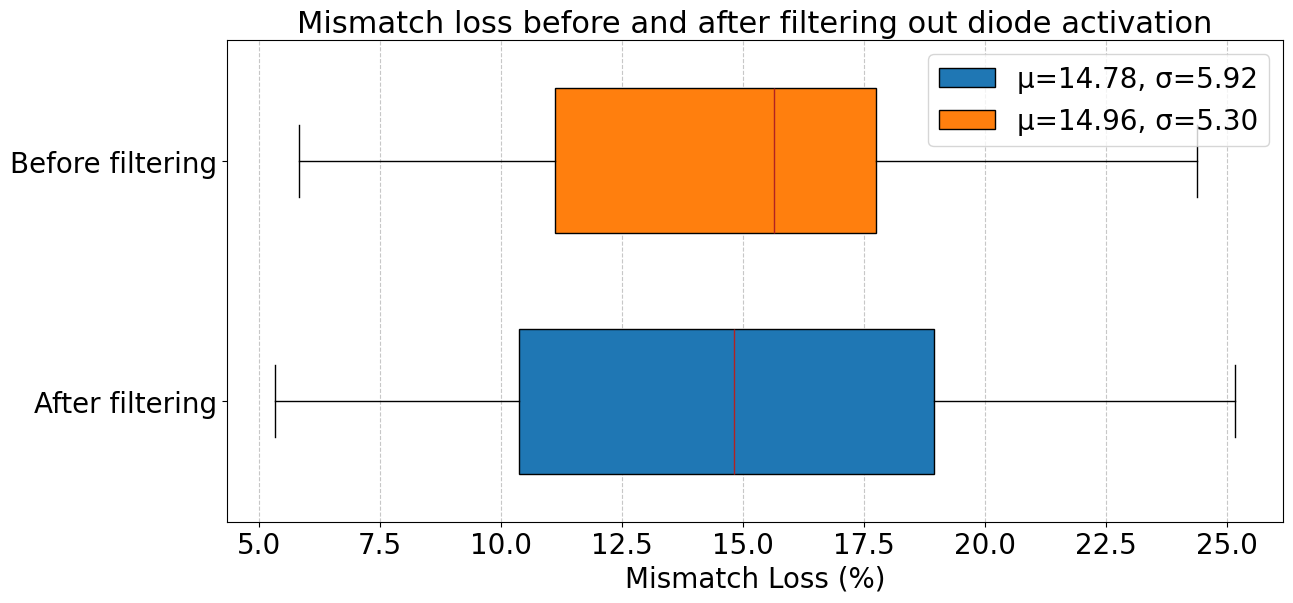

In [ ]:
# read the mismatch loss excel file
zone_df = pd.read_excel(output_zone_file)
print(zone_df)

# plot the boxplot
# column: mean Mismatch no diode (%)
# column: mean Mismatch Loss (%)
# ...existing code before the boxplot...
plt.figure(figsize=long_hoz_figsize)
data = [
    zone_df['Mean Mismatch no diode (%)'].dropna(),
    zone_df['Mean Mismatch Loss (%)'].dropna()
]
labels = ['After filtering', 'Before filtering']
bplot = plt.boxplot(
    data,
    vert=False,
    labels=labels,
    widths=0.6,
    patch_artist=True,
    boxprops=dict(edgecolor='k'),
    medianprops=dict(color='firebrick'),
    whis=1.5  # use default IQR factor for whiskers
)
# colour each box differently
colors = ['C0', 'C1']
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

# compute mean and std
m1, s1 = data[0].mean(), data[0].std()
m2, s2 = data[1].mean(), data[1].std()

handles = [
    mpatches.Patch(facecolor=colors[0], edgecolor='k',
                   label=f"μ={m1:.2f}, σ={s1:.2f}"),
    mpatches.Patch(facecolor=colors[1], edgecolor='k',
                   label=f"μ={m2:.2f}, σ={s2:.2f}")
]
plt.legend(handles=handles, fontsize=axis_num_size, loc='upper right')

plt.title('Mismatch loss before and after filtering out diode activation', fontsize=title_size)
plt.xlabel('Mismatch Loss (%)', fontsize=axis_label_size)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.xticks(fontsize=axis_num_size)
plt.tick_params(axis='both', labelsize=axis_num_size)
plt.show()
# ...existing code after the boxplot...

### 5.2.2. Distribution of the difference

#### 5.2.2.1. Divide by Season

Index(['No', 'Site ID', 'Country', 'State', 'kWp', 'Number of modules',
       'Module size', 'Opt', 'Module Make', 'Module', 'Address', 'Orientation',
       'Shade', 'PV Syst Module Data', 'Module Datasheet', 'Telemtry Data',
       'December Mismatch Loss (%)', 'June Mismatch Loss (%)',
       'March Mismatch Loss (%)', 'September Mismatch Loss (%)',
       'Mean Mismatch Loss (%)', 'Climate Zone',
       'December Mismatch no diode (%)', 'June Mismatch no diode (%)',
       'March Mismatch no diode (%)', 'September Mismatch no diode (%)',
       'Mean Mismatch no diode (%)'],
      dtype='object')


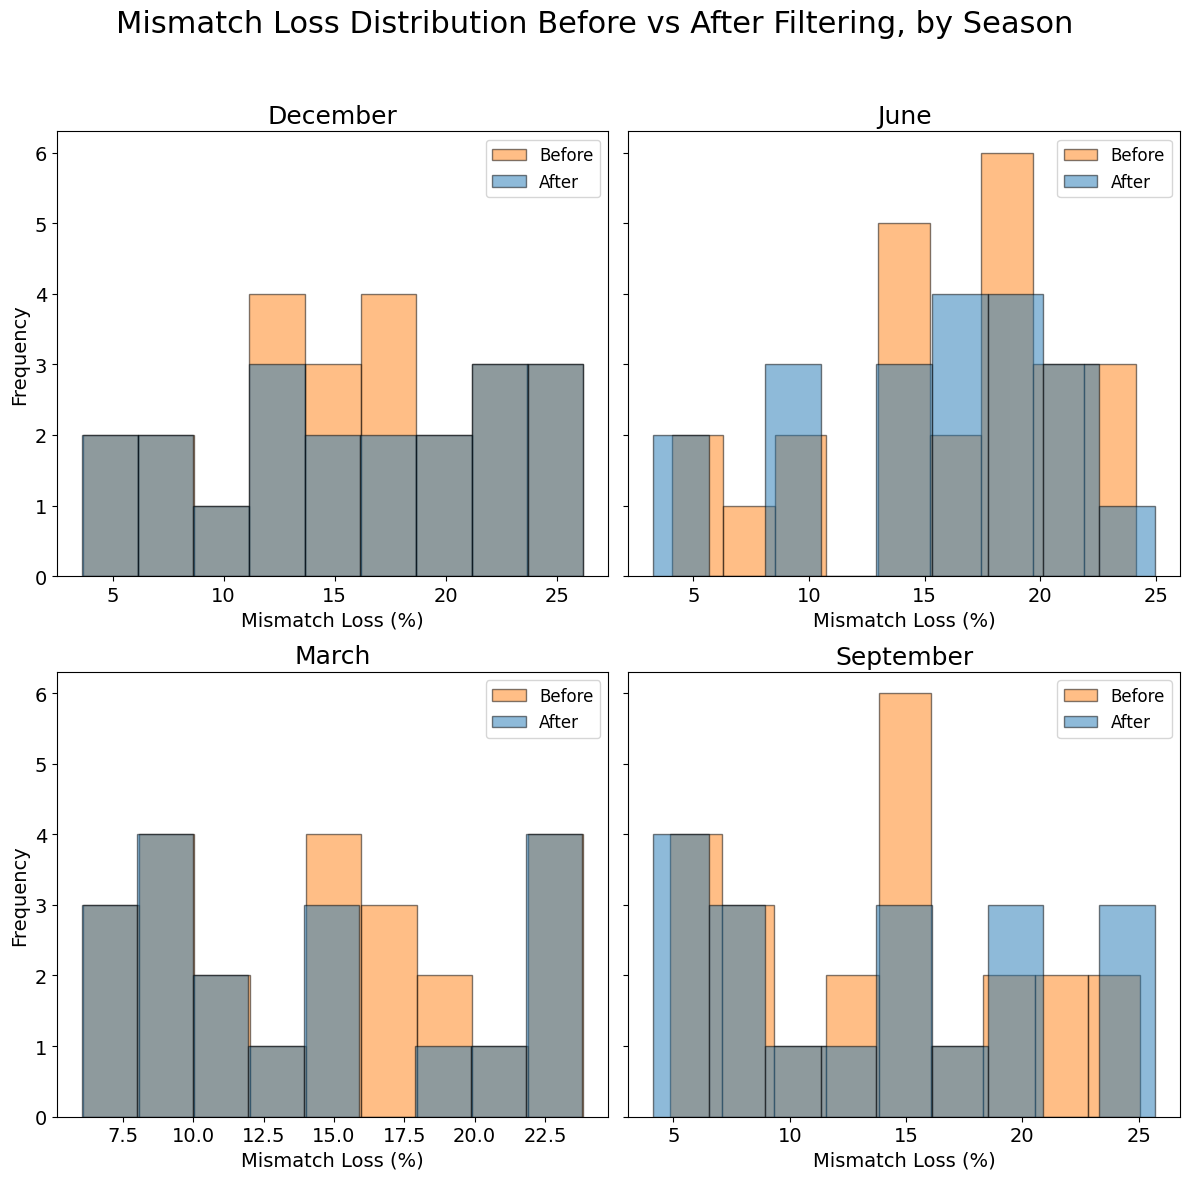

In [ ]:
# …existing code after cell “### 5.2.2. Distribution of the difference”…

# 5.2.2. Histogram of Mismatch Loss before vs after filtering, broken down by season
# seasons = ['summer','autumn','winter','spring']
fig, axes = plt.subplots(2, 2, figsize=two_by_two_figsize, sharey=True)
print(zone_df.columns)

for idx, season in enumerate(seasons):
    ax = axes.flatten()[idx]
    before = zone_df[f'{season} Mismatch Loss (%)'].dropna()
    after  = zone_df[f'{season} Mismatch no diode (%)'].dropna()
    ax.hist(before, bins=9, alpha=0.5, label='Before', color='C1', edgecolor='black')
    ax.hist(after,  bins=9, alpha=0.5, label='After',  color='C0', edgecolor='black')
    ax.set_title(season.capitalize(), fontsize=title_size-4)
    ax.set_xlabel('Mismatch Loss (%)', fontsize=axis_label_size-6)
    ax.tick_params(labelsize=axis_num_size-6)
    # only set y-label on first column
    if idx % 2 == 0:
        ax.set_ylabel('Frequency', fontsize=axis_label_size-6)
    ax.legend(fontsize=axis_num_size-8)

plt.suptitle('Mismatch Loss Distribution Before vs After Filtering, by Season', fontsize=title_size)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

#### 5.2.2.2. Together

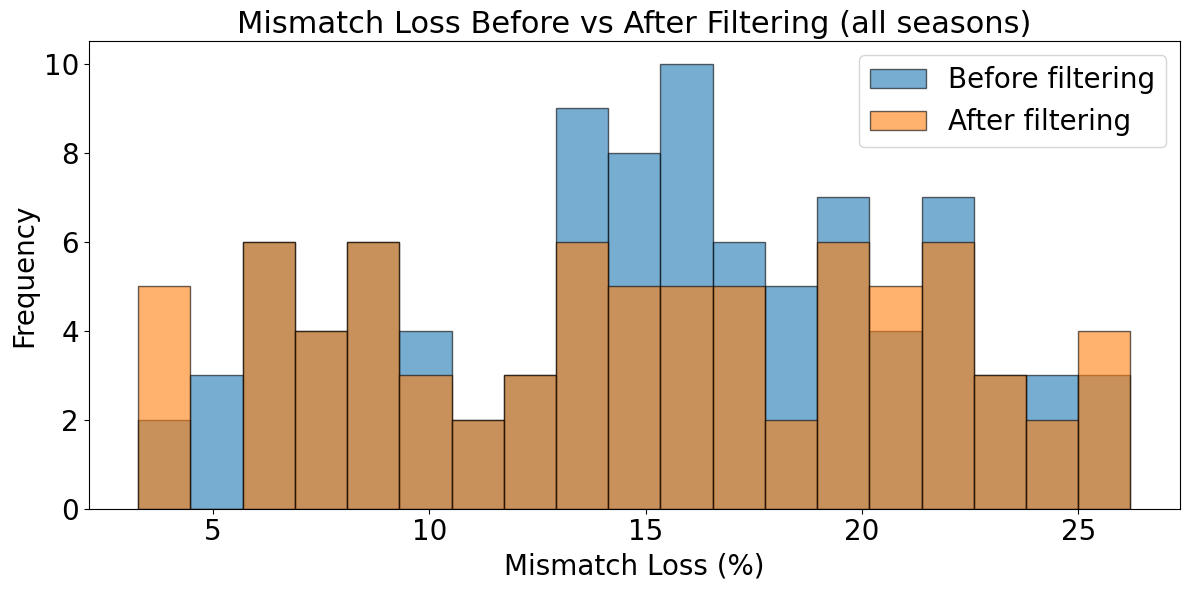

In [ ]:
# …existing code after cell “#### 5.2.2.2. Together”…

# 5.2.2. Histogram of Mismatch Loss before vs after filtering: all seasons merged
# seasons = ['summer', 'autumn', 'winter', 'spring']
# concatenate all seasons into two series
before_all = pd.concat([
    zone_df[f'{s} Mismatch Loss (%)'] for s in seasons
]).dropna()
after_all  = pd.concat([
    zone_df[f'{s} Mismatch no diode (%)'] for s in seasons
]).dropna()

fig, ax = plt.subplots(figsize=long_hoz_figsize)
# common bins
bins = np.linspace(
    min(before_all.min(), after_all.min()),
    max(before_all.max(), after_all.max()),
    20
)

ax.hist(before_all, bins=bins, alpha=0.6, label='Before filtering', edgecolor='black')
ax.hist(after_all,  bins=bins, alpha=0.6, label='After filtering',  edgecolor='black')

ax.set_xlabel('Mismatch Loss (%)', fontsize=axis_label_size)
ax.set_ylabel('Frequency', fontsize=axis_label_size)
ax.set_title('Mismatch Loss Before vs After Filtering (all seasons)', fontsize=title_size)
ax.tick_params(labelsize=axis_num_size)
ax.legend(fontsize=axis_num_size)
plt.tight_layout()
plt.show()

#### 5.2.2.3. Difference distribution seperating the season

This huge difference in different season comes from the wrong seasonal indexing

    No  Site ID        Country       State     kWp  Number of modules  \
0    1  3455043      Australia         QLD   9.960               24.0   
1    2  4002138      Australia         VIC   6.660               18.0   
2    3  4034376      Australia          SA   6.650               14.0   
3    4  4140175      Australia         NSW   6.600               15.0   
4    5  4186157  North America       Texas  10.695               31.0   
5    6  4172746  North America     Arizona   7.290               18.0   
6    7  4111846  North America      Nevada   6.400               16.0   
7    8  4123602  North America  California   7.000               16.0   
8    9  4111492  North America        Iowa  13.800               30.0   
9   10  4184502  North America       Texas   5.200               14.0   
10  11  4093266  North America        Ohio   7.500               18.0   
11  12  4111800  North America  California   7.200               18.0   
12  13  4118327  North America       Texas  12.800 

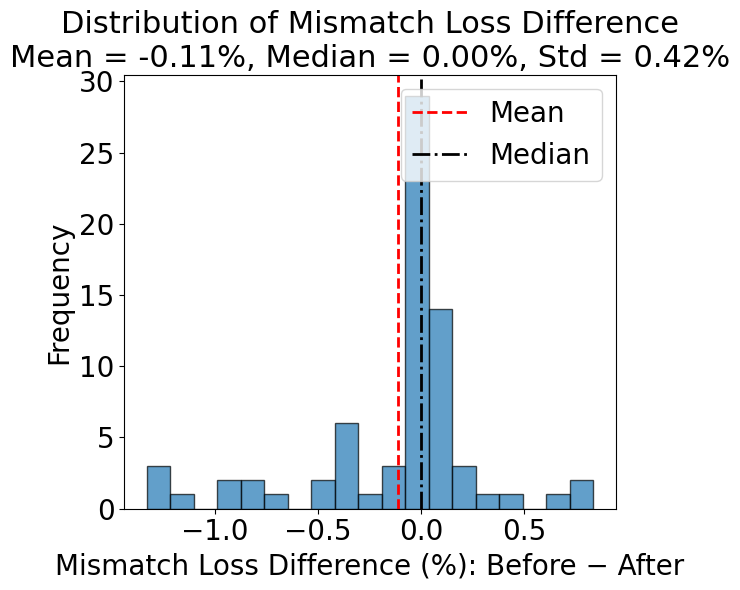

Sites with significant difference (more than 5%):
Site ID: 4034376, Mean Mismatch no diode: 7.48%, Mean Mismatch Loss: 7.43%
Site ID: 4140175, Mean Mismatch no diode: 25.17%, Mean Mismatch Loss: 24.37%
Site ID: 4186157, Mean Mismatch no diode: 10.77%, Mean Mismatch Loss: 10.53%
Site ID: 4123602, Mean Mismatch no diode: 16.33%, Mean Mismatch Loss: 15.93%
Site ID: 4111492, Mean Mismatch no diode: 21.97%, Mean Mismatch Loss: 21.68%
Site ID: 4184502, Mean Mismatch no diode: 14.94%, Mean Mismatch Loss: 14.08%
Site ID: 4093266, Mean Mismatch no diode: 14.61%, Mean Mismatch Loss: 14.16%
Site ID: 4162787, Mean Mismatch no diode: 14.68%, Mean Mismatch Loss: 14.60%


In [ ]:
# print the zone_df before filtering
# print("Zone DataFrame before filtering:")
# print(zone_df)
zone_df = pd.read_excel(output_zone_file)
print(zone_df)

# remove any unnamed columns from zone_df
zone_df = zone_df.loc[:, ~zone_df.columns.str.contains('^Unnamed')]
# remove any columns that are all nan
zone_df = zone_df.dropna(axis=1, how='all')
# remove any rows that contains any nan except the column 'State'
zone_df = zone_df.dropna(subset=zone_df.columns.difference(['State']), how='any')

# print hte zone_df after filtering
# print("Zone DataFrame after filtering:")
# print(zone_df)


# 5.2.2.3. Histogram of the difference (Before − After) across all seasons
# seasons   = ['summer', 'autumn', 'winter', 'spring']
# seasons = ['december', 'june', 'march', 'september']
# seasons = ['summer']
# seasons = ['autumn']
# seasons = ['winter']
# seasons = ['spring']
print(zone_df)
diff_all  = pd.concat([
    zone_df[f'{s} Mismatch Loss (%)'] - zone_df[f'{s} Mismatch no diode (%)']
    for s in seasons
]).dropna()
# diff_all = after_all - before_all

print(diff_all.to_list())

# compute statistics
mean_diff   = diff_all.mean()
median_diff = diff_all.median()
std_diff    = diff_all.std()

# ...existing code...
fig, ax = plt.subplots(figsize=figure_size)
bins = np.linspace(diff_all.min(), diff_all.max(), 20)
ax.hist(diff_all, bins=bins, edgecolor='black', alpha=0.7)

# annotate mean and median lines
ax.axvline(mean_diff,   color='red',   linestyle='--', linewidth=2)
ax.axvline(median_diff, color='black', linestyle='-.', linewidth=2)

# Remove mean/median from legend, just show line styles
ax.legend(
    [
        plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2),
        plt.Line2D([0], [0], color='black', linestyle='-.', linewidth=2)
    ],
    [
        "Mean", "Median"
    ],
    fontsize=axis_num_size, loc='upper right'
)

ax.set_xlabel('Mismatch Loss Difference (%): Before − After', fontsize=axis_label_size)
ax.set_ylabel('Frequency', fontsize=axis_label_size)
ax.tick_params(labelsize=axis_num_size)
ax.set_title(
    f'Distribution of Mismatch Loss Difference\n'
    f'Mean = {mean_diff:.2f}%, Median = {median_diff:.2f}%, Std = {std_diff:.2f}%',
    fontsize=title_size
)

plt.tight_layout()
plt.show()
# ...existing code...

# look up the print the site id whose difference is larger than 5%
high_diff_sites = zone_df[zone_df['Mean Mismatch no diode (%)'] - zone_df['Mean Mismatch Loss (%)'] > 5/100]
# print(zone_df)
if not high_diff_sites.empty:
    print("Sites with significant difference (more than 5%):")
    for idx, row in high_diff_sites.iterrows():
        print(f"Site ID: {row['Site ID']}, "
            #   f"Season: {row['season']}, "
              f"Mean Mismatch no diode: {row['Mean Mismatch no diode (%)']:.2f}%, "
              f"Mean Mismatch Loss: {row['Mean Mismatch Loss (%)']:.2f}%")

#### 5.2.2.4. Difference with merged season

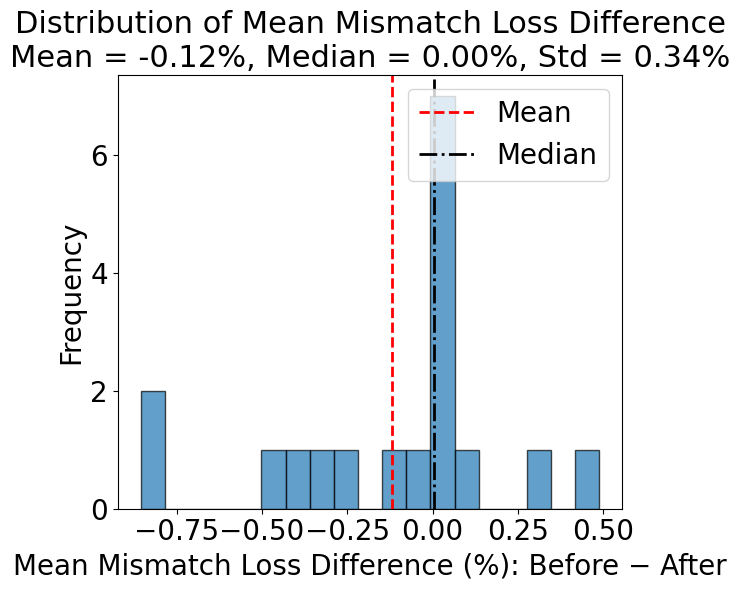

In [ ]:
# ...existing code...

# Calculate the difference between mean mismatch loss before and after filtering
diff_mean = zone_df['Mean Mismatch Loss (%)'] - zone_df['Mean Mismatch no diode (%)']
diff_mean = diff_mean.dropna()

# Compute statistics
mean_diff   = diff_mean.mean()
median_diff = diff_mean.median()
std_diff    = diff_mean.std()

fig, ax = plt.subplots(figsize=figure_size)
bins = np.linspace(diff_mean.min(), diff_mean.max(), 20)
ax.hist(diff_mean, bins=bins, edgecolor='black', alpha=0.7)

# Annotate mean and median lines
ax.axvline(mean_diff,   color='red',   linestyle='--', linewidth=2)
ax.axvline(median_diff, color='black', linestyle='-.', linewidth=2)

# Only show line styles in legend
ax.legend(
    [
        plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2),
        plt.Line2D([0], [0], color='black', linestyle='-.', linewidth=2)
    ],
    [
        "Mean", "Median"
    ],
    fontsize=axis_num_size, loc='upper right'
)

ax.set_xlabel('Mean Mismatch Loss Difference (%): Before − After', fontsize=axis_label_size)
ax.set_ylabel('Frequency', fontsize=axis_label_size)
ax.tick_params(labelsize=axis_num_size)
ax.set_title(
    f'Distribution of Mean Mismatch Loss Difference\n'
    f'Mean = {mean_diff:.2f}%, Median = {median_diff:.2f}%, Std = {std_diff:.2f}%',
    fontsize=title_size
)

plt.tight_layout()
plt.show()

## 5.3. Visualisation of data without diode activation

### 5.2.1. Group by season

#### 5.2.1.1. Create season column

In [ ]:
# create a map to map from month to season
northern_hemisphere_season_map = {
    'january':   'winter',
    'february':  'winter',
    'march':     'spring',
    'april':     'spring',
    'may':       'spring',
    'june':      'summer',
    'july':      'summer',
    'august':    'summer',
    'september': 'autumn',
    'october':   'autumn',
    'november':  'autumn',
    'december':  'winter'
}
southern_hemisphere_season_map = {
    'january':   'summer',
    'february':  'summer',
    'march':     'autumn',
    'april':     'autumn',
    'may':       'autumn',
    'june':      'winter',
    'july':      'winter',
    'august':    'winter',
    'september': 'spring',
    'october':   'spring',
    'november':  'spring',
    'december':  'summer'
}

# add four extra columns into the zone_df:
# 'Autumn', 'Spring', 'Summer', 'Winter'
for season in ['autumn', 'spring', 'summer', 'winter']:
    if season not in zone_df.columns:
        zone_df[season] = np.nan

# loop through each row in zone_df
for idx, row in zone_df.iterrows():
    # read the country of that row
    country = row['Country'].lower()
    # identify if it is northern or southern hemisphere
    if country in ['australia', 'new zealand', 'south africa']:
        # southern hemisphere
        season_map = southern_hemisphere_season_map
    else:
        # northern hemisphere
        season_map = northern_hemisphere_season_map
    # if it is northern hemisphere, fill the summer column with the value in December Mismatch no diode (%)
    # fill the autumn column with the value in September Mismatch no diode (%)
    # fill the spring column with the value in March Mismatch no diode (%)
    # fill the winter column with the value in June Mismatch no diode (%)
    for month, season in season_map.items():
        # find the column that matches the month
        month_col = f'{month.capitalize()} Mismatch no diode (%)'
        if month_col in zone_df.columns:
            # fill the corresponding season column with the value in month_col
            zone_df.at[idx, season] = row[month_col]
        else:
            print(f"Column {month_col} not found in zone_df, skipping")

# export this updated zone_df to an excel file
output_seasoned_zone_file = os.path.join(ResultsFolder, 'Mismatch loss with seasons.xlsx')
zone_df.to_excel(output_seasoned_zone_file, index=False)



Column January Mismatch no diode (%) not found in zone_df, skipping
Column February Mismatch no diode (%) not found in zone_df, skipping
Column April Mismatch no diode (%) not found in zone_df, skipping
Column May Mismatch no diode (%) not found in zone_df, skipping
Column July Mismatch no diode (%) not found in zone_df, skipping
Column August Mismatch no diode (%) not found in zone_df, skipping
Column October Mismatch no diode (%) not found in zone_df, skipping
Column November Mismatch no diode (%) not found in zone_df, skipping
Column January Mismatch no diode (%) not found in zone_df, skipping
Column February Mismatch no diode (%) not found in zone_df, skipping
Column April Mismatch no diode (%) not found in zone_df, skipping
Column May Mismatch no diode (%) not found in zone_df, skipping
Column July Mismatch no diode (%) not found in zone_df, skipping
Column August Mismatch no diode (%) not found in zone_df, skipping
Column October Mismatch no diode (%) not found in zone_df, skippi

#### 5.2.1.2. Plotting

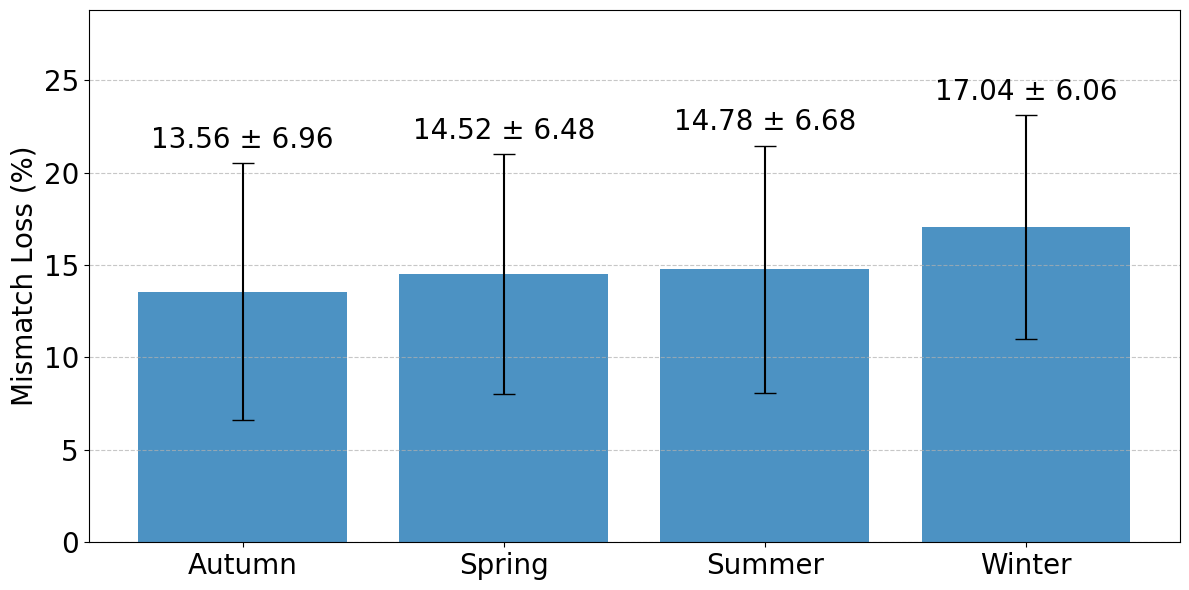

In [ ]:
# Calculate mean and std for each season
seasons = ['autumn', 'spring', 'summer', 'winter']
means = [zone_df[season].mean() for season in seasons]
stds  = [zone_df[season].std() for season in seasons]

plt.figure(figsize=long_hoz_figsize)
bars = plt.bar(
    [s.capitalize() for s in seasons],
    means,
    yerr=stds,
    color='C0',
    alpha=0.8,
    capsize=8
)

# Add value and std on top of each bar
for bar, mean, std in zip(bars, means, stds):
    # Check for NaN values before annotating
    if pd.notna(mean) and pd.notna(std):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            mean + std + 0.5,  # Position text above the error bar
            f"{mean:.2f} ± {std:.2f}",
            ha='center',
            va='bottom',
            fontsize=text_size
        )

# plt.title('Mismatch Loss Distribution by Season', fontsize=title_size)
plt.ylabel('Mismatch Loss (%)', fontsize=axis_label_size)
# plt.xlabel('Season', fontsize=axis_label_size)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Adjust ylim to make space for annotations
plt.ylim(0, (max(means) + max(stds)) * 1.2)
plt.tight_layout()
plt.show()

          Country spring (%) summer (%) autumn (%) winter (%)
0       Australia      14.07      11.26      17.95      22.91
1       Australia       25.7      26.21       23.8      24.97
2       Australia       6.31       3.62       6.04      13.96
3       Australia      16.05      14.44      16.01      14.86
4          France       6.49       8.31       6.01      12.17
5         Germany      15.88      17.92      14.49      21.98
6     Netherlands      11.79       17.7      16.02      13.22
7     Netherlands      23.75      20.33      20.76      25.36
8     Netherlands      22.41      22.33      19.76      21.34
9     Netherlands      12.31       9.58       7.39      15.96
10  North America       8.56       4.41       4.14       7.55
11  North America      14.66      19.49      14.58      16.57
12  North America        8.1       3.27       4.18       5.76
13  North America      15.05      16.06      13.26      14.07
14  North America       8.46      16.75       8.03       9.85
15      

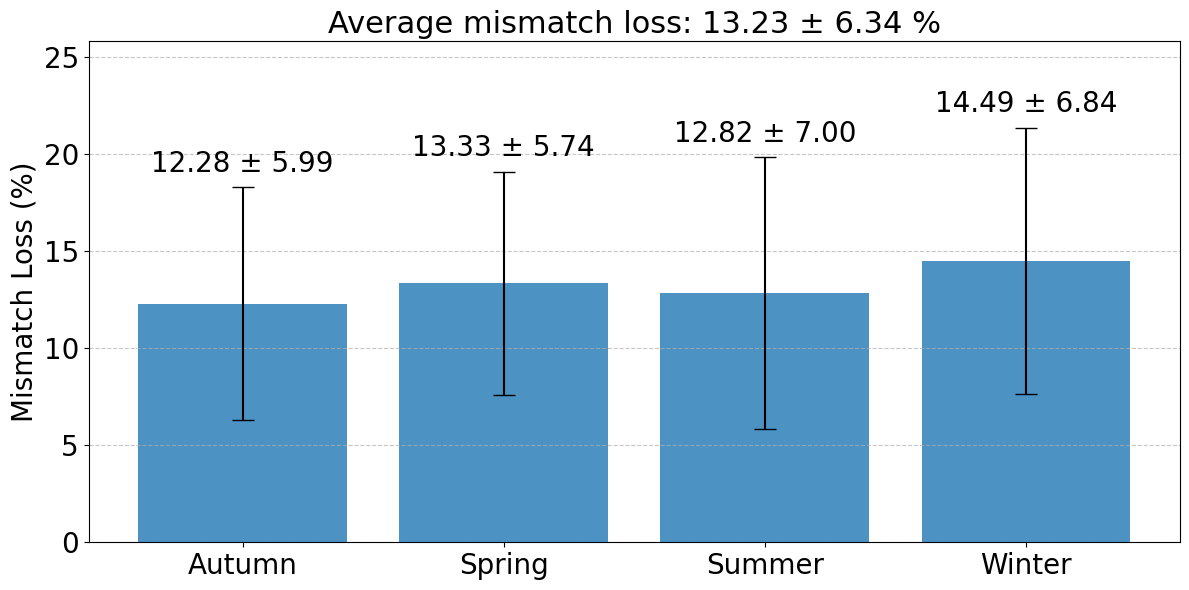

In [ ]:
# define the file directory for the updated plot
data_directory = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\v_from_i_combined\25_09_15_journal_article.xlsx"

# read the excel file
data_df = pd.read_excel(data_directory, sheet_name="All")

# 1. Read the dataframe
# Assuming your dataframe is already loaded as 'data_df'
# If not, uncomment the line below:
# data_df = pd.read_excel(data_directory, sheet_name="All")

# 2. Define hemisphere based on Country
def is_southern_hemisphere(country):
    """Return True if country is in southern hemisphere, False otherwise"""
    southern_countries = ['australia', 'new zealand', 'south africa', 'argentina',
                          'brazil', 'chile', 'uruguay', 'paraguay']
    return country.lower() in southern_countries

# 3. Define month-to-season mappings for both hemispheres
northern_hemisphere_mapping = {
    'March': 'spring',
    'April': 'spring',
    'May': 'spring',
    'June': 'summer',
    'July': 'summer',
    'August': 'summer',
    'September': 'autumn',
    'October': 'autumn',
    'November': 'autumn',
    'December': 'winter',
    'January': 'winter',
    'February': 'winter'
}

southern_hemisphere_mapping = {
    'September': 'spring',
    'October': 'spring',
    'November': 'spring',
    'December': 'summer',
    'January': 'summer',
    'February': 'summer',
    'March': 'autumn',
    'April': 'autumn',
    'May': 'autumn',
    'June': 'winter',
    'July': 'winter',
    'August': 'winter'
}

# 4. Add the seasonal columns to the dataframe
data_df['spring (%)'] = None
data_df['summer (%)'] = None
data_df['autumn (%)'] = None
data_df['winter (%)'] = None

# 5. Assign monthly values to seasonal columns
for index, row in data_df.iterrows():
    country = row['Country']

    # skip this row if country is NaN
    if pd.isna(country):
        continue

    # Determine hemisphere
    is_southern = is_southern_hemisphere(country)
    season_mapping = southern_hemisphere_mapping if is_southern else northern_hemisphere_mapping

    # For each month, assign its value to the appropriate season
    for month, season in season_mapping.items():
        month_column = f'{month} (%)'

        # Skip if the month column doesn't exist
        if month_column not in data_df.columns:
            continue

        # If the monthly value exists, assign it to the seasonal column
        if pd.notna(row[month_column]):
            data_df.at[index, f'{season} (%)'] = row[month_column]

# remove the nan rows
data_df = data_df.dropna(subset=['spring (%)', 'summer (%)', 'autumn (%)', 'winter (%)'], how='all')

# Display the updated dataframe
print(data_df[['Country', 'spring (%)', 'summer (%)', 'autumn (%)', 'winter (%)']])

season_columns = [f'{season} (%)' for season in seasons]

# Calculate statistics for the plot
means = [data_df[col].mean() for col in season_columns]
stds = [data_df[col].std() for col in season_columns]

# Calculate overall average and std across all seasons/sites
all_season_values = data_df[season_columns].stack()
overall_mean = all_season_values.mean()
overall_std = all_season_values.std()

# Create the plot
plt.figure(figsize=long_hoz_figsize)
bars = plt.bar(
    [s.capitalize() for s in seasons],
    means,
    yerr=stds,
    color='C0',
    alpha=0.8,
    capsize=8
)

# Add value and std on top of each bar
for bar, mean, std in zip(bars, means, stds):
    # Check for NaN values before annotating
    if pd.notna(mean) and pd.notna(std):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            mean + std + 0.5,  # Position text above the error bar
            f"{mean:.2f} ± {std:.2f}",
            ha='center',
            va='bottom',
            fontsize=text_size
        )

plt.ylabel('Mismatch Loss (%)', fontsize=axis_label_size)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, (max(means) + max(stds)) * 1.2)
plt.title(f"Average mismatch loss: {overall_mean:.2f} ± {overall_std:.2f} %", fontsize=title_size)
plt.tight_layout()

plt.show()


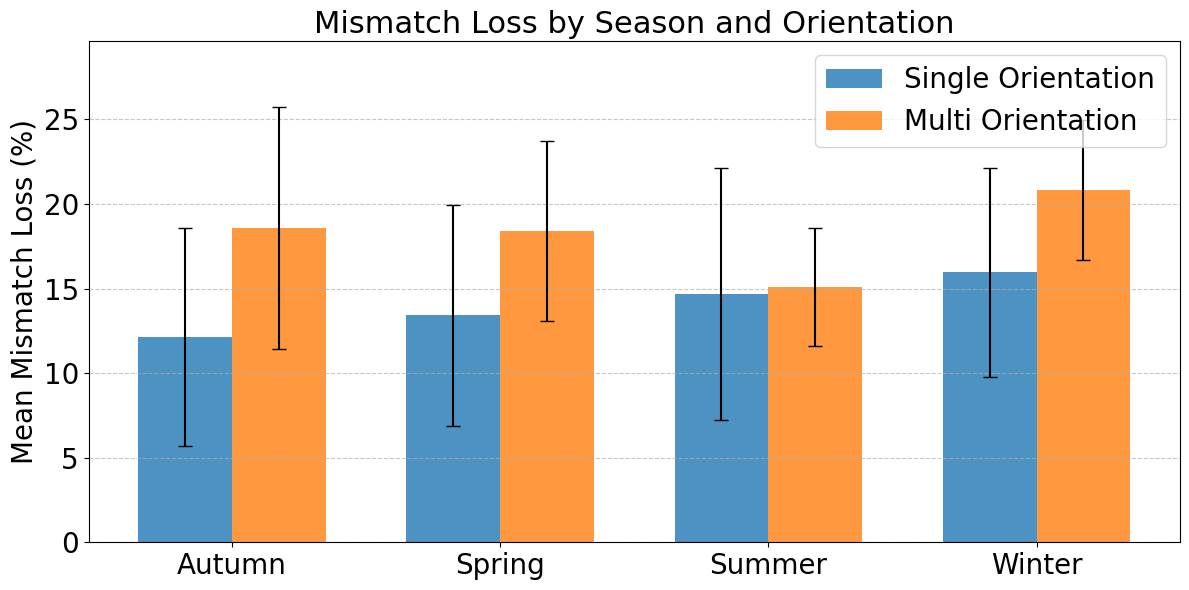

In [ ]:
# ...existing code...
# Filter for single and multi-orientation sites
single_df = zone_df[zone_df['Orientation'].str.lower() == 'single']
multi_df = zone_df[zone_df['Orientation'].str.lower() == 'multi']

# Define seasons and calculate stats for each orientation
seasons = ['autumn', 'spring', 'summer', 'winter']
single_means = [single_df[s].mean() for s in seasons]
single_stds = [single_df[s].std() for s in seasons]
multi_means = [multi_df[s].mean() for s in seasons]
multi_stds = [multi_df[s].std() for s in seasons]

# Plotting setup
x = np.arange(len(seasons))  # the label locations
bar_width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=long_hoz_figsize)

# Plot bars for single orientation
ax.bar(x - bar_width/2, single_means, bar_width, yerr=single_stds,
       label='Single Orientation', capsize=5, alpha=0.8)

# Plot bars for multi orientation
ax.bar(x + bar_width/2, multi_means, bar_width, yerr=multi_stds,
       label='Multi Orientation', capsize=5, alpha=0.8)

# Add some text for labels, title and axes ticks
ax.set_ylabel('Mean Mismatch Loss (%)', fontsize=axis_label_size)
ax.set_title('Mismatch Loss by Season and Orientation', fontsize=title_size)
ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in seasons], fontsize=axis_num_size)
ax.tick_params(axis='y', labelsize=axis_num_size)
ax.legend(fontsize=axis_num_size)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust ylim to make space for error bars
y_max = max(
    (np.array(single_means) + np.array(single_stds)).max(),
    (np.array(multi_means) + np.array(multi_stds)).max()
)
ax.set_ylim(0, y_max * 1.15)

fig.tight_layout()
plt.show()

### 5.2.2. Group by latitude

#### 5.2.2.1. Create the latitude column

In [ ]:
# read the zone_df from the excel file
zone_df = pd.read_excel(output_seasoned_zone_file)

# for each row, fron the address column, look up the corresponding latitude and longitude
# and add them into the zone_df as 'Latitude' and 'Longitude' columns
# use the geopy library to get the latitude and longitude from the address
geolocator = Nominatim(user_agent="MismatchLossAnalysis")
def get_lat_long(address):
    """Get latitude and longitude from address using geopy."""
    try:
        location = geolocator.geocode(address, timeout=10)
        if location:
            return location.latitude, location.longitude
        else:
            return None, None
    except Exception as e:
        print(f"Error getting location for {address}: {e}")
        return None, None

# Add Latitude and Longitude columns to zone_df
zone_df['Latitude']  = np.nan
zone_df['Longitude'] = np.nan
for idx, row in zone_df.iterrows():
    address = row['Address']
    if pd.notna(address):
        lat, long = get_lat_long(address)
        zone_df.at[idx, 'Latitude']  = lat
        zone_df.at[idx, 'Longitude'] = long
    else:
        print(f"Address is NaN for row {idx}, skipping")

# export the updated zone_df with Latitude and Longitude to an excel file
output_lat_long_zone_file = os.path.join(ResultsFolder, 'Mismatch loss with seasons and lat-long.xlsx')
zone_df.to_excel(output_lat_long_zone_file, index=False)

#### 5.2.2.2. Plotting

##### 5.2.2.2.1. All data

Slope of trend line: -0.0073


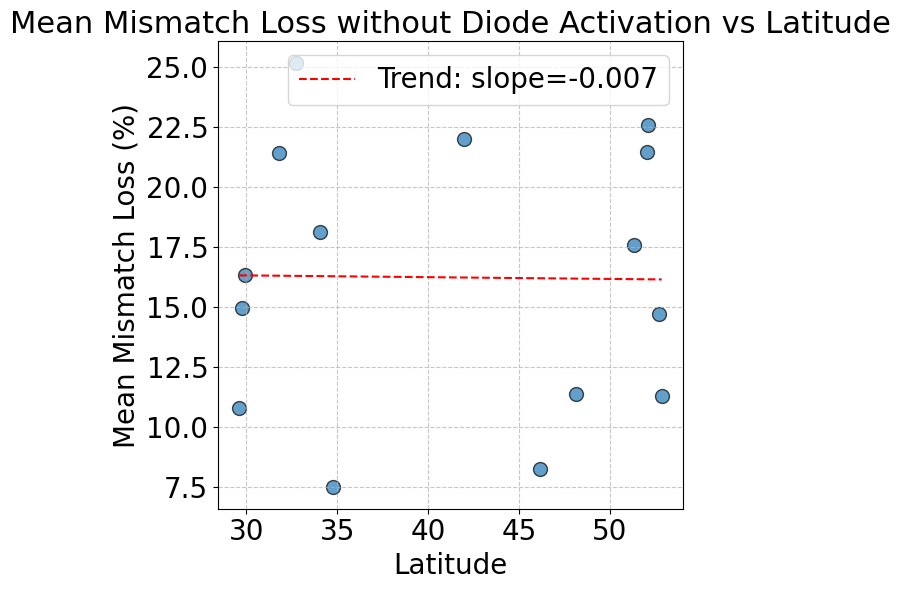

In [ ]:
# ...existing code before...

# plot the Mean mismatch loss without diode activation against latitude, with trend line and slope
plt.figure(figsize=figure_size)
x = zone_df['Latitude'].abs()
y = zone_df['Mean Mismatch no diode (%)']
plt.scatter(
    x,
    y,
    alpha=0.7,
    edgecolor='black',
    s=100
)
# Fit and plot trend line (ignore NaNs)
mask = (~pd.isna(x)) & (~pd.isna(y))
if mask.sum() > 1:
    coeffs = np.polyfit(x[mask], y[mask], 1)
    slope = coeffs[0]
    intercept = coeffs[1]
    xfit = np.linspace(x[mask].min(), x[mask].max(), 100)
    yfit = np.polyval(coeffs, xfit)
    plt.plot(xfit, yfit, 'r--', label=f'Trend: slope={slope:.3f}')
    print(f"Slope of trend line: {slope:.4f}")
else:
    print("Not enough data for trend line.")

plt.title('Mean Mismatch Loss without Diode Activation vs Latitude', fontsize=title_size)
plt.xlabel('Latitude', fontsize=axis_label_size)
plt.ylabel('Mean Mismatch Loss (%)', fontsize=axis_label_size)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.tight_layout()
plt.legend(fontsize=axis_num_size)
output_lat_long_plot = os.path.join(ResultsFolder, 'Mean_Mismatch_Loss_vs_Latitude.png')
plt.savefig(output_lat_long_plot, bbox_inches='tight', dpi=300)
plt.show()
#

##### 5.2.2.2.2. Shaded only

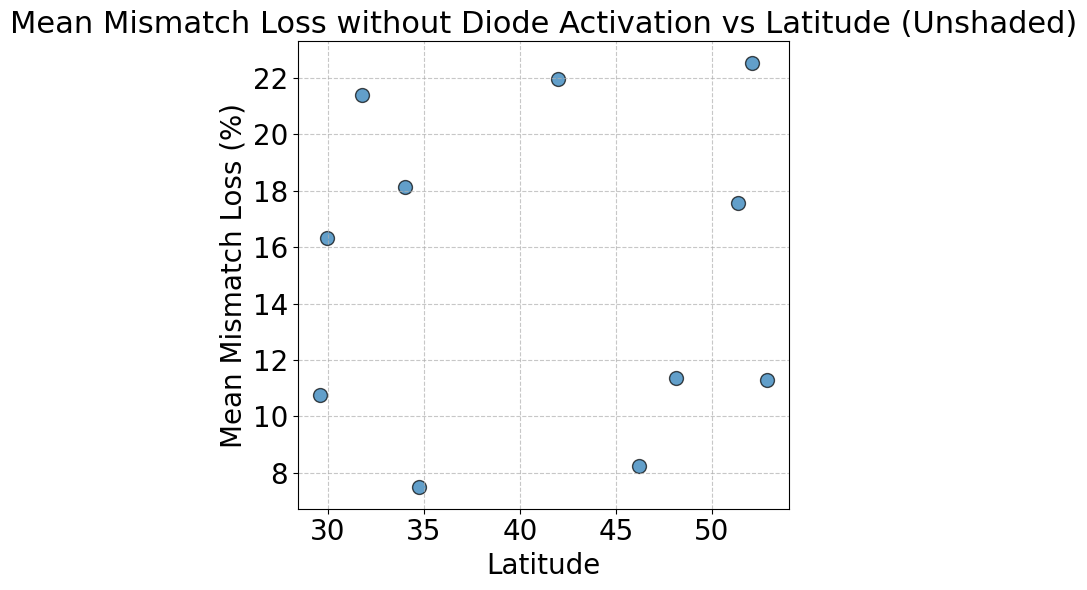

In [ ]:
# ...existing code before...

# Plot only if Shading is 'No'
unshaded = zone_df[zone_df['Shade'].str.lower() == 'no']

plt.figure(figsize=figure_size)
plt.scatter(
    unshaded['Latitude'].abs(),
    unshaded['Mean Mismatch no diode (%)'],
    alpha=0.7,
    edgecolor='black',
    s=100
)
plt.title('Mean Mismatch Loss without Diode Activation vs Latitude (Unshaded)', fontsize=title_size)
plt.xlabel('Latitude', fontsize=axis_label_size)
plt.ylabel('Mean Mismatch Loss (%)', fontsize=axis_label_size)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.tight_layout()
output_lat_long_plot = os.path.join(ResultsFolder, 'Mean_Mismatch_Loss_vs_Latitude_unshaded.png')
plt.savefig(output_lat_long_plot, bbox_inches='tight', dpi=300)
plt.show()
#

##### 5.2.2.2.3. Multi orientatiin

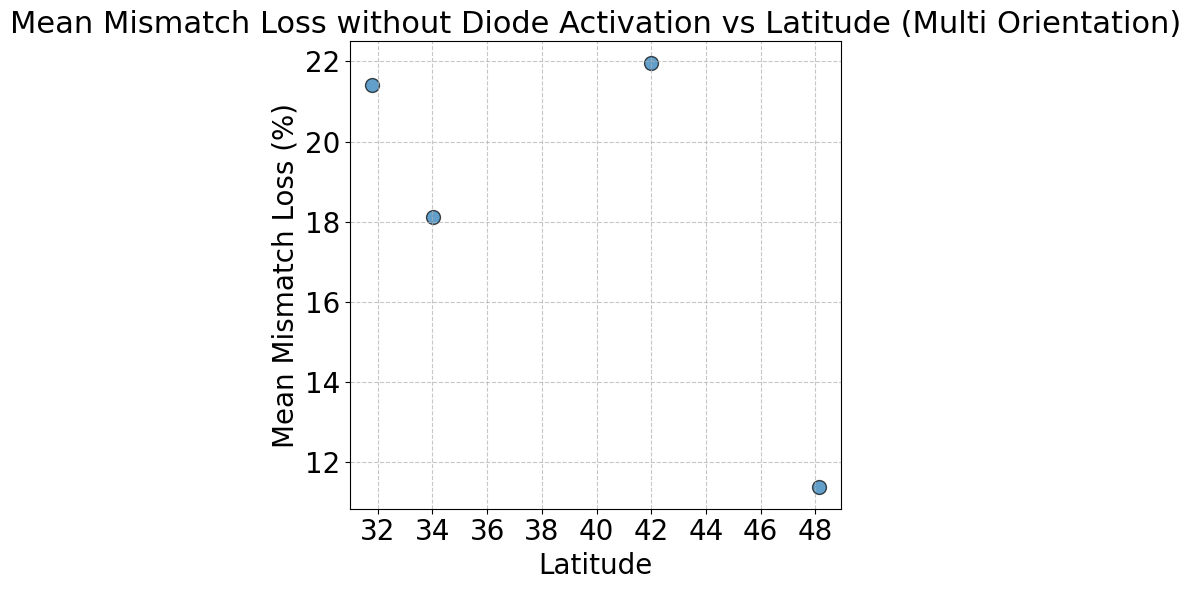

In [ ]:
# ...existing code before...

# Plot only if Orientation is 'Multi'
multi_orient = zone_df[zone_df['Orientation'].str.lower() == 'multi']

plt.figure(figsize=figure_size)
plt.scatter(
    multi_orient['Latitude'].abs(),
    multi_orient['Mean Mismatch no diode (%)'],
    alpha=0.7,
    edgecolor='black',
    s=100
)
plt.title('Mean Mismatch Loss without Diode Activation vs Latitude (Multi Orientation)', fontsize=title_size)
plt.xlabel('Latitude', fontsize=axis_label_size)
plt.ylabel('Mean Mismatch Loss (%)', fontsize=axis_label_size)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.tight_layout()
output_lat_long_plot = os.path.join(ResultsFolder, 'Mean_Mismatch_Loss_vs_Latitude_multi_orientation.png')
plt.savefig(output_lat_long_plot, bbox_inches='tight', dpi=300)
plt.show()
# ...existing code after...

##### 5.2.2.2.4. Single orientation

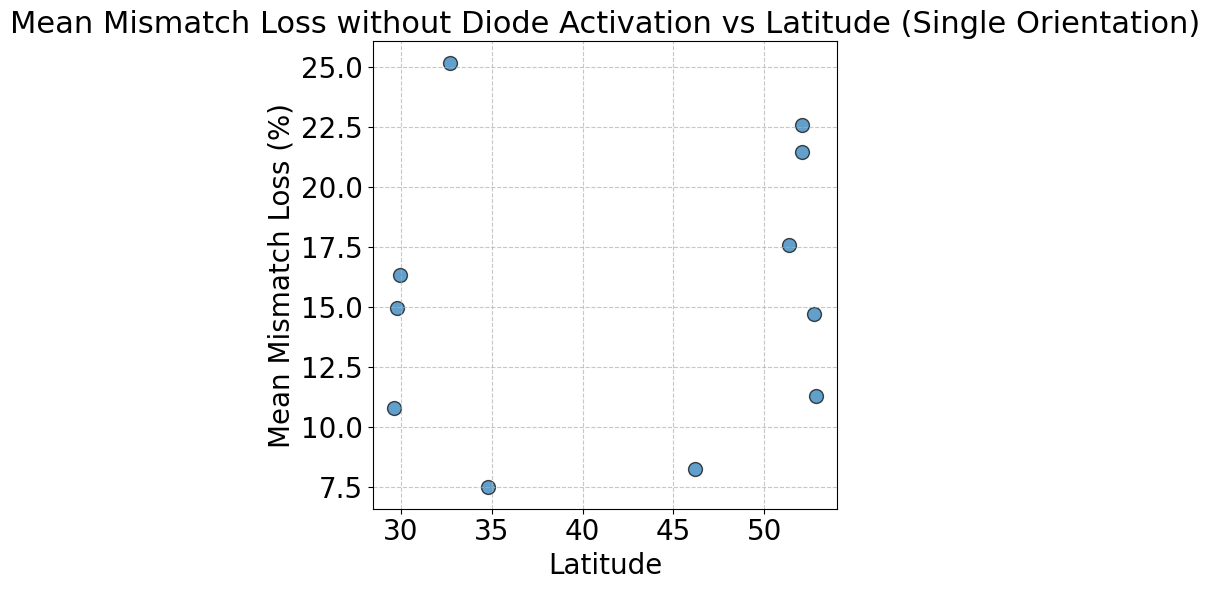

In [ ]:
# ...existing code before...

# Plot only if Orientation is 'Multi'
multi_orient = zone_df[zone_df['Orientation'].str.lower() == 'single']

plt.figure(figsize=figure_size)
plt.scatter(
    multi_orient['Latitude'].abs(),
    multi_orient['Mean Mismatch no diode (%)'],
    alpha=0.7,
    edgecolor='black',
    s=100
)
plt.title('Mean Mismatch Loss without Diode Activation vs Latitude (Single Orientation)', fontsize=title_size)
plt.xlabel('Latitude', fontsize=axis_label_size)
plt.ylabel('Mean Mismatch Loss (%)', fontsize=axis_label_size)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.tight_layout()
output_lat_long_plot = os.path.join(ResultsFolder, 'Mean_Mismatch_Loss_vs_Latitude_multi_orientation.png')
plt.savefig(output_lat_long_plot, bbox_inches='tight', dpi=300)
plt.show()
# ...existing code after...

### 5.2.3. Group by country

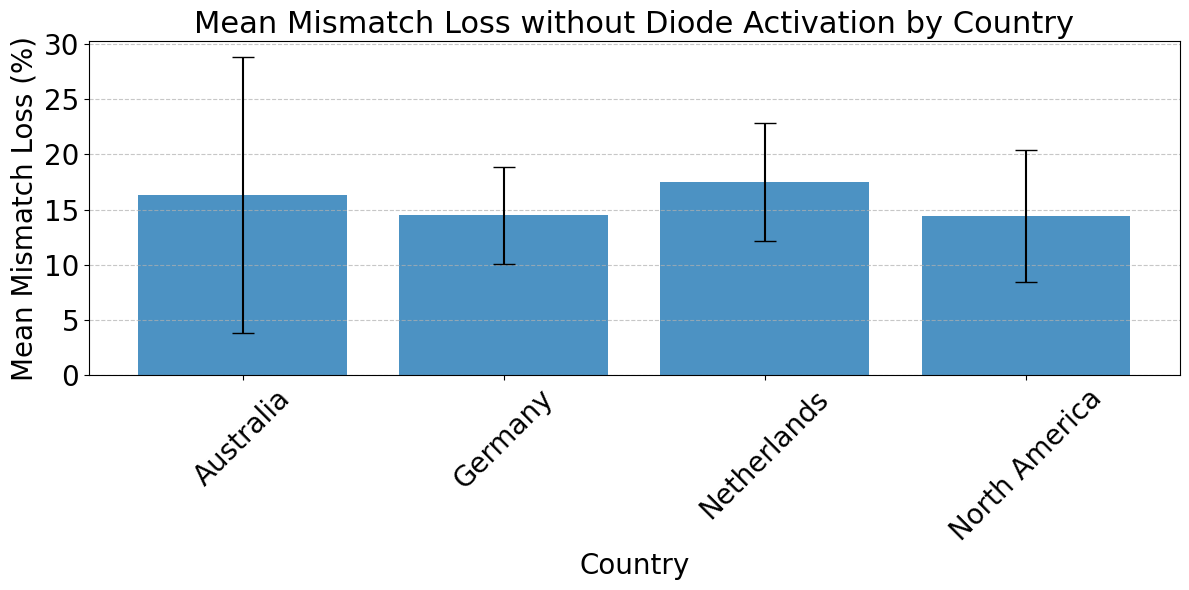

In [ ]:
# ...existing code before...

# Bar chart with error bars for each country (Mean Mismatch no diode %)
country_stats = zone_df.groupby('Country')['Mean Mismatch no diode (%)'].agg(['mean', 'std']).dropna()

plt.figure(figsize=long_hoz_figsize)
bars = plt.bar(
    country_stats.index,
    country_stats['mean'],
    yerr=country_stats['std'],
    color='C0',
    alpha=0.8,
    capsize=8
)
plt.ylabel('Mean Mismatch Loss (%)', fontsize=axis_label_size)
plt.xlabel('Country', fontsize=axis_label_size)
plt.title('Mean Mismatch Loss without Diode Activation by Country', fontsize=title_size)
plt.xticks(rotation=45, fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 5.2.4. Mismatch vs systme size

#### 5.2.4.1. Against kWp

Slope of trend line: 0.4090


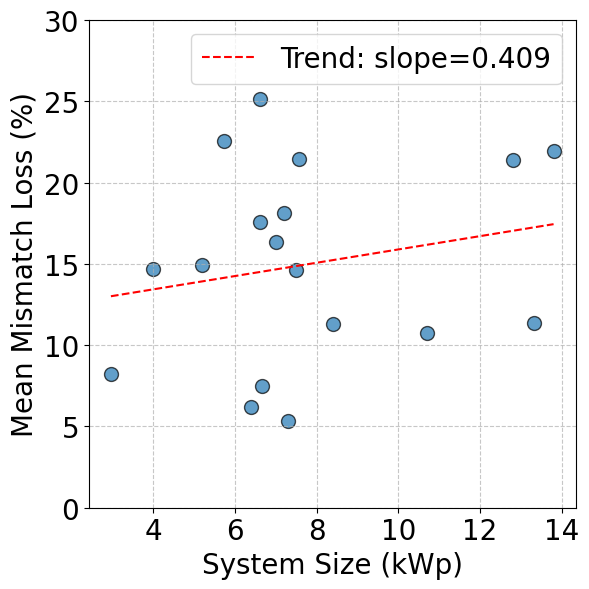

In [ ]:
# ...existing code before...

# plot the Mean mismatch loss without diode activation against system size (kWp), with trend line and slope
plt.figure(figsize=figure_size)
x = zone_df['kWp']
y = zone_df['Mean Mismatch no diode (%)']
plt.scatter(
    x,
    y,
    alpha=0.7,
    edgecolor='black',
    s=100
)
# Fit and plot trend line (ignore NaNs)
mask = (~pd.isna(x)) & (~pd.isna(y))
if mask.sum() > 1:
    coeffs = np.polyfit(x[mask], y[mask], 1)
    slope = coeffs[0]
    intercept = coeffs[1]
    xfit = np.linspace(x[mask].min(), x[mask].max(), 100)
    yfit = np.polyval(coeffs, xfit)
    plt.plot(xfit, yfit, 'r--', label=f'Trend: slope={slope:.3f}')
    print(f"Slope of trend line: {slope:.4f}")
else:
    print("Not enough data for trend line.")

# plt.title('Mean Mismatch Loss without Diode Activation vs System Size', fontsize=title_size)
plt.xlabel('System Size (kWp)', fontsize=axis_label_size)
plt.ylabel('Mean Mismatch Loss (%)', fontsize=axis_label_size)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
# define the ylim
plt.ylim(0, 30)  # Set y-axis limit to 0-60%
plt.tight_layout()
plt.legend(fontsize=axis_num_size)
output_kWp_plot = os.path.join(ResultsFolder, 'Mean_Mismatch_Loss_vs_kWp.png')
plt.savefig(output_kWp_plot, bbox_inches='tight', dpi=300)
plt.show()

C:\Users\z5183876\AppData\Local\Temp\ipykernel_253204\625961789.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('kWp_quantile')['Mean Mismatch no diode (%)']


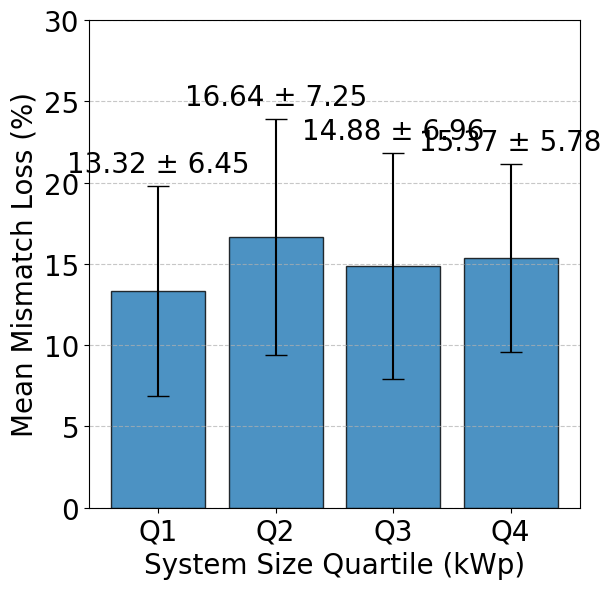

In [ ]:
# ...existing code before...

plt.figure(figsize=figure_size)

# Keep only rows with both kWp and mismatch values
valid_mask = zone_df['kWp'].notna() & zone_df['Mean Mismatch no diode (%)'].notna()
filtered_df = zone_df.loc[valid_mask].copy()

# Bin system size into four quantiles
quantile_labels = ['Q1', 'Q2', 'Q3', 'Q4']
filtered_df['kWp_quantile'] = pd.qcut(
    filtered_df['kWp'],
    q=4,
    labels=quantile_labels[:filtered_df['kWp'].nunique()],  # handles <4 unique sizes
    duplicates='drop'
)

# Compute mean/std mismatch per quantile (reindex to keep order)
stats = (
    filtered_df
    .groupby('kWp_quantile')['Mean Mismatch no diode (%)']
    .agg(['mean', 'std'])
    .reindex(quantile_labels)
)

# Build the bar chart with error bars
bars = plt.bar(
    stats.index,
    stats['mean'],
    yerr=stats['std'],
    color='C0',
    alpha=0.8,
    capsize=8,
    edgecolor='black'
)

plt.xlabel('System Size Quartile (kWp)', fontsize=axis_label_size)
plt.ylabel('Mean Mismatch Loss (%)', fontsize=axis_label_size)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 30)
plt.tight_layout()

# Optional: annotate each bar
for bar, mean, std in zip(bars, stats['mean'], stats['std']):
    if pd.notna(mean) and pd.notna(std):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            mean + std + 0.5,
            f"{mean:.2f} ± {std:.2f}",
            ha='center',
            va='bottom',
            fontsize=text_size
        )

output_kWp_plot = os.path.join(ResultsFolder, 'Mean_Mismatch_Loss_vs_kWp.png')
plt.savefig(output_kWp_plot, bbox_inches='tight', dpi=300)
plt.show()


#### 5.2.4.2. Against module number

##### 5.2.4.2.1. Calculate module number

In [ ]:
# ...existing code before...
# module_kwp_values = [
#     475, 440, 345, 405, 400, 440, 460, 370, 400, 390, 400,
#     420, 500, 410, 420, 430, 370, 375, 385, 440, 390, 440
# ]
module_kwp_values = [
    475, 440, 345, 405, 400, 440, 460, 370, 400, 390, 400,
    420, 500, 410, 420, 430, 370, 375
]
if len(module_kwp_values) == len(zone_df):
    zone_df['Module kWp'] = module_kwp_values
else:
    print(f"Length of module_kwp_values: {len(module_kwp_values)}")
    print(f"Number of rows in zone_df: {len(zone_df)}")
    raise ValueError("Length of module_kwp_values does not match number of rows in zone_df")

# calculate module number by dividing kWp with module kWp
zone_df['Module Number'] = zone_df['kWp'] / zone_df['Module kWp'] * 1e3

##### 5.2.4.2.2. Plotting

Slope of trend line: 0.1293


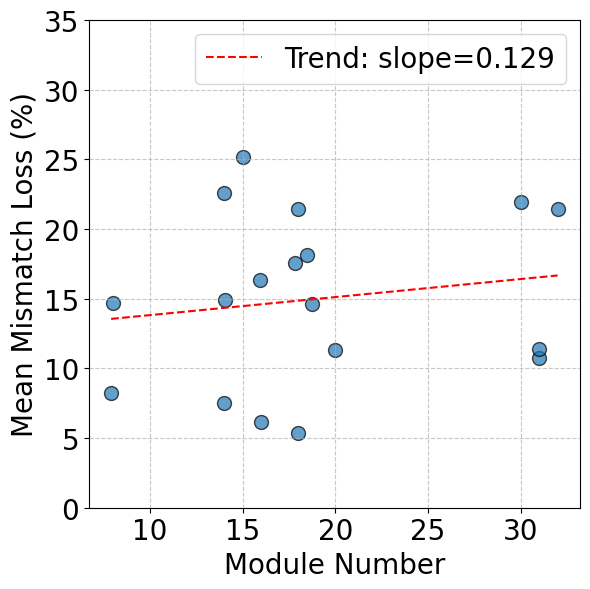

In [ ]:
# ...existing code before...

# plot the Mean mismatch loss without diode activation against module number, with trend line and slope
plt.figure(figsize=figure_size)
x = zone_df['Module Number']
y = zone_df['Mean Mismatch no diode (%)']
plt.scatter(
    x,
    y,
    alpha=0.7,
    edgecolor='black',
    s=100
)
# Fit and plot trend line (ignore NaNs)
mask = (~pd.isna(x)) & (~pd.isna(y))
if mask.sum() > 1:
    coeffs = np.polyfit(x[mask], y[mask], 1)
    slope = coeffs[0]
    intercept = coeffs[1]
    xfit = np.linspace(x[mask].min(), x[mask].max(), 100)
    yfit = np.polyval(coeffs, xfit)
    plt.plot(xfit, yfit, 'r--', label=f'Trend: slope={slope:.3f}')
    print(f"Slope of trend line: {slope:.4f}")
else:
    print("Not enough data for trend line.")

# plt.title('Mean Mismatch Loss without Diode Activation vs Module Number', fontsize=title_size)
plt.xlabel('Module Number', fontsize=axis_label_size)
plt.ylabel('Mean Mismatch Loss (%)', fontsize=axis_label_size)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.ylim(0, 35)  # Set y-axis limit to 0-60%
plt.tight_layout()
plt.legend(fontsize=axis_num_size)
output_module_num_plot = os.path.join(ResultsFolder, 'Mean_Mismatch_Loss_vs_Module_Number.png')
# plt.savefig(output_module_num_plot, bbox_inches='tight', dpi=300)
plt.show()

C:\Users\z5183876\AppData\Local\Temp\ipykernel_253204\734950557.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('module_quantile')['Mean Mismatch no diode (%)']


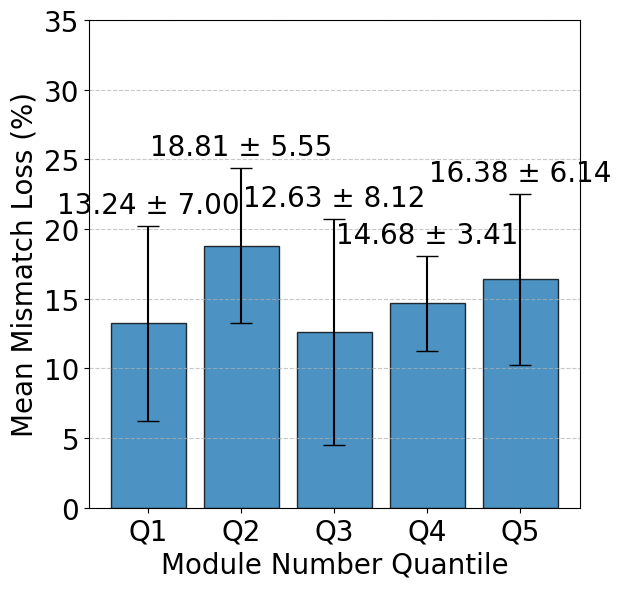

In [ ]:
plt.figure(figsize=figure_size)

# Keep rows with both module count and mismatch values
valid_mask = zone_df['Module Number'].notna() & zone_df['Mean Mismatch no diode (%)'].notna()
filtered_df = zone_df.loc[valid_mask].copy()

# Bin Module Number into quantiles (change quantile_count if you prefer tertiles, etc.)
quantile_count = 5
quantile_labels = [f'Q{i}' for i in range(1, quantile_count + 1)]
filtered_df['module_quantile'] = pd.qcut(
    filtered_df['Module Number'],
    q=min(quantile_count, filtered_df['Module Number'].nunique()),
    labels=quantile_labels[:filtered_df['Module Number'].nunique()],
    duplicates='drop'
)

# Aggregate stats per quantile and keep label order
stats = (
    filtered_df
    .groupby('module_quantile')['Mean Mismatch no diode (%)']
    .agg(['mean', 'std'])
    .reindex(quantile_labels)
)

bars = plt.bar(
    stats.index,
    stats['mean'],
    yerr=stats['std'],
    color='C0',
    alpha=0.8,
    capsize=8,
    edgecolor='black'
)

plt.xlabel('Module Number Quantile', fontsize=axis_label_size)
plt.ylabel('Mean Mismatch Loss (%)', fontsize=axis_label_size)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 35)
plt.tight_layout()

for bar, mean, std in zip(bars, stats['mean'], stats['std']):
    if pd.notna(mean) and pd.notna(std):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            mean + std + 0.5,
            f"{mean:.2f} ± {std:.2f}",
            ha='center',
            va='bottom',
            fontsize=text_size
        )

output_module_num_plot = os.path.join(ResultsFolder, 'Mean_Mismatch_Loss_vs_Module_Number.png')
# plt.savefig(output_module_num_plot, bbox_inches='tight', dpi=300)
plt.show()


### 5.2.5. Mult vs mono

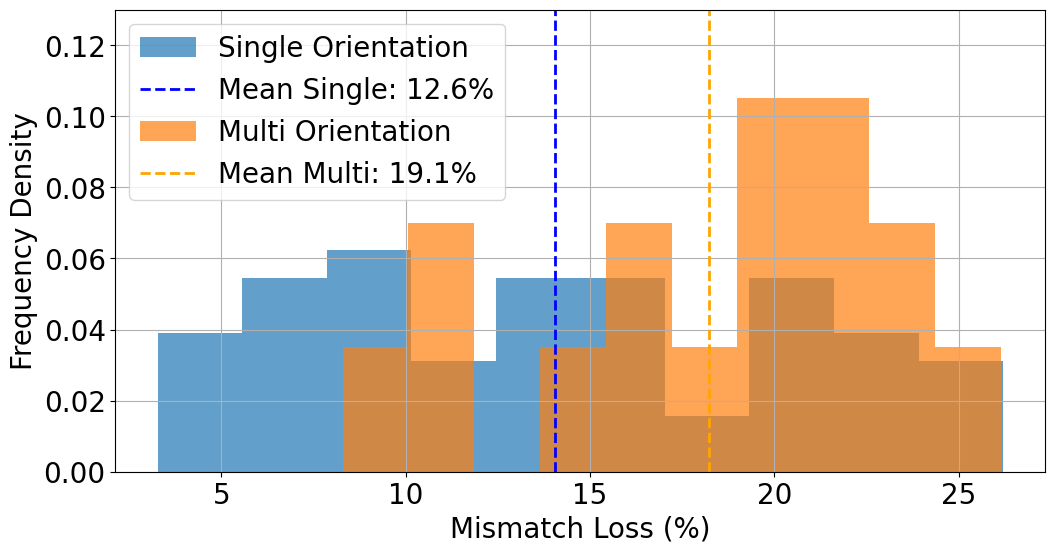

In [ ]:
# Filter for single and multi-orientation sites from the correct dataframe
single_df = zone_df[zone_df['Orientation'].str.lower() == 'single']
multi_df = zone_df[zone_df['Orientation'].str.lower() == 'multi']

# Define season columns
seasons = ['autumn', 'spring', 'summer', 'winter']

# Concatenate seasonal mismatch data for single orientation sites
single_seasonal_mismatch = pd.concat([single_df[s] for s in seasons]).dropna()

# Concatenate seasonal mismatch data for multi orientation sites
multi_seasonal_mismatch = pd.concat([multi_df[s] for s in seasons]).dropna()

# Calculate the mean for each orientation
mean_single = single_seasonal_mismatch.mean()
mean_multi = multi_seasonal_mismatch.mean()

# Plotting the mean mismatch loss of multi and single orientation as histograms
plt.figure(figsize=long_hoz_figsize)

# Plot histogram for single orientation
plt.hist(single_seasonal_mismatch, label='Single Orientation', density=True, bins=10, alpha=0.7)
plt.axvline(mean_single, color='blue', linestyle='--', linewidth=2, label=f'Mean Single: {12.6:.1f}%')

# Plot histogram for multi orientation
plt.hist(multi_seasonal_mismatch, label='Multi Orientation', density=True, bins=10, alpha=0.7)
plt.axvline(mean_multi, color='orange', linestyle='--', linewidth=2, label=f'Mean Multi: {19.1:.1f}%')

# plt.title('Distribution of Seasonal Mismatch Loss for Single and Multi-Orientation Sites', fontsize=title_size)
plt.xlabel('Mismatch Loss (%)', fontsize=axis_label_size)
plt.ylabel('Frequency Density', fontsize=axis_label_size)
plt.legend(fontsize=axis_num_size)
plt.grid(True)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.ylim(0, 0.13)
plt.show()

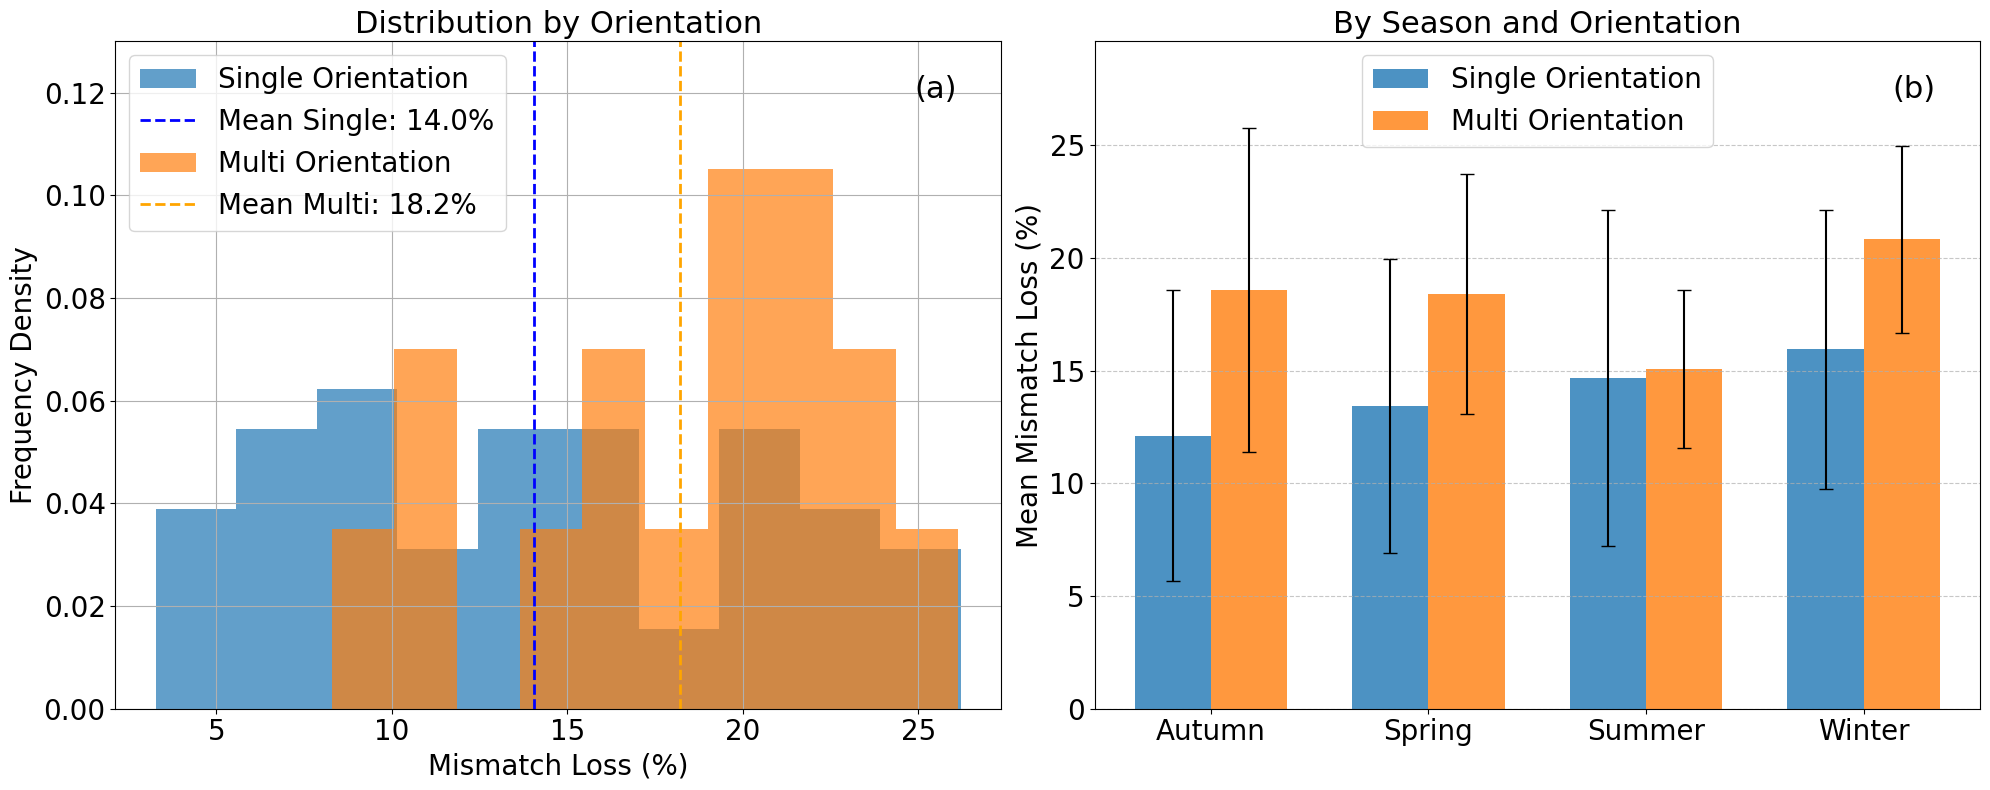

In [ ]:
# // ...existing code...
# Filter for single and multi-orientation sites from the correct dataframe
single_df = zone_df[zone_df['Orientation'].str.lower() == 'single']
multi_df = zone_df[zone_df['Orientation'].str.lower() == 'multi']

# Define seasons
seasons = ['autumn', 'spring', 'summer', 'winter']

# --- Data for Histogram (Left Plot) ---
# Concatenate seasonal mismatch data for single orientation sites
single_seasonal_mismatch = pd.concat([single_df[s] for s in seasons if s in single_df]).dropna()
# Concatenate seasonal mismatch data for multi orientation sites
multi_seasonal_mismatch = pd.concat([multi_df[s] for s in seasons if s in multi_df]).dropna()

# Calculate the mean for each orientation
mean_single = single_seasonal_mismatch.mean()
mean_multi = multi_seasonal_mismatch.mean()

# --- Data for Bar Chart (Right Plot) ---
single_means = [single_df[s].mean() for s in seasons]
single_stds = [single_df[s].std() for s in seasons]
multi_means = [multi_df[s].mean() for s in seasons]
multi_stds = [multi_df[s].std() for s in seasons]

# --- Plotting ---
# Create subplot with 1 row, 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Left plot: Histogram for single and multi-orientation
ax1.hist(single_seasonal_mismatch, label='Single Orientation', density=True, bins=10, alpha=0.7)
ax1.axvline(mean_single, color='blue', linestyle='--', linewidth=2, label=f'Mean Single: {mean_single:.1f}%')
ax1.hist(multi_seasonal_mismatch, label='Multi Orientation', density=True, bins=10, alpha=0.7)
ax1.axvline(mean_multi, color='orange', linestyle='--', linewidth=2, label=f'Mean Multi: {mean_multi:.1f}%')

ax1.set_title('Distribution by Orientation', fontsize=title_size)
ax1.set_xlabel('Mismatch Loss (%)', fontsize=axis_label_size)
ax1.set_ylabel('Frequency Density', fontsize=axis_label_size)
ax1.legend(fontsize=axis_num_size)
ax1.grid(True)
ax1.tick_params(axis='both', labelsize=axis_num_size)
ax1.set_ylim(0, 0.13)
# Add (a) label to upper right
ax1.text(0.95, 0.95, '(a)', transform=ax1.transAxes, fontsize=title_size, 
         ha='right', va='top')

# Right plot: Seasonal bar chart
x = np.arange(len(seasons))  # the label locations
bar_width = 0.35  # the width of the bars

ax2.bar(x - bar_width/2, single_means, bar_width, yerr=single_stds,
       label='Single Orientation', capsize=5, alpha=0.8)
ax2.bar(x + bar_width/2, multi_means, bar_width, yerr=multi_stds,
       label='Multi Orientation', capsize=5, alpha=0.8)

ax2.set_ylabel('Mean Mismatch Loss (%)', fontsize=axis_label_size)
ax2.set_title('By Season and Orientation', fontsize=title_size)
ax2.set_xticks(x)
ax2.set_xticklabels([s.capitalize() for s in seasons], fontsize=axis_num_size)
ax2.tick_params(axis='y', labelsize=axis_num_size)
ax2.legend(fontsize=axis_num_size)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust ylim to make space for error bars
y_max = max(
    (np.array(single_means, dtype=float) + np.array(single_stds, dtype=float)).max(),
    (np.array(multi_means, dtype=float) + np.array(multi_stds, dtype=float)).max()
)
ax2.set_ylim(0, y_max * 1.15)
# Add (b) label to upper right
ax2.text(0.95, 0.95, '(b)', transform=ax2.transAxes, fontsize=title_size, 
         ha='right', va='top')

plt.tight_layout()
plt.show()
# //

STD of Single Orientation Mismatch Losses: 6.6%


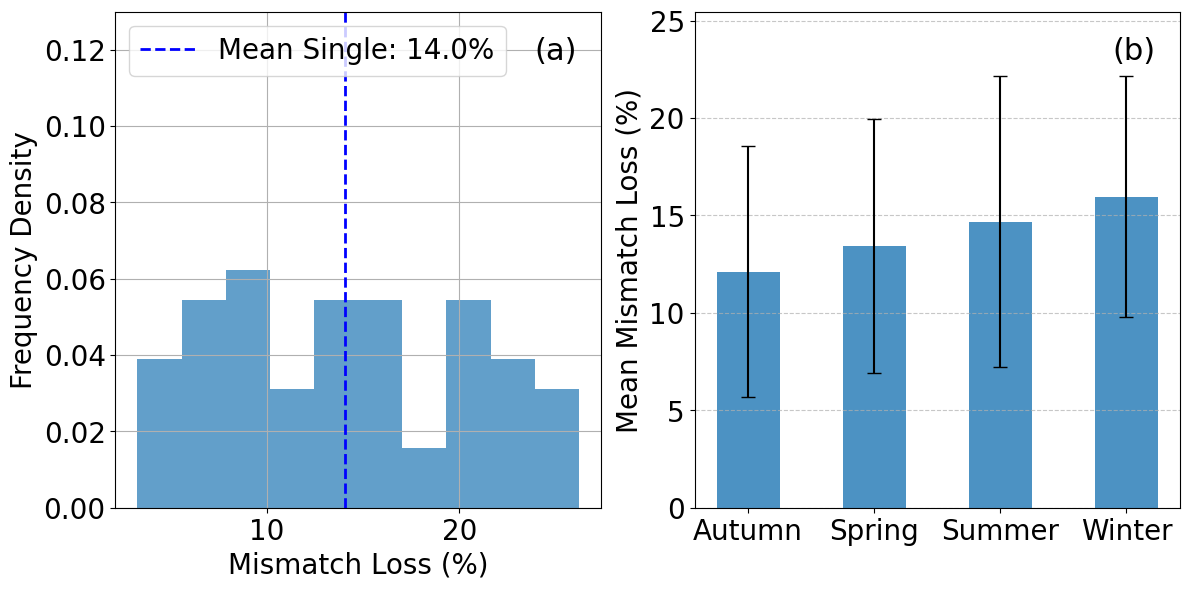

In [ ]:
# ...existing code...
# Filter for single orientation sites only
single_df = zone_df[zone_df['Orientation'].str.lower() == 'single']

# Define seasons
seasons = ['autumn', 'spring', 'summer', 'winter']

# --- Data for Histogram (Left Plot) ---
single_seasonal_mismatch = pd.concat([single_df[s] for s in seasons if s in single_df]).dropna()
mean_single = single_seasonal_mismatch.mean()

# --- Data for Bar Chart (Right Plot) ---
single_means = [single_df[s].mean() for s in seasons]
single_stds = [single_df[s].std() for s in seasons]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=long_hoz_figsize)

# Left plot: Histogram for single orientation only (no legend for histogram, keep mean legend for vertical line, no title)
hist_patch = ax1.hist(single_seasonal_mismatch, density=True, bins=10, alpha=0.7, color='C0')
mean_line = ax1.axvline(mean_single, color='blue', linestyle='--', linewidth=2, label=f'Mean Single: {mean_single:.1f}%')
ax1.set_xlabel('Mismatch Loss (%)', fontsize=axis_label_size)
ax1.set_ylabel('Frequency Density', fontsize=axis_label_size)
ax1.grid(True)
ax1.tick_params(axis='both', labelsize=axis_num_size)
ax1.set_ylim(0, 0.13)
ax1.text(0.95, 0.95, '(a)', transform=ax1.transAxes, fontsize=title_size, ha='right', va='top')
# Only show legend for mean line
handles, labels = ax1.get_legend_handles_labels()
if handles:
    ax1.legend([mean_line], [f'Mean Single: {mean_single:.1f}%'], fontsize=axis_num_size)
else:
    ax1.legend_.remove() if ax1.legend_ else None
ax1.set_title('')

# print the std of all the mismatch losses
print(f'STD of Single Orientation Mismatch Losses: {single_seasonal_mismatch.std():.1f}%')

# Right plot: Seasonal bar chart for single orientation only (no legend, no title)
x = np.arange(len(seasons))
bar_width = 0.5
bars = ax2.bar(x, single_means, bar_width, yerr=single_stds,
               capsize=5, alpha=0.8, color='C0')
ax2.set_ylabel('Mean Mismatch Loss (%)', fontsize=axis_label_size)
ax2.set_xticks(x)
ax2.set_xticklabels([s.capitalize() for s in seasons], fontsize=axis_num_size)
ax2.tick_params(axis='y', labelsize=axis_num_size)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
y_max = (np.array(single_means, dtype=float) + np.array(single_stds, dtype=float)).max()
ax2.set_ylim(0, y_max * 1.15)
ax2.text(0.95, 0.95, '(b)', transform=ax2.transAxes, fontsize=title_size, ha='right', va='top')
# Remove legend and title
ax2.legend_.remove() if ax2.legend_ else None
ax2.set_title('')

plt.tight_layout()
plt.show()

### 5.2.6. Overall distribution

#### 5.2.6.1. Averaged over the seasons

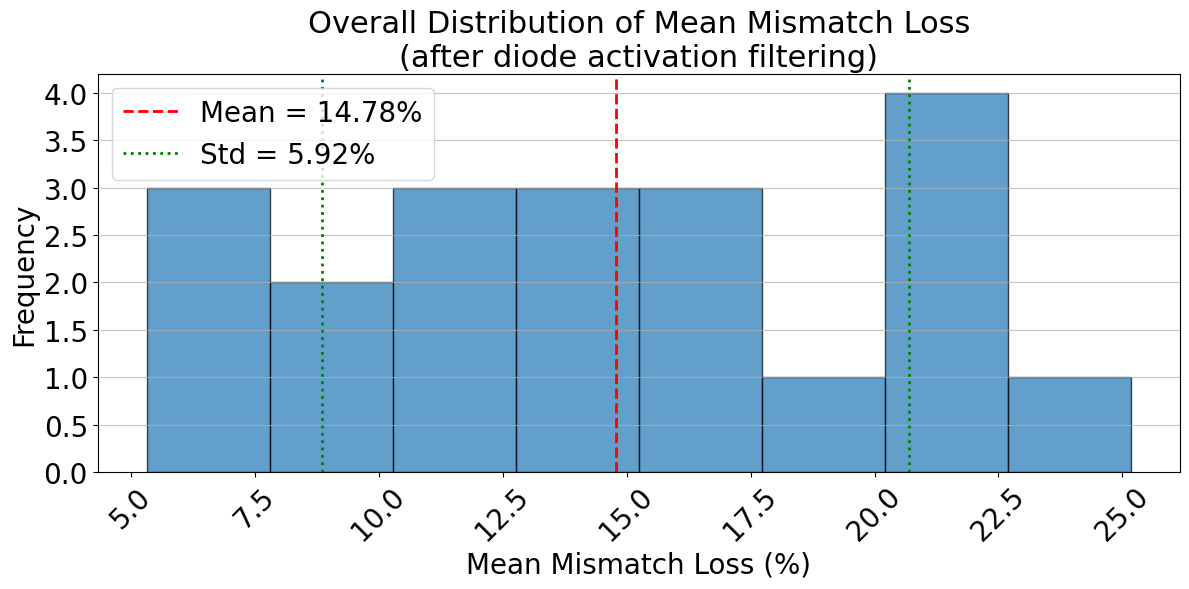

In [ ]:
# Read the latest zone_df if not already loaded
zone_df = pd.read_excel(os.path.join(ResultsFolder, 'Mismatch loss without diode activation.xlsx'))

# Drop NaN values for plotting
data = zone_df['Mean Mismatch no diode (%)'].dropna()

# Calculate mean and std
mean_val = data.mean()
std_val = data.std()

plt.figure(figsize=long_hoz_figsize)
plt.hist(data, bins=8, color='C0', alpha=0.7, edgecolor='black')
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f"Mean = {mean_val:.2f}%")
plt.axvline(mean_val + std_val, color='green', linestyle=':', linewidth=2, label=f"Std = {std_val:.2f}%")
plt.axvline(mean_val - std_val, color='green', linestyle=':', linewidth=2)
plt.xlabel('Mean Mismatch Loss (%)', fontsize=axis_label_size)
plt.ylabel('Frequency', fontsize=axis_label_size)
plt.title('Overall Distribution of Mean Mismatch Loss\n(after diode activation filtering)', fontsize=title_size)
plt.xticks(fontsize=axis_num_size, rotation=45)
plt.yticks(fontsize=axis_num_size)
plt.legend(fontsize=axis_num_size)
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.show()

#### 5.2.6.3. Plot add data

Found seasonal columns: ['December Mismatch no diode (%)', 'June Mismatch no diode (%)', 'March Mismatch no diode (%)', 'September Mismatch no diode (%)']


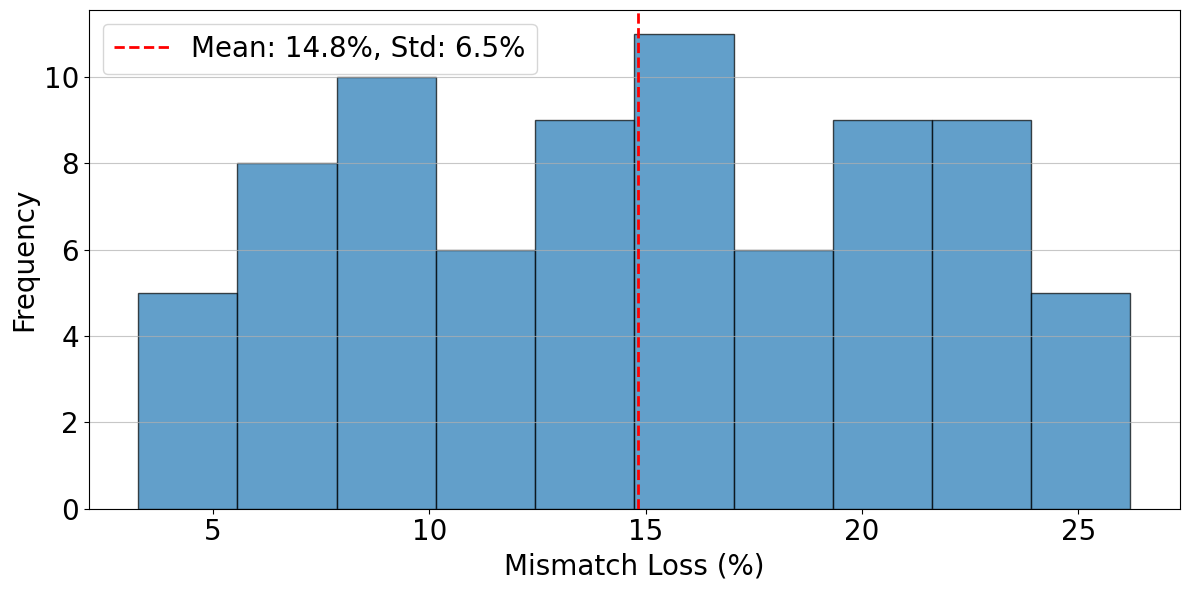

In [ ]:
# Filter for single and multi-orientation sites from the correct dataframe
single_df = zone_df[zone_df['Orientation'].str.lower() == 'single']
multi_df = zone_df[zone_df['Orientation'].str.lower() == 'multi']

# Define season columns as the column that contains any month names
month_names = ['january', 'february', 'march', 'april', 'may', 'june', 
               'july', 'august', 'september', 'october', 'november', 'december']

# Find columns that contain month names and "Mismatch no diode (%)"
seasonal_columns = []
for col in zone_df.columns:
    if 'Mismatch no diode (%)' in col:
        for month in month_names:
            if month.lower() in col.lower():
                seasonal_columns.append(col)
                break

print(f"Found seasonal columns: {seasonal_columns}")

# Concatenate ALL seasonal mismatch data (both single and multi orientation)
all_seasonal_mismatch = pd.concat([
    pd.concat([single_df[col] for col in seasonal_columns if col in single_df.columns]),
    pd.concat([multi_df[col] for col in seasonal_columns if col in multi_df.columns])
]).dropna()

# Calculate the overall mean
mean_all = all_seasonal_mismatch.mean()
std_all = all_seasonal_mismatch.std()

# Plotting the overall mismatch loss distribution
plt.figure(figsize=long_hoz_figsize)

# Plot histogram for all data
plt.hist(all_seasonal_mismatch, bins=10, alpha=0.7, color='C0', edgecolor='black')
plt.axvline(mean_all, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_all:.1f}%, Std: {std_all:.1f}%')

plt.xlabel('Mismatch Loss (%)', fontsize=axis_label_size)
plt.ylabel('Frequency', fontsize=axis_label_size)
plt.legend(fontsize=axis_num_size)
plt.grid(axis='y', alpha=0.7)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.tight_layout()
plt.show()

Found seasonal columns: ['December Mismatch no diode (%)', 'June Mismatch no diode (%)', 'March Mismatch no diode (%)', 'September Mismatch no diode (%)']


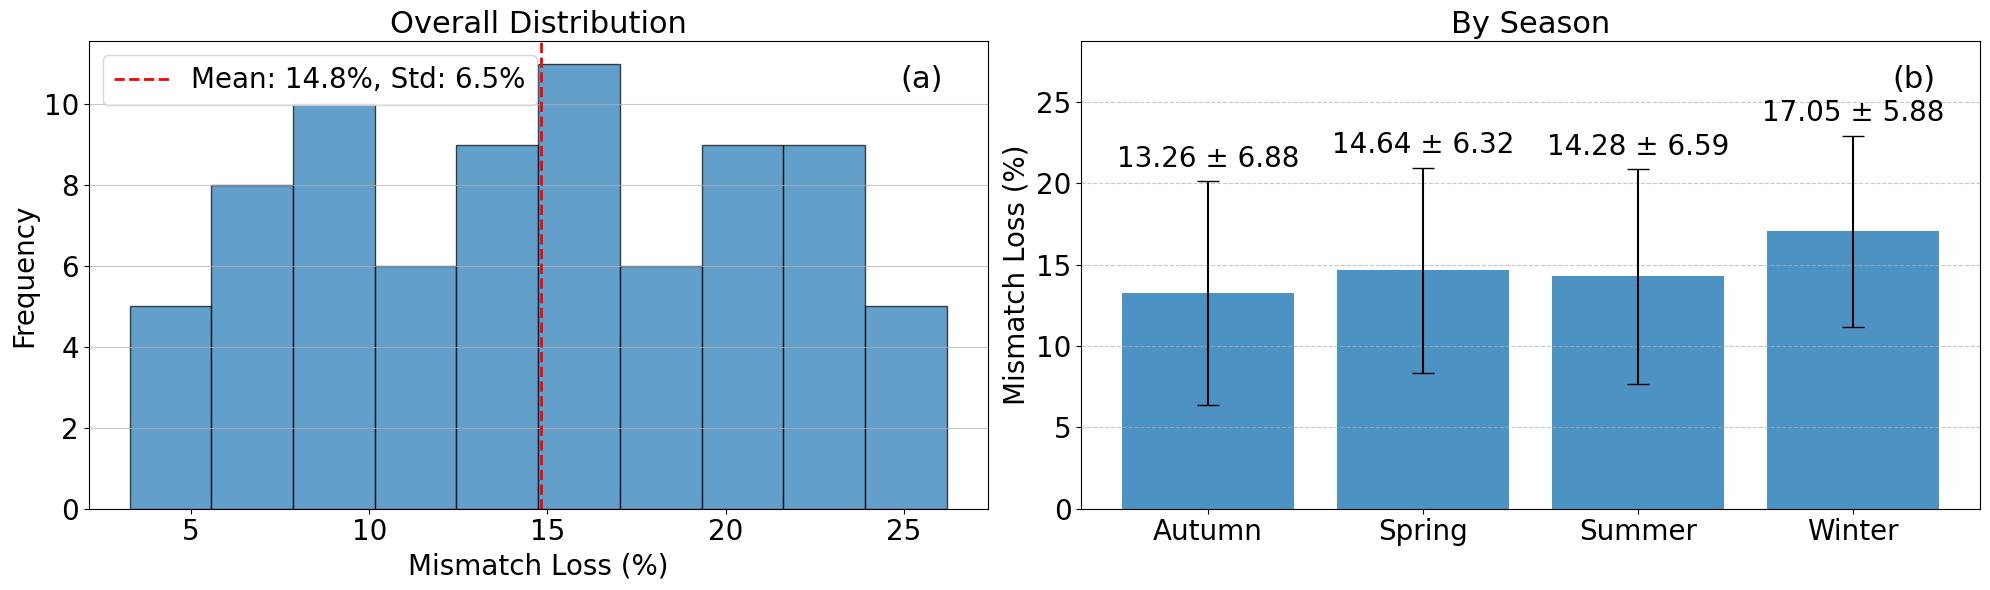

In [ ]:
# Filter for single and multi-orientation sites from the correct dataframe
single_df = zone_df[zone_df['Orientation'].str.lower() == 'single']
multi_df = zone_df[zone_df['Orientation'].str.lower() == 'multi']

# Define season columns as the column that contains any month names
month_names = ['january', 'february', 'march', 'april', 'may', 'june', 
               'july', 'august', 'september', 'october', 'november', 'december']

# Find columns that contain month names and "Mismatch no diode (%)"
seasonal_columns = []
for col in zone_df.columns:
    if 'Mismatch no diode (%)' in col:
        for month in month_names:
            if month.lower() in col.lower():
                seasonal_columns.append(col)
                break

print(f"Found seasonal columns: {seasonal_columns}")

# Concatenate ALL seasonal mismatch data (both single and multi orientation)
all_seasonal_mismatch = pd.concat([
    pd.concat([single_df[col] for col in seasonal_columns if col in single_df.columns]),
    pd.concat([multi_df[col] for col in seasonal_columns if col in multi_df.columns])
]).dropna()

# Calculate the overall mean
mean_all = all_seasonal_mismatch.mean()
std_all = all_seasonal_mismatch.std()

# Check if season columns exist, if not, create them from the monthly data
seasons = ['autumn', 'spring', 'summer', 'winter']

# Create season mapping
northern_hemisphere_season_map = {
    'january': 'winter', 'february': 'winter', 'march': 'spring',
    'april': 'spring', 'may': 'spring', 'june': 'summer',
    'july': 'summer', 'august': 'summer', 'september': 'autumn',
    'october': 'autumn', 'november': 'autumn', 'december': 'winter'
}
southern_hemisphere_season_map = {
    'january': 'summer', 'february': 'summer', 'march': 'autumn',
    'april': 'autumn', 'may': 'autumn', 'june': 'winter',
    'july': 'winter', 'august': 'winter', 'september': 'spring',
    'october': 'spring', 'november': 'spring', 'december': 'summer'
}

# Add season columns if they don't exist
for season in seasons:
    if season not in zone_df.columns:
        zone_df[season] = np.nan

# Populate season columns if they're empty
if zone_df[seasons].isna().all().all():
    for idx, row in zone_df.iterrows():
        country = str(row.get('Country', '')).lower()
        # Determine hemisphere
        if country in ['australia', 'new zealand', 'south africa']:
            season_map = southern_hemisphere_season_map
        else:
            season_map = northern_hemisphere_season_map
        
        # Map months to seasons
        for month, season in season_map.items():
            month_col = f'{month.capitalize()} Mismatch no diode (%)'
            if month_col in zone_df.columns and pd.notna(row.get(month_col)):
                zone_df.at[idx, season] = row[month_col]

# Calculate mean and std for each season
means = [zone_df[season].mean() for season in seasons]
stds  = [zone_df[season].std() for season in seasons]

# Create subplot with 1 row, 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Left plot: Overall histogram
ax1.hist(all_seasonal_mismatch, bins=10, alpha=0.7, color='C0', edgecolor='black')
ax1.axvline(mean_all, color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {mean_all:.1f}%, Std: {std_all:.1f}%')
ax1.set_xlabel('Mismatch Loss (%)', fontsize=axis_label_size)
ax1.set_ylabel('Frequency', fontsize=axis_label_size)
ax1.legend(fontsize=axis_num_size)
ax1.grid(axis='y', alpha=0.7)
ax1.tick_params(axis='both', labelsize=axis_num_size)
ax1.set_title('Overall Distribution', fontsize=title_size)
# Add (a) label to upper right
ax1.text(0.95, 0.95, '(a)', transform=ax1.transAxes, fontsize=title_size, 
         ha='right', va='top')

# Right plot: Seasonal bar chart
bars = ax2.bar(
    [s.capitalize() for s in seasons],
    means,
    yerr=stds,
    color='C0',
    alpha=0.8,
    capsize=8
)

# Add value and std on top of each bar
for bar, mean, std in zip(bars, means, stds):
    # Check for NaN values before annotating
    if pd.notna(mean) and pd.notna(std):
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            mean + std + 0.5,  # Position text above the error bar
            f"{mean:.2f} ± {std:.2f}",
            ha='center',
            va='bottom',
            fontsize=text_size
        )

ax2.set_ylabel('Mismatch Loss (%)', fontsize=axis_label_size)
ax2.tick_params(axis='both', labelsize=axis_num_size)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.set_ylim(0, (max(means) + max(stds)) * 1.2)
ax2.set_title('By Season', fontsize=title_size)
# Add (b) label to upper right
ax2.text(0.95, 0.95, '(b)', transform=ax2.transAxes, fontsize=title_size, 
         ha='right', va='top')

plt.tight_layout()
plt.show()